# EDA C — Repeated EDA, Feature Engineering, and Modeling Handoff
## Endometriosis & Intrapartum Cesarean Section — Sheba Medical Center

---

## Section C0 — Purpose, Scope, and Safety Rules

### Purpose
EDA C runs after A2 clinical decisions are resolved and any required preprocessing
corrections are applied. It bridges A2 (predictor-readiness) and the modeling phase.
On the cleaned Data Cleaning B (Batch 19) dataset it performs:
1. a **repeated EDA** that reuses/adapts the A1 + A2 analytical architecture;
2. **deterministic feature engineering** (documented plan + rule-based execution);
3. **target-independent eligibility screening**; and
4. a **cumulative stage-specific candidate handoff** (Stage 1 / Stage 2 / Stage 3).

### Notebook section order (current architecture)
The repeated-EDA diagnostics and the feature-engineering / screening / handoff
stages are **interleaved by design**: two repeated-EDA-style diagnostic
sections (C10c predictor–predictor relationships, C12e readiness table) run
*after* the C8/C9 feature-engineering cells so that the materialized derived
features are included in the predictor–predictor relationship diagnostics and
in the final readiness summary. The section table below is the authoritative
running order.

| Section | Purpose |
|---|---|
| C0–C2 | Purpose/scope; prerequisites gate; load the authoritative Data Cleaning B classification + type snapshots + config metadata |
| C3 | Load cleaned Batch 19; build `ANALYSIS_VARS` and the cumulative `STAGE_1_COLS ⊆ STAGE_2_COLS ⊆ STAGE_3_COLS` + `EARLIEST_ENTRY_STAGE` |
| **C3b** | Post-B **pre-screen** variable inventory & classification (origin lineage: `original_preprocessing` / `B_registered_original` / `B_created`; feature-dict metadata applied to B-registered originals too; cumulative `available_prediction_horizons`; registry-driven structural missingness; separate non-materialized-representation table) + predictor-pool / exclusion-rationale accounting + boolean-membership reconciliation totals (adapts A1). Not final C12 eligibility. |
| C4 / C4b / C4c | Descriptive Table 1 by target & domain; per-variable distribution plots; before/after-cleaning comparison |
| C5 / **C5b** | Missingness recheck (per-variable + row-level + structural registry); **missingness deep-dive** — by-target, heatmap, co-missingness (adapts A2.7) |
| C6 | Sparsity, event counts, and separation risk — **diagnostic only** |
| C7 / **C7b** | IQR outlier / plausibility recheck (target-blind, nothing removed); **three cumulative-stage Sweetviz profiling reports** (git-ignored HTML) |
| C8 / C9 | Feature-engineering plan; deterministic derivation into `df_analysis`; horizon-inheritance safeguard |
| C10 / C10b / **C10c** | Derived-feature validation; formula registry; **predictor–predictor relationships & redundancy diagnostics** (Spearman, Cramér's V, numeric×categorical, representation classification — adapts A2.10) |
| C11 / C12 | Exploratory predictor–target association screening (Mann–Whitney / Fisher / χ² + BH-FDR) — **descriptive only**; candidate review table |
| C12b / C12c | Eligibility filtering and candidate-pool construction (target-independent hard rules only); assert-style pool validation |
| C12d / **C12e** | Derived-feature final role; **comprehensive repeated-EDA readiness table** (adapts A2.12; p/q/effect shown for description only) |
| C13 | Export: the cumulative-Stage-3 candidate pool **plus** per-stage candidate files (`candidate_features_stage{1,2_cumulative,3_cumulative}.csv`), per-stage patient-level modeling datasets, and the machine-readable downstream-preprocessing contract |
| C14–C18 | Treatment plan (documented only); handoff contract; readiness gate; on-disk output verification; constant / near-zero-variance validation |

### Eligibility is target-independent
EDA C **hard-excludes** a variable from the candidate pool only for
**target-independent** reasons, as implemented in C12b:
- true zero variance (no missing values, exactly one observed value);
- an invalid / impossible representation (`impossible_flag`);
- a materialized derived feature whose authoritative `analytical_role`
  (from `derived_meta`) is an explicit unresolved-state value —
  `analytical_role in {"review", "unresolved"}`;
- a variable classified `intrapartum_candidate_pending_timing_confirmation`
  (timing unresolved — currently 0 members);
- a sanity-check-only / non-modeling derived feature
  (`analytical_role == "sanity_check_only"`);
- a forbidden upstream role/timing/leakage classification (`leakage_exclude`,
  `intrapartum_or_post_delivery_exclude`, `source_or_text_audit_exclude`,
  `manual_review_pending`, `awaiting_clinical_clarification`, ID/target) —
  enforced in C2/C3 before `ANALYSIS_VARS` is built.

The `primary_model_eligible` field carried on the derived-feature plan and the
exported feature dictionary is a **legacy / descriptive** compatibility field
only — it does **not** control eligibility. `analytical_role` +
`earliest_entry_stage` are the authoritative multi-horizon contract.

The following are **diagnostics / soft warnings only** and **never** remove a
variable from the pool before cross-validation:
- sparse target cells; complete / quasi separation; boundary-sparse instability;
- high missingness (surfaced as the `high_missingness_diagnostic` soft warning;
  the former generic >40% hard rule has been removed);
- `weak_univariate_signal`; `high_target_association_review`;
- p-value; BH-FDR q-value; effect size.

Redundancy is disclosed (`redundancy_group` / `redundancy_demoted` /
`redundancy_unresolved`); for families with no target-independent fixed
representative, resolution is deferred to modeling under CV. `priority_score`
is a descriptive ranking column only — it never filters the pool and never
selects a redundancy representative.

### Cumulative prediction stages
Horizons are cumulative:
- **Stage 1** — pre-labor predictors;
- **Stage 2** — Stage 1 + near-delivery predictors (`secondary_near_delivery_predictor`);
- **Stage 3** — Stage 2 + intrapartum predictors (`intrapartum_predictor_exclude_from_prelabor_model`).

`earliest_entry_stage` (derived from the authoritative classification label) sets
the **earliest** horizon at which a predictor may enter. A predictor is never
moved to an earlier stage because it looks statistically strong.

### Final feature selection is downstream
EDA C performs repeated EDA, deterministic feature engineering,
target-independent eligibility screening, and a broad candidate handoff.
Univariate predictor–target statistics here are **descriptive/diagnostic** —
they are not feature selection. Final predictive feature selection, model
fitting, and hyperparameter tuning occur downstream (EDA D / modeling), using
training-fold-only procedures inside cross-validation.

### What this notebook does NOT do
- No model training, evaluation, or hyperparameter tuning.
- No final / predictive feature selection (that is downstream, inside CV).
- No cleaning of source predictor values; no overwriting of source columns.
- No modification of the EDA A or A2 notebooks.

### Safety contract
1. **No analytical rows are removed in EDA C, and no source predictor values are
   edited for analytical cleaning.** The canonical Batch 19 workbook is never
   overwritten. `df` is the read-only source frame; the only in-memory
   bookkeeping applied to it is technical — an import-artifact column
   (`"Unnamed: 0"`) is dropped if present, and an internal row-alignment key
   (`_row_key_delivery_id`, never a feature, never a model input) is attached.
   `df_analysis` is a column subset of `df` plus the C9 `derived_` columns.
2. Derived features use the `derived_` prefix and live in `df_analysis` only.
3. No learned / fold-safe modeling transformation is fitted on the full cohort;
   fold-safe cutpoints and imputation are fitted training-fold-only, downstream.
4. `subject_number` and `delivery_id` are never printed and never appear as a
   column in the analysis frame or in any modeling handoff dataset (a row-order
   `delivery_id` alignment sidecar is written separately, never as a feature).
5. **Output flags.** `SAVE_OUTPUTS = False` by default — the broad/legacy
   patient-level reference matrix is not written unless explicitly requested.
   `SAVE_SELECTED_MODELING_DATASET = True` by default — the **stage-specific
   modeling handoff datasets** (target + the approved eligible predictors for
   each cumulative stage, **no identifier columns**) are written by default. All
   patient-level files are git-ignored / non-versioned; enabling
   `SAVE_SELECTED_MODELING_DATASET` does not commit any raw patient-level
   profiling output.
6. All analytical sections run regardless of the C1 prerequisite flag values;
   only the C16 readiness gate blocks `MODELING_HANDOFF_READY = True`.

## Section C1 — Run Configuration

C1 sets **no** manual clinical-readiness boolean and **no** manual
candidate-pool override. Both were retired 2026-08-31 — a hand-typed `True`
is not runtime evidence, and a hand-typed variable list is an undocumented
alternate analytical path.

### Candidate universe — always metadata-derived
`ANALYSIS_VARS` is rebuilt every run in C3 from the authoritative Data Cleaning
B classification snapshot: the union of the current stage-eligible
classifications — `predictor_allowed` (Stage 1), `secondary_near_delivery_predictor`
(Stage 2), `intrapartum_predictor_exclude_from_prelabor_model` (Stage 3) — plus
approved Data Cleaning B-created replacement variables, minus the forbidden-role
set (`leakage_exclude`, `intrapartum_or_post_delivery_exclude`,
`source_or_text_audit_exclude`, `manual_review_pending`,
`awaiting_clinical_clarification`,
`intrapartum_candidate_pending_timing_confirmation`, ID/target). Authoritative
column order is preserved and `Stage 1 ⊆ Stage 2 ⊆ Stage 3` is asserted. There
is exactly one reproducible way to build the universe — no manual list, no
file import.

### Clinical readiness — operational, not hand-typed
The C16 readiness gate verifies the **current live** metadata/pool state, not a
narrative claim: no `intrapartum_candidate_pending_timing_confirmation` /
`awaiting_clinical_clarification` variable in the analytical universe; no
`manual_review_pending` variable in the eligible pool; no
forbidden/leakage/post-outcome/source-audit classification in the pool; stage
construction and candidate-pool validation pass; every hard exclusion is
target-independent. The A2 Section A2.14 decision registry and
`docs/clinical_decisions/manual_decisions_log.md` are the historical/provenance
record — C1 does not parse or dynamically re-validate them.

### Output flags
- `SAVE_AGGREGATED_OUTPUTS = True` — aggregate CSV/JSON metadata artifacts (no patient rows).
- `SAVE_OUTPUTS = False` — broad/legacy patient-level reference matrix; off by default.
- `SAVE_SELECTED_MODELING_DATASET = True` — the stage-specific
  **eligible-candidate** modeling handoff datasets (target + the approved
  eligible predictors per cumulative stage; no identifier columns; git-ignored).
  This is the broad target-independent eligible candidate pool, **not** a final
  predictive feature selection — that occurs downstream, inside training-fold
  cross-validation.

### Dataset selection — resolved from the Data Cleaning B manifest
There is **no** dataset-selection flag. The canonical EDA C input is whatever
`outputs/data_cleaning/audit/cleaning_b_manifest.json` records as its
`output_file` (currently `work_df_batch19_after_data_cleaning_b.xlsx`), loaded
from `outputs/data_cleaning/processed/` and verified byte-for-byte against the
manifest's `output_sha256`. The old `USE_LATEST_PROCESSED_BATCH` "highest
cleaned batch" auto-discovery and the raw `work_df_batch18.xlsx` fallback were
**both retired 2026-08-31** — a future approved Data Cleaning B output becomes
canonical by updating the B manifest through the B workflow, not by EDA C
guessing a filename. (The load/verify logic itself is in C3.)

In [1]:
# ── Run configuration ─────────────────────────────────────────────────────────
# C1 sets NO manual clinical-readiness boolean, NO manual candidate-pool
# override, and NO dataset-selection flag (all retired 2026-08-31).
#  * The candidate universe (ANALYSIS_VARS) is rebuilt every run from the
#    authoritative Data Cleaning B classification snapshot -- see C3.
#  * The input dataset is resolved from cleaning_b_manifest.json and verified
#    against its recorded SHA-256 -- see C3.
#  * The C16 readiness gate is derived from live metadata/pool state -- see
#    Part 5 (readiness_checks / pipeline_status gates).
#  * The A2 Section A2.14 decision registry and
#    docs/clinical_decisions/manual_decisions_log.md remain the
#    historical/provenance record and are NOT parsed or re-validated here.

import sys
from pathlib import Path

# ── Output flags ──────────────────────────────────────────────────────────────
SAVE_AGGREGATED_OUTPUTS = True   # aggregate CSV/JSON metadata artifacts (no patient rows)
SAVE_OUTPUTS = False             # broad/legacy patient-level reference matrix -- OFF by default
SAVE_SELECTED_MODELING_DATASET = True
# Stage-specific patient-level ELIGIBLE-CANDIDATE modeling handoff datasets
# (target + the approved eligible predictors per cumulative stage; NO identifier
# columns -- see C0 safety rules; git-ignored). This is the broad
# target-independent eligible candidate pool, NOT a final predictive
# feature selection -- final selection / model fitting / tuning happen
# downstream inside training-fold cross-validation.

print(f"SAVE_AGGREGATED_OUTPUTS        = {SAVE_AGGREGATED_OUTPUTS}")
print(f"SAVE_OUTPUTS                   = {SAVE_OUTPUTS}")
print(f"SAVE_SELECTED_MODELING_DATASET = {SAVE_SELECTED_MODELING_DATASET}")
print("Candidate universe : metadata-derived every run (no manual override).")
print("Input dataset      : resolved from cleaning_b_manifest.json + SHA-verified (see C3).")
print("Clinical readiness : operational -- checked in C16 from live metadata/pool state.")

SAVE_AGGREGATED_OUTPUTS        = True
SAVE_OUTPUTS                   = False
SAVE_SELECTED_MODELING_DATASET = True
Candidate universe : metadata-derived every run (no manual override).
Input dataset      : resolved from cleaning_b_manifest.json + SHA-verified (see C3).
Clinical readiness : operational -- checked in C16 from live metadata/pool state.


## Section C2 — Load the Metadata Contract (single source of truth per layer)

EDA C uses one authoritative source for each kind of metadata. There is **no**
embedded mirror and **no** current-working-directory alternate. The 2026-08-31
C2 correction removed both.

| # | Metadata | Authoritative source | Role |
|---|----------|----------------------|------|
| 1 | Modeling-role classification (`predictor_allowed`, every excluded/secondary/pending category) | Data Cleaning B classification snapshot (`cleaning_b_variable_classification_snapshot.csv`, via `classification_lineage.start_eda_c_snapshot`) | drives eligibility + stage membership |
| 2 | Variable type (binary / categorical / continuous / …) | Data Cleaning B type-schema snapshot (`cleaning_b_variable_type_schema_snapshot.csv`) | drives type-aware screening; **fail loud** for a B-stage variable with no entry |
| 3 | B-created / B-registered lineage: `stage`, `clinical_timing`, `domain`, `redundancy_group`, `model_entry_mode`, `redundant_with`, `cutpoint_source`, `materialized_in_B` | `cleaning_b_feature_dictionary.csv` | enriches every B-registered variable; loaded here as part of the C2 contract |
| 4 | Structural / applicability-aware missingness (confirmed vs pending tiers) | `eda_shared/structural_missingness_registry.py` | the **only** EDA C definition of structural missingness — **not** `config.py`'s `STRUCTURAL_NAN_COLS` |
| 5 | Project domain / timing / clinical-tier / redundancy-group / scoring metadata for preprocessing-level variables | `analysis/model_variable_readiness/config.py` | descriptive/supporting metadata; **required** — if it will not load, C2 **fails loud** (no empty-dict, no embedded fallback) |
| 6 | Preprocessing classification / type CSVs (`outputs/preprocessing/audit/…`) | project-root path only | **provenance comparison only** — a value difference is an audit note, never blocking, never overrides the B snapshot |

**Stage membership stays classification-driven** (source #1): `predictor_allowed`
→ Stage 1, `secondary_near_delivery_predictor` → earliest Stage 2,
`intrapartum_predictor_exclude_from_prelabor_model` → earliest Stage 3.
`TIMING_MAP` / `clinical_timing` are descriptive only and never move a
predictor to another horizon.

If `config.py` requires project files that are absent in a standalone/Colab
session, supply those files — the notebook does not carry a second analytical
definition of this metadata.

In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import sys, os, re, hashlib, zipfile, importlib.util, warnings
from datetime import datetime as _dt, timezone as _tz

warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")
warnings.filterwarnings("ignore", category=FutureWarning, module="scipy")

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", "{:.3f}".format)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
matplotlib.rcParams["figure.dpi"] = 90
_MUTED = sns.color_palette("muted")
_C0, _C1 = _MUTED[0], _MUTED[3]

IN_COLAB = "google.colab" in sys.modules

# ── Locate project root ────────────────────────────────────────────────────────
CLASSIFICATION_REL = "outputs/preprocessing/audit/variable_classification_minimal.csv"
VARIABLE_TYPE_SCHEMA_REL = "outputs/preprocessing/audit/variable_type_schema_minimal.csv"
APPROVED_LABELS = [
    "id", "target", "predictor_allowed", "secondary_near_delivery_predictor",
    "intrapartum_candidate_pending_timing_confirmation",
    "intrapartum_predictor_exclude_from_prelabor_model",
    "source_or_text_audit_exclude", "cohort_control_exclude",
    "clinically_nonspecific_exclude", "clinically_redundant_exclude",
    "leakage_exclude",
    "intrapartum_or_post_delivery_exclude", "manual_review_pending",
    "awaiting_clinical_clarification",
]
# ─────────────────────────────────────────────────────────────────────────────
# NON-AUTHORITATIVE LEGACY BASELINES (descriptive diagnostics only)
# ─────────────────────────────────────────────────────────────────────────────
# EXPECTED_CLASSIFICATION_COUNTS and the three EXPECTED_*_COLS lists below are a
# hand-recorded snapshot of the classification state at one past checkpoint.
# They are kept ONLY as a change-visibility tripwire: after an approved
# reclassification the live counts/membership will differ, and that difference
# is printed as a descriptive note (never blocking). NOTHING about eligibility,
# stage membership, the candidate pool, or readiness depends on these constants
# -- the authoritative classification source is the Data Cleaning B snapshot
# (loaded below via classification_lineage.start_eda_c_snapshot). The full
# chronology of how the cohort reached its current classification state lives
# in docs/clinical_decisions/manual_decisions_log.md, not here.
EXPECTED_CLASSIFICATION_COUNTS = {
    "id": 2, "target": 1, "predictor_allowed": 60,
    "secondary_near_delivery_predictor": 6,
    "intrapartum_candidate_pending_timing_confirmation": 0,
    "intrapartum_predictor_exclude_from_prelabor_model": 5,
    "source_or_text_audit_exclude": 31,
    "cohort_control_exclude": 3,
    "clinically_nonspecific_exclude": 2,
    "clinically_redundant_exclude": 1,
    "leakage_exclude": 8, "intrapartum_or_post_delivery_exclude": 37,
    "manual_review_pending": 0, "awaiting_clinical_clarification": 0,
}
# NON-AUTHORITATIVE LEGACY BASELINES (see the note above EXPECTED_CLASSIFICATION_
# COUNTS). Membership snapshots at one past checkpoint, kept only as a
# change-visibility tripwire -- no eligibility/stage/readiness result depends on
# them. Per-variable rationale is in docs/clinical_decisions/manual_decisions_log.md.
EXPECTED_PENDING_TIMING_CONFIRMATION_COLS = []
EXPECTED_INTRAPARTUM_PREDICTOR_EXCLUDE_COLS = [
    "meconium_stained_amniotic_fluid",
    "induction_any_bin",
    "indication_for_induction_clean",
    "intrapartum_fever_or_chorioamnionitis_bin",
    "gestational_age_at_delivery_days",
]
EXPECTED_SECONDARY_NEAR_DELIVERY_PREDICTOR_COLS = [
    "PPROM",
    "gestational_age_at_PPROM_days",
    "placental_abruption",
    "Hb_before_delivery",
    "weight_in_pregnancy",
    "BMI_after",
]
ALLOWED_VARIABLE_TYPES = [
    "id", "binary", "categorical", "ordinal", "continuous", "count", "text", "date_time",
]
SCHEMA_TO_EDA_TYPE = {
    "binary": "binary",
    "categorical": "categorical",
    "ordinal": "categorical",
    "continuous": "numeric",
    "count": "numeric",
    "id": "id",
    "text": "text",
    "date_time": "date_time",
}


def _find_project_root():
    starts = []
    if "__file__" in dir():
        starts.append(Path(__file__).resolve().parent)
    starts.append(Path.cwd().resolve())
    for start in starts:
        p = start if start.is_dir() else start.parent
        for _ in range(10):
            if (p / CLASSIFICATION_REL).is_file():
                return p
            if (p / "CLAUDE.md").is_file():
                return p
            if p.parent == p:
                break
            p = p.parent
    return None


_root = _find_project_root()
if _root is None:
    raise FileNotFoundError(
        "Cannot locate the project root (a folder containing CLAUDE.md and "
        f"{CLASSIFICATION_REL}). Canonical EDA C must run from within the "
        "project tree -- there is no current-working-directory fallback for "
        "the metadata contract (removed 2026-08-31 C2 correction)."
    )

# 2026-08-31 C2 correction: the preprocessing-level provenance CSVs are loaded
# ONLY from the located project root. The previous CWD-first lookup let an
# arbitrary same-named local file silently become the provenance comparison
# source. These files are provenance/audit only -- the Data Cleaning B
# snapshots (loaded below) remain authoritative for EDA C.
CLASSIFICATION_PATH = _root / CLASSIFICATION_REL
if not CLASSIFICATION_PATH.is_file():
    raise FileNotFoundError(
        f"Preprocessing provenance classification CSV not found at "
        f"{CLASSIFICATION_PATH}. Regenerate it via the preprocessing pipeline."
    )


def _parse_classification_csv(path):
    cls = pd.read_csv(path)
    required = ["column_name", "classification", "reason"]
    missing_cols = [c for c in required if c not in cls.columns]
    if missing_cols:
        raise ValueError(f"Classification CSV missing required columns: {missing_cols}")
    cls = cls[required].copy()
    for c in required:
        cls[c] = cls[c].astype("string").str.strip()
    errors = []
    # 2026-08-16 structural-robustness correction (matching the equivalent
    # fix already applied to eda_a_part1_setup_cohort.py and
    # a2_part1_setup_scope.py): row-count, per-category count, and
    # per-category EXACT membership were previously all hard-blocking here --
    # meaning a single supervisor-approved reclassification of any
    # secondary_near_delivery_predictor / intrapartum_predictor_exclude_from_
    # prelabor_model / intrapartum_candidate_pending_timing_confirmation
    # variable would hard-fail this notebook before any screening logic ever
    # ran. None of that is a genuine structural invariant -- classification
    # membership is expected to change over time. The genuine structural
    # invariants (no duplicate rows, no empty values, no unrecognized label)
    # are kept below; the row-count and membership checks are now
    # descriptive/audit-only.
    dupes = cls.loc[cls["column_name"].duplicated(), "column_name"].dropna().tolist()
    if dupes:
        errors.append(f"duplicate column_name values: {dupes}")
    if cls["column_name"].isna().any() or (cls["column_name"] == "").any():
        errors.append("empty column_name values")
    unexpected = sorted(set(cls["classification"].dropna()) - set(APPROVED_LABELS))
    if unexpected:
        errors.append(f"unexpected classification labels: {unexpected}")
    counts = cls["classification"].value_counts().reindex(APPROVED_LABELS, fill_value=0).to_dict()
    _count_diffs = {
        k: (EXPECTED_CLASSIFICATION_COUNTS.get(k), v)
        for k, v in counts.items()
        if EXPECTED_CLASSIFICATION_COUNTS.get(k) != v
    }
    pending_cols = cls.loc[
        cls["classification"] == "intrapartum_candidate_pending_timing_confirmation",
        "column_name",
    ].tolist()
    intrapartum_predictor_exclude_cols = cls.loc[
        cls["classification"] == "intrapartum_predictor_exclude_from_prelabor_model",
        "column_name",
    ].tolist()
    secondary_cols = cls.loc[
        cls["classification"] == "secondary_near_delivery_predictor",
        "column_name",
    ].tolist()
    _membership_diffs = {}
    for _label, _actual, _expected in (
        ("intrapartum_candidate_pending_timing_confirmation", pending_cols, EXPECTED_PENDING_TIMING_CONFIRMATION_COLS),
        ("intrapartum_predictor_exclude_from_prelabor_model", intrapartum_predictor_exclude_cols, EXPECTED_INTRAPARTUM_PREDICTOR_EXCLUDE_COLS),
        ("secondary_near_delivery_predictor", secondary_cols, EXPECTED_SECONDARY_NEAR_DELIVERY_PREDICTOR_COLS),
    ):
        if set(_actual) != set(_expected):
            _membership_diffs[_label] = {"expected": sorted(_expected), "actual": sorted(_actual)}
    if errors:
        raise ValueError("Invalid classification CSV: " + "; ".join(errors))
    return cls, counts, _count_diffs, _membership_diffs


def _parse_variable_type_schema(path):
    schema = pd.read_csv(path)
    required = ["variable_name", "variable_type", "n_categories"]
    missing_cols = [c for c in required if c not in schema.columns]
    if missing_cols:
        raise ValueError(f"Variable type schema missing required columns: {missing_cols}")
    schema = schema[required].copy()
    schema["variable_name"] = schema["variable_name"].astype("string").str.strip()
    schema["variable_type"] = schema["variable_type"].astype("string").str.strip()
    errors = []
    dupes = schema.loc[schema["variable_name"].duplicated(), "variable_name"].dropna().tolist()
    if dupes:
        errors.append(f"duplicate variable_name values: {dupes}")
    if schema["variable_name"].isna().any() or (schema["variable_name"] == "").any():
        errors.append("empty variable_name values")
    unexpected = sorted(set(schema["variable_type"].dropna()) - set(ALLOWED_VARIABLE_TYPES))
    if unexpected:
        errors.append(f"unexpected variable_type values: {unexpected}")
    if errors:
        raise ValueError("Invalid variable type schema: " + "; ".join(errors))
    type_map = dict(zip(schema["variable_name"].astype(str), schema["variable_type"].astype(str)))
    return schema, type_map


classification_df, CLASSIFICATION_COUNTS, _CLASSIFICATION_COUNT_DIFFS, _CLASSIFICATION_MEMBERSHIP_DIFFS = _parse_classification_csv(CLASSIFICATION_PATH)
if _CLASSIFICATION_COUNT_DIFFS:
    print(
        "Classification category counts differ from the last-recorded baseline "
        "(expected, healthy after an approved reclassification -- descriptive "
        f"only, not blocking): {_CLASSIFICATION_COUNT_DIFFS}"
    )
if _CLASSIFICATION_MEMBERSHIP_DIFFS:
    print(
        "Classification category membership differs from the last-recorded "
        "baseline (expected, healthy after an approved reclassification -- "
        f"descriptive only, not blocking): {_CLASSIFICATION_MEMBERSHIP_DIFFS}"
    )

# 2026-08-31 C2 correction: project-root path only (no CWD-first override).
# Provenance/diagnostic comparison ONLY -- the Data Cleaning B type-schema
# snapshot below is the authoritative type source (see VARIABLE_TYPE_MAP).
VARIABLE_TYPE_SCHEMA_PATH = _root / VARIABLE_TYPE_SCHEMA_REL
if not Path(VARIABLE_TYPE_SCHEMA_PATH).is_file():
    raise FileNotFoundError(
        f"Preprocessing provenance type-schema CSV not found at "
        f"{VARIABLE_TYPE_SCHEMA_PATH}. Regenerate it via the preprocessing pipeline."
    )
PREPROCESSING_TYPE_SCHEMA_DF, PREPROCESSING_VARIABLE_TYPE_MAP = _parse_variable_type_schema(VARIABLE_TYPE_SCHEMA_PATH)

# ── Classification-lineage: fresh EDA C working snapshot ──────────────────────
# Always starts from Data Cleaning B's saved classification snapshot -- never
# from the raw preprocessing files directly, and never from EDA C's own
# previous snapshot. See analysis/classification_lineage/classification_lineage.py.
#
# 2026-08-27 correction (Decision 91, Gap 2 -- targeted post-implementation
# audit): THIS is now the authoritative classification source for
# `_cols_for()` / PREDICTOR_ALLOWED_COLS / ORIGINAL_ANALYSIS_VARS below.
# Previously (through the initial Decision 91 pass) `_cols_for()` read
# `classification_df` (the raw preprocessing-level CSV, loaded above)
# directly, entirely bypassing this B-derived snapshot for eligibility
# purposes -- classification_lineage's snapshot chain existed on disk but was
# never actually consumed as EDA C's real source of truth, only carried
# forward for its own later save. `classification_df` is retained below only
# for the structural checks that follow (every original column must be
# present in the B snapshot at least once) and for the descriptive
# count/membership diagnostics already printed above -- it is never again the
# authoritative source for which columns enter any predictor-pool list.
# A plain classification VALUE divergence between classification_df and the
# B snapshot is audit-only (see CLASSIFICATION_SNAPSHOT_AUDIT_DIFFS below) and
# never raises -- only structural snapshot problems (duplicate/unrecognized
# rows, a missing original column) fail loud.
_cl_module_path = _root / "analysis" / "classification_lineage" / "classification_lineage.py"
_cl_spec = importlib.util.spec_from_file_location("classification_lineage", _cl_module_path)
classification_lineage = importlib.util.module_from_spec(_cl_spec)
_cl_spec.loader.exec_module(classification_lineage)

eda_c_classification_snapshot, eda_c_type_schema_snapshot = classification_lineage.start_eda_c_snapshot(root=_root)

# 2026-08-28 correction (Decision 91, Gap 2 follow-up -- independent review
# of the committed patch): the guard below previously RAISED whenever the B
# snapshot's classification value differed from the raw preprocessing CSV's
# value for the same column. That defeated the architecture it was meant to
# protect: if the B snapshot is authoritative, a legitimate B-level
# reclassification is EXPECTED to differ from the older preprocessing-level
# CSV -- that is not corruption, it is exactly what "B is authoritative"
# means. The guard now only fails loud on genuine structural problems
# (duplicate/unrecognized B-snapshot rows, an original preprocessing column
# silently missing from the B snapshot); a plain VALUE difference is recorded
# for audit visibility only, never blocks the run, and the B snapshot value
# is used everywhere below regardless -- the preprocessing CSV never
# overrides it.
_b_cls_dupes = eda_c_classification_snapshot.loc[
    eda_c_classification_snapshot["column_name"].duplicated(), "column_name"
].dropna().tolist()
if _b_cls_dupes:
    raise ValueError(
        f"Data Cleaning B classification snapshot contains duplicate "
        f"column_name values: {_b_cls_dupes}"
    )
_b_cls_unexpected = sorted(
    set(eda_c_classification_snapshot["classification"].dropna()) - set(APPROVED_LABELS)
)
if _b_cls_unexpected:
    raise ValueError(
        f"Data Cleaning B classification snapshot contains unrecognized "
        f"classification labels: {_b_cls_unexpected}"
    )
_b_snapshot_names = set(eda_c_classification_snapshot["column_name"].astype(str))
_original_preprocessing_names = set(classification_df["column_name"].astype(str))
_missing_from_b_snapshot = sorted(_original_preprocessing_names - _b_snapshot_names)
if _missing_from_b_snapshot:
    raise ValueError(
        f"{len(_missing_from_b_snapshot)} original preprocessing-level "
        "column(s) are missing from the Data Cleaning B classification "
        "snapshot -- every original column must be carried forward exactly "
        f"once (register_feature() only adds/no-ops, never drops): "
        f"{_missing_from_b_snapshot}"
    )

# Audit-only divergence report -- NOT fail-loud. A difference here means B
# approved a reclassification after preprocessing closed; that is healthy,
# not an error.
_snapshot_lookup = dict(zip(
    eda_c_classification_snapshot["column_name"].astype(str),
    eda_c_classification_snapshot["classification"].astype(str),
))
CLASSIFICATION_SNAPSHOT_AUDIT_DIFFS = {}
for _row in classification_df.itertuples(index=False):
    _snap_cls = _snapshot_lookup.get(str(_row.column_name))
    if _snap_cls is not None and _snap_cls != str(_row.classification):
        CLASSIFICATION_SNAPSHOT_AUDIT_DIFFS[str(_row.column_name)] = {
            "preprocessing_csv": str(_row.classification), "b_snapshot_authoritative": _snap_cls,
        }
if CLASSIFICATION_SNAPSHOT_AUDIT_DIFFS:
    print(
        "AUDIT (not blocking -- B snapshot value is authoritative and is what "
        "_cols_for() uses): Data Cleaning B's classification snapshot differs "
        "from the raw preprocessing classification CSV for "
        f"{len(CLASSIFICATION_SNAPSHOT_AUDIT_DIFFS)} column(s): {CLASSIFICATION_SNAPSHOT_AUDIT_DIFFS}"
    )
else:
    print(f"Classification-lineage audit: 0 value differences between the "
          f"preprocessing CSV and the Data Cleaning B snapshot across "
          f"{len(classification_df)} original columns checked (B snapshot "
          f"remains authoritative regardless).")

# 2026-08-28 correction (Decision 91, Gap 2 follow-up): the Data Cleaning B
# type-schema snapshot (eda_c_type_schema_snapshot, loaded above by the same
# start_eda_c_snapshot() call) is now the authoritative type source for EDA
# C's own type inference (infer_var_type() in eda_c_part2_recheck.py, which
# reads the module-level VARIABLE_TYPE_MAP name). PREPROCESSING_VARIABLE_TYPE_MAP
# (built above from the raw preprocessing-level CSV) is retained for
# provenance / diagnostic comparison only and never used for inference.
# C-created variables (derived_* features built later in Part 3/C8-C9) are
# not expected to be present in this B-stage snapshot yet -- infer_var_type()
# already falls through to its separate derived_meta-based handling for
# those, unaffected by this change.
_b_type_dupes = eda_c_type_schema_snapshot.loc[
    eda_c_type_schema_snapshot["variable_name"].duplicated(), "variable_name"
].dropna().tolist()
if _b_type_dupes:
    raise ValueError(
        f"Data Cleaning B type-schema snapshot contains duplicate "
        f"variable_name values: {_b_type_dupes}"
    )
_b_type_unexpected = sorted(
    set(eda_c_type_schema_snapshot["variable_type"].dropna()) - set(ALLOWED_VARIABLE_TYPES)
)
if _b_type_unexpected:
    raise ValueError(
        f"Data Cleaning B type-schema snapshot contains unrecognized "
        f"variable_type values: {_b_type_unexpected}"
    )
_b_type_names = set(eda_c_type_schema_snapshot["variable_name"].astype(str))
_original_type_names = set(PREPROCESSING_TYPE_SCHEMA_DF["variable_name"].astype(str))
_missing_type_from_b_snapshot = sorted(_original_type_names - _b_type_names)
if _missing_type_from_b_snapshot:
    raise ValueError(
        f"{len(_missing_type_from_b_snapshot)} variable(s) already known at "
        "the preprocessing/B handoff are missing from the Data Cleaning B "
        f"type-schema snapshot: {_missing_type_from_b_snapshot}"
    )

VARIABLE_TYPE_MAP = dict(zip(
    eda_c_type_schema_snapshot["variable_name"].astype(str),
    eda_c_type_schema_snapshot["variable_type"].astype(str),
))
variable_type_schema_df = eda_c_type_schema_snapshot

TYPE_SCHEMA_SNAPSHOT_AUDIT_DIFFS = {}
for _row in PREPROCESSING_TYPE_SCHEMA_DF.itertuples(index=False):
    _snap_type = VARIABLE_TYPE_MAP.get(str(_row.variable_name))
    if _snap_type is not None and _snap_type != str(_row.variable_type):
        TYPE_SCHEMA_SNAPSHOT_AUDIT_DIFFS[str(_row.variable_name)] = {
            "preprocessing_csv": str(_row.variable_type), "b_snapshot_authoritative": _snap_type,
        }
if TYPE_SCHEMA_SNAPSHOT_AUDIT_DIFFS:
    print(
        "AUDIT (not blocking -- B snapshot value is authoritative and is what "
        "infer_var_type() uses): Data Cleaning B's type-schema snapshot "
        "differs from the raw preprocessing type-schema CSV for "
        f"{len(TYPE_SCHEMA_SNAPSHOT_AUDIT_DIFFS)} variable(s): {TYPE_SCHEMA_SNAPSHOT_AUDIT_DIFFS}"
    )
else:
    print(f"Type-schema-lineage audit: 0 value differences between the "
          f"preprocessing type schema and the Data Cleaning B type-schema "
          f"snapshot across {len(PREPROCESSING_TYPE_SCHEMA_DF)} original variables "
          f"checked (B snapshot remains authoritative regardless).")

# ── Structural-applicability registry (metadata contract source #4) ─────────
# 2026-08-31 C2 correction: structural_missingness_registry.py is the SINGLE
# EDA C authority for structural / applicability-aware missingness -- NOT
# analysis/model_variable_readiness/config.py's STRUCTURAL_NAN_COLS (which
# differs materially: it lists diabetes_type, which the registry deliberately
# excludes -- 0% missing, no code-enforced gate -- and it omits the confirmed
# subgroup-structural endometriosis-surgery variables the registry covers).
# Two explicit tiers, never conflated:
#   CONFIRMED_STRUCTURAL_COLS  -- code-enforced subgroup gate; may receive the
#                                 structural_by_design label + missingness-
#                                 penalty exemption.
#   APPLICABILITY_LINKED_COLS    -- empirical applicability pattern only, no
#                                 code-enforced gate; labeled
#                                 applicability_linked_no_preprocessing_mask,
#                                 never promoted to confirmed, never
#                                 auto-imputed.
_smr_spec = importlib.util.spec_from_file_location(
    "structural_missingness_registry",
    _root / "analysis" / "eda" / "notebook_build" / "eda_shared" / "structural_missingness_registry.py",
)
structural_missingness_registry = importlib.util.module_from_spec(_smr_spec)
_smr_spec.loader.exec_module(structural_missingness_registry)
CONFIRMED_STRUCTURAL_COLS = sorted(structural_missingness_registry.structural_nan_cols())
APPLICABILITY_LINKED_COLS = sorted(structural_missingness_registry.applicability_linked_cols())
# Back-compat alias consumed downstream (C4/C5/C12/C14/C17). Points ONLY at the
# CONFIRMED tier -- applicability-linked variables are handled via
# APPLICABILITY_LINKED_COLS + structural_missingness_registry.applicability_gate_for().
STRUCTURAL_NAN_COLS = list(CONFIRMED_STRUCTURAL_COLS)
_struct_overlap = sorted(set(CONFIRMED_STRUCTURAL_COLS) & set(APPLICABILITY_LINKED_COLS))
if _struct_overlap:
    raise AssertionError(
        f"structural_missingness_registry: {_struct_overlap} appear in BOTH the "
        "confirmed and pending tiers -- the tiers must be disjoint."
    )
print("Classification-lineage snapshot initialised from the Data Cleaning B snapshot: "
      f"{len(eda_c_classification_snapshot)} classification rows, "
      f"{len(eda_c_type_schema_snapshot)} type-schema rows.")
print(f"Structural-missingness registry (metadata source #4): "
      f"{len(CONFIRMED_STRUCTURAL_COLS)} confirmed, {len(APPLICABILITY_LINKED_COLS)} pending.")

# ── Share-safe rendering helper (presentation layer only) ───────────────────
# EDA C's saved figures (outputs/eda_c/figures/, git-ignored, aggregate-only)
# now reuse the SAME project-wide small-cell disclosure convention as EDA A2
# (eda_shared/share_safe.py, threshold n<5). This is a RENDER-LAYER concern
# only: it never alters an analytical count, proportion, category table,
# DataFrame, or any downstream calculation -- a suppressed cell is masked on
# the drawn/share-safe visual surface alone. No new privacy scheme is
# invented; the module and the SHARE_SAFE_MODE flag name mirror A2 exactly.
_ss_spec = importlib.util.spec_from_file_location(
    "share_safe",
    _root / "analysis" / "eda" / "notebook_build" / "eda_shared" / "share_safe.py",
)
share_safe = importlib.util.module_from_spec(_ss_spec)
_ss_spec.loader.exec_module(share_safe)
SHARE_SAFE_MODE = True  # default ON, same as a2_predictor_readiness
print(f"SHARE_SAFE_MODE (figure rendering only) = {SHARE_SAFE_MODE} "
      f"(small-cell threshold n<{share_safe.DEFAULT_DISCLOSURE_THRESHOLD}; "
      "presentation layer only -- analytical values are unaffected).")


def _cols_for(label):
    # 2026-08-27 correction (Decision 91, Gap 2): sourced from the Data
    # Cleaning B classification snapshot (the authoritative post-B state),
    # not the raw preprocessing-level classification_df -- see the
    # divergence guard above. The snapshot is a strict superset of
    # classification_df's rows (every original column unchanged, plus
    # B-created rows); membership here is therefore identical to before for
    # every original column, and additionally correct if B ever legitimately
    # needs to carry a reclassification forward.
    return eda_c_classification_snapshot.loc[
        eda_c_classification_snapshot["classification"] == label, "column_name"
    ].tolist()


ID_COLS = _cols_for("id")
TARGET_COLS = _cols_for("target")
TARGET_COL = TARGET_COLS[0]
PREDICTOR_ALLOWED_COLS = _cols_for("predictor_allowed")
SECONDARY_NEAR_DELIVERY_PREDICTOR_COLS = _cols_for("secondary_near_delivery_predictor")
PENDING_TIMING_CONFIRMATION_COLS = _cols_for("intrapartum_candidate_pending_timing_confirmation")
INTRAPARTUM_PREDICTOR_EXCLUDE_COLS = _cols_for("intrapartum_predictor_exclude_from_prelabor_model")
SOURCE_OR_TEXT_AUDIT_EXCLUDE_COLS = _cols_for("source_or_text_audit_exclude")
LEAKAGE_EXCLUDE_COLS = _cols_for("leakage_exclude")
INTRAPARTUM_OR_POST_DELIVERY_EXCLUDE_COLS = _cols_for("intrapartum_or_post_delivery_exclude")
MANUAL_REVIEW_PENDING_COLS = _cols_for("manual_review_pending")
AWAITING_CLINICAL_CLARIFICATION_COLS = _cols_for("awaiting_clinical_clarification")

# Decision 65 (clinical review with Dr. Keren and Dr. Shai, 2026-08-12): EDA C
# uses ONE unified master candidate universe -- predictor_allowed,
# secondary_near_delivery_predictor, AND intrapartum_predictor_exclude_from_
# prelabor_model all enter the SAME screening pipeline below. Horizon-specific
# restriction (pre-labor / near-delivery / intrapartum) is introduced only at
# the modeling boundary, downstream of this notebook's handoff -- NOT here.
# intrapartum_predictor_exclude_from_prelabor_model is therefore intentionally
# NOT in _FORBIDDEN_COLS below (removed 2026-08-13, multi-horizon plan Batch
# 2); intrapartum_candidate_pending_timing_confirmation remains forbidden --
# its timing is unresolved by definition, independent of this architecture.
_FORBIDDEN_COLS = (
    set(ID_COLS) | set(TARGET_COLS)
    | set(LEAKAGE_EXCLUDE_COLS) | set(INTRAPARTUM_OR_POST_DELIVERY_EXCLUDE_COLS)
    | set(SOURCE_OR_TEXT_AUDIT_EXCLUDE_COLS) | set(MANUAL_REVIEW_PENDING_COLS)
    | set(AWAITING_CLINICAL_CLARIFICATION_COLS) | set(PENDING_TIMING_CONFIRMATION_COLS)
)

# A Data-Cleaning-B-derived variable cannot be more predictor-eligible than its
# source variable unless an explicit documented exception exists (2026-07-31,
# Decisions 39/40). weight_in_pregnancy_cat is a derivative of
# weight_in_pregnancy (secondary timing family -- NOT automatically forbidden,
# since that category is used for other legitimate secondary predictors like
# Hb_before_delivery). It is hard-excluded here explicitly, rather than left
# eligible with only a soft "review" flag, per the approved decision that it
# may not enter the primary pre-labor predictor pool.
# BMI_after_cat: HISTORICAL (Decision 89, 2026-08-27) -- Decision 89 briefly
# made BMI_after_cat a real, cohort-wide-materialized Data Cleaning B column
# and, on that mechanism, hard-excluded raw BMI_after via
# MODEL_CANDIDATE_EXCLUDE_DESPITE_CLASSIFICATION_COLS (below) so the two
# representations could never co-enter a model. SUPERSEDED the same day by
# Decision 91: BMI_after_cat is no longer materialized as a real df column at
# all -- it is now a documented-only, fold-safe-deferred representation
# (materialized_in_B=False), computed only at modeling time. Consequently raw
# BMI_after is no longer hard-excluded here either --
# MODEL_CANDIDATE_EXCLUDE_DESPITE_CLASSIFICATION_COLS is now empty (see
# below), and raw BMI_after reaches ANALYSIS_VARS as an ordinary
# secondary_near_delivery_predictor candidate, disclosed
# model_entry_mode=transform_source_only. See
# docs/clinical_decisions/manual_decisions_log.md Decision 91.
#
# 2026-08-27 correction: weight_in_pregnancy_cat is no longer materializable
# in Data Cleaning B at all (documented-only, fold-safe-deferred
# representation -- see cleaning_b_part4_transformations_imputation_plan.py
# Section B5b), so this set is now vacuously true (it can never be a real df
# column, so it could never reach ANALYSIS_VARS regardless of this set).
# Left in place as a defense-in-depth guard, not the primary mechanism.
DERIVED_INHERITS_SOURCE_EXCLUSION_COLS = {"weight_in_pregnancy_cat"}
_FORBIDDEN_COLS = _FORBIDDEN_COLS | DERIVED_INHERITS_SOURCE_EXCLUSION_COLS

# gestational_age_at_PPROM_days / BMI_after: BOTH REMOVED from this set
# 2026-08-27 (correction, supersedes the mechanism only -- not the underlying
# classification/eligibility decisions). Historically both were hard-excluded
# here because there was no approved missing-data treatment for their
# high-missingness raw values. That is no longer true: both now have an
# approved DEFERRED categorical representation (documented in Data Cleaning
# B's feature dictionary with materialized_in_B=False -- BMI_after_cat /
# gestational_age_at_PPROM_days_timing_status -- computed only at modeling
# time by a fold-safe transformer, never as a real column here). Since
# neither representation is ever a real df column, neither can ever
# accidentally enter ANALYSIS_VARS via B_CREATED_ANALYSIS_VARS (that
# construction already filters to `new_column in df.columns`, below) -- so
# there is no risk of the raw source and a materialized derived column
# co-existing in the candidate pool the way BMI_after_cat once could.
# The raw columns are now allowed back into ANALYSIS_VARS as ordinary
# secondary_near_delivery_predictor candidates, each disclosed with
# model_entry_mode="transform_source_only" (surfaced as a soft-warning flag,
# Section C11/C12) so nobody mistakes "eligible" for "safe to feed directly
# into a design matrix" -- the actual enforcement that these raw columns can
# never be routed through generic numeric imputation lives in modeling
# (analysis/modeling/final_modeling/modeling_core.py's build_preprocessor()).
# gestational_age_at_PPROM_days also now passes the structural-applicability-
# aware 40% missingness threshold (5.9% genuine-missing-within-applicable,
# not the naive 96.3% whole-cohort figure) -- see the high-missingness
# screening correction in eda_c_part4_screening.py.
#
# gestational_age_at_delivery_days remains unaffected by any of this (do not
# confuse the two "gestational_age_at_*" siblings) -- it is
# intrapartum_predictor_exclude_from_prelabor_model (Stage 3, Decision 79
# addendum), screened normally, no override needed.
MODEL_CANDIDATE_EXCLUDE_DESPITE_CLASSIFICATION_COLS = set()
_FORBIDDEN_COLS = _FORBIDDEN_COLS | MODEL_CANDIDATE_EXCLUDE_DESPITE_CLASSIFICATION_COLS

# ── Metadata contract source #5: model_variable_readiness/config.py ───────
# 2026-08-31 C2 correction: the large EMBEDDED_TIMING_MAP / EMBEDDED_DOMAIN_MAP /
# EMBEDDED_CLINICAL_TIER / EMBEDDED_REDUNDANCY_GROUPS / EMBEDDED_SCORING_WEIGHTS /
# EMBEDDED_STRUCTURAL_NAN_COLS copies were REMOVED. Independent review confirmed
# they had drifted materially from the live config.py (extra/missing keys,
# different oligohydramnios timing, an extra induction redundancy group,
# different anthropometry membership, a legacy timing_unknown_bonus weight, a
# different STRUCTURAL_NAN_COLS). A stale second authority is worse than no
# fallback. config.py is now REQUIRED for canonical EDA C:
#   * TIMING_MAP / DOMAIN_MAP / CLINICAL_TIER / REDUNDANCY_GROUPS / SCORING_WEIGHTS
#     come from config.py and nowhere else.
#   * If config.py is missing, fails to import, or returns an empty core dict,
#     C2 raises -- it does NOT silently continue with empty dicts and it does
#     NOT fall back to an embedded mirror. A standalone/Colab run must supply
#     the project metadata files.
#   * config.py's STRUCTURAL_NAN_COLS is deliberately NOT consumed here -- the
#     structural-missingness authority for EDA C is structural_missingness_
#     registry.py (see CONFIRMED_STRUCTURAL_COLS / APPLICABILITY_LINKED_COLS above).
_cfg_path = _root / "analysis" / "model_variable_readiness" / "config.py"
if not _cfg_path.is_file():
    raise RuntimeError(
        "REQUIRED metadata source missing: analysis/model_variable_readiness/config.py "
        f"not found at {_cfg_path}. Canonical EDA C has no embedded fallback for "
        "TIMING_MAP / DOMAIN_MAP / CLINICAL_TIER / REDUNDANCY_GROUPS / SCORING_WEIGHTS "
        "(removed 2026-08-31). Supply the project metadata files."
    )
try:
    _spec = importlib.util.spec_from_file_location("_eda_c_cfg", _cfg_path)
    _cfg = importlib.util.module_from_spec(_spec)
    _spec.loader.exec_module(_cfg)
except Exception as _e:  # noqa: BLE001 -- deliberately fail loud on ANY import error
    raise RuntimeError(
        f"REQUIRED metadata source failed to load: config.py raised {_e!r}. "
        "Fix config.py (or its inputs) before running EDA C -- there is no "
        "embedded fallback and empty-dict continuation is not allowed."
    )
TIMING_MAP = dict(getattr(_cfg, "TIMING_MAP", {}) or {})
DOMAIN_MAP = dict(getattr(_cfg, "DOMAIN_MAP", {}) or {})
CLINICAL_TIER = dict(getattr(_cfg, "CLINICAL_TIER", {}) or {})
REDUNDANCY_GROUPS = {
    _g: {"members": list(_d.get("members", [])), "representative": _d.get("representative")}
    for _g, _d in (getattr(_cfg, "REDUNDANCY_GROUPS", {}) or {}).items()
}
SCORING_WEIGHTS = dict(getattr(_cfg, "SCORING_WEIGHTS", {}) or {})
# config.py's STRUCTURAL_NAN_COLS is captured for the disclosure-only audit
# below -- it is NOT consumed as EDA C's structural-missingness definition
# (that is the structural_missingness_registry; see CONFIRMED/PENDING above).
_cfg_structural_nan = list(getattr(_cfg, "STRUCTURAL_NAN_COLS", []) or [])
_CONFIG_PY_LOADED = True
del _spec, _cfg
_empty_core = [
    _n for _n, _m in (
        ("TIMING_MAP", TIMING_MAP), ("DOMAIN_MAP", DOMAIN_MAP),
        ("CLINICAL_TIER", CLINICAL_TIER), ("REDUNDANCY_GROUPS", REDUNDANCY_GROUPS),
        ("SCORING_WEIGHTS", SCORING_WEIGHTS),
    ) if not _m
]
if _empty_core:
    raise RuntimeError(
        f"config.py loaded but returned empty core metadata: {_empty_core}. "
        "EDA C will not continue with empty metadata (that silently changes "
        "descriptive scoring/redundancy output). Fix config.py."
    )

# ── Metadata contract source #3: enrich B-registered variables from the B ───
#    feature dictionary (cleaning_b_feature_dictionary.csv). Replaces the old
#    hardcoded B_CREATED_REPLACEMENT_TIMING_MAP / _DOMAIN_MAP / _CLINICAL_TIER
#    (removed 2026-08-31 -- stale and duplicated upstream metadata). For every
#    B-registered variable the feature dictionary is authoritative for
#    clinical_timing / domain / redundancy_group / model_entry_mode; stage is
#    always classification-derived (never from here). A clinical-priority tier
#    is NOT invented from the feature dictionary (it has no such column) --
#    genuinely-new B-created DERIVED columns get the same "derived" tier a
#    C9-derived column would, nothing else does.
_RECOGNIZED_MODEL_ENTRY_MODES = {"direct", "transform_source_only"}
_C2_FD_REL = "outputs/data_cleaning/audit/cleaning_b_feature_dictionary.csv"
B_FEATURE_DICT = None
B_CREATED_COLS = set()
B_FEATURE_REDUNDANCY_GROUP = {}
B_FEATURE_MODEL_ENTRY_MODE = {}
B_FEATURE_STAGE = {}
_fd_c2_path = _root / _C2_FD_REL
if _fd_c2_path.is_file():
    B_FEATURE_DICT = pd.read_csv(_fd_c2_path)
    _fd_required = [
        "new_column", "source_column", "predictor_classification", "stage",
        "clinical_timing", "domain", "redundancy_group", "materialized_in_B",
        "model_entry_mode", "redundant_with", "cutpoint_source",
    ]
    _fd_missing = [c for c in _fd_required if c not in B_FEATURE_DICT.columns]
    if _fd_missing:
        raise ValueError(
            f"cleaning_b_feature_dictionary.csv is missing required fields EDA C "
            f"consumes: {_fd_missing}. Fix the Data Cleaning B feature-dictionary export."
        )
    B_CREATED_COLS = set(B_FEATURE_DICT["new_column"].dropna().astype(str))
    _bad_mem = sorted({
        str(_v) for _v in B_FEATURE_DICT["model_entry_mode"].dropna().astype(str).unique()
        if str(_v) not in _RECOGNIZED_MODEL_ENTRY_MODES and str(_v) != "UNSET"
    })
    if _bad_mem:
        raise ValueError(
            f"cleaning_b_feature_dictionary.csv has unrecognized model_entry_mode "
            f"value(s) {_bad_mem}; expected a subset of {sorted(_RECOGNIZED_MODEL_ENTRY_MODES)} "
            "(or 'UNSET')."
        )

    def _fd_ok(_v):
        return pd.notna(_v) and str(_v).strip() not in ("", "UNSET", "nan")

    _new_delta2 = (
        {f"adenomyosis_feature_{_c}" for _c in range(1, 12)}
        | {"adenomyosis_features_unknown", "derived_endo_surgery_adhesion_status",
           "indication_for_induction_status"}
    )
    for _r in B_FEATURE_DICT.to_dict("records"):
        _col = str(_r["new_column"])
        _srccol = str(_r.get("source_column", ""))
        _tim, _dom = _r.get("clinical_timing"), _r.get("domain")
        _rg, _mem = _r.get("redundancy_group"), _r.get("model_entry_mode")
        _stg = _r.get("stage")
        if _fd_ok(_mem):
            B_FEATURE_MODEL_ENTRY_MODE[_col] = str(_mem).strip()
        if _fd_ok(_rg):
            B_FEATURE_REDUNDANCY_GROUP[_col] = str(_rg).strip()
        if _fd_ok(_stg):
            try:
                B_FEATURE_STAGE[_col] = int(float(_stg))
            except (TypeError, ValueError):
                pass
        # A genuinely-NEW Delta-2 derived column must carry complete B metadata.
        if _col in _new_delta2 and not (_fd_ok(_tim) and _fd_ok(_dom)):
            raise AssertionError(
                f"B->C METADATA PROPAGATION FAILED: {_col!r} is a new B-created "
                f"variable with incomplete feature-dictionary metadata "
                f"(clinical_timing={_tim!r}, domain={_dom!r}). Fix the registration "
                "in Data Cleaning B -- there is no hardcoded fallback for this name."
            )
        if _fd_ok(_tim):
            TIMING_MAP[_col] = str(_tim).strip()
        if _fd_ok(_dom):
            DOMAIN_MAP[_col] = str(_dom).strip()
        # Only genuinely-new DERIVED B columns (new_column != source_column) get
        # the "derived" clinical tier; passthrough B-registered raw variables
        # (PPROM, BMI_after, weight_in_pregnancy, gestational_age_at_PPROM_days)
        # keep whatever tier config.py gives them (or the default).
        if _col != _srccol and _col not in CLINICAL_TIER:
            CLINICAL_TIER[_col] = "derived"
    print(f"  B feature dictionary (metadata source #3): {len(B_CREATED_COLS)} B-registered "
          f"columns; enriched TIMING_MAP/DOMAIN_MAP for "
          f"{sum(1 for _c in B_CREATED_COLS if _c in TIMING_MAP)} of them.")
else:
    print("  NOTE: cleaning_b_feature_dictionary.csv not found in C2 -- "
          "expecting a test/structure run with no B-created columns.")

# ── config.py vs structural registry: disclose (do not reconcile) disagreement ─
_cfg_struct = set(_cfg_structural_nan)
_only_cfg = sorted(_cfg_struct - set(CONFIRMED_STRUCTURAL_COLS) - set(APPLICABILITY_LINKED_COLS))
_only_registry = sorted((set(CONFIRMED_STRUCTURAL_COLS) | set(APPLICABILITY_LINKED_COLS)) - _cfg_struct)
if _only_cfg or _only_registry:
    print("  AUDIT (disclosure only -- the structural registry is authoritative "
          "for EDA C, config.py's STRUCTURAL_NAN_COLS is NOT used here):")
    if _only_cfg:
        print(f"    in config.STRUCTURAL_NAN_COLS but NOT structural for EDA C: {_only_cfg}")
    if _only_registry:
        print(f"    structural for EDA C (registry) but NOT in config.STRUCTURAL_NAN_COLS: {_only_registry}")

# ── Metadata verification block (always printed) ─────────────────────────
print("=" * 70)
print("METADATA VERIFICATION (C2 contract)")
print("=" * 70)
print(f"  1 classification snapshot (B) : {len(eda_c_classification_snapshot)} rows  [authoritative: eligibility + stage]")
print(f"  2 type-schema snapshot (B)    : {len(VARIABLE_TYPE_MAP)} vars   [authoritative: variable type]")
print(f"  3 B feature dictionary        : {len(B_CREATED_COLS)} B-registered cols  [authoritative: B lineage/timing/domain/entry-mode]")
print(f"  4 structural-missing registry : {len(CONFIRMED_STRUCTURAL_COLS)} confirmed / {len(APPLICABILITY_LINKED_COLS)} pending  [authoritative: structural missingness]")
print(f"  5 config.py                   : loaded={_CONFIG_PY_LOADED}  (TIMING={len(TIMING_MAP)} DOMAIN={len(DOMAIN_MAP)} TIER={len(CLINICAL_TIER)} REDUND={len(REDUNDANCY_GROUPS)} WEIGHTS={len(SCORING_WEIGHTS)})")
print(f"  6 preprocessing CSVs          : provenance/audit comparison only (project-root path)")

# ── Meaningful consistency validation (replaces the old "dict >= N entries") ─
_c2_meta_errors = []
if not _CONFIG_PY_LOADED:
    _c2_meta_errors.append("config.py did not load")
for _g, _d in REDUNDANCY_GROUPS.items():
    _rep = _d.get("representative")
    if _rep is not None and _rep not in _d.get("members", []):
        _c2_meta_errors.append(f"REDUNDANCY_GROUPS[{_g!r}] representative {_rep!r} not in its members")
_bad_stage_meta = sorted({
    _c for _c, _s in B_FEATURE_STAGE.items() if _s not in (1, 2, 3)
})
if _bad_stage_meta:
    _c2_meta_errors.append(f"B feature-dictionary 'stage' out of {{1,2,3}} for {_bad_stage_meta}")
if _c2_meta_errors:
    raise RuntimeError("C2 METADATA CONTRACT FAILED: " + "; ".join(_c2_meta_errors))
print("  C2 metadata contract: PASS")
print("=" * 70)


print(f"Classification CSV (preprocessing-level, provenance only): {CLASSIFICATION_PATH.name}")
print(f"  Loaded from: {CLASSIFICATION_PATH.resolve()}")
print(f"  Authoritative classification source: Data Cleaning B snapshot "
      f"({len(eda_c_classification_snapshot)} rows) -- see the divergence-audit block above.")
if not VARIABLE_TYPE_MAP:
    raise RuntimeError(
        "Data Cleaning B type-schema snapshot produced an empty VARIABLE_TYPE_MAP "
        "-- EDA C cannot infer B-stage variable types by dtype heuristics. "
        "Regenerate the Data Cleaning B type-schema snapshot."
    )
print(f"Variable type schema: authoritative source is the Data Cleaning B "
      f"type-schema snapshot ({len(VARIABLE_TYPE_MAP)} variables); the "
      f"preprocessing-level {Path(VARIABLE_TYPE_SCHEMA_PATH).name} "
      f"is retained for provenance/diagnostic comparison only. A B-stage "
      f"variable with no entry here FAILS LOUD in infer_var_type (no dtype fallback).")
print(f"Classification counts: {CLASSIFICATION_COUNTS}")
print(f"Target column: {TARGET_COL}")
print(f"PREDICTOR_ALLOWED_COLS: {len(PREDICTOR_ALLOWED_COLS)} vars")
print(f"SECONDARY_NEAR_DELIVERY_PREDICTOR_COLS: {len(SECONDARY_NEAR_DELIVERY_PREDICTOR_COLS)} vars")
print(f"PENDING_TIMING_CONFIRMATION_COLS: {len(PENDING_TIMING_CONFIRMATION_COLS)} vars")
print(f"INTRAPARTUM_PREDICTOR_EXCLUDE_COLS: {len(INTRAPARTUM_PREDICTOR_EXCLUDE_COLS)} vars")

Classification-lineage audit: 0 value differences between the preprocessing CSV and the Data Cleaning B snapshot across 156 original columns checked (B snapshot remains authoritative regardless).
Type-schema-lineage audit: 0 value differences between the preprocessing type schema and the Data Cleaning B type-schema snapshot across 156 original variables checked (B snapshot remains authoritative regardless).
Classification-lineage snapshot initialised from the Data Cleaning B snapshot: 174 classification rows, 174 type-schema rows.
Structural-missingness registry (metadata source #4): 21 confirmed, 3 pending.
SHARE_SAFE_MODE (figure rendering only) = True (small-cell threshold n<5; presentation layer only -- analytical values are unaffected).
  B feature dictionary (metadata source #3): 25 B-registered columns; enriched TIMING_MAP/DOMAIN_MAP for 25 of them.
  AUDIT (disclosure only -- the structural registry is authoritative for EDA C, config.py's STRUCTURAL_NAN_COLS is NOT used here):


## Section C3 — Load the Cleaned Dataset from the Data Cleaning B Manifest + Controlled Validation

### One deterministic upstream input contract
EDA C has exactly **one** canonical B→C input path (2026-08-31 C3 correction):

```
cleaning_b_manifest.json  (REQUIRED, project-root only)
  → output_file            → the exact cleaned workbook
  → output_sha256          → byte-for-byte integrity gate on that workbook
  → cleaned_rows/target_*  → cohort contract check
  → row_exclusions_applied → must be false (Data Cleaning B removes no analytical row)
  → export_for_eda_c       → must be true
→ authoritative B metadata (classification snapshot + type snapshot + feature dictionary)
→ ANALYSIS_VARS
→ cumulative Stage 1 ⊆ Stage 2 ⊆ Stage 3
```

- **No** `USE_LATEST_PROCESSED_BATCH` / "highest cleaned batch" discovery.
- **No** raw `work_df_batch18.xlsx` analytical fallback, and no
  `ALLOW_UNCLEANED_BATCH18_TEST_RUN` flag. A raw/structure-only pass, if ever
  needed, belongs in a separate developer harness, not in this notebook.
- **No** current-working-directory alternate for the manifest, the dataset, or
  the row-key sidecar — all three are read from the located project root only.
- If the manifest, the cleaned workbook, or the row-key sidecar is missing, or
  the SHA-256 does not match, or `row_exclusions_applied` is true, or
  `export_for_eda_c` is not true → EDA C **fails loud**.

### Controlled validation
- Original/source columns must exist in `variable_classification_minimal.csv`
  (preprocessing-level provenance list).
- B-created columns must be documented in `cleaning_b_feature_dictionary.csv`.
- Any column in **neither** raises an error — no silent acceptance.
- The only in-memory column change to the loaded workbook is technical: an
  `"Unnamed: 0"` pandas import artifact is dropped **if present** (disclosed;
  the canonical Batch 19 export does not contain it), and the internal
  row-alignment key `_row_key_delivery_id` is attached from the B sidecar.
- Cohort counts come from
  `analysis/preprocessing/src/preprocessing_config.py`
  (`CURRENT_APPROVED_COHORT_ROWS` / `_TARGET_N0` / `_TARGET_N1`; currently
  431 / 370 / 61) and are asserted unconditionally — Data Cleaning B is not
  permitted to change cohort membership.
- Duplicate **analytical** rows are checked on the exported analytical columns
  only, with `_row_key_delivery_id` excluded so a unique row key can never mask
  a genuine analytical duplicate. Any duplicate fails loud for review; EDA C
  never removes a row.

### Analysis frame — safety meaning of "read-only"
`df` is the source frame. EDA C removes **no analytical row** and **cleans /
mutates no source predictor value**. It may drop the `"Unnamed: 0"` import
artifact in memory and attach `_row_key_delivery_id`; the canonical Batch 19
workbook on disk is never overwritten. `df_analysis` holds the target +
`ANALYSIS_VARS`; derived features are added to `df_analysis` in Part 3 (C9).

### Stage-aware universe (cumulative Stage 1 / 2 / 3 prediction horizons)
EDA C analyses **one unified stage-aware predictor universe** — `predictor_allowed`,
`secondary_near_delivery_predictor`, and
`intrapartum_predictor_exclude_from_prelabor_model` are screened together in a
single pipeline (the main analytical EDA is **not** repeated three separate
times). Cumulative stage membership **is** constructed here in C3
(`STAGE_1_COLS ⊆ STAGE_2_COLS ⊆ STAGE_3_COLS`, `EARLIEST_ENTRY_STAGE`), driven
purely by the authoritative classification label — never by column name, timing
map, or target association. Stage-specific candidate / modeling handoffs are
produced later in C13. Keeping each variable's classification attached all the
way through screening is what lets the modeling boundary apply a horizon
restriction without re-deriving timing eligibility.

### How `ANALYSIS_VARS` is built (same way every run — no manual override)
1. **`ORIGINAL_ANALYSIS_VARS`** — original preprocessing-level columns whose
   **current authoritative classification** (from the Data Cleaning B
   classification snapshot, `cleaning_b_variable_classification_snapshot.csv`)
   is one of `predictor_allowed` / `secondary_near_delivery_predictor` /
   `intrapartum_predictor_exclude_from_prelabor_model`, still present in `df`,
   not in `_FORBIDDEN_COLS`. Membership is restricted to names that exist in the
   preprocessing-level `variable_classification_minimal.csv` (that CSV is
   provenance for *which columns are original*, **not** the authority for their
   current classification *values* — the B snapshot is).
2. **`B_CREATED_ANALYSIS_VARS`** — Data Cleaning B replacement columns from
   `cleaning_b_feature_dictionary.csv`, present in `df`, `intended_use ==
   "review"`, `leakage_status == "no"`, `predictor_classification != "UNSET"`,
   not an ID/target/leakage/post-delivery/source-text column, not a
   `__missing_ind` indicator, not derived from a pending-timing source.

`ANALYSIS_VARS = ORIGINAL_ANALYSIS_VARS + B_CREATED_ANALYSIS_VARS` (deduplicated,
order preserved). `intrapartum_candidate_pending_timing_confirmation` variables
are in `_FORBIDDEN_COLS` and never enter any stage or `ANALYSIS_VARS` (timing
unresolved by definition; currently 0 members). The Batch 19 workbook resolved
from the B manifest is the single cleaned-data source of truth for all of this.

In [3]:
# Cohort 448->447, target 386->385/62 as of 2026-07-30 (Decision 32: one
# analytical record excluded in preprocessing for placenta_accreta==1 OR
# placenta_previa==1 -- upstream of Data Cleaning B, not a DCB row exclusion).
# Cohort 447->431, target 385/62->370/61 as of 2026-08-15 (Decision 67
# relocated to the canonical early cohort-eligibility section of
# preprocessing -- also upstream of Data Cleaning B, not a DCB row
# exclusion). BMI_after's Decision 69 reclassification does not change
# these counts (classification-only change).
# Frozen-cohort baseline centralization (2026-08-16): previously an
# independent literal here -- one of 7 independently-duplicated copies
# across the pipeline. Now loaded from
# analysis/preprocessing/src/preprocessing_config.py's
# CURRENT_APPROVED_COHORT_ROWS/TARGET_N0/TARGET_N1 -- the single
# authoritative source. This is a CURRENT FROZEN-COHORT REGRESSION GATE, not
# a permanent architectural invariant; a future approved cohort revision
# requires updating preprocessing_config.py alone.
_ppcfg_spec = importlib.util.spec_from_file_location(
    "preprocessing_config", _root / "analysis" / "preprocessing" / "src" / "preprocessing_config.py"
)
_preprocessing_config = importlib.util.module_from_spec(_ppcfg_spec)
_ppcfg_spec.loader.exec_module(_preprocessing_config)
EXPECTED_ROWS = _preprocessing_config.CURRENT_APPROVED_COHORT_ROWS
EXPECTED_N0 = _preprocessing_config.CURRENT_APPROVED_TARGET_N0
EXPECTED_N1 = _preprocessing_config.CURRENT_APPROVED_TARGET_N1

# ── Path constants ────────────────────────────────────────────────────────────
CLEANED_PROCESSED_SUBPATH = "outputs/data_cleaning/processed"
CLEANED_AUDIT_SUBPATH = "outputs/data_cleaning/audit"
_B_MANIFEST_REL = CLEANED_AUDIT_SUBPATH + "/cleaning_b_manifest.json"
_B_ROW_KEY_REL = CLEANED_AUDIT_SUBPATH + "/cleaning_b_output_delivery_id_key.csv"
# Diagnostic-only path constant: used ONLY by C4c's raw-vs-cleaned before/after
# value comparison, NEVER as an analytical input for EDA C. The raw batch18
# analytical fallback (ALLOW_UNCLEANED_BATCH18_TEST_RUN), USE_LATEST_PROCESSED_BATCH
# "newest cleaned batch" discovery, and IS_TEST_RUN were ALL retired 2026-08-31
# (C3 correction): EDA C has exactly one canonical input, resolved from the Data
# Cleaning B manifest and verified against its recorded SHA-256.
PREPROC_PROCESSED_SUBPATH = "outputs/preprocessing/processed"


def _find_first(paths):
    for p in filter(None, paths):
        if p.is_file():
            return p
    return None


def _file_sha256(path):
    _hh = hashlib.sha256()
    with open(path, "rb") as _f:
        for _block in iter(lambda: _f.read(1 << 20), b""):
            _hh.update(_block)
    return _hh.hexdigest()


# ── 1. REQUIRED Data Cleaning B manifest (project-root only; no CWD fallback) ──
import json as _json
_B_MANIFEST_PATH = _root / _B_MANIFEST_REL
if not _B_MANIFEST_PATH.is_file():
    raise FileNotFoundError(
        f"Data Cleaning B manifest not found at {_B_MANIFEST_REL} (under the "
        "located project root). This file is the canonical B->C handoff -- it "
        "names the exact cleaned workbook and its SHA-256. There is NO "
        "current-working-directory fallback and NO 'newest cleaned batch' "
        "discovery (both retired 2026-08-31). Run Data Cleaning B "
        "(notebooks/data_cleaning/03_data_cleaning_b_after_initial_eda.ipynb) "
        "with SAVE_CLEANED_DATASET = True to (re)generate it."
    )
with open(_B_MANIFEST_PATH, "r", encoding="utf-8") as _mf:
    _b_manifest = _json.load(_mf)
_b_manifest_sha256 = _file_sha256(_B_MANIFEST_PATH)
print(f"Data Cleaning B manifest: {_B_MANIFEST_REL}")
print(f"  SHA-256 : {_b_manifest_sha256[:24]}...")

# ── 5a. Manifest schema + handoff-contract fields must be present and valid ────
_man_required = [
    "stage", "export_for_eda_c", "output_file", "output_sha256",
    "cleaned_rows", "target_0", "target_1", "row_exclusions_applied",
    "cleaned_columns_total", "scope_original_columns", "b_created_columns",
]
_man_missing = [k for k in _man_required if k not in _b_manifest]
if _man_missing:
    raise RuntimeError(
        "cleaning_b_manifest.json is missing required B->C handoff field(s): "
        f"{_man_missing}. Regenerate it from Data Cleaning B's export step."
    )
if str(_b_manifest["stage"]) != "data_cleaning_b":
    raise RuntimeError(
        f"cleaning_b_manifest.json stage is {_b_manifest['stage']!r}, expected "
        "'data_cleaning_b' -- this is not the Data Cleaning B handoff manifest."
    )
if _b_manifest["export_for_eda_c"] is not True:
    raise RuntimeError(
        "cleaning_b_manifest.json export_for_eda_c is "
        f"{_b_manifest['export_for_eda_c']!r}, expected true -- the cleaned "
        "dataset was not marked ready for EDA C. Re-run Data Cleaning B's export."
    )

# ── 6. Data Cleaning B is NOT allowed to remove analytical rows ───────────────
if bool(_b_manifest["row_exclusions_applied"]):
    raise RuntimeError(
        "cleaning_b_manifest.json row_exclusions_applied is true. Under the "
        "current project architecture Data Cleaning B performs NO analytical "
        "row removal -- the approved cohort is fixed upstream in preprocessing "
        "(preprocessing_config.py). A true value here means either DCB did "
        "something it must not, or the manifest is wrong. EDA C fails loud "
        "rather than silently accepting a changed cohort."
    )

# ── 2. Resolve the dataset from the manifest (no hardcoded batch number) ──────
CLEANED_DATASET_NAME = str(_b_manifest["output_file"]).strip()
DATA_PATH = _root / CLEANED_PROCESSED_SUBPATH / CLEANED_DATASET_NAME
if not DATA_PATH.is_file():
    raise FileNotFoundError(
        "The cleaned workbook named by the manifest "
        f"({CLEANED_PROCESSED_SUBPATH}/{CLEANED_DATASET_NAME}) is not on disk. "
        "The manifest and the processed/ folder are out of sync -- re-run Data "
        "Cleaning B's export step."
    )
if not zipfile.is_zipfile(DATA_PATH):
    raise ValueError(f"Not a valid .xlsx file: {DATA_PATH.name}")

df = pd.read_excel(DATA_PATH)

# ── 10. Import-artifact handling (technical only; disclosed) ──────────────────
_UNNAMED_ARTIFACT_PRESENT = "Unnamed: 0" in df.columns
if _UNNAMED_ARTIFACT_PRESENT:
    df = df.drop(columns=["Unnamed: 0"])
_N_ANALYTICAL_COLS_LOADED = df.shape[1]  # after the artifact drop, before the row key

# ── 4. Byte-for-byte integrity gate against the manifest ─────────────────────
_sha256 = _file_sha256(DATA_PATH)
_mtime = _dt.fromtimestamp(DATA_PATH.stat().st_mtime, _tz.utc).isoformat(timespec="seconds")
_fsize_kb = DATA_PATH.stat().st_size / 1024
if DATA_PATH.name != str(_b_manifest["output_file"]).strip():
    raise RuntimeError(
        f"Loaded file name {DATA_PATH.name!r} != manifest output_file "
        f"{_b_manifest['output_file']!r}."
    )
if _sha256 != str(_b_manifest["output_sha256"]).strip():
    raise RuntimeError(
        "DATASET INTEGRITY FAILED: the SHA-256 of the loaded workbook does not "
        "match cleaning_b_manifest.json output_sha256.\n"
        f"  loaded  : {_sha256}\n"
        f"  manifest: {_b_manifest['output_sha256']}\n"
        "A same-named but non-canonical workbook is in processed/. Re-run Data "
        "Cleaning B's export step, or restore the canonical file."
    )

_n0 = int((df[TARGET_COL] == 0).sum()) if TARGET_COL in df.columns else None
_n1 = int((df[TARGET_COL] == 1).sum()) if TARGET_COL in df.columns else None

print("Provenance manifest (dataset resolved from the B manifest)")
print(f"  File     : {DATA_PATH.name}  (cleaned B output)")
print(f"  Loaded from: {CLEANED_PROCESSED_SUBPATH}/{DATA_PATH.name}")
print(f"  SHA-256  : {_sha256[:24]}...  == manifest output_sha256  [OK]")
print(f"  Modified : {_mtime} UTC")
print(f"  Size     : {_fsize_kb:.1f} KB")
print(f"  Shape    : {df.shape[0]} rows x {df.shape[1]} cols "
      f"({'dropped 1 Unnamed:0 import artifact' if _UNNAMED_ARTIFACT_PRESENT else 'no Unnamed:0 artifact -- branch inactive'})")
print(f"  Target 0 : {_n0}  |  Target 1 : {_n1}")

# ── 5b. Manifest data contract vs the loaded data ────────────────────────────
_contract_errors = []
if int(_b_manifest["cleaned_rows"]) != len(df):
    _contract_errors.append(
        f"manifest cleaned_rows={_b_manifest['cleaned_rows']} != loaded rows={len(df)}"
    )
if _n0 is not None and int(_b_manifest["target_0"]) != _n0:
    _contract_errors.append(f"manifest target_0={_b_manifest['target_0']} != loaded {_n0}")
if _n1 is not None and int(_b_manifest["target_1"]) != _n1:
    _contract_errors.append(f"manifest target_1={_b_manifest['target_1']} != loaded {_n1}")
# cleaned_columns_total counts the exported analytical columns. `df` here has had
# the Unnamed:0 import artifact removed (if it was present) and does NOT yet
# carry _row_key_delivery_id -- so it should equal cleaned_columns_total exactly.
_man_cols_total = int(_b_manifest["cleaned_columns_total"])
# `df` here has had the Unnamed:0 import artifact removed (if present) and does
# NOT yet carry _row_key_delivery_id, so its column count must equal
# cleaned_columns_total exactly. (scope_original_columns / b_created_columns are
# NOT additive with cleaned_columns_total -- some scope columns are replaced or
# dropped by B -- so they are recorded for provenance, not summed here.)
if _N_ANALYTICAL_COLS_LOADED != _man_cols_total:
    _contract_errors.append(
        f"manifest cleaned_columns_total={_man_cols_total} != loaded analytical "
        f"columns={_N_ANALYTICAL_COLS_LOADED} "
        f"(Unnamed:0 artifact {'was' if _UNNAMED_ARTIFACT_PRESENT else 'was not'} present)"
    )
if _contract_errors:
    raise RuntimeError(
        "DATA CLEANING B MANIFEST CONTRACT FAILED: " + "; ".join(_contract_errors)
    )
print("  Manifest data contract: PASS "
      "(rows / target / column-count all agree with cleaning_b_manifest.json)")

# ── 7 + 8. Row-key sidecar: project-root pinned, structurally validated ──────
# delivery_id is NEVER a feature and NEVER an exported dataset column (C0 safety
# rule) -- only ever a sidecar row-alignment key. Data Cleaning B writes
# cleaning_b_output_delivery_id_key.csv capturing delivery_id in the exact row
# order of the cleaned workbook (cleaning_b_part5_export_cleaned_dataset.py).
_row_key_path = _root / _B_ROW_KEY_REL
if not _row_key_path.is_file():
    raise FileNotFoundError(
        f"Row-key sidecar not found at {_B_ROW_KEY_REL} (under the project root; "
        "no CWD fallback). Data Cleaning B writes it on every export -- re-run "
        "its export step."
    )
_row_key_df = pd.read_csv(_row_key_path)
_row_key_sidecar_sha256 = _file_sha256(_row_key_path)
_rk_errors = []
for _c in ("row_index", "delivery_id"):
    if _c not in _row_key_df.columns:
        _rk_errors.append(f"missing required column {_c!r}")
if not _rk_errors:
    if len(_row_key_df) != len(df):
        _rk_errors.append(
            f"row count {len(_row_key_df)} != loaded dataset row count {len(df)} "
            "(sidecar stale relative to the workbook)"
        )
    _ri = _row_key_df["row_index"]
    if _ri.isna().any():
        _rk_errors.append(f"{int(_ri.isna().sum())} missing row_index value(s)")
    elif _ri.duplicated().any():
        _rk_errors.append(f"{int(_ri.duplicated().sum())} duplicate row_index value(s)")
    elif set(_ri.astype(int)) != set(range(len(df))):
        _rk_errors.append("row_index is not exactly 0..n-1 (gaps or out-of-range values)")
    _did = _row_key_df["delivery_id"]
    if _did.isna().any():
        _rk_errors.append(f"{int(_did.isna().sum())} missing delivery_id value(s)")
    # Upstream contract: cleaning_b_part5_export_cleaned_dataset.py SB7 asserts
    # "_row_key_delivery_id: unique per row (1:1 with the canonical source)", so
    # EDA C asserts the same rather than inventing the guarantee.
    if _did.duplicated().any():
        _rk_errors.append(
            f"{int(_did.duplicated().sum())} duplicate delivery_id value(s) -- "
            "violates the Data Cleaning B export postcondition (1:1 row key)"
        )
if _rk_errors:
    raise RuntimeError(
        f"ROW-KEY SIDECAR VALIDATION FAILED ({_row_key_path.name}): "
        + "; ".join(_rk_errors)
    )
df["_row_key_delivery_id"] = _row_key_df.sort_values("row_index")["delivery_id"].to_numpy()
_rk_id_col = "deliver" + "y_id"  # label only; the value column is never printed
print(f"  Row-key sidecar   : {_B_ROW_KEY_REL}")
print(f"    SHA-256 : {_row_key_sidecar_sha256[:24]}...  (recorded for change detection)")
print(f"    schema  : row_index + {_rk_id_col} present; {len(_row_key_df)} rows == dataset rows")
print(f"    row_index : exactly 0..{len(df) - 1}, no gaps / dupes / missing")
print(f"    {_rk_id_col}: no missing values; unique 1:1 row key (per the DCB export contract)")
print("    PROVENANCE LIMITATION: cleaning_b_manifest.json carries NO "
      "cryptographic sidecar-binding field, so equal row count + a clean "
      "0..n-1 row_index is the ONLY available evidence that this sidecar came "
      "from the same B export -- consistency evidence, not cryptographic proof. "
      "(Adding such a field would require modifying Data Cleaning B -- out of "
      "scope for this C3 correction.)")


# Full (untruncated) hashes for the two metadata inputs, so the manifest
# written in Part 5 can record provenance for all three canonical inputs,
# not the dataset alone -- closes the gap where the manifest previously
# recorded only an absolute path string (not portable across a folder
# rename) with no hash to verify it against.
_classification_sha256 = _file_sha256(CLASSIFICATION_PATH)
_type_schema_sha256 = (
    _file_sha256(VARIABLE_TYPE_SCHEMA_PATH)
    if VARIABLE_TYPE_SCHEMA_PATH is not None and Path(VARIABLE_TYPE_SCHEMA_PATH).is_file()
    else None
)
print(f"  Classification CSV SHA-256: {_classification_sha256[:24]}...")
print(f"  Type-schema CSV SHA-256   : "
      f"{_type_schema_sha256[:24] + '...' if _type_schema_sha256 else 'N/A (schema not found)'}")

# Data Cleaning B classification/type-schema snapshot provenance (2026-08-27,
# Decision 91, Gap 2; corrected 2026-08-28, Gap 2 follow-up): these two files
# -- not the raw preprocessing CSVs hashed above -- are the actual
# authoritative source for BOTH _cols_for()/ORIGINAL_ANALYSIS_VARS
# eligibility AND infer_var_type()'s type inference (VARIABLE_TYPE_MAP, built
# above from eda_c_type_schema_snapshot). Hashed here, by the same file-hash
# helper, so Part 5's manifest can record real provenance for its
# authoritative inputs, not just the preprocessing-level CSVs it happens to
# also read for audit comparison.
_B_CLASSIFICATION_SNAPSHOT_PATH = _root / classification_lineage.DATA_CLEANING_B_CLASSIFICATION_REL
_B_TYPE_SCHEMA_SNAPSHOT_PATH = _root / classification_lineage.DATA_CLEANING_B_TYPE_SCHEMA_REL
_b_classification_snapshot_sha256 = _file_sha256(_B_CLASSIFICATION_SNAPSHOT_PATH)
_b_type_schema_snapshot_sha256 = _file_sha256(_B_TYPE_SCHEMA_SNAPSHOT_PATH)
print(f"  Data Cleaning B classification snapshot SHA-256: "
      f"{_b_classification_snapshot_sha256[:24]}... (authoritative for EDA C eligibility)")
print(f"  Data Cleaning B type-schema snapshot SHA-256    : "
      f"{_b_type_schema_snapshot_sha256[:24]}... (authoritative for EDA C type inference)")

# ── B feature dictionary: already loaded + used to enrich TIMING_MAP/DOMAIN_MAP/
#    CLINICAL_TIER in C2 (metadata contract source #3). Reuse it here; only load
#    as a fallback if C2 somehow did not (e.g. a manual partial-cell rerun).
if ("B_FEATURE_DICT" not in dir()) or (B_FEATURE_DICT is None):
    _fd_path = _find_first([
        (_root / CLEANED_AUDIT_SUBPATH / "cleaning_b_feature_dictionary.csv") if _root else None,
    ])
    if _fd_path is not None:
        B_FEATURE_DICT = pd.read_csv(_fd_path)
        B_CREATED_COLS = set(B_FEATURE_DICT["new_column"].dropna().astype(str))
        print(f"  B feature dictionary (fallback load): {len(B_CREATED_COLS)} columns from {_fd_path.resolve()}")
if "B_CREATED_COLS" not in dir():
    B_CREATED_COLS = set()
print(f"  B feature dictionary: {len(B_CREATED_COLS)} B-registered columns "
      f"(metadata already applied in C2).")
_b_feature_dict_sha256 = (
    _file_sha256(_root / CLEANED_AUDIT_SUBPATH / "cleaning_b_feature_dictionary.csv")
    if (_root / CLEANED_AUDIT_SUBPATH / "cleaning_b_feature_dictionary.csv").is_file()
    else None
)

# NOTE: the B manifest itself was already loaded + schema/contract-validated at
# the top of this cell (it now DRIVES dataset resolution). `_b_manifest`,
# `_b_manifest_sha256`, and `_B_MANIFEST_PATH` are already in scope here.

# ── Controlled validation (schema gate) ────────────────────────────────────────
# (1) original columns must be in the classification CSV;
# (2) B-created columns must be documented in the feature dictionary;
# (3) any column in neither -> error. No silent acceptance.
_errors = []
_data_cols = set(df.columns)
TECHNICAL_INTERNAL_COLS = {"_row_key_delivery_id"}
_validation_cols = _data_cols - TECHNICAL_INTERNAL_COLS
_class_cols = set(classification_df["column_name"])
_undocumented = sorted(_validation_cols - _class_cols - B_CREATED_COLS)
_b_present = sorted((_validation_cols - _class_cols) & B_CREATED_COLS)
if _undocumented:
    _errors.append(
        f"Undocumented columns (not in classification CSV nor B feature dictionary) "
        f"({len(_undocumented)}): {_undocumented[:8]}{'...' if len(_undocumented) > 8 else ''}"
    )
if TARGET_COL not in df.columns:
    _errors.append(f"Target column '{TARGET_COL}' missing from dataset")

# ── 9. Duplicate ANALYTICAL rows -- computed WITHOUT _row_key_delivery_id ─────
# The internal row key is unique by construction, so including it would make
# every row look distinct and hide a genuine analytical duplicate. Check the
# exported analytical columns only. EDA C never removes a row; a duplicate here
# fails loud for upstream review.
_analytical_frame = df.drop(columns=[c for c in TECHNICAL_INTERNAL_COLS if c in df.columns])
_n_dup_analytical = int(_analytical_frame.duplicated().sum())
if _n_dup_analytical > 0:
    _errors.append(
        f"Duplicate analytical rows: {_n_dup_analytical} "
        f"(checked on {_analytical_frame.shape[1]} analytical columns; "
        "_row_key_delivery_id excluded)"
    )

# Cohort validation: preprocessing_config.py is the count authority.
# Data Cleaning B applies NO row exclusions (asserted from the manifest at the
# top of this cell), so the cleaned cohort MUST match the approved upstream
# cohort exactly. No "if row_exclusions: report else assert" branch any more.
if df.shape[0] != EXPECTED_ROWS:
    _errors.append(f"Row count: expected {EXPECTED_ROWS} (preprocessing_config), got {df.shape[0]}")
if TARGET_COL in df.columns and (_n0 != EXPECTED_N0 or _n1 != EXPECTED_N1):
    _errors.append(
        f"Target distribution: expected 0={EXPECTED_N0}/1={EXPECTED_N1} "
        f"(preprocessing_config), got 0={_n0}/1={_n1}"
    )

if _errors:
    raise ValueError("Dataset validation FAILED:\n" + "\n".join(f"  - {e}" for e in _errors))

print(f"  Duplicate analytical rows (excl. _row_key_delivery_id): {_n_dup_analytical}")
print(f"  Cohort: {df.shape[0]} rows, target {_n0}/{_n1} == preprocessing_config approved cohort")
print(f"  Validation PASSED ({len(_b_present)} documented B-created columns accepted)")

# ── Build analysis frame ───────────────────────────────────────────────────────
# The candidate universe is ALWAYS rebuilt from the authoritative Data Cleaning
# B classification snapshot -- there is no manual FINAL_CORE_VARS / candidate-pool
# override on the canonical EDA C path (retired 2026-08-31).
# ── ORIGINAL_ANALYSIS_VARS: unified master predictor universe ─────────────
# Decision 65 (2026-08-12): the union of all three approved classifications
# -- predictor_allowed, secondary_near_delivery_predictor, and
# intrapartum_predictor_exclude_from_prelabor_model -- still present in df.
# This is EDA C's single master candidate pool; it is NOT split by horizon
# here. Each variable's original classification is preserved as metadata
# (see predictor_classification, populated in eda_c_part4_screening.py) so
# the modeling boundary can later derive pre-labor / near-delivery /
# intrapartum eligibility from this same pool without re-deriving it.
_MASTER_UNIVERSE_LABELS = (
    set(PREDICTOR_ALLOWED_COLS)
    | set(SECONDARY_NEAR_DELIVERY_PREDICTOR_COLS)
    | set(INTRAPARTUM_PREDICTOR_EXCLUDE_COLS)
)
# _FORBIDDEN_COLS exclusion added here 2026-08-16 (previously a no-op for
# this list, since every prior _FORBIDDEN_COLS member's classification
# category was disjoint from _MASTER_UNIVERSE_LABELS -- see
# MODEL_CANDIDATE_EXCLUDE_DESPITE_CLASSIFICATION_COLS above for the first
# exception: gestational_age_at_PPROM_days is classified
# secondary_near_delivery_predictor but must not enter ANALYSIS_VARS).
# 2026-08-27 correction (Decision 91, Gap 2, corrected same day after a
# live-execution regression was caught -- see below): classification
# VALUES are sourced from eda_c_classification_snapshot (the Data
# Cleaning B snapshot), never from the raw classification_df -- see the
# divergence guard above. MEMBERSHIP, however, must stay restricted to
# ORIGINAL preprocessing-level column names (classification_df's own
# column_name set) -- an earlier version of this fix iterated the full
# snapshot instead, which also contains B-created rows and let at least
# one B-created column (weight_in_pregnancy__missing_ind,
# intended_use="secondary" in the feature dictionary, deliberately NOT
# "review") bypass B_CREATED_ANALYSIS_VARS's stricter
# intended_use/leakage_status/UNSET-metadata filters entirely via this
# weaker path -- caught by a live n_eligible_pool 78->79 regression
# during this same correction pass's execution, not by static review.
# B-created columns must reach ANALYSIS_VARS only through
# B_CREATED_ANALYSIS_VARS below, never through this list.
_ORIGINAL_PREPROCESSING_COLUMN_NAMES = set(classification_df["column_name"])
ORIGINAL_ANALYSIS_VARS = [
    c for c in eda_c_classification_snapshot["column_name"]
    if c in _MASTER_UNIVERSE_LABELS
    and c in df.columns
    and c not in _FORBIDDEN_COLS
    and c in _ORIGINAL_PREPROCESSING_COLUMN_NAMES
]

# ── B_CREATED_ANALYSIS_VARS: approved Data Cleaning B replacement columns ──
# Still sourced from the feature dictionary (cleaning_b_feature_dictionary.csv),
# not the classification snapshot -- the feature dictionary carries the
# additional model_entry_mode/redundant_with/domain/timing metadata this
# loop needs that the classification snapshot alone does not. The raw
# preprocessing-level variable_classification_minimal.csv is never edited
# to add B-created columns; B-created columns are picked up here from
# the feature dictionary B itself already produces (and separately
# carried into eda_c_classification_snapshot above for classification
# purposes only).
#
# B_CREATED_PREDICTOR_CLASSIFICATION: retired as a local override,
# 2026-08-16 (missing-data architecture correction, Decision 70's
# centralized registry). This is now a live projection of Data Cleaning
# B's own exported feature dictionary (cleaning_b_feature_dictionary.csv,
# column 'predictor_classification'), never hardcoded here -- EDA C must
# not maintain its own local override dict. Any B-created column whose
# exported predictor_classification is still "UNSET" is ineligible for
# model-candidate promotion (enforced below, reported explicitly) --
# never guessed or inferred here.
if B_FEATURE_DICT is not None and "predictor_classification" in B_FEATURE_DICT.columns:
    B_CREATED_PREDICTOR_CLASSIFICATION = dict(
        zip(B_FEATURE_DICT["new_column"].astype(str), B_FEATURE_DICT["predictor_classification"].astype(str))
    )
else:
    B_CREATED_PREDICTOR_CLASSIFICATION = {}
# model_entry_mode / redundant_with (2026-08-27 correction, Part A9/A10):
# same live-projection pattern as B_CREATED_PREDICTOR_CLASSIFICATION above
# -- covers both B-created derived columns AND the raw source columns B
# also now registers feature-dictionary entries for (BMI_after,
# weight_in_pregnancy, gestational_age_at_PPROM_days, PPROM). Surfaced as
# disclosure on the candidate-pool row (eda_c_part4_screening.py) so
# "eligible" is never mistaken for "safe to feed directly into a design
# matrix" for a transform_source_only column.
if B_FEATURE_DICT is not None and "model_entry_mode" in B_FEATURE_DICT.columns:
    B_CREATED_MODEL_ENTRY_MODE = dict(
        zip(B_FEATURE_DICT["new_column"].astype(str), B_FEATURE_DICT["model_entry_mode"].astype(str))
    )
else:
    B_CREATED_MODEL_ENTRY_MODE = {}
if B_FEATURE_DICT is not None and "redundant_with" in B_FEATURE_DICT.columns:
    B_CREATED_REDUNDANT_WITH = dict(
        zip(B_FEATURE_DICT["new_column"].astype(str), B_FEATURE_DICT["redundant_with"].astype(str))
    )
else:
    B_CREATED_REDUNDANT_WITH = {}
# diagnosis_year__missing_ind removed 2026-08-18 (finalized project
# decision, supersedes the whitelist entry present here through
# 2026-08-16): the project decided diagnosis_year and its whole family
# (diagnosis_year_cat, diagnosis_year__missing_ind) must never be
# predictor-eligible. Leaving this column whitelisted here relied solely
# on its feature-dictionary predictor_classification staying "UNSET"
# forever to stay excluded -- exactly the single point of failure that
# let it briefly leak to "predictor_allowed" on 2026-08-16 before being
# caught (see docs/clinical_decisions/manual_decisions_log.md, Decision
# 71's technical-closure addendum). Removing it from this whitelist means
# the general "no __missing_ind column enters the candidate pool" rule
# below now excludes it unconditionally, regardless of what its
# predictor_classification metadata says -- a second, independent
# guarantee, not just the UNSET-metadata gate. Do not re-add without a
# new decision-log entry approving predictor eligibility for this family.
APPROVED_B_CREATED_MISSING_INDICATORS = set()
B_CREATED_ANALYSIS_VARS = []
B_CREATED_EXCLUDED_UNSET_METADATA = []
if B_FEATURE_DICT is not None and "new_column" in B_FEATURE_DICT.columns:
    _fd = B_FEATURE_DICT.copy()
    for _c in ("intended_use", "leakage_status"):
        if _c in _fd.columns:
            _fd[_c] = _fd[_c].astype("string").str.strip()
    _fd_eligible = _fd[
        _fd["new_column"].isin(df.columns)
        & (_fd["intended_use"] == "review" if "intended_use" in _fd.columns else True)
        & (_fd["leakage_status"] == "no" if "leakage_status" in _fd.columns else True)
        & (
            (~_fd["new_column"].astype(str).str.endswith("__missing_ind"))
            | (_fd["new_column"].astype(str).isin(APPROVED_B_CREATED_MISSING_INDICATORS))
        )
        & (~_fd["new_column"].astype(str).isin(_FORBIDDEN_COLS))
        & (~_fd["new_column"].astype(str).isin(ID_COLS + TARGET_COLS))
    ]
    if "source_column" in _fd_eligible.columns:
        # Defensive guard: never pull in anything derived from pending
        # intrapartum timing-confirmation variables -- that is the one
        # class still genuinely excluded (timing unresolved by
        # definition). Variables derived from
        # intrapartum_predictor_exclude_from_prelabor_model sources are
        # NOT excluded here (removed 2026-08-13, Decision 65 / multi-
        # horizon plan Batch 2) -- that class is now part of the unified
        # master pool; horizon eligibility is decided only at the
        # modeling boundary, not here.
        _fd_eligible = _fd_eligible[
            ~_fd_eligible["source_column"].astype(str).isin(
                set(PENDING_TIMING_CONFIRMATION_COLS)
            )
        ]
    # UNSET-metadata gate (2026-08-16): a B-created column with an
    # unresolved predictor_classification in the exported feature
    # dictionary must not be promoted to the candidate pool, regardless
    # of otherwise passing every check above.
    if "predictor_classification" in _fd_eligible.columns:
        _unset_mask = _fd_eligible["predictor_classification"].astype(str) == "UNSET"
        B_CREATED_EXCLUDED_UNSET_METADATA = _fd_eligible.loc[_unset_mask, "new_column"].astype(str).tolist()
        _fd_eligible = _fd_eligible[~_unset_mask]
    B_CREATED_ANALYSIS_VARS = _fd_eligible["new_column"].astype(str).tolist()
    if B_CREATED_EXCLUDED_UNSET_METADATA:
        print(
            f"B-created column(s) excluded from model-candidate promotion -- "
            f"predictor_classification still UNSET in the exported feature "
            f"dictionary: {B_CREATED_EXCLUDED_UNSET_METADATA}"
        )

# ── Combine, deduplicated, order preserved ─────────────────────────────────
ANALYSIS_VARS = list(dict.fromkeys(ORIGINAL_ANALYSIS_VARS + B_CREATED_ANALYSIS_VARS))

# Celestone is administered during pregnancy when there is a risk of preterm
# delivery, so it is available before delivery and is classified
# predictor_allowed; its presence in ANALYSIS_VARS is expected.

print(f"Building ANALYSIS_VARS from the authoritative B classification snapshot (two sources):")
print(f"  ORIGINAL_ANALYSIS_VARS (stage-eligible classifications, present in df): {len(ORIGINAL_ANALYSIS_VARS)}")
print(f"  B_CREATED_ANALYSIS_VARS (approved B replacement columns) : {len(B_CREATED_ANALYSIS_VARS)}")
if B_CREATED_ANALYSIS_VARS:
    print(f"    {B_CREATED_ANALYSIS_VARS}")
print(f"  ANALYSIS_VARS (combined, deduplicated)                   : {len(ANALYSIS_VARS)}")

# ── Validation: expected B-created replacements must be included ─────────
# weight_in_pregnancy_cat and BMI_after_cat removed from this required list
# 2026-07-31 (Decisions 39/40) -- both are now hard-excluded via
# DERIVED_INHERITS_SOURCE_EXCLUSION_COLS/_FORBIDDEN_COLS above, not required
# replacements. See the SUPERSEDED_RAW_VARS-style check just below, which
# now additionally asserts they are ABSENT.
# endometrioma_size_status, diagnosis_year__missing_ind, severe_PET_cat,
# and any_PET_cat removed from this required list 2026-08-16 (Data
# Cleaning B -> EDA C handoff repair, corrected same day on cross-check
# against docs/clinical_decisions/manual_decisions_log.md Decision 71,
# which explicitly listed all four as "Remaining UNSET entries
# (unresolved, pending future clinical/partner review, not guessed)" and
# under "Unresolved, pending clinical/partner review (not decided
# here)". At that time, only endometrioma_presence_laterality had an
# actual approved decision (Decision 70). Requiring the other four's
# presence here would either force an unapproved classification or
# permanently block this notebook; the UNSET-metadata gate above already
# excludes them correctly and reports them explicitly (not silently).
# Re-add any of them to this list only once its own decision-log entry
# approves it.
# endometrioma_size_status RE-ADDED 2026-08-19 (Decision 84): predictor
# eligibility approved (closes the forgotten-eligibility gap Decision 71
# left open). diagnosis_year__missing_ind is no longer created at all
# (Decision 72) -- nothing to re-add. severe_PET_cat/any_PET_cat remain
# intentionally deferred (Decision 71's standalone-predictor-eligibility
# question, non-blocking) -- not re-added.
# BMI_after_cat ADDED 2026-08-27 (Decision 89): predictor eligibility
# approved as the Stage 2/3 modeling representation for BMI_after,
# created in Data Cleaning B (unlike its retired Decision-21 namesake).
# adenomyosis_sonographic_features_status ADDED -- this is a documentation
# sync, not a new decision: Decision 85 (2026-08-25) already approved this
# variable's predictor eligibility at creation time (registered directly
# as predictor_allowed in Data Cleaning B's own classification_lineage
# call, unlike endometrioma_size_status which needed a separate later
# Decision 84 to lift an initial UNSET state). It has therefore already
# been entering ANALYSIS_VARS via the generic B_CREATED_ANALYSIS_VARS
# mechanism on every EDA C rerun since Decision 85 -- this list is a
# validation safeguard confirming that continues to hold, not the reason
# it started working.
# 2026-08-27 correction: BMI_after_cat and adenomyosis_sonographic_features_status
# REMOVED -- neither is materialized as a real df column any more (the
# former is now a documented-only, fold-safe-deferred representation; the
# latter is retired entirely, superseded by the multi-hot indicators
# below). Both would fail the `new_column in df.columns` gate in
# B_CREATED_ANALYSIS_VARS construction if listed here.
EXPECTED_B_CREATED_REPLACEMENT_VARS = [
    "endometrioma_presence_laterality",
    "endometrioma_size_status",
    "derived_endo_surgery_adhesion_status",
    "indication_for_induction_status",
    "adenomyosis_features_unknown",
] + [f"adenomyosis_feature_{_c}" for _c in range(1, 12)]
_missing_expected_replacements = [
    v for v in EXPECTED_B_CREATED_REPLACEMENT_VARS if v not in ANALYSIS_VARS
]
if _missing_expected_replacements:
    raise AssertionError(
        "ANALYSIS_VARS CONSTRUCTION FAILED: expected B-created replacement "
        f"variable(s) missing: {_missing_expected_replacements}. Check "
        "cleaning_b_feature_dictionary.csv -- intended_use/leakage_status "
        "values or presence in df may have changed."
    )

# ── Validation: derived variables hard-excluded by Decisions 39/40 must
# NOT be included, even though Data Cleaning B still creates them for
# descriptive/audit use ────────────────────────────────────────────────
_forbidden_derived_present = sorted(
    DERIVED_INHERITS_SOURCE_EXCLUSION_COLS & set(ANALYSIS_VARS)
)
if _forbidden_derived_present:
    raise AssertionError(
        "ANALYSIS_VARS CONSTRUCTION FAILED: derived variable(s) excluded by "
        f"Decision 40 unexpectedly present: {_forbidden_derived_present}. "
        "weight_in_pregnancy_cat must never enter the "
        "primary eligible candidate pool -- see "
        "docs/clinical_decisions/manual_decisions_log.md Decision 40. "
        "(BMI_after_cat was removed from this exclusion set 2026-08-27, "
        "Decision 89 -- it is now the approved derived representation.)"
    )

# ── Validation: superseded raw variables must NOT be included ─────────────
# weight_in_pregnancy: REMOVED from this list 2026-08-15 (Decision 67/69
# sync) -- this list predates Decision 65 (2026-08-12/13), which widened
# ORIGINAL_ANALYSIS_VARS to the union of predictor_allowed,
# secondary_near_delivery_predictor, and
# intrapartum_predictor_exclude_from_prelabor_model. weight_in_pregnancy
# is secondary_near_delivery_predictor and remains present in df (Data
# Cleaning B retains it as a plain numeric secondary variable -- only its
# _cat derivative was retired, Decision 40). It is therefore now expected
# to enter ANALYSIS_VARS as a Stage-2 screened variable; treating its
# presence as a construction failure was stale, not a still-valid guard.
# BMI_after: REMOVED from this list 2026-08-27 (Decision 86, supersedes
# Decision 69), then RE-ADDED the same day (Decision 89) once
# BMI_after_cat became its approved derived replacement -- unlike the
# intervening Decision-86-only state, BMI_after is once again expected to
# be ABSENT from ANALYSIS_VARS, but now via
# MODEL_CANDIDATE_EXCLUDE_DESPITE_CLASSIFICATION_COLS (BMI_after remains a
# real, present column in df with its raw NaNs preserved for lineage/
# audit -- it is excluded from model-candidate screening only, not
# "absent from df" the way the endometrioma/PET raw variables below
# genuinely are). weight_in_pregnancy is unaffected and remains expected
# in ANALYSIS_VARS (no equivalent replacement variable exists for it).
# adenomyosis_sonographic_features_status ADDED 2026-08-27: retired
# combination-level categorical, superseded by the multi-hot indicators.
# endo_surgery_adhesiolysis / indication_for_induction_clean ADDED
# 2026-08-27: both raw sources are now dropped from the Data Cleaning B
# export (superseded by derived_endo_surgery_adhesion_status /
# indication_for_induction_status respectively), so both are genuinely
# absent from df -- the same pattern as the endometrioma/PET raw
# variables already in this list.
SUPERSEDED_RAW_VARS = [
    "endometrioma_size_clean",
    "endometrioma_place_clean", "endometrioma_laterality",
    "severe_PET", "any_PET",
    "adenomyosis_sonographic_features_status",
    "endo_surgery_adhesiolysis",
    "indication_for_induction_clean",
]
_unexpectedly_present_raw = [v for v in SUPERSEDED_RAW_VARS if v in ANALYSIS_VARS]
if _unexpectedly_present_raw:
    raise AssertionError(
        "ANALYSIS_VARS CONSTRUCTION FAILED: superseded raw variable(s) unexpectedly "
        f"present: {_unexpectedly_present_raw}. These should be absent from df "
        "(replaced by Data Cleaning B) -- re-check batch19."
    )
# BMI_after / gestational_age_at_PPROM_days: 2026-08-27 correction --
# PREVIOUSLY this block asserted raw BMI_after must NEVER appear in
# ANALYSIS_VARS (Decision 89's materialized BMI_after_cat could otherwise
# co-enter alongside it). That materialized column no longer exists (it
# is now a documented-only, fold-safe-deferred representation, never a
# real df column), so the original risk this guard protected against is
# now structurally impossible regardless of whether raw BMI_after is
# present. The check is inverted: both raw columns are now EXPECTED to be
# present (as ordinary secondary_near_delivery_predictor candidates,
# disclosed transform_source_only), and their would-be materialized
# derived counterparts are expected to be ABSENT (checked immediately
# below) -- a future accidental materialization of either would be the
# real risk this pair of checks now guards against.
if "BMI_after" not in ANALYSIS_VARS:
    raise AssertionError(
        "ANALYSIS_VARS CONSTRUCTION FAILED: raw BMI_after is unexpectedly absent "
        "from ANALYSIS_VARS (2026-08-27 correction expects it present, disclosed "
        "as model_entry_mode=transform_source_only)."
    )
if "gestational_age_at_PPROM_days" not in ANALYSIS_VARS:
    raise AssertionError(
        "ANALYSIS_VARS CONSTRUCTION FAILED: raw gestational_age_at_PPROM_days is "
        "unexpectedly absent from ANALYSIS_VARS (2026-08-27 correction expects it "
        "present, disclosed as model_entry_mode=transform_source_only)."
    )
for _deferred_col in ("BMI_after_cat", "weight_in_pregnancy_cat", "gestational_age_at_PPROM_days_timing_status"):
    if _deferred_col in ANALYSIS_VARS:
        raise AssertionError(
            f"ANALYSIS_VARS CONSTRUCTION FAILED: {_deferred_col} is present in "
            "ANALYSIS_VARS, but this representation must never be materialized as a "
            "real df column in Data Cleaning B (2026-08-27 correction -- its "
            "cutpoints must be fitted training-fold-only at modeling time). A real "
            "column with this name means Decision 89's cutpoint-location mechanism "
            "was accidentally reintroduced -- re-audit Data Cleaning B Section B5b."
        )

# ── Validation: pending timing-confirmation variables stay out of scope ─
_pending_in_analysis = sorted(set(PENDING_TIMING_CONFIRMATION_COLS) & set(ANALYSIS_VARS))
if _pending_in_analysis:
    raise AssertionError(
        "ANALYSIS_VARS CONSTRUCTION FAILED: pending timing-confirmation variable(s) "
        f"present: {_pending_in_analysis}. These variables must remain excluded "
        "until clinical confirmation that values were available before the "
        "intrapartum cesarean decision."
    )

print("Validation PASSED: expected B-created replacements/indicators present; "
      "retired or non-primary raw variables excluded from ANALYSIS_VARS; "
      "pending timing-confirmation variables correctly excluded.")

df_analysis = df[[TARGET_COL] + ANALYSIS_VARS].copy()
# Row-key continuation (never a feature -- see the load-time note above):
# df_analysis is carved from df by column selection, so the two are still
# row-position-identical at this exact instant; attaching here lets
# delivery_id keep traveling with each row through the rest of EDA C,
# through to the modeling matrix export (eda_c_part5_handoff.py).
df_analysis["_row_key_delivery_id"] = df["_row_key_delivery_id"].to_numpy()
print(f"Analysis frame: {df_analysis.shape[0]} rows x {df_analysis.shape[1]} cols "
      f"(target + {len(ANALYSIS_VARS)} predictors)")

# ── Cumulative prediction-stage architecture (Decision 65) ─────────────────────
# Adapted from a2_predictor_readiness/a2_part1_setup_scope.py (SB2_SCOPE): build
# strictly-nested cumulative Stage 1/2/3 pools from the AUTHORITATIVE Data
# Cleaning B classification snapshot -- never from column names or clinical
# intuition. Stage membership is a pure function of the classification label
# (see run_preprocessing.py classification_groups reason text / Decision 65):
#   predictor_allowed                                 -> earliest_entry_stage 1
#   secondary_near_delivery_predictor                 -> earliest_entry_stage 2
#   intrapartum_predictor_exclude_from_prelabor_model -> earliest_entry_stage 3
# intrapartum_candidate_pending_timing_confirmation (timing unresolved) never
# enters any stage -- already kept out of ANALYSIS_VARS via _FORBIDDEN_COLS.
_STAGE_BY_CLASSIFICATION = {
    "predictor_allowed": 1,
    "secondary_near_delivery_predictor": 2,
    "intrapartum_predictor_exclude_from_prelabor_model": 3,
}
_stage_cls_lookup = dict(zip(
    eda_c_classification_snapshot["column_name"].astype(str),
    eda_c_classification_snapshot["classification"].astype(str),
))
_unstaged_vars = {
    v: _stage_cls_lookup.get(v)
    for v in ANALYSIS_VARS
    if _stage_cls_lookup.get(v) not in _STAGE_BY_CLASSIFICATION
}
if _unstaged_vars:
    raise AssertionError(
        "STAGE CONSTRUCTION FAILED: ANALYSIS_VARS member(s) carry a classification "
        f"outside the cumulative-stage vocabulary: {_unstaged_vars}. Every predictor "
        "in the unified master pool must be predictor_allowed / "
        "secondary_near_delivery_predictor / "
        "intrapartum_predictor_exclude_from_prelabor_model."
    )
EARLIEST_ENTRY_STAGE = {
    v: _STAGE_BY_CLASSIFICATION[_stage_cls_lookup[v]] for v in ANALYSIS_VARS
}
# Order-preserving: authoritative B-snapshot column order, then any tail.
_snap_col_order = list(eda_c_classification_snapshot["column_name"].astype(str))
_ordered_analysis_vars = (
    [v for v in _snap_col_order if v in set(ANALYSIS_VARS)]
    + [v for v in ANALYSIS_VARS if v not in set(_snap_col_order)]
)
STAGE_1_COLS = [v for v in _ordered_analysis_vars if EARLIEST_ENTRY_STAGE[v] == 1]
STAGE_2_COLS = [v for v in _ordered_analysis_vars if EARLIEST_ENTRY_STAGE[v] <= 2]
STAGE_3_COLS = [v for v in _ordered_analysis_vars if EARLIEST_ENTRY_STAGE[v] <= 3]
assert set(STAGE_1_COLS) <= set(STAGE_2_COLS) <= set(STAGE_3_COLS), (
    "STAGE NESTING FAILED: Stage 1 must be a subset of Stage 2 must be a subset of Stage 3."
)
assert set(STAGE_2_COLS) - set(STAGE_1_COLS) == {
    v for v in ANALYSIS_VARS if EARLIEST_ENTRY_STAGE[v] == 2
}, "STAGE NESTING FAILED: (Stage 2 - Stage 1) must equal exactly the Stage-2 members."
assert set(STAGE_3_COLS) - set(STAGE_2_COLS) == {
    v for v in ANALYSIS_VARS if EARLIEST_ENTRY_STAGE[v] == 3
}, "STAGE NESTING FAILED: (Stage 3 - Stage 2) must equal exactly the Stage-3 members."
assert set(STAGE_3_COLS) == set(ANALYSIS_VARS), (
    "STAGE NESTING FAILED: cumulative Stage 3 must equal the full ANALYSIS_VARS universe."
)
print()
print("Cumulative prediction-stage architecture (Decision 65; from the B classification snapshot):")
print(f"  Stage 1 (pre-labor)                            : {len(STAGE_1_COLS)}")
print(f"  Stage 2 cumulative (pre-labor + near-delivery) : {len(STAGE_2_COLS)}")
print(f"  Stage 3 cumulative (+ intrapartum)             : {len(STAGE_3_COLS)}")
print(f"  earliest_entry_stage distribution             : "
      f"{pd.Series(EARLIEST_ENTRY_STAGE).value_counts().sort_index().to_dict()}")

# ── C3 metadata-contract validation (2026-08-31 C2 correction) ─────────────────
# Meaningful consistency checks over the ASSEMBLED universe -- not a "dict has
# >= N entries" size check. Every check below is a genuine integrity invariant.
_c3_meta_errors = []
_c3_meta_warnings = []

# C. every live B-stage candidate has classification metadata (non-UNSET).
_cls_lookup_all = dict(zip(eda_c_classification_snapshot["column_name"].astype(str),
                           eda_c_classification_snapshot["classification"].astype(str)))
_no_cls = [v for v in ANALYSIS_VARS if _cls_lookup_all.get(v, "UNSET") == "UNSET"]
if _no_cls:
    _c3_meta_errors.append(f"analysis variable(s) with no classification metadata: {_no_cls}")

# D. every live B-stage candidate has a type-schema entry (fail loud -- no dtype guess).
_no_type = [v for v in ANALYSIS_VARS if v not in VARIABLE_TYPE_MAP]
if _no_type:
    _c3_meta_errors.append(
        f"analysis variable(s) with no Data Cleaning B type-schema entry "
        f"(EDA C must not dtype-guess a B-stage type): {_no_type}"
    )

# E. every B-registered feature present in Batch19 has a feature-dictionary row.
if B_FEATURE_DICT is not None:
    _fd_cols = set(B_FEATURE_DICT["new_column"].astype(str))
    _orig_cols = set(classification_df["column_name"].astype(str))
    _b_in_df_no_fd = sorted((set(df.columns) - {"_row_key_delivery_id"} - _orig_cols) - _fd_cols)
    if _b_in_df_no_fd:
        _c3_meta_errors.append(
            f"Batch19 column(s) that are neither original preprocessing columns nor "
            f"documented in cleaning_b_feature_dictionary.csv: {_b_in_df_no_fd}"
        )

# F. predictor classification -> earliest stage mapping is valid for every universe member.
_bad_stage = [v for v in ANALYSIS_VARS if EARLIEST_ENTRY_STAGE.get(v) not in (1, 2, 3)]
if _bad_stage:
    _c3_meta_errors.append(f"analysis variable(s) with no valid earliest_entry_stage: {_bad_stage}")

# G. feature-dictionary 'stage', where explicitly set, agrees with the
#    classification-derived stage. A disagreement is DISCLOSED, not silently
#    reconciled -- classification always wins (see Finding 9 / section 9).
STAGE_METADATA_DISCREPANCIES = []
for _v, _fd_stage in (B_FEATURE_STAGE.items() if "B_FEATURE_STAGE" in dir() else []):
    _derived_stage = EARLIEST_ENTRY_STAGE.get(_v)
    if _derived_stage is not None and _fd_stage != _derived_stage:
        STAGE_METADATA_DISCREPANCIES.append({
            "variable": _v, "classification_derived_stage": _derived_stage,
            "feature_dictionary_stage": _fd_stage,
        })
if STAGE_METADATA_DISCREPANCIES:
    _c3_meta_warnings.append(
        "feature-dictionary 'stage' disagrees with the classification-derived "
        f"stage for {len(STAGE_METADATA_DISCREPANCIES)} variable(s) "
        f"(classification wins): {STAGE_METADATA_DISCREPANCIES}"
    )

# I. no retired / non-materialized representation is treated as a real Batch19 column.
_NON_MATERIALIZED_REPRESENTATIONS = set()
if B_FEATURE_DICT is not None and "materialized_in_B" in B_FEATURE_DICT.columns:
    for _r in B_FEATURE_DICT.to_dict("records"):
        _mat = str(_r.get("materialized_in_B", "")).strip().lower()
        if _mat in ("false", "0", "no"):
            _NON_MATERIALIZED_REPRESENTATIONS.add(str(_r["new_column"]))
_leaked_nonmat = sorted(_NON_MATERIALIZED_REPRESENTATIONS & set(ANALYSIS_VARS))
if _leaked_nonmat:
    _c3_meta_errors.append(
        f"non-materialized (fold-safe-deferred) representation(s) reached "
        f"ANALYSIS_VARS: {_leaked_nonmat}. These must never be a real EDA C column."
    )

# J. structural-registry applicability gates reference real gate columns.
for _sv in list(CONFIRMED_STRUCTURAL_COLS) + list(APPLICABILITY_LINKED_COLS):
    if _sv not in df.columns:
        continue  # registry member not in this dataset -- gate is simply unused
    _g = structural_missingness_registry.applicability_gate_for(_sv)
    if _g is not None and _g["gate_column"] not in df.columns:
        _c3_meta_errors.append(
            f"structural registry gate for {_sv!r} references missing gate column "
            f"{_g['gate_column']!r}"
        )

if _c3_meta_warnings:
    for _w in _c3_meta_warnings:
        print(f"  C3 metadata AUDIT (disclosure, not blocking): {_w}")
if _c3_meta_errors:
    raise RuntimeError("C3 METADATA CONTRACT FAILED: " + "; ".join(_c3_meta_errors))
print("  C3 metadata contract: PASS "
      f"(classification+type present for all {len(ANALYSIS_VARS)} universe members; "
      f"stage mapping valid; no non-materialized representation leaked).")

Data Cleaning B manifest: outputs/data_cleaning/audit/cleaning_b_manifest.json
  SHA-256 : 94fdcf0af34e547696d920a2...


Provenance manifest (dataset resolved from the B manifest)
  File     : work_df_batch19_after_data_cleaning_b.xlsx  (cleaned B output)
  Loaded from: outputs/data_cleaning/processed/work_df_batch19_after_data_cleaning_b.xlsx
  SHA-256  : e9cd7a9a88b05c4fa135f9b7...  == manifest output_sha256  [OK]
  Modified : 2026-09-01T10:21:20+00:00 UTC
  Size     : 105.8 KB
  Shape    : 431 rows x 82 cols (no Unnamed:0 artifact -- branch inactive)
  Target 0 : 370  |  Target 1 : 61
  Manifest data contract: PASS (rows / target / column-count all agree with cleaning_b_manifest.json)
  Row-key sidecar   : outputs/data_cleaning/audit/cleaning_b_output_delivery_id_key.csv
    SHA-256 : 70ade4601dd13b2b2b7d9ef4...  (recorded for change detection)
    schema  : row_index + delivery_id present; 431 rows == dataset rows
    row_index : exactly 0..430, no gaps / dupes / missing
    delivery_id: no missing values; unique 1:1 row key (per the DCB export contract)
    PROVENANCE LIMITATION: cleaning_b_manifest

## Section C3b — Post-Data-Cleaning-B Variable Inventory & Classification

Adapts CURRENT **A1 "Variable Inventory & Classification"** + **A1 "Predictor
Pool & Exclusion Rationale"** to the post-B world. It inventories every column
of the cleaned dataset named by the Data Cleaning B manifest against the
**authoritative B metadata** (classification snapshot + type snapshot +
`cleaning_b_feature_dictionary.csv` + structural-missingness registry), never
recreated by hand.

**This is a PRE-SCREEN inventory.** It runs *before* the C11/C12
target-independent hard eligibility screen, so it reports only the
**pre-screen analysis-universe status** of each column — `analysis_universe_status`
∈ `staged_analysis_universe` / `target` / `excluded_id` /
`excluded_or_deferred_by_upstream_role`. It does **not** contain final C12
eligibility: zero-variance predictors such as `alcohol`, `HELLP`, `eclampsia`,
`IUFD` are still in the staged analysis universe here even though C12b will
later hard-exclude them. The authoritative eligibility table is C12/C12e.

**B feature-dictionary metadata is applied to `B_registered_original`
variables too**, not only to genuinely B-created features. `origin` is one of
`original_preprocessing` / `B_registered_original` / `B_created`; any column
with a matching `cleaning_b_feature_dictionary.csv` row is `b_feature_registered`
and inherits that row's `source_column` / `redundancy_group` /
`model_entry_mode` / `redundant_with` / `cutpoint_source` / `clinical_timing` /
`domain` / `intended_use` / `leakage_status` / representation metadata.
`BMI_after`, `PPROM`, `gestational_age_at_PPROM_days`, and `weight_in_pregnancy`
are original preprocessing columns that are also B-registered originals — their
feature-dictionary lineage is surfaced here.

Every row of the main inventory is a column **physically present** in the
loaded cleaned dataset (`present_in_cleaned_dataset = True`); the ambiguous
`materialized_in_B` blank is retired in favour of `b_feature_registered` +
`feature_dict_materialized_in_B` (`True` / `False` / `NA` = not registered). A
`b_feature_registered` column present in the dataset whose feature dictionary
says `materialized_in_B == False` is a hard error (dictionary ↔ dataset
disagreement).

Cumulative prediction-horizon availability is displayed:
`available_prediction_horizons` = `Stage 1; Stage 2; Stage 3` for
`earliest_entry_stage` 1, `Stage 2; Stage 3` for 2, `Stage 3` for 3, `--`
otherwise. Stage 2 / Stage 3 are **not** separate non-cumulative pools.

Structural missingness is **registry-driven** (three states preserved:
`confirmed_structural` / `applicability_linked_no_preprocessing_mask` /
`none`; `diabetes_type` explicitly verified `none`). Per gated variable:
`applicable_n`, `missing_within_applicable_n`, `applicability_aware_missing_pct`
— **descriptive / diagnostic only**. For a *pending* structural variable
(e.g. `gestational_age_at_PPROM_days`) it is an applicability sensitivity
diagnostic and is **never** relabelled a confirmed "genuine / effective
missingness" interpretation. When `applicable_n == 0` the value is `NA`, never
the raw whole-cohort figure. A registry gate that references an absent column
fails loud (no silent all-False mask).

The three current **non-materialized, fold-safe-deferred representations**
(`BMI_after_cat`, `gestational_age_at_PPROM_days_timing_status`,
`weight_in_pregnancy_cat`) are disclosed in a **separate**
`non_materialized_representation_df` table only. They are computed
training-fold-only at modeling time, are **not** columns of the cleaned
dataset, and are **not** counted in the main column reconciliation, in
`ANALYSIS_VARS`, in stage membership, or in any eligibility count.

Ends with **reconciliation totals** driven by boolean membership
(`in_analysis_universe` / `is_target` / `is_identifier`), not display strings,
proving the active post-B variable universe is fully accounted for.

**No classification, stage, value, row, or eligibility decision is changed
here.**

In [4]:
# ── Section C3b — Post-Data-Cleaning-B Variable Inventory & Classification ──────
# PRE-SCREEN inventory. Runs BEFORE the C11/C12 target-independent hard
# eligibility screen -> it reports pre-screen analysis-universe status only,
# never final C12 eligibility. Authoritative metadata only; nothing recreated
# by hand: B classification snapshot + B type snapshot +
# cleaning_b_feature_dictionary.csv + structural_missingness_registry.

# ---- authoritative metadata maps (all already loaded upstream) ---------------
_b_cls = dict(zip(eda_c_classification_snapshot["column_name"].astype(str),
                  eda_c_classification_snapshot["classification"].astype(str)))
_b_type = dict(VARIABLE_TYPE_MAP)
_orig_names = set(classification_df["column_name"].astype(str))

_fd = B_FEATURE_DICT if "B_FEATURE_DICT" in dir() and B_FEATURE_DICT is not None else None
_fd_by_col = {}
if _fd is not None and "new_column" in _fd.columns:
    for _r in _fd.to_dict("records"):
        _fd_by_col[str(_r["new_column"])] = _r


def _fd_val(_row, _key):
    # feature-dictionary cell -> clean str, or None when absent/UNSET/nan/blank
    if not _row:
        return None
    _v = _row.get(_key, None)
    if _v is None:
        return None
    _s = str(_v).strip()
    if _s == "" or _s.lower() in ("nan", "unset", "none", "na"):
        return None
    return _s


def _fd_bool_true(_row, _key):
    return str(_row.get(_key, "")).strip().lower() in ("true", "1", "yes")


_TECH_ROW_KEY = "_row_key_delivery_id"
_CONFIRMED_STRUCT = set(structural_missingness_registry.structural_nan_cols())
_APPLICABILITY_LINKED = set(structural_missingness_registry.applicability_linked_cols())

# cumulative prediction-horizon display: earliest_entry_stage e -> every horizon >= e
_HORIZON_DISPLAY = {
    1: "Stage 1; Stage 2; Stage 3",
    2: "Stage 2; Stage 3",
    3: "Stage 3",
}

# exclusion / defer rationale -- must agree with the CURRENT B classifications.
_EXCLUSION_RATIONALE = {
    "leakage_exclude": "directly encodes the target / CS decision or a post-event Hb delta -- never a predictor",
    "intrapartum_or_post_delivery_exclude": "intrapartum / postpartum / neonatal -- unavailable at any prediction horizon",
    "source_or_text_audit_exclude": "raw source / free-text / audit-only field (incl. diagnosis_year: calendar year, not disease duration)",
    "cohort_control_exclude": "used to define or verify the trial-of-labor cohort -- not a predictor",
    "clinically_nonspecific_exclude": "too broad / clinically heterogeneous for meaningful predictor interpretation",
    "clinically_redundant_exclude": "retained for audit only; an alternative variable is the approved modeled representation",
    "manual_review_pending": "predictor eligibility not yet resolved -- excluded from the pool, not guessed",
    "awaiting_clinical_clarification": "timing / context not yet clinically confirmed",
    "intrapartum_candidate_pending_timing_confirmation": "timing relative to the intrapartum CS decision not confirmed -- excluded from every stage",
    "id": "patient / delivery identifier -- never a model input",
    "target": "outcome label",
}

# ---- per-column inventory (every row = a column physically present in df) -----
_rows = []
_unknown_exclusion_labels = set()
_present_cols = [_c for _c in df.columns if _c != _TECH_ROW_KEY]
for _c in _present_cols:
    _cls = _b_cls.get(_c, "UNSET")
    _typ = _b_type.get(_c, "unknown")
    _fdrow = _fd_by_col.get(_c, {})
    _b_registered = bool(_fdrow)
    _is_original = _c in _orig_names
    if _b_registered and not _is_original:
        _origin = "B_created"
    elif _b_registered and _is_original:
        _origin = "B_registered_original"
    elif _is_original:
        _origin = "original_preprocessing"
    else:
        _origin = "other"

    # feature-dictionary metadata -- recovered for ANY b_registered column
    # (B_created AND B_registered_original), not only B_created ones.
    _fd_srccol = _fd_val(_fdrow, "source_column")
    _fd_rg = _fd_val(_fdrow, "redundancy_group")
    _fd_mem = _fd_val(_fdrow, "model_entry_mode")
    _fd_redwith = _fd_val(_fdrow, "redundant_with")
    _fd_cutpt = _fd_val(_fdrow, "cutpoint_source")
    _fd_timing = _fd_val(_fdrow, "clinical_timing")
    _fd_domain = _fd_val(_fdrow, "domain")
    _fd_intended = _fd_val(_fdrow, "intended_use")
    _fd_leak = _fd_val(_fdrow, "leakage_status")

    # feature_dict_materialized_in_B: True / False / "NA" (not registered).
    if not _b_registered:
        _fd_matb = "NA"
    else:
        _fd_matb = _fd_bool_true(_fdrow, "materialized_in_B")
    # Every row of THIS loop is physically present in the loaded cleaned
    # dataset, so a b_registered column whose feature dictionary says
    # materialized_in_B == False is a dictionary <-> dataset disagreement.
    if _b_registered and _fd_matb is False:
        raise AssertionError(
            "C3b: feature dictionary marks {!r} materialized_in_B=False, but it "
            "IS physically present in the loaded cleaned dataset -- feature "
            "dictionary and dataset disagree. FAIL LOUD.".format(_c)
        )

    _mem = _fd_mem or ("direct" if _c in ANALYSIS_VARS else "")
    _stage = EARLIEST_ENTRY_STAGE.get(_c)
    _in_universe = _c in ANALYSIS_VARS
    _is_target = _c == TARGET_COL
    _is_id = _c in set(ID_COLS)

    # ---- missingness: raw, then applicability-aware (descriptive/diagnostic) --
    _n_rows_c = len(df)
    _missing_n = int(df[_c].isna().sum())
    _raw_miss_pct = round(_missing_n / _n_rows_c * 100, 1)
    _struct_status = ("confirmed_structural" if _c in _CONFIRMED_STRUCT
                      else ("applicability_linked_no_preprocessing_mask" if _c in _APPLICABILITY_LINKED
                            else "none"))
    _gate = structural_missingness_registry.applicability_gate_for(_c)
    _gate_label = "--"
    _applicable_n = "--"
    _missing_within_applicable_n = "--"
    _aaw_miss_pct = "--"          # applicability_aware_missing_pct
    if _gate is not None:
        _gate_label = _gate["gate_label"]
        _gcol = _gate["gate_column"]
        if _gcol not in df.columns:
            raise AssertionError(
                "C3b: structural registry applicability gate for {!r} references "
                "gate column {!r}, absent from the cleaned dataset -- refusing to "
                "substitute an all-False mask. FAIL LOUD.".format(_c, _gcol)
            )
        _mask = df[_gcol].isin(_gate["gate_values"])
        _applicable_n = int(_mask.sum())
        _missing_within_applicable_n = int(df.loc[_mask, _c].isna().sum())
        if _applicable_n == 0:
            # no applicable observations -> NA, never the raw whole-cohort figure
            _aaw_miss_pct = np.nan
        else:
            _aaw_miss_pct = round(_missing_within_applicable_n / _applicable_n * 100, 1)

    # ---- pre-screen status + rationale (NOT final C12 eligibility) -----------
    if _is_id:
        _universe_status, _why = "excluded_id", _EXCLUSION_RATIONALE["id"]
    elif _is_target:
        _universe_status, _why = "target", _EXCLUSION_RATIONALE["target"]
    elif _in_universe:
        _universe_status, _why = "staged_analysis_universe", ""
    else:
        _universe_status = "excluded_or_deferred_by_upstream_role"
        if _cls in _EXCLUSION_RATIONALE:
            _why = _EXCLUSION_RATIONALE[_cls]
        else:
            _unknown_exclusion_labels.add(_cls)
            _why = "UNRECOGNIZED CLASSIFICATION -- documentation review required"

    _rows.append({
        "variable": _c,
        "variable_type": _typ,
        "predictor_classification": _cls,
        "origin": _origin,
        "b_feature_registered": _b_registered,
        "present_in_cleaned_dataset": True,
        "feature_dict_materialized_in_B": _fd_matb,
        "source_column": _fd_srccol or ("not_registered" if not _b_registered else "not_specified"),
        "redundancy_group": _fd_rg or ("not_registered" if not _b_registered else "not_specified"),
        "model_entry_mode": _mem or "--",
        "redundant_with": _fd_redwith or ("not_registered" if not _b_registered else "not_specified"),
        "cutpoint_source": _fd_cutpt or ("not_registered" if not _b_registered else "not_specified"),
        "clinical_timing": _fd_timing or "not_specified",
        "domain": _fd_domain or "not_specified",
        "intended_use": _fd_intended or "not_specified",
        "leakage_status": _fd_leak or "not_specified",
        "earliest_entry_stage": _stage if _stage is not None else "",
        "available_prediction_horizons": _HORIZON_DISPLAY.get(_stage, "--"),
        "structural_missingness": _struct_status,
        "n_rows": _n_rows_c,
        "missing_n": _missing_n,
        "raw_missing_pct": _raw_miss_pct,
        "applicability_gate": _gate_label,
        "applicable_n": _applicable_n,
        "missing_within_applicable_n": _missing_within_applicable_n,
        "applicability_aware_missing_pct": _aaw_miss_pct,
        "analysis_universe_status": _universe_status,
        "in_analysis_universe": _in_universe,
        "is_target": _is_target,
        "is_identifier": _is_id,
        "exclusion_or_defer_rationale": _why,
    })

inventory_df = pd.DataFrame(_rows)

# Unknown / unrecognised exclusion-or-defer classification -> FAIL LOUD for
# documentation review. This does NOT make the rationale map an eligibility
# authority; the authoritative classification remains the B snapshot.
if _unknown_exclusion_labels:
    raise AssertionError(
        "C3b: cleaned-dataset column(s) carry an exclusion/defer classification "
        "with no explicit rationale entry: {} -- documentation review required "
        "before C3b can vouch for the reconciliation.".format(sorted(_unknown_exclusion_labels))
    )

# ---- diabetes_type: explicit non-structural verification --------------------
if "diabetes_type" in df.columns:
    _dt_status = ("confirmed_structural" if "diabetes_type" in _CONFIRMED_STRUCT
                  else ("applicability_linked_no_preprocessing_mask" if "diabetes_type" in _APPLICABILITY_LINKED
                        else "none"))
    assert _dt_status == "none", (
        "C3b: diabetes_type must be structural_missingness == 'none' under the "
        "current structural registry (the retired config.py structural "
        "interpretation must not be reintroduced); got {!r}".format(_dt_status)
    )
    assert structural_missingness_registry.applicability_gate_for("diabetes_type") is None, (
        "C3b: diabetes_type unexpectedly has a structural applicability gate."
    )
    print("diabetes_type structural-missingness status: none "
          "(no applicability gate) -- verified against the registry.")

# ---- separate non-materialized fold-safe representation disclosure ----------
# Documented-only, computed training-fold-only at modeling time. NOT columns of
# the cleaned dataset; NOT in ANALYSIS_VARS; NOT in stage membership; NOT in the
# main column reconciliation.
_nonmat_rows = []
if _fd is not None:
    for _r in _fd.to_dict("records"):
        if str(_r.get("materialized_in_B", "")).strip().lower() in ("false", "0", "no"):
            _nm = str(_r["new_column"])
            _nonmat_rows.append({
                "new_column": _nm,
                "source_column": _fd_val(_r, "source_column") or "not_specified",
                "predictor_classification": _fd_val(_r, "predictor_classification") or "not_specified",
                "stage": _fd_val(_r, "stage") or "not_specified",
                "clinical_timing": _fd_val(_r, "clinical_timing") or "not_specified",
                "domain": _fd_val(_r, "domain") or "not_specified",
                "redundancy_group": _fd_val(_r, "redundancy_group") or "not_specified",
                "model_entry_mode": _fd_val(_r, "model_entry_mode") or "not_specified",
                "intended_use": _fd_val(_r, "intended_use") or "not_specified",
                "cutpoint_source": _fd_val(_r, "cutpoint_source") or "not_specified",
                "materialized_in_B": False,
                "present_in_cleaned_dataset": _nm in df.columns,
                "in_analysis_vars": _nm in set(ANALYSIS_VARS),
                "status": "documented_only_fold_safe_deferred -- fitted training-fold-only at modeling time",
            })
non_materialized_representation_df = pd.DataFrame(_nonmat_rows)

_nm_names = set(non_materialized_representation_df["new_column"]) if len(non_materialized_representation_df) else set()
_nm_leak_present = sorted(_nm_names & set(df.columns))
_nm_leak_universe = sorted(_nm_names & set(ANALYSIS_VARS))
_nm_leak_stage = sorted(_nm_names & (set(STAGE_1_COLS) | set(STAGE_2_COLS) | set(STAGE_3_COLS)))
if _nm_leak_present:
    raise AssertionError("C3b: non-materialized representation(s) present as cleaned-dataset columns: {}".format(_nm_leak_present))
if _nm_leak_universe:
    raise AssertionError("C3b: non-materialized representation(s) leaked into ANALYSIS_VARS: {}".format(_nm_leak_universe))
if _nm_leak_stage:
    raise AssertionError("C3b: non-materialized representation(s) leaked into stage membership: {}".format(_nm_leak_stage))
assert not inventory_df["variable"].isin(_nm_names).any(), (
    "C3b: a non-materialized representation appears in the main inventory table."
)

# ---- display ---------------------------------------------------------------
_dataset_label = CLEANED_DATASET_NAME if "CLEANED_DATASET_NAME" in dir() else DATA_PATH.name
_disp_cols = ["variable", "variable_type", "predictor_classification", "origin",
              "earliest_entry_stage", "available_prediction_horizons", "model_entry_mode",
              "feature_dict_materialized_in_B", "structural_missingness", "raw_missing_pct",
              "applicability_aware_missing_pct", "analysis_universe_status"]
print("Post-B variable inventory (manifest-driven cleaned dataset {!r} = {} analytical "
      "columns; authoritative B metadata):".format(_dataset_label, len(_present_cols)))
print(inventory_df[_disp_cols].to_string(index=False))
print()

print("B feature-dictionary lineage (B_created AND B_registered_original columns):")
_bview = inventory_df.loc[inventory_df["b_feature_registered"],
                          ["variable", "origin", "source_column", "redundancy_group",
                           "model_entry_mode", "redundant_with", "cutpoint_source",
                           "clinical_timing", "domain", "feature_dict_materialized_in_B"]]
print(_bview.to_string(index=False))
print()

print("Structural / applicability-aware missingness (registry-driven; "
      "confirmed vs pending tiers kept distinct; applicability_aware_missing_pct "
      "is descriptive/diagnostic only -- for a pending tier it is a sensitivity "
      "diagnostic, never a confirmed 'genuine missingness' interpretation):")
_sview = inventory_df.loc[
    (inventory_df["structural_missingness"] != "none") | (inventory_df["applicability_gate"] != "--"),
    ["variable", "structural_missingness", "applicability_gate", "n_rows", "missing_n",
     "raw_missing_pct", "applicable_n", "missing_within_applicable_n",
     "applicability_aware_missing_pct"]]
print(_sview.to_string(index=False) if len(_sview) else "  (no applicability-gated columns in this dataset)")
print()

print("Non-materialized fold-safe representations (documented-only; NOT dataset "
      "columns, NOT in ANALYSIS_VARS / stage membership / reconciliation):")
if len(non_materialized_representation_df):
    print(non_materialized_representation_df[
        ["new_column", "source_column", "predictor_classification", "stage",
         "clinical_timing", "domain", "redundancy_group", "model_entry_mode",
         "intended_use", "cutpoint_source", "status"]].to_string(index=False))
else:
    print("  (none registered with materialized_in_B == False)")
print()

# ── Exclusion-rationale accounting (adapts A1 "Predictor Pool & Exclusion Rationale") ──
print("=" * 70)
print("PREDICTOR-POOL / EXCLUSION-RATIONALE ACCOUNTING (post-B, PRE-SCREEN)")
print("=" * 70)
_by_cls = inventory_df.groupby("predictor_classification").size().sort_values(ascending=False)
for _clsname, _cnt in _by_cls.items():
    _role = ("STAGED ANALYSIS UNIVERSE" if _clsname in
             ("predictor_allowed", "secondary_near_delivery_predictor", "intrapartum_predictor_exclude_from_prelabor_model")
             else ("TARGET" if _clsname == "target" else ("ID" if _clsname == "id" else "EXCLUDED / DEFERRED")))
    _r = _EXCLUSION_RATIONALE.get(_clsname, "")
    print(f"  {_clsname:<48} n={_cnt:>3}  [{_role}]" + (f"  -- {_r}" if _r else ""))
print()

# ── Reconciliation totals (boolean membership; display strings are presentation) ──
_n_cols_total = len(_present_cols)
_n_target = int(inventory_df["is_target"].sum())
_n_id = int(inventory_df["is_identifier"].sum())
_n_universe = int(inventory_df["in_analysis_universe"].sum())
_n_excluded = int((inventory_df["analysis_universe_status"] == "excluded_or_deferred_by_upstream_role").sum())
_n_s1 = len(STAGE_1_COLS); _n_s2 = len(STAGE_2_COLS); _n_s3 = len(STAGE_3_COLS)

assert _n_target == 1, "C3b: expected exactly one target column, got {}".format(_n_target)
assert _TECH_ROW_KEY not in set(inventory_df["variable"]), "C3b: technical row key leaked into the inventory"
assert not (inventory_df["is_target"] & inventory_df["in_analysis_universe"]).any(), "C3b: target present in ANALYSIS_VARS"
assert not (inventory_df["is_identifier"] & inventory_df["in_analysis_universe"]).any(), "C3b: identifier present in ANALYSIS_VARS"
assert _n_universe == len(ANALYSIS_VARS), "C3b: universe count != len(ANALYSIS_VARS)"

print("RECONCILIATION (proves the active post-B universe is fully accounted for):")
print(f"  A. cleaned-dataset analytical columns       : {_n_cols_total}   (dataset {_dataset_label!r}; current live file: Batch19)")
print(f"  B. target                                   : {_n_target}")
print(f"  C. identifiers surviving into the dataset   : {_n_id}")
print(f"  D. baseline staged predictor universe       : {_n_universe}   (== len(ANALYSIS_VARS) = {len(ANALYSIS_VARS)})")
print(f"  E. excluded / deferred by upstream role     : {_n_excluded}")
print(f"  F. technical row key (_row_key_delivery_id) : excluded from the analytical-column reconciliation")
print(f"  G. non-materialized B-documented reps       : {len(non_materialized_representation_df)}   (reported separately; NOT dataset columns)")
print(f"     check: {_n_target} + {_n_id} + {_n_universe} + {_n_excluded} = {_n_target + _n_id + _n_universe + _n_excluded}  "
      f"(== {_n_cols_total}? {_n_target + _n_id + _n_universe + _n_excluded == _n_cols_total})")
assert _n_target + _n_id + _n_universe + _n_excluded == _n_cols_total, "C3b reconciliation failed"

print(f"  Baseline cumulative horizon counts (live runtime): "
      f"Stage1={_n_s1}, Stage2_cum={_n_s2}, Stage3_cum={_n_s3}  "
      f"(nested: {set(STAGE_1_COLS) <= set(STAGE_2_COLS) <= set(STAGE_3_COLS)})")
assert set(STAGE_1_COLS) <= set(STAGE_2_COLS) <= set(STAGE_3_COLS), "C3b: stage nesting broken"
assert set(STAGE_3_COLS) == set(ANALYSIS_VARS), "C3b: Stage 3 baseline universe != ANALYSIS_VARS"
assert _n_s3 == _n_universe, "C3b: cumulative Stage 3 must equal the full universe"
print("  C3b reconciliation PASSED (pre-screen inventory; final C12 eligibility is decided in C12/C12e).")

diabetes_type structural-missingness status: none (no applicability gate) -- verified against the registry.
Post-B variable inventory (manifest-driven cleaned dataset 'work_df_batch19_after_data_cleaning_b.xlsx' = 82 analytical columns; authoritative B metadata):
                                      variable variable_type                          predictor_classification                 origin earliest_entry_stage available_prediction_horizons      model_entry_mode feature_dict_materialized_in_B                     structural_missingness  raw_missing_pct applicability_aware_missing_pct analysis_universe_status
                         target_intrapartum_cs        binary                                            target original_preprocessing                                                 --                    --                             NA                                       none            0.000                              --                   target
                          

## Section C4 — Descriptive Summary Table (Table 1)

Table 1–style, target-stratified description of the **baseline staged analysis
universe (pre-screen)** — every current `ANALYSIS_VARS` member — split by
`target_intrapartum_cs` (0 = vaginal delivery, 1 = intrapartum CS).

**This is descriptive repeated EDA. No variable is selected or excluded here.**
C4 runs *before* the C12 target-independent hard eligibility screen, so the
baseline universe still contains variables that C12 may later hard-exclude
(including zero-variance variables such as `alcohol` / `HELLP` / `eclampsia` /
`IUFD`). No p-value, no FDR, no ranking, no causal interpretation of
between-group differences, and no eligibility decision is produced in C4.

**Type-specific summaries** (variable type from the authoritative C2
variable-type contract — `infer_var_type` → `VARIABLE_TYPE_MAP`; never
dtype-guessed for a B-stage variable):

| type | table | summary |
|---|---|---|
| numeric | `numeric_descriptive_df` | overall mean / SD / median / Q1 / Q3 / IQR / min / max + per-target median [Q1, Q3] |
| binary | `binary_descriptive_df` | positive n / **non-missing denominator** / % , per target group; observed values must be ⊆ {0, 1} or C4 fails loud |
| multi-level categorical | `categorical_descriptive_df` | **long format, one row per variable × observed category**, ALL levels — never reduced to category `1` |

A concise one-row-per-variable overview is `descriptive_variable_overview_df`
(also kept under the name `descriptive_df`).

**Percentage denominators.** Percentages for binary and categorical levels are
calculated **among non-missing observations for that variable within the
relevant target group** — never the full target-group size. Missingness is
reported separately (basic variable-level only; the full structural /
applicability-aware missingness analysis stays in C5 / C5b).

Each table also carries `earliest_entry_stage` and the cumulative
`available_prediction_horizons` (reused from C3/C3b, not rebuilt here):
stage 1 → `Stage 1; Stage 2; Stage 3`, stage 2 → `Stage 2; Stage 3`,
stage 3 → `Stage 3`. Variables are grouped by clinical domain
(`DOMAIN_MAP`).

In [5]:
TYPE_INFERENCE_WARNINGS = []


def _legacy_infer_var_type(series, binary_threshold=3, category_threshold=20):
    observed = series.dropna()
    if observed.empty:
        return "empty"
    values = set(observed.unique())
    if observed.nunique() <= binary_threshold and values.issubset({0, 1, 0.0, 1.0}):
        return "binary"
    if pd.api.types.is_numeric_dtype(series) and observed.nunique() > category_threshold:
        return "numeric"
    return "categorical"


def _record_type_warning(message):
    if message not in TYPE_INFERENCE_WARNINGS:
        TYPE_INFERENCE_WARNINGS.append(message)
        print(f"TYPE WARNING: {message}")


def _derived_expected_type_to_eda_type(expected_type):
    text = str(expected_type or "").lower()
    if "binary" in text:
        return "binary"
    if "categorical" in text:
        return "categorical"
    if "numeric" in text or "count" in text or "integer" in text:
        return "numeric"
    return None


def infer_var_type(series, binary_threshold=3, category_threshold=20):
    col = getattr(series, "name", None)
    if col in VARIABLE_TYPE_MAP:
        schema_type = VARIABLE_TYPE_MAP[col]
        return SCHEMA_TO_EDA_TYPE.get(schema_type, "categorical")
    if isinstance(col, str) and col.endswith("__missing_ind"):
        return "binary"
    if "derived_meta" in globals() and col in derived_meta:
        derived_type = _derived_expected_type_to_eda_type(derived_meta[col].get("expected_type"))
        if derived_type is not None:
            return derived_type
    # 2026-08-31 C2 correction (variable-type contract): a variable present at
    # the Data Cleaning B handoff (i.e. in ANALYSIS_VARS) with no authoritative
    # type-schema entry is a METADATA INTEGRITY problem -- EDA C must NOT
    # silently dtype/unique-count guess a B-stage type. Fail loud. The legacy
    # inference path below survives ONLY for genuinely C-created derived
    # features whose type EDA C registers in derived_meta (handled above).
    if isinstance(col, str) and "ANALYSIS_VARS" in globals() and col in ANALYSIS_VARS:
        raise RuntimeError(
            f"VARIABLE TYPE CONTRACT FAILED: {col!r} is in ANALYSIS_VARS but has no "
            "Data Cleaning B type-schema entry (VARIABLE_TYPE_MAP) and no registered "
            "derived_meta type. EDA C does not dtype-guess a B-stage variable's type "
            "-- fix the Data Cleaning B type-schema snapshot."
        )
    if col:
        _record_type_warning(
            f"{col}: variable type schema/derived metadata entry not found; used legacy dtype/unique-count inference."
        )
    else:
        _record_type_warning("Unnamed series: used legacy dtype/unique-count inference.")
    return _legacy_infer_var_type(
        series,
        binary_threshold=binary_threshold,
        category_threshold=category_threshold,
    )


# ── Type-correct Table-1 descriptives ────────────────────────────────────────
# PRE-SCREEN, descriptive only. THREE separate type-specific tables. Binary and
# multi-level categorical variables are NEVER routed through the same (s == 1)
# formatter -- a genuine categorical predictor keeps ALL its observed levels.
# Types come from the authoritative C2 variable-type contract (infer_var_type ->
# VARIABLE_TYPE_MAP); no dtype guessing for a B-stage variable. No statistical
# test, no p-value, no FDR, no ranking, no eligibility change.

_HORIZON_DISPLAY_C4 = {1: "Stage 1; Stage 2; Stage 3", 2: "Stage 2; Stage 3", 3: "Stage 3"}


def _c4_horizons(_col):
    # cumulative semantics reused from C3/C3b; stage membership NOT rebuilt here
    return _HORIZON_DISPLAY_C4.get(EARLIEST_ENTRY_STAGE.get(_col), "--")


_N0 = int((df_analysis[TARGET_COL] == 0).sum())
_N1 = int((df_analysis[TARGET_COL] == 1).sum())
_C4_BINARY_CONTRACT = {0, 1}

_numeric_rows, _binary_rows, _categorical_rows, _overview_rows = [], [], [], []
_c4_recon_errors = []

for col in ANALYSIS_VARS:
    var_type = infer_var_type(df_analysis[col])
    if var_type not in ("numeric", "binary", "categorical"):
        raise RuntimeError(
            "C4: ANALYSIS_VARS member {!r} resolved to descriptive type {!r}; C4 "
            "summarises only numeric / binary / categorical staged predictors -- "
            "fix the Data Cleaning B type-schema snapshot.".format(col, var_type)
        )
    domain = DOMAIN_MAP.get(col, "unknown")
    timing = TIMING_MAP.get(col, "unknown")
    stage = EARLIEST_ENTRY_STAGE.get(col)
    horizons = _c4_horizons(col)

    _s_all = df_analysis[col]
    _obs_all = _s_all.dropna()
    n_all = int(_obs_all.shape[0])
    n_miss = int(_s_all.isna().sum())
    miss_pct = round(_s_all.isna().mean() * 100, 1)
    _obs0 = df_analysis.loc[df_analysis[TARGET_COL] == 0, col].dropna()
    _obs1 = df_analysis.loc[df_analysis[TARGET_COL] == 1, col].dropna()
    n0 = int(_obs0.shape[0])
    n1 = int(_obs1.shape[0])

    _overview_rows.append({
        "variable": col, "type": var_type, "domain": domain, "timing": timing,
        "earliest_entry_stage": stage if stage is not None else "",
        "available_prediction_horizons": horizons,
        "N_available": n_all, "missing_n": n_miss, "missing_%": miss_pct,
        "n_unique": int(_obs_all.nunique()),
    })

    if var_type == "numeric":
        def _miqr(s):
            if not len(s):
                return "—"
            return "{:.2f} [{:.2f}, {:.2f}]".format(
                float(s.median()), float(s.quantile(0.25)), float(s.quantile(0.75)))
        _q1 = float(_obs_all.quantile(0.25)) if n_all else None
        _q3 = float(_obs_all.quantile(0.75)) if n_all else None
        _numeric_rows.append({
            "variable": col, "domain": domain,
            "earliest_entry_stage": stage if stage is not None else "",
            "available_prediction_horizons": horizons,
            "N_nonmissing": n_all, "missing_n": n_miss, "missing_%": miss_pct,
            "mean": round(float(_obs_all.mean()), 3) if n_all else None,
            "SD": round(float(_obs_all.std()), 3) if n_all else None,
            "median": round(float(_obs_all.median()), 3) if n_all else None,
            "Q1": round(_q1, 3) if _q1 is not None else None,
            "Q3": round(_q3, 3) if _q3 is not None else None,
            "IQR": round(_q3 - _q1, 3) if _q1 is not None else None,
            "min": round(float(_obs_all.min()), 3) if n_all else None,
            "max": round(float(_obs_all.max()), 3) if n_all else None,
            "target0_N_nonmissing": n0, "target0_median_Q1_Q3": _miqr(_obs0),
            "target1_N_nonmissing": n1, "target1_median_Q1_Q3": _miqr(_obs1),
        })

    elif var_type == "binary":
        _observed = _obs_all.unique().tolist()
        _codes = set()
        for _v in _observed:
            try:
                _codes.add(int(_v))
            except (TypeError, ValueError):
                _codes.add(_v)
        if not _codes.issubset(_C4_BINARY_CONTRACT):
            raise RuntimeError(
                "C4: binary variable {!r} has observed non-missing value(s) {} "
                "outside the current 0/1 binary contract -- refusing to silently "
                "treat another code as the positive category. Fix Data Cleaning B "
                "or the type-schema snapshot.".format(col, sorted(map(str, _observed)))
            )

        def _pos(s):
            return int((pd.to_numeric(s, errors="coerce") == 1).sum())
        _p_all, _p0, _p1 = _pos(_obs_all), _pos(_obs0), _pos(_obs1)
        _binary_rows.append({
            "variable": col, "domain": domain,
            "earliest_entry_stage": stage if stage is not None else "",
            "available_prediction_horizons": horizons,
            "N_nonmissing": n_all, "missing_n": n_miss, "missing_%": miss_pct,
            "positive_n": _p_all, "positive_denominator_nonmissing": n_all,
            "positive_pct_of_nonmissing": round(_p_all / n_all * 100, 1) if n_all else None,
            "target0_denominator_nonmissing": n0, "target0_positive_n": _p0,
            "target0_positive_pct": round(_p0 / n0 * 100, 1) if n0 else None,
            "target1_denominator_nonmissing": n1, "target1_positive_n": _p1,
            "target1_positive_pct": round(_p1 / n1 * 100, 1) if n1 else None,
            "zero_variance_descriptive_flag": bool(_obs_all.nunique() <= 1),
        })

    else:  # multi-level categorical -- ALL observed levels, long format
        _levels = sorted(_obs_all.unique().tolist(), key=lambda x: str(x))
        _vc_all, _vc0, _vc1 = _obs_all.value_counts(), _obs0.value_counts(), _obs1.value_counts()
        _seen, _sum_all, _sum0, _sum1 = [], 0, 0, 0
        for _lev in _levels:
            _c_all = int(_vc_all.get(_lev, 0))
            _c0 = int(_vc0.get(_lev, 0))
            _c1 = int(_vc1.get(_lev, 0))
            _sum_all += _c_all; _sum0 += _c0; _sum1 += _c1
            _seen.append(_lev)
            _categorical_rows.append({
                "variable": col, "domain": domain,
                "earliest_entry_stage": stage if stage is not None else "",
                "available_prediction_horizons": horizons,
                "category_value": _lev,
                "variable_N_nonmissing": n_all,
                "overall_category_n": _c_all,
                "overall_category_pct_of_nonmissing": round(_c_all / n_all * 100, 1) if n_all else None,
                "target0_denominator_nonmissing": n0, "target0_category_n": _c0,
                "target0_category_pct": round(_c0 / n0 * 100, 1) if n0 else None,
                "target1_denominator_nonmissing": n1, "target1_category_n": _c1,
                "target1_category_pct": round(_c1 / n1 * 100, 1) if n1 else None,
                "missing_n": n_miss, "missing_%": miss_pct,
            })
        # ── category reconciliation: counts must sum to the non-missing denominator
        if _sum_all != n_all:
            _c4_recon_errors.append(
                "{}: overall category counts sum to {} != non-missing N {}".format(col, _sum_all, n_all))
        if _sum0 != n0:
            _c4_recon_errors.append(
                "{}: target-0 category counts sum to {} != target-0 non-missing N {}".format(col, _sum0, n0))
        if _sum1 != n1:
            _c4_recon_errors.append(
                "{}: target-1 category counts sum to {} != target-1 non-missing N {}".format(col, _sum1, n1))
        if len(_seen) != len(set(map(str, _seen))):
            _c4_recon_errors.append("{}: a category value appears more than once in the summary".format(col))

if _c4_recon_errors:
    raise RuntimeError("C4 categorical reconciliation FAILED: " + "; ".join(_c4_recon_errors))

numeric_descriptive_df = (
    pd.DataFrame(_numeric_rows).sort_values(["domain", "variable"]).reset_index(drop=True)
    if _numeric_rows else pd.DataFrame()
)
binary_descriptive_df = (
    pd.DataFrame(_binary_rows).sort_values(["domain", "variable"]).reset_index(drop=True)
    if _binary_rows else pd.DataFrame()
)
categorical_descriptive_df = (
    pd.DataFrame(_categorical_rows).sort_values(["domain", "variable"], kind="stable").reset_index(drop=True)
    if _categorical_rows else pd.DataFrame()
)
descriptive_variable_overview_df = (
    pd.DataFrame(_overview_rows).sort_values(["domain", "variable"]).reset_index(drop=True)
)
# Backward-compatible name: no downstream cell consumes the old wide/sparse
# frame (verified) -- `descriptive_df` is kept as the concise per-variable
# overview so any external reference still resolves to a sensible object.
descriptive_df = descriptive_variable_overview_df

# every categorical ANALYSIS_VAR must appear with EXACTLY its observed level set
_cat_vars_expected = [c for c in ANALYSIS_VARS if infer_var_type(df_analysis[c]) == "categorical"]
for _cv in _cat_vars_expected:
    _obs_levels = set(map(str, df_analysis[_cv].dropna().unique().tolist()))
    _rep_levels = set(map(str, categorical_descriptive_df.loc[
        categorical_descriptive_df["variable"] == _cv, "category_value"].tolist()))
    if _obs_levels != _rep_levels:
        raise RuntimeError(
            "C4: categorical variable {!r} observed levels {} != represented "
            "levels {}".format(_cv, sorted(_obs_levels), sorted(_rep_levels))
        )

print("=" * 70)
print("C4 -- TABLE-1 DESCRIPTIVES (pre-screen baseline staged analysis universe;")
print("      descriptive only -- no variable is selected or excluded here)")
print("=" * 70)
print("Cohort: N={} | target_intrapartum_cs=0 (vaginal) N={} | =1 (intrapartum CS) N={}".format(
    len(df_analysis), _N0, _N1))
print("Baseline staged analysis universe: {} predictors "
      "({} numeric, {} binary, {} multi-level categorical).".format(
          len(ANALYSIS_VARS), len(numeric_descriptive_df), len(binary_descriptive_df),
          len(_cat_vars_expected)))
print("Denominator: binary/categorical percentages are among NON-MISSING observations")
print("for that variable within the relevant target group; missingness reported separately.")
print()

print("--- NUMERIC (overall stats + per-target median [Q1, Q3]) ---")
print(numeric_descriptive_df.to_string(index=False) if len(numeric_descriptive_df) else "(none)")
print()
print("--- BINARY (positive n / non-missing denominator / %) ---")
print(binary_descriptive_df.to_string(index=False) if len(binary_descriptive_df) else "(none)")
print()
print("--- MULTI-LEVEL CATEGORICAL (long format: one row per variable x observed category; ALL levels) ---")
if len(categorical_descriptive_df):
    _CAT_PRINT_CAP = 40
    if len(categorical_descriptive_df) > _CAT_PRINT_CAP:
        print("(printed view SHORTENED to the first {} of {} rows; the complete analytical "
              "table is categorical_descriptive_df in memory)".format(
                  _CAT_PRINT_CAP, len(categorical_descriptive_df)))
        print(categorical_descriptive_df.head(_CAT_PRINT_CAP).to_string(index=False))
    else:
        print(categorical_descriptive_df.to_string(index=False))
else:
    print("(none)")
print()

print("C4 reconciliation PASSED: for every categorical variable the category counts sum to "
      "the non-missing denominator overall and within target 0 and target 1, and every "
      "observed category is represented exactly once.")
if TYPE_INFERENCE_WARNINGS:
    print("Type-inference legacy-path warnings this run: {}".format(len(TYPE_INFERENCE_WARNINGS)))
print("No statistical test, p-value, FDR, ranking, or eligibility decision is produced in C4. "
      "Target-independent hard eligibility screening is C12; final eligible pool is decided there.")

C4 -- TABLE-1 DESCRIPTIVES (pre-screen baseline staged analysis universe;
      descriptive only -- no variable is selected or excluded here)
Cohort: N=431 | target_intrapartum_cs=0 (vaginal) N=370 | =1 (intrapartum CS) N=61
Baseline staged analysis universe: 81 predictors (14 numeric, 58 binary, 9 multi-level categorical).
Denominator: binary/categorical percentages are among NON-MISSING observations
for that variable within the relevant target group; missingness reported separately.

--- NUMERIC (overall stats + per-target median [Q1, Q3]) ---
                        variable            domain  earliest_entry_stage available_prediction_horizons  N_nonmissing  missing_n  missing_%    mean     SD  median      Q1      Q3    IQR     min     max  target0_N_nonmissing    target0_median_Q1_Q3  target1_N_nonmissing    target1_median_Q1_Q3
                       BMI_after    anthropometric                     2              Stage 2; Stage 3           184        247     57.300  27.984  4.266  

## Section C4b — Distribution Plots (Repeated EDA, Baseline Staged Analysis Universe)

Visual repeated-EDA check for every member of the **baseline staged analysis
universe (pre-screen)** — the current `ANALYSIS_VARS` — matching the level of
visual detail EDA A2 (folder `a2_predictor_readiness`, renamed 2026-08-24 from
`eda_b`; Sections A2.3–A2.6, renumbered from B6–B9 in the 2026-08-08 EDA A/A2
reorg) applied before cleaning — now applied to the cleaned Batch 19 dataset.
This is descriptive repeated EDA: **no variable is selected, excluded, or
reclassified here, and final eligibility is decided later in C12.**

- **Numeric — continuous measurements:** histogram + KDE + boxplot by target.
- **Numeric — discrete integer counts** (obstetric counts such as `G` / `P` /
  `LIVE_BIRTH` / `AB` / `CS` where every observed value is a whole number and
  the observed range is small): **integer-aligned histogram bins, no KDE** —
  a continuous-support density curve between integer values would imply false
  granularity. This reuses A2's `_is_discrete_count` convention; it is a
  plotting-subtype distinction only and never redefines the variable's type.
- **Binary / categorical:** aggregate level-count bar chart + target-stratified
  rate bar chart.

**Small-cell disclosure protection (presentation layer only).** The saved
figures reuse the project-wide share-safe convention (`eda_shared/share_safe.py`,
threshold n<5, the same `SHARE_SAFE_MODE` flag A2 uses). A protected small
target-by-level cell (or a per-variable count with a small complement) is
rendered as an **absent bar with an italic "Suppressed" annotation** — never a
zero-height bar, so a suppressed value is visually distinct from a genuine 0%;
exact protected counts are never printed in a title or annotation; a category
label whose every target side is suppressed is shown as `[suppressed]`. This
masks the **drawn surface only** — every underlying count, proportion, and
DataFrame keeps its true value and no downstream calculation is affected.

Grouped by clinical domain (`DOMAIN_MAP`; `unknown` fallback, same as C4). One
figure per domain group is saved under `outputs/eda_c/figures/` — an
EDA-C-scoped, git-ignored location (aggregate plots only, no patient-level
rows in any file). Each variable's panel title carries its
`earliest_entry_stage` and cumulative `available_prediction_horizons`
(reused from C3/C3b, not rebuilt here).

**Plot-coverage accounting.** Every `ANALYSIS_VARS` member is reconciled in
`c4b_plot_coverage_df` (`variable`, `type`, `domain`, `earliest_entry_stage`,
`plot_status`, `reason`). An all-missing variable may be explicitly skipped
(documented). A genuine plotting-implementation failure for an analyzable
variable is reported and then **fails loud** — a canonical run cannot silently
claim full visual coverage while a variable failed to plot.

**Diagnostic only.** This section does not clean, impute, delete rows or
columns, or drop any variable. Skew is handled by C7's outlier recheck and
sparse levels by C6's sparsity gate; C4b only cross-references those. C6 is a
diagnostic section — it does not itself automatically resolve a sparse
predictor; final treatment of any flagged variable is reviewed separately.

C4b -- DISTRIBUTION PLOTS (diagnostic only -- no data changes)
Plotting 81 baseline staged-analysis-universe variables across 12 domain groups
Figures saved to: <PROJECT_ROOT>\outputs\eda_c\figures
Share-safe figure rendering: True (small-cell threshold n<5; presentation layer only -- analytical values unaffected)



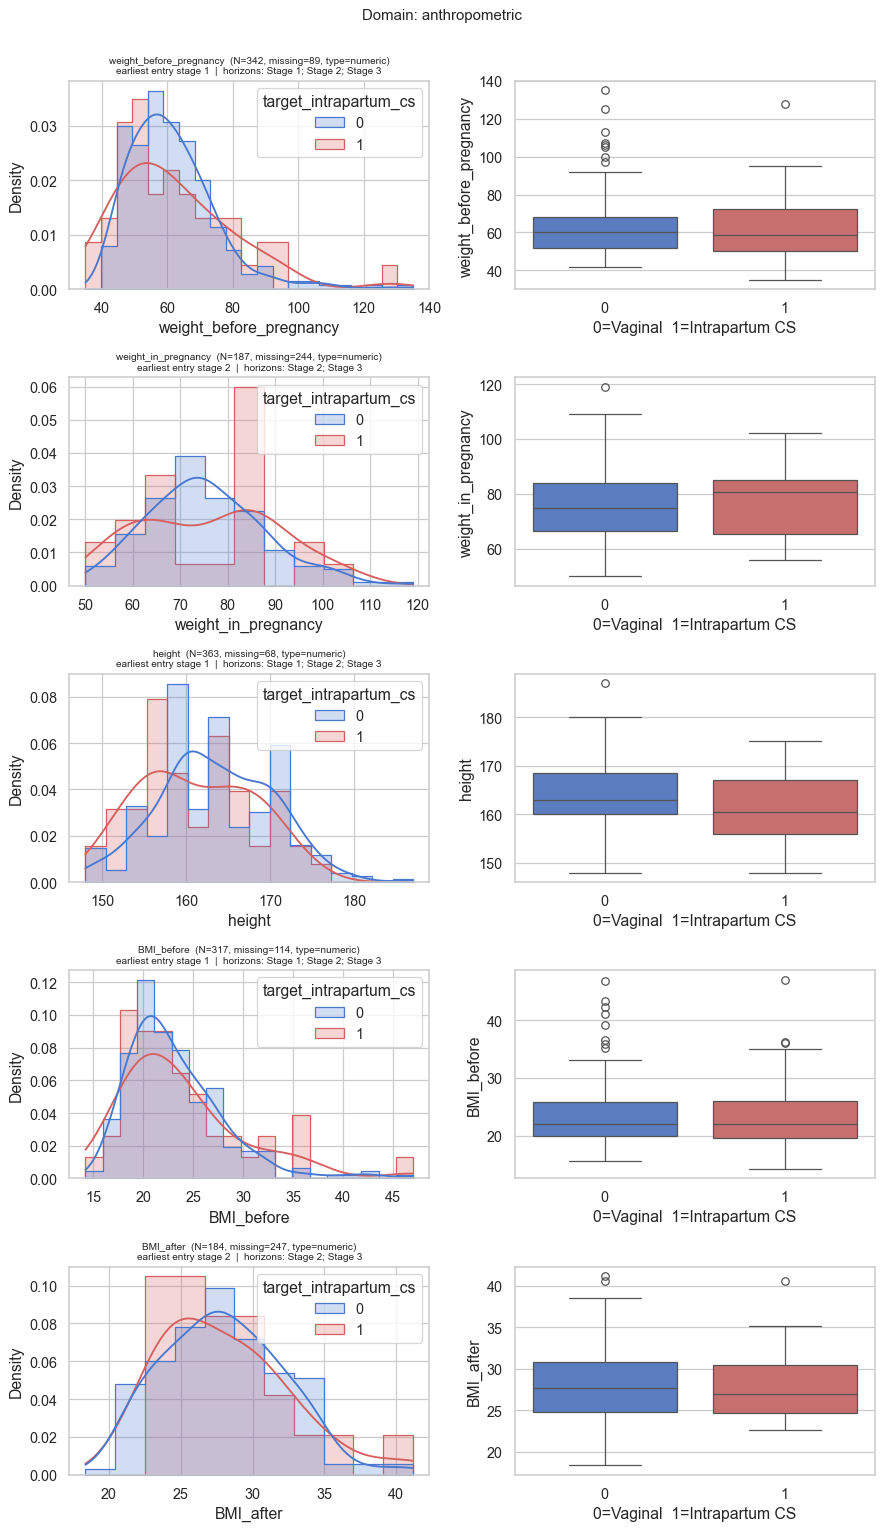

  Saved: <PROJECT_ROOT>\outputs\eda_c\figures\domain_anthropometric_distributions.png  (5 variables)


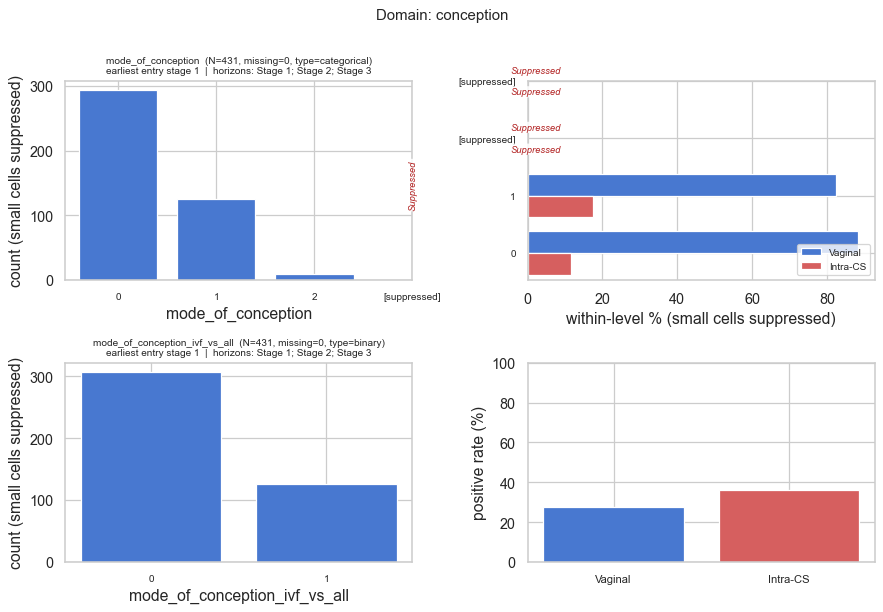

  Saved: <PROJECT_ROOT>\outputs\eda_c\figures\domain_conception_distributions.png  (2 variables)


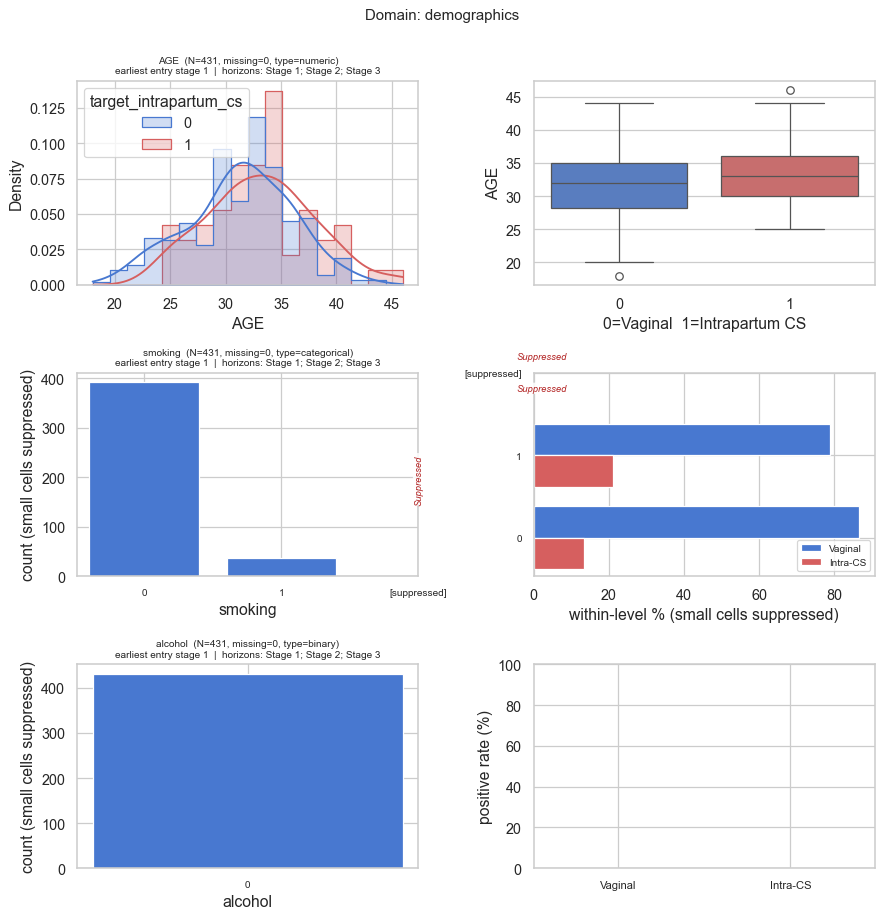

  Saved: <PROJECT_ROOT>\outputs\eda_c\figures\domain_demographics_distributions.png  (3 variables)


<TEMP_KERNEL_FILE>\2745047587.py:227: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


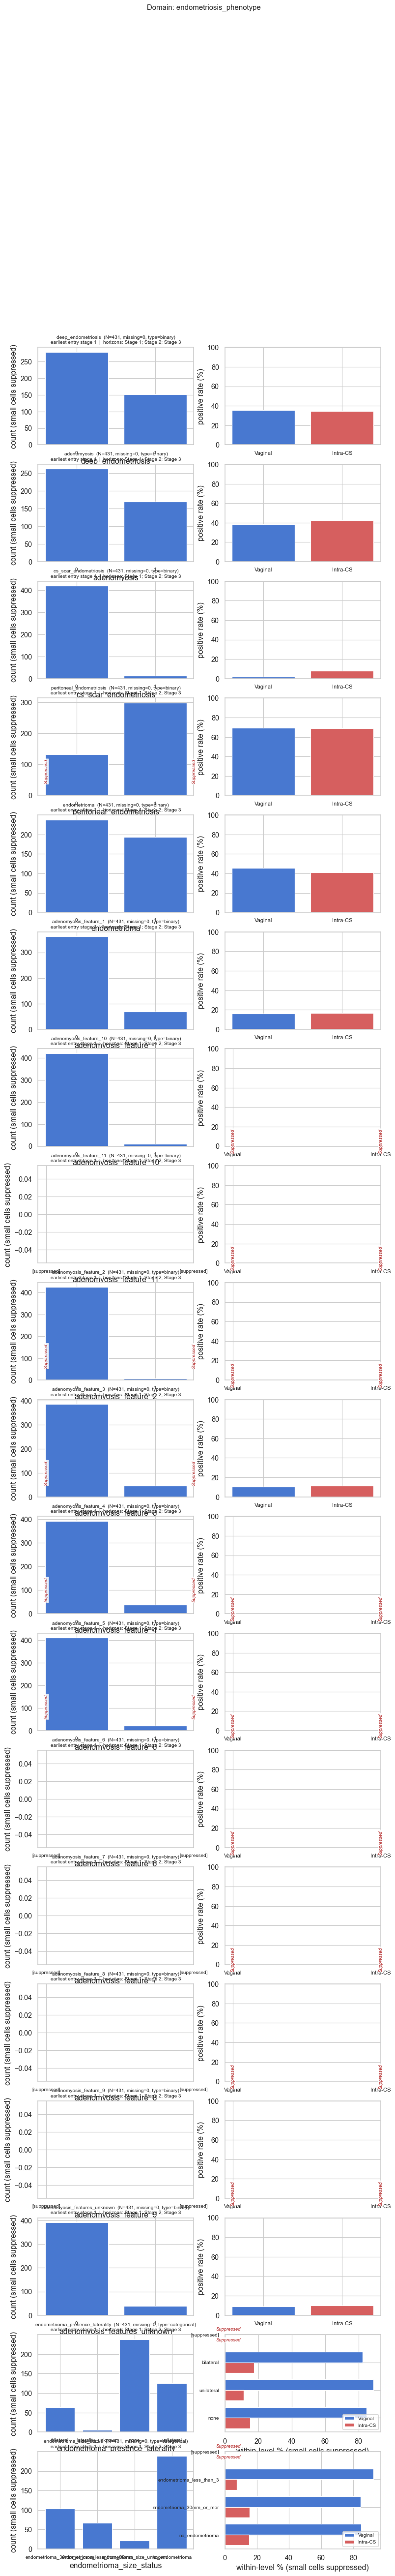

  Saved: <PROJECT_ROOT>\outputs\eda_c\figures\domain_endometriosis_phenotype_distributions.png  (19 variables)


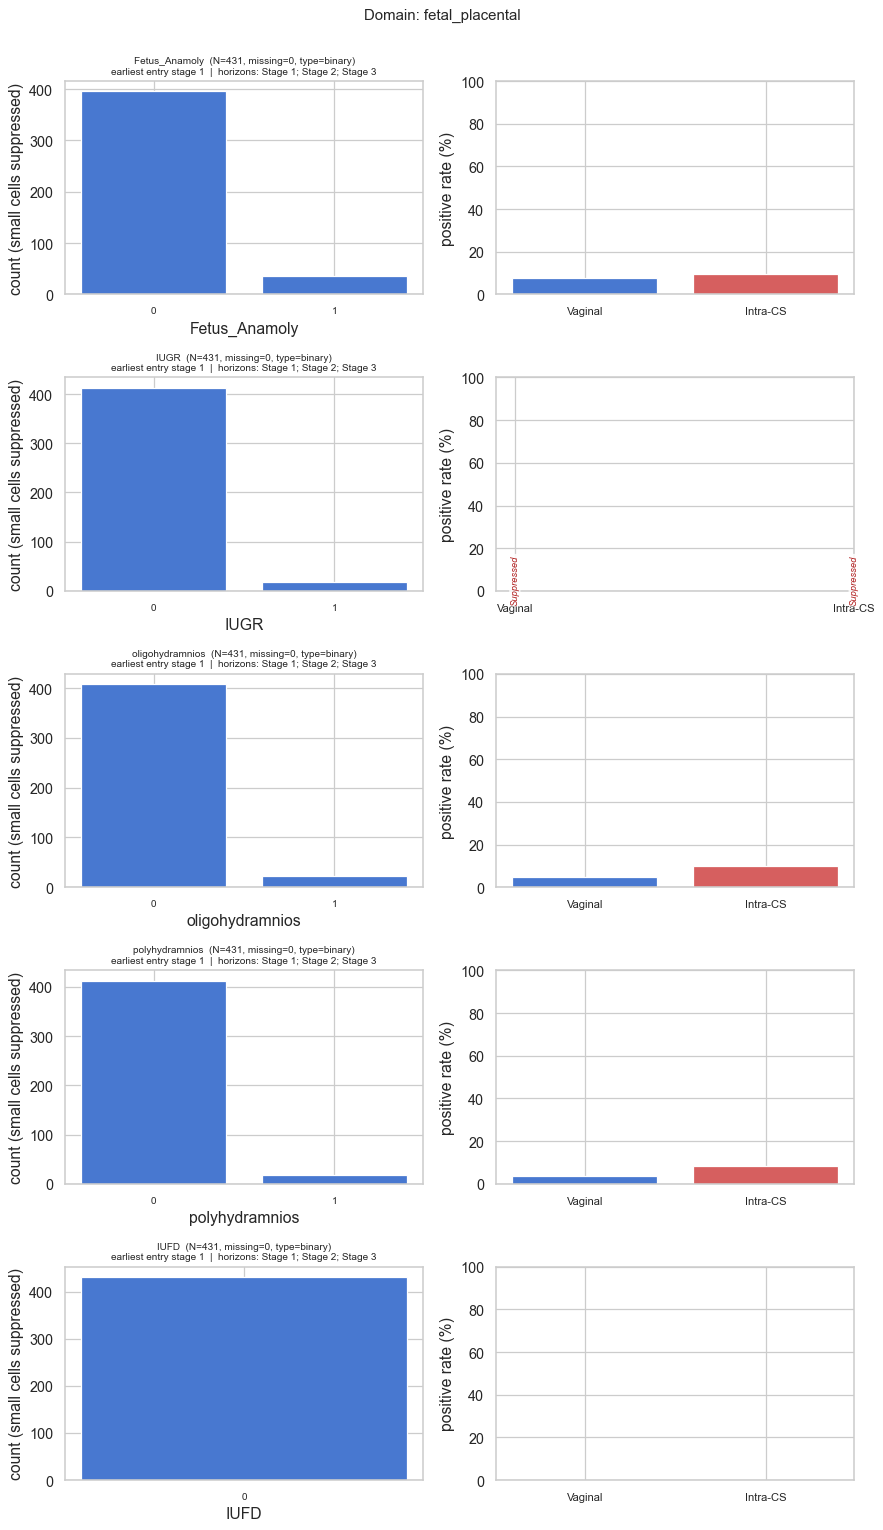

  Saved: <PROJECT_ROOT>\outputs\eda_c\figures\domain_fetal_placental_distributions.png  (5 variables)


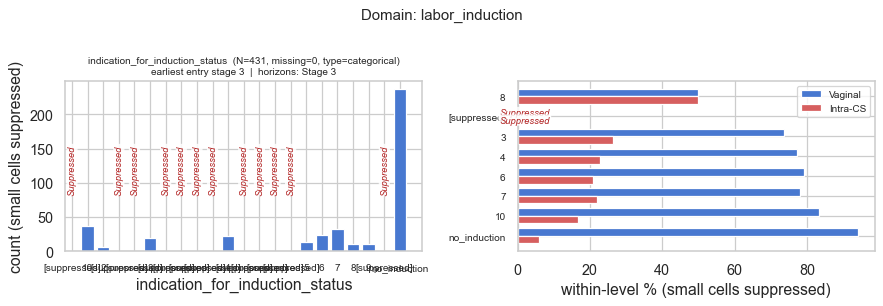

  Saved: <PROJECT_ROOT>\outputs\eda_c\figures\domain_labor_induction_distributions.png  (1 variables)


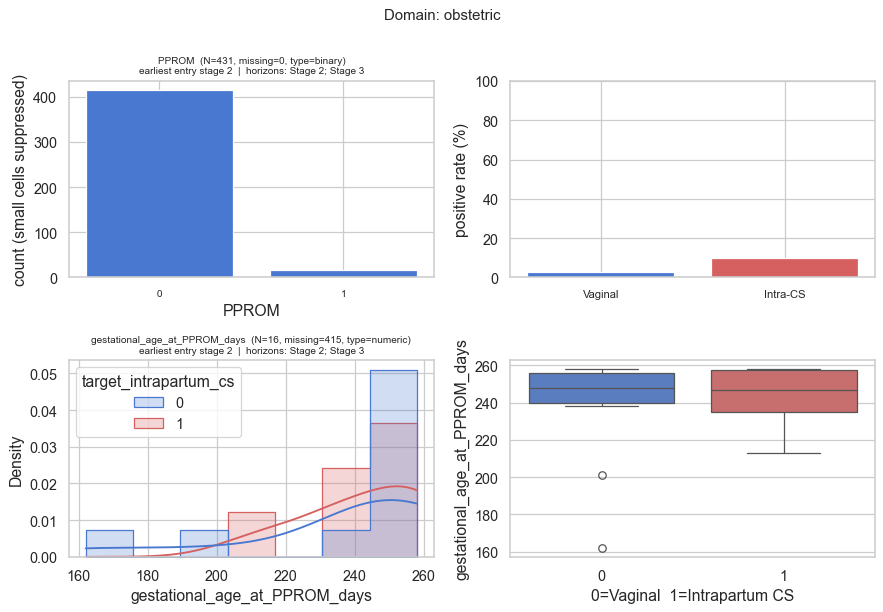

  Saved: <PROJECT_ROOT>\outputs\eda_c\figures\domain_obstetric_distributions.png  (2 variables)


<TEMP_KERNEL_FILE>\2745047587.py:227: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


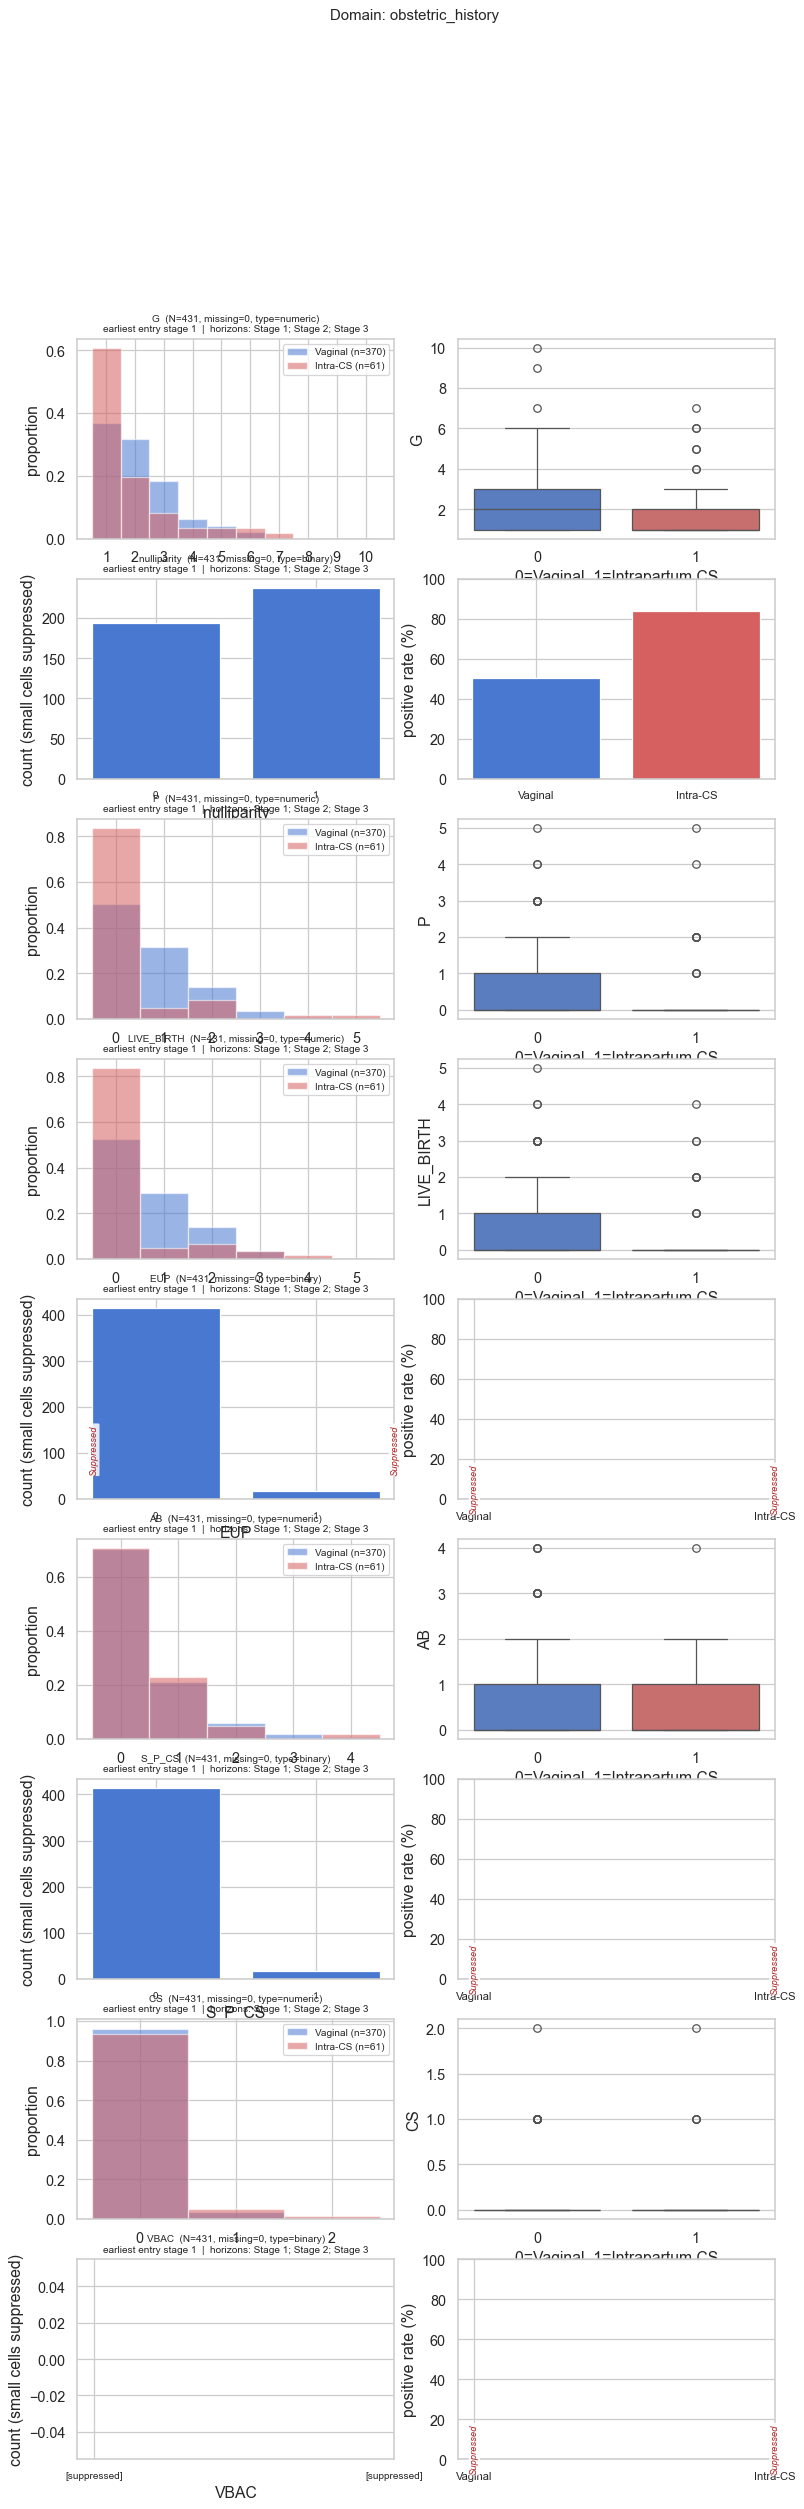

  Saved: <PROJECT_ROOT>\outputs\eda_c\figures\domain_obstetric_history_distributions.png  (9 variables)


<TEMP_KERNEL_FILE>\2745047587.py:227: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


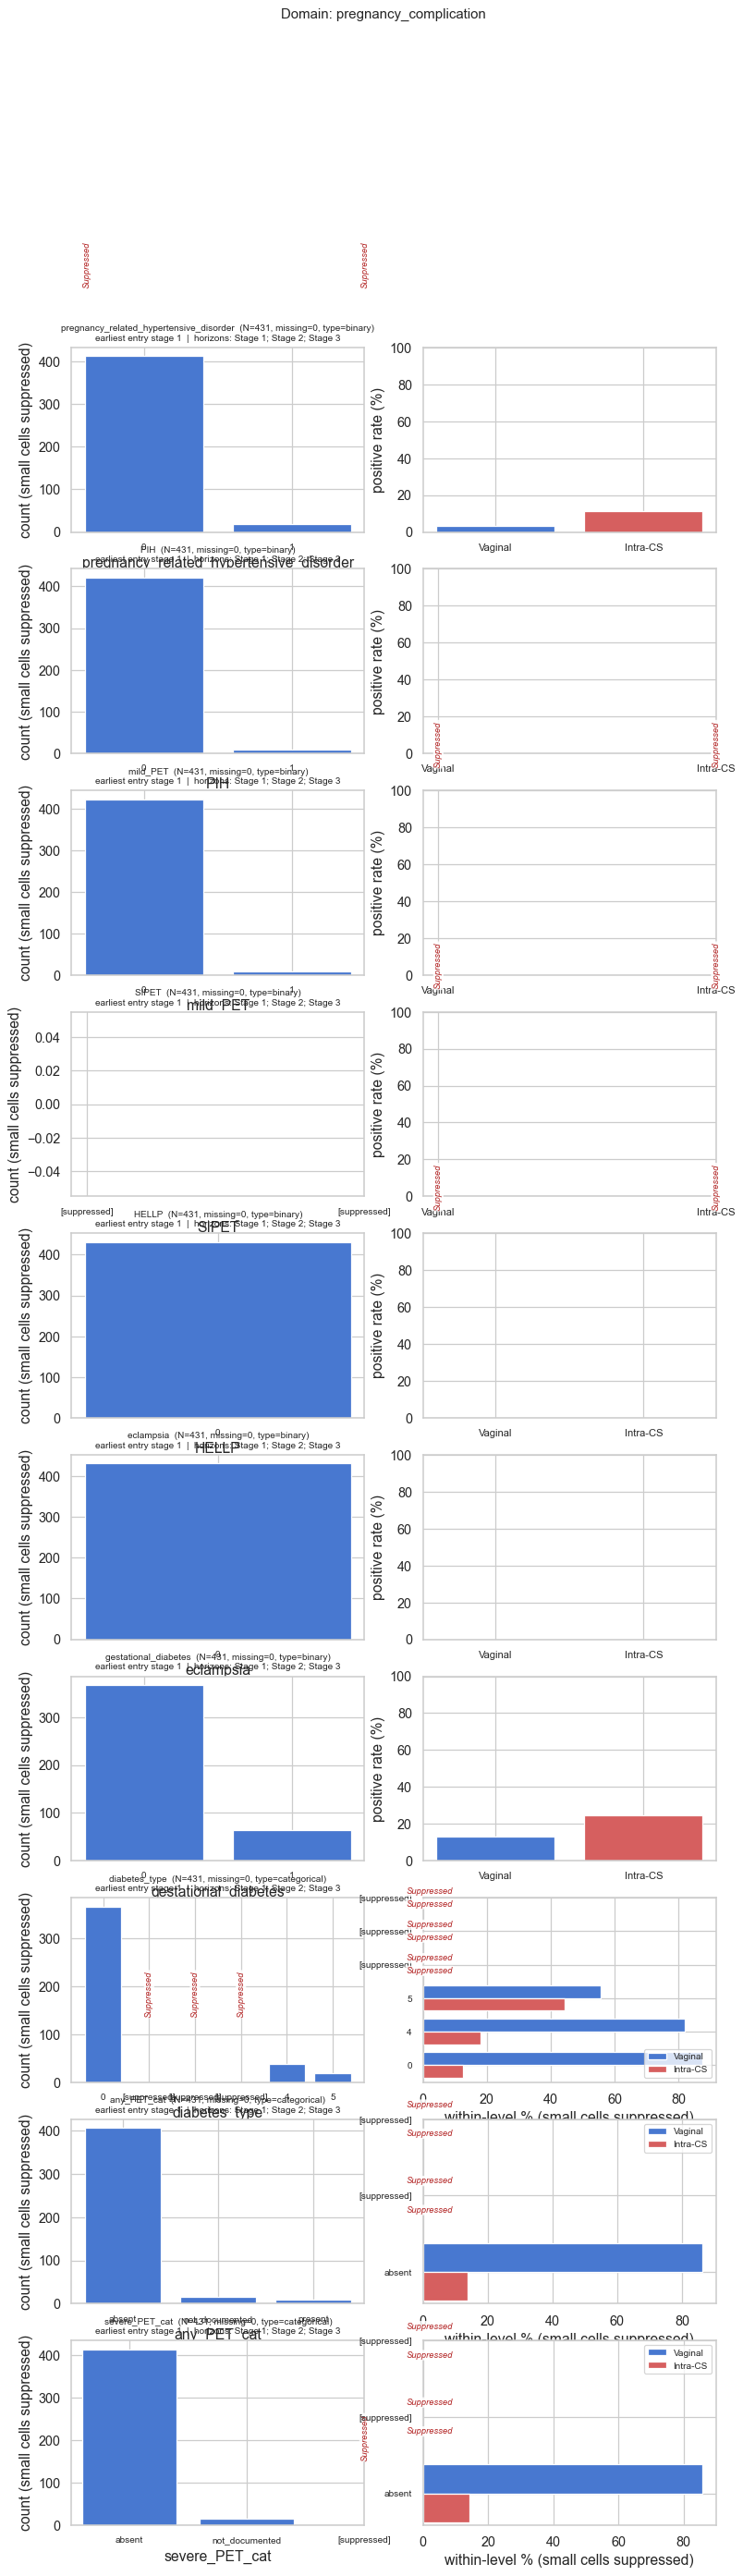

  Saved: <PROJECT_ROOT>\outputs\eda_c\figures\domain_pregnancy_complication_distributions.png  (10 variables)


<TEMP_KERNEL_FILE>\2745047587.py:227: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


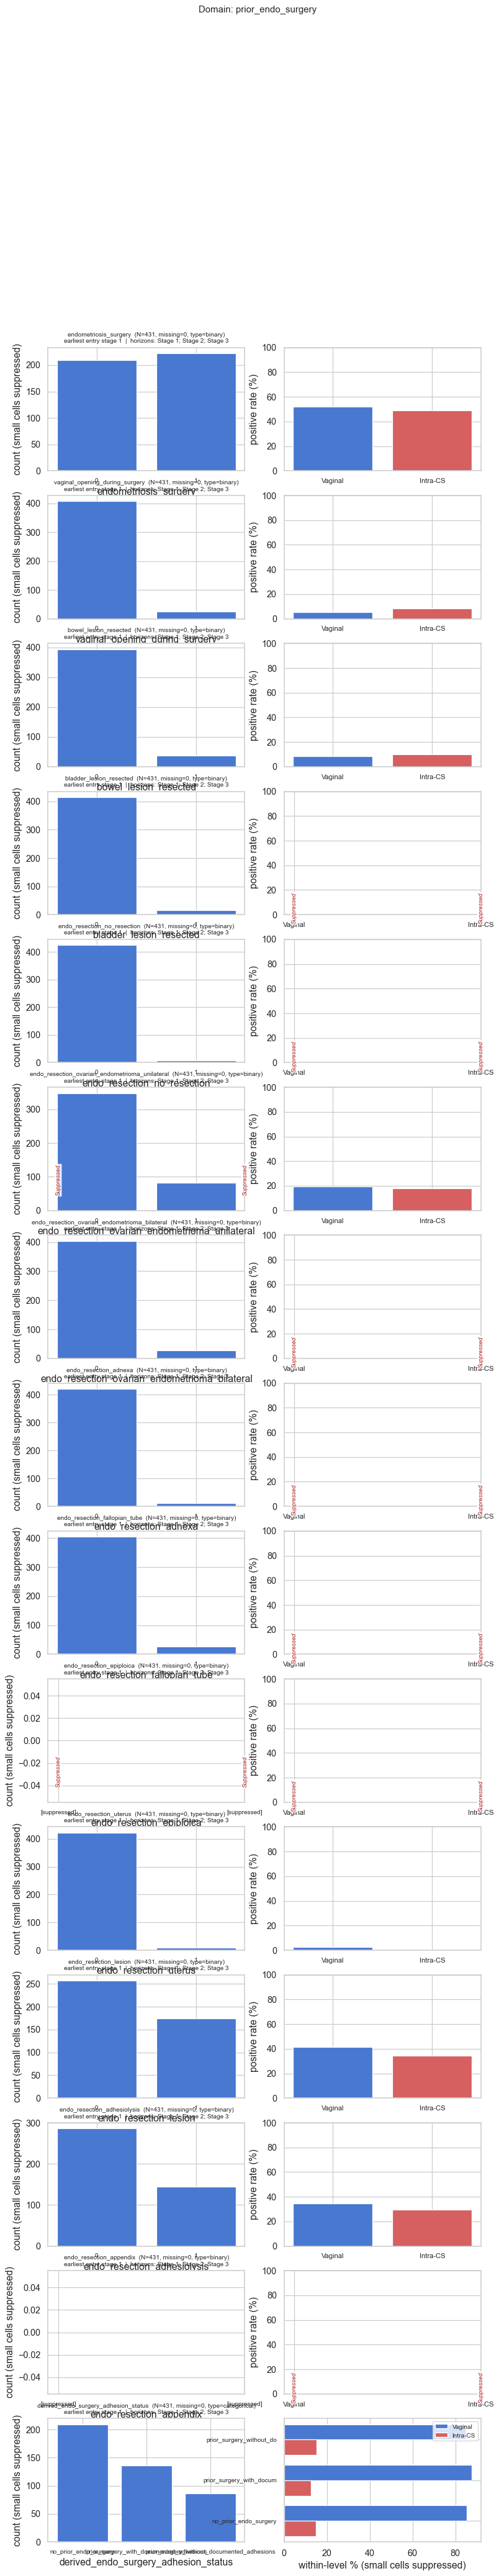

  Saved: <PROJECT_ROOT>\outputs\eda_c\figures\domain_prior_endo_surgery_distributions.png  (15 variables)


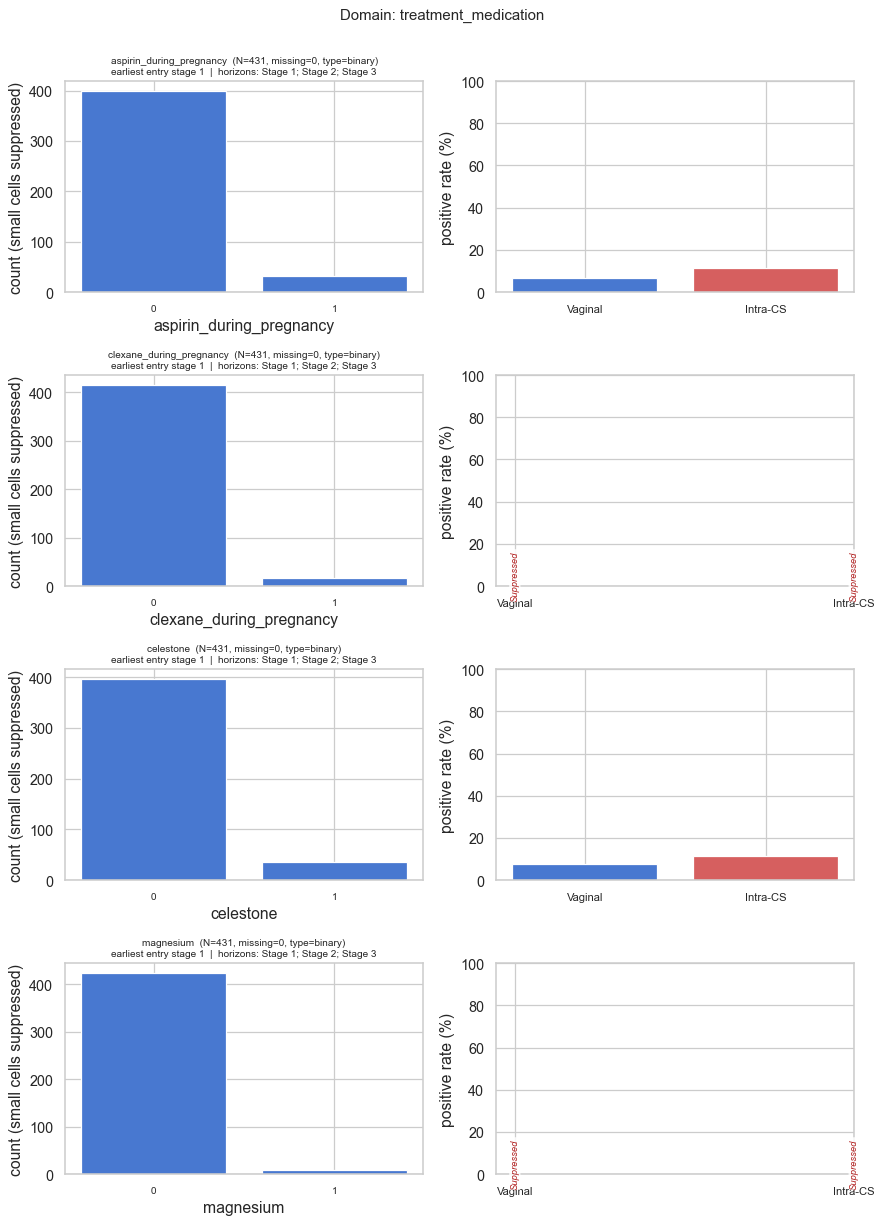

  Saved: <PROJECT_ROOT>\outputs\eda_c\figures\domain_treatment_medication_distributions.png  (4 variables)


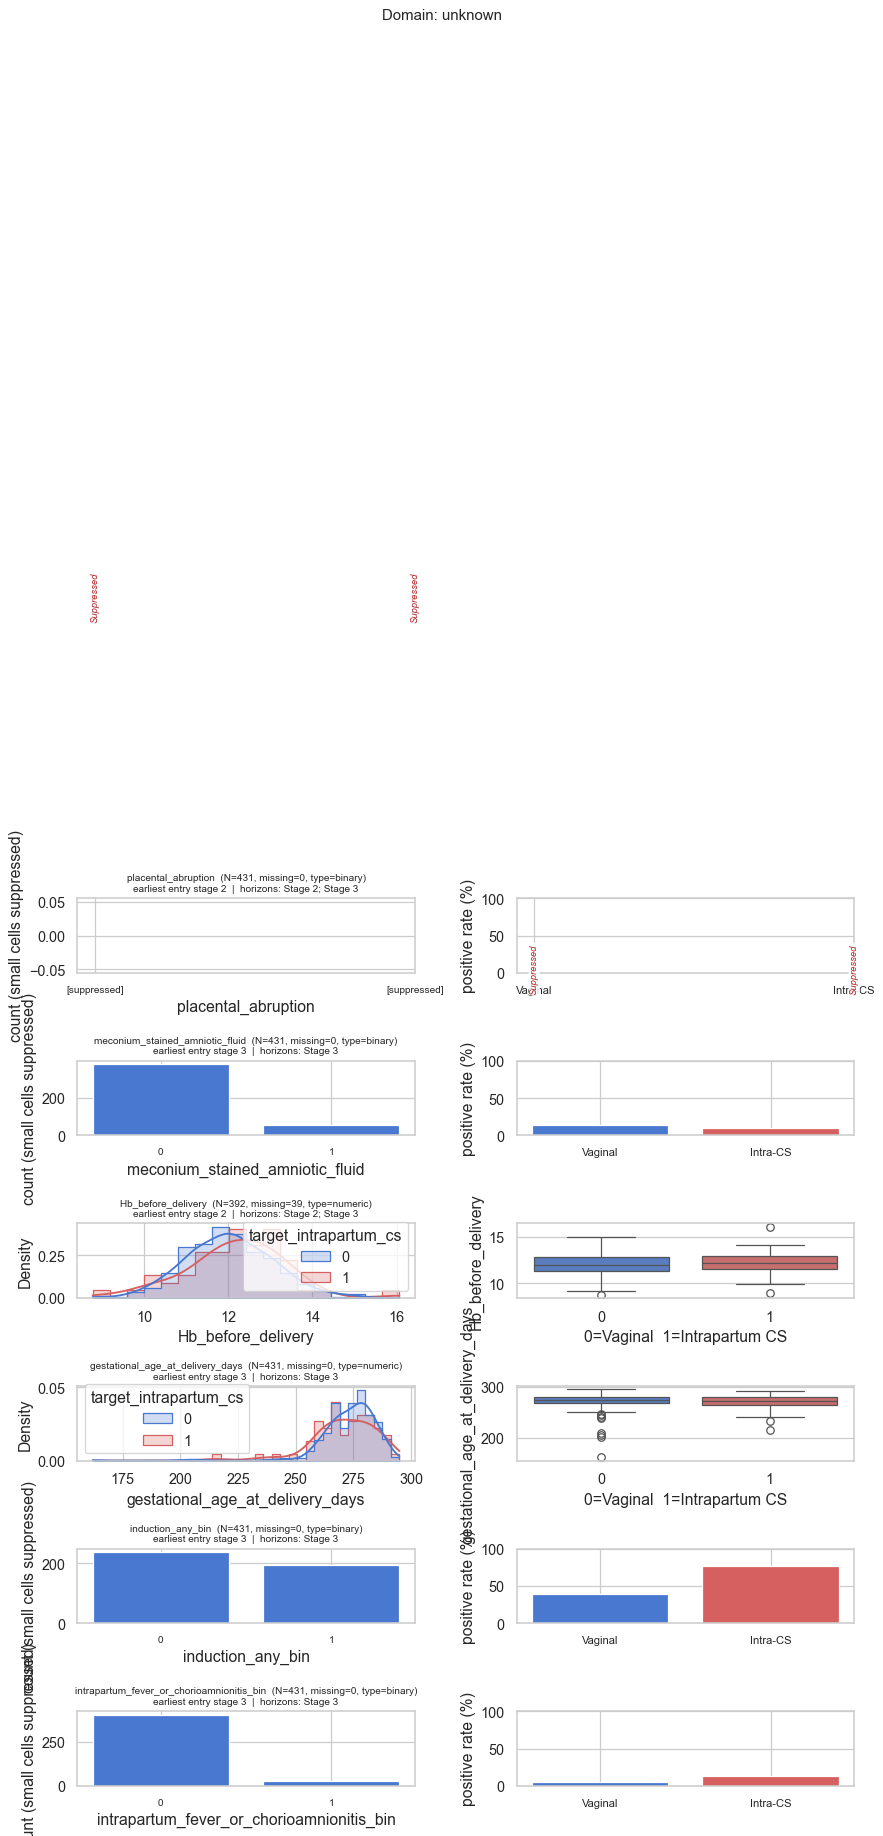

  Saved: <PROJECT_ROOT>\outputs\eda_c\figures\domain_unknown_distributions.png  (6 variables)

Saved 12 domain-grouped figures to <PROJECT_ROOT>\outputs\eda_c\figures

C4b PLOT-COVERAGE RECONCILIATION (vs ANALYSIS_VARS):
  expected variable count            : 81
  successfully plotted               : 81
  all-missing, explicitly skipped    : 0
  plotting failures                  : 0

Notes for manual review (informational only -- no automatic action taken):
  - weight_before_pregnancy: skewness=1.54 (already flagged in C7 outlier recheck)
  - BMI_before: skewness=1.60 (already flagged in C7 outlier recheck)
  - mode_of_conception: a level has a small aggregate count (already flagged in C6 sparsity gate; exact value suppressed here)
  - smoking: a level has a small aggregate count (already flagged in C6 sparsity gate; exact value suppressed here)
  - adenomyosis_feature_11: a level has a small aggregate count (already flagged in C6 sparsity gate; exact value suppressed here)
  - adenom

In [6]:
from pathlib import Path as _PathC4b

_FIG_DIR = (_root / "outputs" / "eda_c" / "figures") if _root else _PathC4b("outputs/eda_c/figures")
if "notebooks" in _FIG_DIR.resolve().parts:
    raise RuntimeError(
        f"EDA C figures directory resolved under 'notebooks/' ({_FIG_DIR.resolve()}) -- "
        "this indicates a working-directory/path-anchoring bug. Refusing to write "
        "figures to a non-canonical location."
    )
_FIG_DIR.mkdir(parents=True, exist_ok=True)

_SS = bool(SHARE_SAFE_MODE) if "SHARE_SAFE_MODE" in dir() else True
_SS_THRESHOLD = share_safe.DEFAULT_DISCLOSURE_THRESHOLD

# Cumulative prediction-horizon display, reused from C3/C3b -- stage membership is NOT rebuilt here.
_HORIZON_DISPLAY_C4B = {1: "Stage 1; Stage 2; Stage 3", 2: "Stage 2; Stage 3", 3: "Stage 3"}


def _c4b_stage_label(_col):
    _st = EARLIEST_ENTRY_STAGE.get(_col)
    if _st is None:
        return "earliest entry stage --"
    return f"earliest entry stage {_st}  |  horizons: {_HORIZON_DISPLAY_C4B.get(_st, '--')}"


def _safe_stem(name):
    return "".join(ch if (ch.isalnum() or ch in ("_", "-")) else "_" for ch in str(name))


def _c4b_is_discrete_count(s, max_range=15):
    # Port of a2_predictor_readiness._is_discrete_count: every non-missing value
    # is a whole number AND the observed range is small enough for per-integer
    # bins to stay readable (obstetric counts), as opposed to a wide-range
    # integer-valued measurement (AGE, diagnosis_year). Plotting-subtype only --
    # the variable's authoritative type is unchanged.
    s2 = s.dropna()
    if s2.empty:
        return False
    if not np.all(np.mod(s2.astype(float), 1) == 0):
        return False
    return (float(s2.max()) - float(s2.min())) <= max_range


def _c4b_annotate_suppressed(_ax, _x, _y, _rot=0):
    _ax.text(_x, _y, "Suppressed", ha="center", va="center", fontsize=7.5,
             fontstyle="italic", color="firebrick", rotation=_rot,
             bbox=dict(boxstyle="round,pad=0.12", fc="white", ec="none", alpha=0.85))


# Group ANALYSIS_VARS by domain (DOMAIN_MAP), same "unknown" fallback as C4.
_domain_groups = {}
for _col in ANALYSIS_VARS:
    _dom = DOMAIN_MAP.get(_col, "unknown")
    _domain_groups.setdefault(_dom, []).append(_col)

print("=" * 70)
print("C4b -- DISTRIBUTION PLOTS (diagnostic only -- no data changes)")
print("=" * 70)
print(f"Plotting {len(ANALYSIS_VARS)} baseline staged-analysis-universe variables "
      f"across {len(_domain_groups)} domain groups")
print(f"Figures saved to: {_FIG_DIR.resolve()}")
print(f"Share-safe figure rendering: {_SS} (small-cell threshold n<{_SS_THRESHOLD}; "
      "presentation layer only -- analytical values unaffected)")
print()

_saved_figures = []
_plot_notes = []
_c4b_coverage_rows = []

for _dom, _cols in sorted(_domain_groups.items()):
    _n = len(_cols)
    _fig, _axes = plt.subplots(_n, 2, figsize=(10, 3.4 * _n), squeeze=False)
    for _i, _col in enumerate(_cols):
        _ax_left, _ax_right = _axes[_i, 0], _axes[_i, 1]
        _vtype = infer_var_type(df_analysis[_col])
        _stage = EARLIEST_ENTRY_STAGE.get(_col)
        _cov = {
            "variable": _col, "type": _vtype, "domain": _dom,
            "earliest_entry_stage": _stage if _stage is not None else "",
            "plot_status": "plotted", "reason": "",
        }
        _data = df_analysis[[_col, TARGET_COL]].dropna()
        _n_miss = int(df_analysis[_col].isna().sum())
        _n_obs = int(_data.shape[0])
        if _data.empty:
            _ax_left.set_visible(False)
            _ax_right.set_visible(False)
            _cov["plot_status"] = "skipped_all_missing"
            _cov["reason"] = "variable is 100% missing in the cleaned analysis universe"
            _c4b_coverage_rows.append(_cov)
            _plot_notes.append(f"{_col}: all missing -- skipped (documented in c4b_plot_coverage_df)")
            continue
        try:
            if _vtype == "numeric":
                _discrete = _c4b_is_discrete_count(df_analysis[_col])
                if _discrete:
                    _lo, _hi = int(_data[_col].min()), int(_data[_col].max())
                    _bins = np.arange(_lo - 0.5, _hi + 1.5, 1)
                    for _tv, _clr, _lab in [(0, _C0, "Vaginal"), (1, _C1, "Intra-CS")]:
                        _vals = _data.loc[_data[TARGET_COL] == _tv, _col]
                        _ax_left.hist(_vals, bins=_bins, alpha=0.55, color=_clr,
                                      density=True, label=f"{_lab} (n={len(_vals)})")
                    _ax_left.set_xticks(range(_lo, _hi + 1))
                    _ax_left.set_ylabel("proportion")
                    _ax_left.legend(fontsize=8)
                else:
                    sns.histplot(
                        data=_data, x=_col, hue=TARGET_COL, stat="density", common_norm=False,
                        kde=True, element="step", ax=_ax_left, palette={0: _C0, 1: _C1},
                    )
                sns.boxplot(
                    data=_data, x=TARGET_COL, y=_col, hue=TARGET_COL, ax=_ax_right,
                    palette={0: _C0, 1: _C1}, legend=False,
                )
                _ax_right.set_xlabel("0=Vaginal  1=Intrapartum CS")
                _skew = float(df_analysis[_col].dropna().skew())
                _cov["reason"] = ("discrete integer count: integer-aligned bins, no KDE"
                                  if _discrete else "continuous: histogram + KDE")
                if abs(_skew) > 1.5:
                    _plot_notes.append(
                        f"{_col}: skewness={_skew:.2f} (already flagged in C7 outlier recheck)"
                    )
            else:
                # ---- LEFT: aggregate level-count bar, share-safe masked -------
                _vc = df_analysis[_col].value_counts().sort_index()
                _cohort_n = int(df_analysis[_col].notna().sum())
                _heights, _labels, _supp_idx = [], [], []
                for _k, (_lev, _cnt) in enumerate(_vc.items()):
                    _disp = share_safe.safe_count_with_complement(
                        int(_cnt), _cohort_n, threshold=_SS_THRESHOLD, enabled=_SS)
                    if isinstance(_disp, str):
                        _heights.append(np.nan)
                        _labels.append("[suppressed]")
                        _supp_idx.append(_k)
                    else:
                        _heights.append(int(_cnt))
                        _labels.append(str(_lev))
                _xs = list(range(len(_vc)))
                _ax_left.bar([x for x, h in zip(_xs, _heights) if not np.isnan(h)],
                             [h for h in _heights if not np.isnan(h)], color=_C0)
                _ymax = max([h for h in _heights if not np.isnan(h)], default=1)
                for _k in _supp_idx:
                    _c4b_annotate_suppressed(_ax_left, _k, _ymax * 0.5, _rot=90)
                _ax_left.set_xticks(_xs)
                _ax_left.set_xticklabels(_labels, fontsize=8)
                _ax_left.set_xlabel(_col)
                _ax_left.set_ylabel("count (small cells suppressed)")

                # ---- RIGHT: target-stratified rate, share-safe masked --------
                _sub = df_analysis[[_col, TARGET_COL]].dropna(subset=[_col])
                _g0n = int((_sub[TARGET_COL] == 0).sum())
                _g1n = int((_sub[TARGET_COL] == 1).sum())
                if _vtype == "binary":
                    _obs_codes = set()
                    for _v in _sub[_col].dropna().unique():
                        try:
                            _obs_codes.add(int(_v))
                        except (TypeError, ValueError):
                            _obs_codes.add(_v)
                    _pos0 = int((pd.to_numeric(_sub.loc[_sub[TARGET_COL] == 0, _col], errors="coerce") == 1).sum())
                    _pos1 = int((pd.to_numeric(_sub.loc[_sub[TARGET_COL] == 1, _col], errors="coerce") == 1).sum())
                    _d0, _d1 = share_safe.suppress_binary_target_display(
                        _pos0, _pos1, _g0n, _g1n, threshold=_SS_THRESHOLD, enabled=_SS)
                    _r0 = (round(_pos0 / _g0n * 100, 1) if (_g0n and not isinstance(_d0, str)) else np.nan)
                    _r1 = (round(_pos1 / _g1n * 100, 1) if (_g1n and not isinstance(_d1, str)) else np.nan)
                    _ax_right.bar([0, 1], [_r0, _r1], color=[_C0, _C1])
                    for _bx, _bv in zip([0, 1], [_r0, _r1]):
                        if np.isnan(_bv):
                            _c4b_annotate_suppressed(_ax_right, _bx, 5, _rot=90)
                    _ax_right.set_xticks([0, 1])
                    _ax_right.set_xticklabels(["Vaginal", "Intra-CS"], fontsize=9)
                    _ax_right.set_ylabel("positive rate (%)")
                    _ax_right.set_ylim(0, max(100, np.nanmax([_r0, _r1, 1]) * 1.15))
                else:
                    _levels = list(_sub[_col].value_counts().index[:8])
                    _ct = pd.crosstab(_sub[_col], _sub[TARGET_COL]).reindex(_levels).fillna(0)
                    _v0 = _ct.get(0, pd.Series(0, index=_ct.index))
                    _v1 = _ct.get(1, pd.Series(0, index=_ct.index))
                    _tot = (_v0 + _v1)
                    _p0, _p1, _lbls = [], [], []
                    for _lev in _levels:
                        _c0, _c1, _t = int(_v0.get(_lev, 0)), int(_v1.get(_lev, 0)), int(_tot.get(_lev, 0))
                        _pd0 = share_safe.safe_pct_with_denominator(_c0, _t, threshold=_SS_THRESHOLD, enabled=_SS)[0]
                        _pd1 = share_safe.safe_pct_with_denominator(_c1, _t, threshold=_SS_THRESHOLD, enabled=_SS)[0]
                        _p0.append(_pd0 if isinstance(_pd0, (int, float)) else np.nan)
                        _p1.append(_pd1 if isinstance(_pd1, (int, float)) else np.nan)
                        _both_supp = (not isinstance(_pd0, (int, float))) and (not isinstance(_pd1, (int, float)))
                        _lbls.append("[suppressed]" if _both_supp else str(_lev)[:24])
                    _yy = np.arange(len(_levels))
                    _hh = 0.38
                    _ax_right.barh(_yy + _hh / 2, _p0, _hh, color=_C0, label="Vaginal")
                    _ax_right.barh(_yy - _hh / 2, _p1, _hh, color=_C1, label="Intra-CS")
                    for _bi, (_a, _b) in enumerate(zip(_p0, _p1)):
                        if np.isnan(_a):
                            _c4b_annotate_suppressed(_ax_right, 2, _bi + _hh / 2)
                        if np.isnan(_b):
                            _c4b_annotate_suppressed(_ax_right, 2, _bi - _hh / 2)
                    _ax_right.set_yticks(list(_yy))
                    _ax_right.set_yticklabels(_lbls, fontsize=8)
                    _ax_right.set_xlabel("within-level % (small cells suppressed)")
                    _ax_right.legend(fontsize=8)
                _min_level_n = int(_vc.min()) if len(_vc) else 0
                _cov["reason"] = "binary/categorical: share-safe level-count + target-stratified rate"
                if _min_level_n < 5:
                    _plot_notes.append(
                        f"{_col}: a level has a small aggregate count (already flagged in C6 sparsity gate; "
                        "exact value suppressed here)"
                    )
        except Exception as _e:
            _ax_left.set_visible(False)
            _ax_right.set_visible(False)
            _cov["plot_status"] = "failed"
            _cov["reason"] = f"{type(_e).__name__}: {_e}"
            _c4b_coverage_rows.append(_cov)
            _plot_notes.append(f"{_col}: PLOTTING FAILED ({type(_e).__name__}: {_e})")
            continue
        # share-safe title -- no exact protected count in the title
        _n_obs_disp = share_safe.safe_count_with_complement(
            _n_obs, len(df_analysis), threshold=_SS_THRESHOLD, enabled=_SS)
        _n_miss_disp = share_safe.safe_count(_n_miss, threshold=_SS_THRESHOLD, enabled=_SS)
        _ax_left.set_title(
            f"{_col}  (N={_n_obs_disp}, missing={_n_miss_disp}, type={_vtype})\n{_c4b_stage_label(_col)}",
            fontsize=8,
        )
        _c4b_coverage_rows.append(_cov)
    _fig.suptitle(f"Domain: {_dom}", fontsize=12, y=1.0)
    plt.tight_layout()
    _out_path = _FIG_DIR / f"domain_{_safe_stem(_dom)}_distributions.png"
    _fig.savefig(_out_path, dpi=110, bbox_inches="tight")
    _saved_figures.append(str(_out_path))
    plt.show()
    plt.close(_fig)
    print(f"  Saved: {_out_path}  ({_n} variables)")

# ── Plot-coverage reconciliation ──────────────────────────────────────────────
c4b_plot_coverage_df = pd.DataFrame(_c4b_coverage_rows)[
    ["variable", "type", "domain", "earliest_entry_stage", "plot_status", "reason"]
]
_expected_n = len(ANALYSIS_VARS)
_covered = set(c4b_plot_coverage_df["variable"])
_missing_from_coverage = sorted(set(ANALYSIS_VARS) - _covered)
_extra_in_coverage = sorted(_covered - set(ANALYSIS_VARS))
_n_plotted = int((c4b_plot_coverage_df["plot_status"] == "plotted").sum())
_n_all_missing = int((c4b_plot_coverage_df["plot_status"] == "skipped_all_missing").sum())
_n_failed = int((c4b_plot_coverage_df["plot_status"] == "failed").sum())

print()
print(f"Saved {len(_saved_figures)} domain-grouped figures to {_FIG_DIR.resolve()}")
print()
print("C4b PLOT-COVERAGE RECONCILIATION (vs ANALYSIS_VARS):")
print(f"  expected variable count            : {_expected_n}")
print(f"  successfully plotted               : {_n_plotted}")
print(f"  all-missing, explicitly skipped    : {_n_all_missing}")
print(f"  plotting failures                  : {_n_failed}")
if _missing_from_coverage:
    print(f"  NOT accounted for in coverage table: {_missing_from_coverage}")
if _extra_in_coverage:
    print(f"  coverage rows not in ANALYSIS_VARS : {_extra_in_coverage}")
if _n_failed:
    print()
    print("  Failed variables:")
    for _r in c4b_plot_coverage_df[c4b_plot_coverage_df["plot_status"] == "failed"].to_dict("records"):
        print(f"    - {_r['variable']} ({_r['type']}): {_r['reason']}")
if _plot_notes:
    print()
    print("Notes for manual review (informational only -- no automatic action taken):")
    for _note in _plot_notes:
        print(f"  - {_note}")

# A canonical run must not silently claim full visual coverage when an
# analyzable variable failed to plot, or when a variable is unaccounted for.
if _missing_from_coverage or _extra_in_coverage:
    raise RuntimeError(
        "C4b coverage reconciliation FAILED: coverage table does not match "
        f"ANALYSIS_VARS (missing={_missing_from_coverage}, extra={_extra_in_coverage})."
    )
if _n_failed:
    raise RuntimeError(
        f"C4b: {_n_failed} analyzable variable(s) failed to plot (see the list above). "
        "Refusing to let a canonical run report full visual coverage with unresolved "
        "plotting failures. An all-missing variable may be skipped; a plotting-"
        "implementation error must be fixed."
    )
print()
print(f"C4b coverage reconciled: {_n_plotted} plotted + {_n_all_missing} all-missing-skipped "
      f"= {_expected_n} ANALYSIS_VARS members; 0 unresolved failures.")
print("No rows, columns, or values were changed. No variable was dropped, reclassified, or "
      "made (in)eligible based on these plots. Share-safe suppression affects the rendered "
      "figure surface only.")

## Section C4c — Before-Versus-After Cleaning: Column Summary / Cleaning-Effect Comparison

**Purpose:** For columns Data Cleaning B actually changed (per its own audit
trail, `cleaning_b_column_actions.csv` — not re-derived here), show a
**column-level before-versus-after summary** so the cleaning effect is visible
rather than only described: `dtype`, missingness, distinct-value count, and the
recorded B action metadata, comparing the raw Batch 18 column against the
cleaned column reaching this notebook.

**This is a column summary / cleaning-effect comparison, not a row-level value
comparison.** No validated row-alignment contract between Batch 18 and Batch 19
is asserted here, so C4c deliberately does **not** attempt a per-row
old-value → new-value diff. (A genuine value-level comparison could be added
only if a canonical, validated Batch18→Batch19 row-alignment contract existed;
a fragile row-order-based join is not used just to satisfy older wording.)

**Canonical inputs only.** Both files are resolved from repository-root
canonical paths — the action log from the current Data Cleaning B audit
location (`outputs/data_cleaning/audit/`), Batch 18 from
`outputs/preprocessing/processed/` (used **only** as the pre-B comparison
source, never as EDA C's analytical input — EDA C's analytical input is the
SHA-verified Batch 19 from C3). There is **no** current-working-directory
alternate: if a canonical file is unavailable the section discloses that and
shows what it can, but never silently takes a same-named file from the CWD.

**Scope.** Restricted to changed columns that are in the current staged
analytical universe (`ANALYSIS_VARS`) **or** are a direct B source-column /
`redundant_with` counterpart of a registered representation that is itself in
`ANALYSIS_VARS`. This is an intentional restriction expressed through current
metadata — not the accidental `ANALYSIS_VARS ∪ df.columns` union (which, because
`df.columns` is the whole cleaned universe, made the `ANALYSIS_VARS` restriction
meaningless). C4c does not repeat the full Data Cleaning B report.

In [7]:
# ── B1: canonical repository-root paths ONLY -- no CWD alternate ───────────────
_actions_path = (
    (_root / CLEANED_AUDIT_SUBPATH / "cleaning_b_column_actions.csv")
    if _root is not None else None
)
_raw18_path = (
    (_root / PREPROC_PROCESSED_SUBPATH / "work_df_batch18.xlsx")
    if _root is not None else None
)

if _actions_path is None or not _actions_path.is_file():
    print("C4c: canonical Data Cleaning B action log "
          f"({_actions_path if _actions_path is not None else 'outputs/data_cleaning/audit/cleaning_b_column_actions.csv'}) "
          "is unavailable -- before/after column summary skipped. No CWD-local "
          "substitute is used.")
else:
    _actions_df = pd.read_csv(_actions_path)
    _changed_actions = _actions_df[_actions_df["action"].astype(str) != "none"].copy()
    print(f"Data Cleaning B column actions with a recorded change: {len(_changed_actions)} "
          f"(of {len(_actions_df)} audited columns)")
    print(_changed_actions["action"].value_counts().to_string())
    print()

    # ── B4: safe boolean parsing of CSV audit fields ─────────────────────────
    _BOOL_TRUE = {"true", "1", "yes", "y", "t"}
    _BOOL_FALSE = {"false", "0", "no", "n", "f", "", "nan", "none", "na"}

    def _audit_bool(_v, _field, _col):
        # Never use Python bool("False")/bool(nan) semantics on a CSV cell.
        if isinstance(_v, bool):
            return _v
        if _v is None or (isinstance(_v, float) and pd.isna(_v)):
            return False
        _s = str(_v).strip().lower()
        if _s in _BOOL_TRUE:
            return True
        if _s in _BOOL_FALSE:
            return False
        raise ValueError(
            f"C4c: audit field {_field!r} for column {_col!r} has an unrecognized "
            f"boolean value {_v!r} -- refusing to silently coerce it to True. Fix "
            "cleaning_b_column_actions.csv or extend the recognized token set."
        )

    # ── B3: intentional scope via current metadata (NOT ANALYSIS_VARS | df.columns)
    _scope = set(ANALYSIS_VARS)
    _fd_scope = B_FEATURE_DICT if ("B_FEATURE_DICT" in dir() and B_FEATURE_DICT is not None) else None
    if _fd_scope is not None:
        for _r in _fd_scope.to_dict("records"):
            _newc = str(_r.get("new_column", "")).strip()
            if _newc not in _scope:
                continue
            for _key in ("source_column", "redundant_with"):
                _val = _r.get(_key)
                if _val is None or (isinstance(_val, float) and pd.isna(_val)):
                    continue
                for _piece in str(_val).replace(";", ",").split(","):
                    _piece = _piece.strip()
                    if _piece and _piece.lower() not in ("nan", "unset", "none", "na", ""):
                        _scope.add(_piece)

    _in_scope_changed = sorted(set(_changed_actions["column"].astype(str)) & _scope)
    print(f"Changed columns relevant to the current staged analytical universe: "
          f"{len(_in_scope_changed)}")
    print("  (ANALYSIS_VARS members + direct B source-column / redundant_with counterparts "
          "of registered representations in ANALYSIS_VARS)")

    _df_raw18 = None
    if _raw18_path is None or not _raw18_path.is_file():
        print()
        print("Canonical work_df_batch18.xlsx is unavailable at "
              f"{_raw18_path if _raw18_path is not None else 'outputs/preprocessing/processed/'} "
              "-- showing B action-log metadata only, no before/after column summary. "
              "No CWD-local substitute is used.")
        for _col in _in_scope_changed[:20]:
            _row = _changed_actions[_changed_actions["column"].astype(str) == _col].iloc[0]
            print(f"  {_col}: action={_row['action']} | detail={_row.get('detail', '')}")
    else:
        _df_raw18 = pd.read_excel(_raw18_path)
        _compare_rows = []
        _metadata_only = []
        for _col in _in_scope_changed:
            _row = _changed_actions[_changed_actions["column"].astype(str) == _col].iloc[0]
            _rcc = _audit_bool(_row.get("row_count_changed"), "row_count_changed", _col)
            _imp = _audit_bool(_row.get("imputation_performed"), "imputation_performed", _col)
            if _col not in _df_raw18.columns or _col not in df.columns:
                # B source column that was renamed/consolidated away, or a
                # representation with no raw 'before' counterpart -- metadata only.
                _metadata_only.append({
                    "column": _col, "action": _row["action"],
                    "in_batch18": _col in _df_raw18.columns,
                    "in_batch19": _col in df.columns,
                    "row_count_changed": _rcc, "imputation_performed": _imp,
                    "detail": str(_row.get("detail", "")),
                })
                continue
            _raw_s = _df_raw18[_col]
            _clean_s = df[_col]
            _compare_rows.append({
                "column": _col,
                "action": _row["action"],
                "dtype_before": str(_raw_s.dtype),
                "dtype_after": str(_clean_s.dtype),
                "missing_before": int(_raw_s.isna().sum()),
                "missing_after": int(_clean_s.isna().sum()),
                "n_unique_before": int(_raw_s.nunique(dropna=True)),
                "n_unique_after": int(_clean_s.nunique(dropna=True)),
                "row_count_changed": _rcc,
                "imputation_performed": _imp,
            })
        cleaning_effect_comparison_df = pd.DataFrame(_compare_rows)
        if len(cleaning_effect_comparison_df):
            print()
            print("Before (Batch 18, raw) vs after (Batch 19, cleaned) -- COLUMN-LEVEL "
                  "summary for in-scope changed columns (dtype / missingness / distinct "
                  "values / B action metadata; NOT a row-level value diff):")
            print(cleaning_effect_comparison_df.to_string(index=False))
        else:
            print()
            print("No in-scope changed column was present under the same name in both "
                  "Batch 18 and Batch 19.")
        if _metadata_only:
            print()
            print("In-scope changed columns with no aligned same-name before/after pair "
                  "(B rename / consolidation / new representation) -- action metadata only:")
            print(pd.DataFrame(_metadata_only).to_string(index=False))

    print()
    print("This section reflects Data Cleaning B's own recorded actions only. It is a "
          "column-level before/after summary (cleaning-effect comparison), not a row-level "
          "value comparison; it does not repeat the full preprocessing report and does not "
          "change any value, row, classification, or eligibility here. Batch 18 is used "
          "solely as the pre-B comparison source; EDA C's analytical input remains the "
          "SHA-verified Batch 19 resolved in C3.")

Data Cleaning B column actions with a recorded change: 101 (of 157 audited columns)
action
normalise_binary_int                                                                                                                                                                                                                                                                                                                                                                                        49
structural_not_applicable_recode                                                                                                                                                                                                                                                                                                                                                                            10
column_exclusion                                                                                               


Before (Batch 18, raw) vs after (Batch 19, cleaned) -- COLUMN-LEVEL summary for in-scope changed columns (dtype / missingness / distinct values / B action metadata; NOT a row-level value diff):
                                        column                                                                                                                                                                                                                                                                                                                                                                                       action dtype_before dtype_after  missing_before  missing_after  n_unique_before  n_unique_after  row_count_changed  imputation_performed
                                           AGE                                                                                                                                                                                                         

## Section C5 — Missingness Recheck

Per-variable and row-level missingness diagnostic for the **baseline staged
analysis universe (pre-screen)** — the current `ANALYSIS_VARS`. This is a
**missingness-burden diagnostic only**: it does not select, exclude, or
reclassify any variable, and it does **not** establish complete-case analysis
as a default modelling approach. The downstream modelling architecture uses
**fold-safe preprocessing / imputation** (fitted inside cross-validation
training folds); C5 informs that plan, it does not pre-empt it.

**Structural missingness is registry-driven** (`eda_shared/structural_missingness_registry.py`),
in three states that are never conflated:

- **`confirmed_structural`** — a documented, code-enforced subgroup gate. A NaN
  *outside* the applicable subgroup is structural non-applicability, **not**
  analytical missingness. A NaN *within* the applicable subgroup **is** genuine
  analytical missingness and is counted. The whole variable is therefore
  **not** dropped from the row-level metric — only its non-applicable NaNs are.
  Fails loud if a confirmed structural variable lacks the applicability
  metadata needed to interpret it. No NaN→0 recode.
- **`applicability_linked_no_preprocessing_mask`** — the applicability
  relationship is known and its Data Cleaning B treatment is resolved, but no
  preprocessing-enforced structural-missingness mask exists for it (unlike
  `confirmed_structural`). Its **raw** missingness therefore **stays counted**
  in the conservative primary metric by design — there is no code-enforced
  gate to subtract non-applicable NaNs — and the applicability-aware view is
  provided only as a separately labelled sensitivity diagnostic. Nothing about
  this tier is pending a clinical or methodological decision.
  `gestational_age_at_PPROM_days` sits in this tier; it is not treated as a
  `confirmed_structural` variable.
- **`none`** — ordinary missingness; raw missingness counted.
  `diabetes_type` is explicitly `none` (0% missing, no gate).

**Two row-level views** are produced:

| metric | ordinary vars | confirmed structural | applicability-linked (no mask) |
|---|---|---|---|
| `row_missing_count_primary` (canonical, conservative) | raw NaN | NaN **within** the applicable subgroup only | **raw** NaN |
| `row_missing_count_applicability_linked_sensitivity` (diagnostic, labelled) | raw NaN | NaN within applicable subgroup only | NaN within the applicable subgroup only |

The sensitivity view is an **applicability-aware sensitivity diagnostic** for
the applicability-linked tier — explicitly *not* the canonical missingness count.

Counts are reported as **observations (deliveries / rows)**, not "patients":
the dataset contract is one analytical delivery row per row, not necessarily
one unique woman per row across the whole cohort, and unique-woman counts are
never inferred from `delivery_id`.

The treatment / imputation-planning column is a **planning document only** — no
imputation is executed here; all learned imputation occurs inside
cross-validation training folds.

In [8]:
# ── Registry tiers (2026-08-31 C2 correction: structural status is registry-
# driven, two disjoint tiers, never config.py). ───────────────────────────────
#   confirmed_structural  -> STRUCTURAL_NAN_COLS (code-enforced gate)
#   applicability_linked_no_preprocessing_mask -> APPLICABILITY_LINKED_COLS
# diabetes_type is deliberately NOT structural in either tier.
_APPLICABILITY_LINKED = set(APPLICABILITY_LINKED_COLS) if "APPLICABILITY_LINKED_COLS" in dir() else set()
_CONFIRMED_STRUCT = set(STRUCTURAL_NAN_COLS)
_MEM = B_FEATURE_MODEL_ENTRY_MODE if "B_FEATURE_MODEL_ENTRY_MODE" in dir() else {}
_N_ROWS = len(df_analysis)


def _c5_applicable_mask(_col, *, _required):
    # Resolve the registry applicability mask for a structural variable.
    # _required=True (confirmed tier): missing metadata -> FAIL LOUD.
    # _required=False (applicability-linked tier): missing gate -> None (caller uses raw).
    _gate = structural_missingness_registry.applicability_gate_for(_col)
    if _gate is None:
        if _required:
            raise RuntimeError(
                f"C5: {_col!r} is a CONFIRMED structural variable but the registry "
                "returns no applicability gate -- cannot separate structural "
                "non-applicability from genuine within-subgroup missingness. FAIL LOUD."
            )
        return None
    _gcol = _gate["gate_column"]
    if _gcol not in df_analysis.columns:
        raise RuntimeError(
            f"C5: applicability gate for {_col!r} references gate column {_gcol!r}, "
            "absent from the analysis dataset -- refusing an all-False mask. FAIL LOUD."
        )
    return df_analysis[_gcol].isin(_gate["gate_values"])


# ── Per-variable missingness table ────────────────────────────────────────────
miss_rows = []
for col in ANALYSIS_VARS:
    _s = df_analysis[col]
    n_miss = int(_s.isna().sum())
    miss_pct = round(_s.isna().mean() * 100, 1)
    is_structural = col in _CONFIRMED_STRUCT
    is_applicability_linked = col in _APPLICABILITY_LINKED
    struct_status = ("confirmed_structural" if is_structural
                     else ("applicability_linked_no_preprocessing_mask" if is_applicability_linked
                           else "none"))
    var_type = infer_var_type(_s)
    _mem = _MEM.get(col, "direct")

    _applicable_n = ""
    _miss_within_applicable_n = ""
    _aaw_pct = ""
    _nonapplicable_nan_n = ""
    if is_structural or is_applicability_linked:
        _mask = _c5_applicable_mask(col, _required=is_structural)
        if _mask is not None:
            _applicable_n = int(_mask.sum())
            _miss_within_applicable_n = int(_s[_mask].isna().sum())
            _nonapplicable_nan_n = int(_s[~_mask].isna().sum())
            _aaw_pct = (round(_miss_within_applicable_n / _applicable_n * 100, 1)
                        if _applicable_n else np.nan)

    # counted-in-primary-row-metric semantics
    if is_structural:
        _counted_primary = "NaN within applicable subgroup only"
    else:
        _counted_primary = "raw NaN"

    # ── D1/D2/D3: treatment recommendation respects the modeling contract ─────
    if is_structural:
        treatment_rec = (
            "confirmed structural — applicability-gated, subgroup-aware handling. "
            "NaN outside the applicable subgroup is non-applicability, not missingness; "
            "within-subgroup missingness follows the variable's modeling contract. "
            "No blind median/mode imputation, no NaN->0 recode."
        )
    elif is_applicability_linked:
        treatment_rec = (
            "applicability-linked; no preprocessing mask — raw missingness stays "
            "counted in the primary metric (no code-enforced gate exists to subtract "
            "non-applicable NaNs). Treatment follows the variable's modeling "
            "contract (model_entry_mode"
            + (" = transform_source_only, i.e. deferred to the fold-safe modeling "
               "transformation contract" if _mem == "transform_source_only" else "")
            + "), NOT blind median/mode imputation and NOT a NaN->0 recode. "
            "Applicability-aware view is sensitivity-only."
        )
    elif _mem == "transform_source_only":
        treatment_rec = (
            "transform_source_only — representation/treatment is deferred to the "
            "fold-safe modeling transformation contract. Not an ordinary direct "
            "predictor; no generic median/mode imputation and no generic missing "
            "indicator is proposed here."
        )
    elif col == "BMI_before":
        # BMI_before is NOT directly median-imputed. Its model contract is
        # fold_safe_recomputed_continuous / FS_RECOMPUTED_BMI_V1: height and
        # weight_before_pregnancy are median-imputed inside the training fold
        # and BMI_before is then recomputed from those component values.
        treatment_rec = (
            "fold-safe recomputed continuous (FS_RECOMPUTED_BMI_V1) — height and "
            "weight_before_pregnancy are median-imputed within the training fold "
            "and BMI_before is recomputed from those components; BMI_before "
            "itself is NOT directly median-imputed. No missing indicator."
        )
    elif miss_pct == 0:
        treatment_rec = "none required (0% missing)"
    elif var_type == "numeric":
        treatment_rec = (
            "direct numeric — approved median imputation, fitted within the "
            "training fold only. A missing indicator is NOT proposed generically; "
            "only an explicit current variable-level decision would add one."
        )
    else:
        treatment_rec = (
            "direct categorical — missingness treatment/encoding fitted within the "
            "training fold according to the variable's modeling contract. No new "
            "explicit 'unknown' category is proposed here unless an approved current "
            "representation already defines one."
        )

    miss_rows.append({
        "variable": col,
        "type": var_type,
        "model_entry_mode": _mem,
        "N_missing_raw": n_miss,
        "missing_%_raw": miss_pct,
        "structural_nan": is_structural,
        "structural_status": struct_status,
        "applicable_n": _applicable_n,
        "nonapplicable_nan_n": _nonapplicable_nan_n,
        "missing_within_applicable_n": _miss_within_applicable_n,
        "applicability_aware_missing_%": _aaw_pct,
        "counted_in_primary_row_metric": _counted_primary,
        "treatment_recommendation": treatment_rec,
    })

missingness_df = (
    pd.DataFrame(miss_rows)
    .sort_values(["structural_nan", "missing_%_raw"], ascending=[False, False])
    .reset_index(drop=True)
)
print("Per-variable missingness (baseline staged analysis universe, pre-screen):")
print(missingness_df.to_string(index=False))

# ── Row-level missingness — PRIMARY conservative + applicability-linked sensitivity
# Confirmed structural: count ONLY NaN within the applicable subgroup (structural
# non-applicability is not missingness). Applicability-linked (no preprocessing
# mask): raw NaN in the primary metric (no code-enforced gate to subtract
# non-applicable NaNs). Ordinary: raw NaN.
_ordinary_vars = [c for c in ANALYSIS_VARS
                  if c not in _CONFIRMED_STRUCT and c not in _APPLICABILITY_LINKED]
_confirmed_vars = [c for c in ANALYSIS_VARS if c in _CONFIRMED_STRUCT]
_applicability_linked_vars = [c for c in ANALYSIS_VARS if c in _APPLICABILITY_LINKED]

_ord_missing = df_analysis[_ordinary_vars].isna()

_conf_missing = pd.DataFrame(index=df_analysis.index)
for _c in _confirmed_vars:
    _m = _c5_applicable_mask(_c, _required=True)
    _conf_missing[_c] = df_analysis[_c].isna() & _m

_al_missing_raw = df_analysis[_applicability_linked_vars].isna() if _applicability_linked_vars else pd.DataFrame(index=df_analysis.index)
_al_missing_sens = pd.DataFrame(index=df_analysis.index)
for _c in _applicability_linked_vars:
    _m = _c5_applicable_mask(_c, _required=False)
    _al_missing_sens[_c] = (df_analysis[_c].isna() & _m) if _m is not None else df_analysis[_c].isna()

row_missing_count_primary = (
    _ord_missing.sum(axis=1) + _conf_missing.sum(axis=1) + _al_missing_raw.sum(axis=1)
).astype(int)
row_missing_count_applicability_linked_sensitivity = (
    _ord_missing.sum(axis=1) + _conf_missing.sum(axis=1) + _al_missing_sens.sum(axis=1)
).astype(int)

print()
print("Row-level missingness -- PRIMARY conservative metric (row_missing_count_primary):")
print("  ordinary vars: raw NaN | confirmed structural: NaN within applicable subgroup "
      "only | applicability-linked (no mask): raw NaN")
for threshold in [1, 3, 5]:
    _n = int((row_missing_count_primary >= threshold).sum())
    _pct = round(_n / _N_ROWS * 100, 1)
    print(f"  Observations (deliveries/rows) with >= {threshold} missing: {_n} ({_pct}%)")

print()
print("Row-level missingness -- applicability-linked SENSITIVITY diagnostic (NOT the canonical "
      "count; row_missing_count_applicability_linked_sensitivity):")
print("  identical to primary except applicability-linked vars use their applicability-aware "
      "missingness instead of raw NaN")
for threshold in [1, 3, 5]:
    _n = int((row_missing_count_applicability_linked_sensitivity >= threshold).sum())
    _pct = round(_n / _N_ROWS * 100, 1)
    print(f"  Observations (deliveries/rows) with >= {threshold} missing: {_n} ({_pct}%)")

# ── Live confirmed-structural example: non-applicable NaN excluded vs applicable
# missing included ───────────────────────────────────────────────────────────
print()
print("Confirmed-structural handling check (non-applicable NaN excluded; applicable "
      "missing included):")
if _confirmed_vars:
    for _c in _confirmed_vars:
        _m = _c5_applicable_mask(_c, _required=True)
        _app_n = int(_m.sum())
        _nonapp_nan = int(df_analysis.loc[~_m, _c].isna().sum())
        _app_miss = int(df_analysis.loc[_m, _c].isna().sum())
        print(f"  {_c}: applicable_n={_app_n} | non-applicable NaN (excluded from missingness)"
              f"={_nonapp_nan} | missing WITHIN applicable subgroup (counted)={_app_miss}")
else:
    print("  (no confirmed-structural variable is in the current staged analysis universe)")

print()
print("Applicability-linked (no preprocessing mask) example:")
if _applicability_linked_vars:
    for _c in _applicability_linked_vars:
        _m = _c5_applicable_mask(_c, _required=False)
        _raw = int(df_analysis[_c].isna().sum())
        if _m is None:
            print(f"  {_c}: raw missing (counted in primary)={_raw}; no registry gate -> "
                  "sensitivity == raw")
        else:
            _app_n = int(_m.sum())
            _app_miss = int(df_analysis.loc[_m, _c].isna().sum())
            print(f"  {_c}: status=applicability_linked_no_preprocessing_mask | raw missing "
                  f"(counted in PRIMARY)={_raw} | applicability-aware within-subgroup missing "
                  f"(SENSITIVITY ONLY, applicable_n={_app_n})={_app_miss} -- NOT relabelled "
                  "'genuine/effective missingness'")
else:
    print("  (no applicability-linked variable is in the current staged analysis universe)")

# ── High-missingness diagnostic (Part E) -- diagnostic only, never eligibility ─
_high_miss = missingness_df.loc[missingness_df["missing_%_raw"] > 20].copy()
print()
if len(_high_miss):
    print(f"Variables with >20% RAW whole-cohort missingness ({len(_high_miss)}) -- "
          "DIAGNOSTIC ONLY, does not affect eligibility (no generic >20%/>40% hard rule):")
    _hm_disp = _high_miss[["variable", "type", "structural_status", "missing_%_raw",
                           "applicability_aware_missing_%", "counted_in_primary_row_metric"]]
    print(_hm_disp.to_string(index=False))
    print("  A confirmed-structural variable with high RAW NaN is NOT automatically a data-"
          "quality problem -- most of that NaN is structural non-applicability (see "
          "applicability_aware_missing_%). An applicability-linked variable's high raw NaN "
          "stays visible as raw NaN, not relabelled a confirmed 'effective missingness'.")
else:
    print("No variable exceeds 20% raw whole-cohort missingness.")

Per-variable missingness (baseline staged analysis universe, pre-screen):
                                      variable        type      model_entry_mode  N_missing_raw  missing_%_raw  structural_nan                          structural_status applicable_n nonapplicable_nan_n missing_within_applicable_n applicability_aware_missing_%       counted_in_primary_row_metric                                                                                                                                                                                                                                                                                                                                                                                                                  treatment_recommendation
                   endo_resection_no_resection      binary                direct              0          0.000            True                       confirmed_structural          222                   0 

## Section C5b — Missingness Deep-Dive (adapts CURRENT A2.7)

Ports A2.7's analytical components onto the cleaned Batch 19 data, **aligned
with C5's canonical missingness contract**:

- ordinary variables → **raw NaN**;
- confirmed structural → only NaN **inside the applicable subgroup** is
  analytical missingness (structural non-applicability is not missingness);
- applicability-linked (no preprocessing mask) → **raw NaN** is canonical /
  conservative; the applicability-aware interpretation is a **sensitivity
  diagnostic only** and never replaces the raw primary values.

Contents:

- **A. Missingness-by-target** — (1) a **RAW whole-column missingness by
  target** table, then (2) the **C5-PRIMARY analytical** view per target group,
  carrying `applicable_n` / `missing_within_applicable_n` /
  `applicability_aware_missing_pct` for structural / applicability-gated
  variables (for an *applicability-linked* variable these are explicitly
  labelled **sensitivity only** and do not replace the raw primary
  values). **Descriptive only** — a target-group difference is NOT evidence of
  MAR, MNAR, or causality and never changes eligibility.
- **B. Missingness heatmap** — depicts **PRIMARY analytical missingness**
  (observations × variables) using the same semantics as C5; confirmed
  structural non-applicability is **not** rendered as analytical missingness.
  Confirmed / applicability-linked status stays annotated; row order is unsorted (no
  clinically meaningful ordering justified); no identifiers. A secondary RAW
  whole-column heatmap is shown only if it would differ from the primary one.
- **C. Co-missingness** — computed on the **same PRIMARY masks** as C5
  (confirmed structural non-applicability is not co-missingness;
  applicability-linked variables use raw NaN because no preprocessing mask
  exists for them). `jaccard` / `lift_vs_independence` are **descriptive pattern
  metrics only** — NOT MAR, NOT MNAR, NOT a causal missingness mechanism, NOT
  redundancy, NOT a feature-exclusion decision.

Terminology: counts are **observations (deliveries / rows)**, never
"patients"; unique women are not inferred from delivery rows. The generic
`>40%` hard exclusion is **not** restored.

Variables with any RAW missingness in the analysis universe: 7 / 81
Variables with any PRIMARY analytical missingness (C5 semantics): 7 / 81

A(1). RAW whole-column missingness by target group (DESCRIPTIVE ONLY -- not MAR/MNAR/causal evidence, never an exclusion reason):
                     variable                          structural_status  earliest_entry_stage  raw_missing_pct_target0  raw_missing_pct_target1  raw_abs_diff_pct
gestational_age_at_PPROM_days applicability_linked_no_preprocessing_mask                     2                   97.300                   90.200             7.100
                    BMI_after                                       none                     2                   56.500                   62.300             5.800
          weight_in_pregnancy                                       none                     2                   55.900                   60.700             4.800
                       height                                       none    

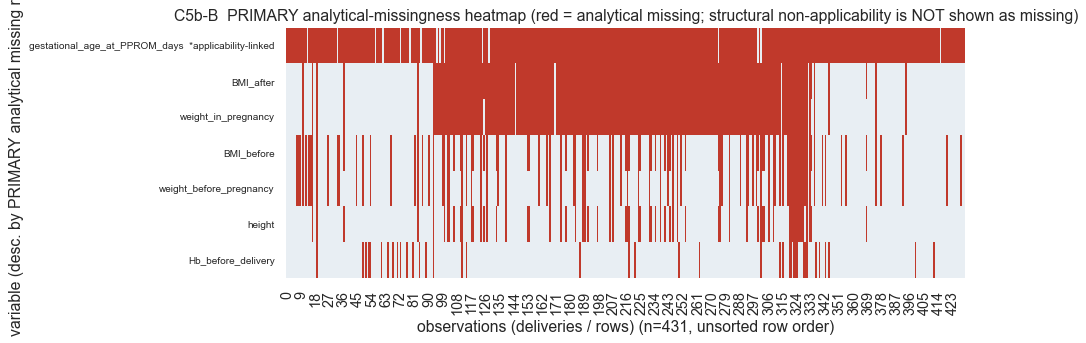

B. Secondary RAW-missingness heatmap omitted -- identical to the PRIMARY heatmap in the current cohort (every confirmed-structural variable is 0% missing, so raw NaN and primary analytical missingness coincide).

C. Co-missingness on PRIMARY analytical-missingness masks (Jaccard >= 0.5, OR lift >= 3x with >= 5 co-missing) -- DESCRIPTIVE ONLY:
                  var_a                         var_b  n_both_missing  jaccard  lift_vs_independence a_structural                               b_structural
    weight_in_pregnancy                     BMI_after             244    0.988                 1.740         none                                       none
weight_before_pregnancy                    BMI_before              89    0.781                 3.780         none                                       none
                 height                    BMI_before              68    0.596                 3.780         none                                       none
              BMI_after ges

In [9]:
_APPLICABILITY_LINKED = set(APPLICABILITY_LINKED_COLS) if "APPLICABILITY_LINKED_COLS" in dir() else set()
_CONFIRMED_STRUCT_C5B = set(STRUCTURAL_NAN_COLS)


def _struct_tag(_v):
    if _v in _CONFIRMED_STRUCT_C5B:
        return "confirmed_structural"
    if _v in _APPLICABILITY_LINKED:
        return "applicability_linked_no_preprocessing_mask"
    return "none"


def _c5b_applicable_mask(_v):
    # registry applicability mask for a structural / applicability-linked variable, else None.
    _gate = structural_missingness_registry.applicability_gate_for(_v)
    if _gate is None:
        return None
    _gcol = _gate["gate_column"]
    if _gcol not in df_analysis.columns:
        raise RuntimeError(
            f"C5b: applicability gate for {_v!r} references gate column {_gcol!r}, "
            "absent from the analysis dataset -- refusing an all-False mask. FAIL LOUD."
        )
    return df_analysis[_gcol].isin(_gate["gate_values"])


def _c5b_primary_missing_mask(_v):
    # PRIMARY analytical missingness mask, identical semantics to C5:
    #   ordinary            -> raw isna
    #   confirmed structural -> isna & applicable   (FAIL LOUD if no gate)
    #   applicability-linked -> raw isna            (no preprocessing mask)
    _isna = df_analysis[_v].isna()
    if _v in _CONFIRMED_STRUCT_C5B:
        _m = _c5b_applicable_mask(_v)
        if _m is None:
            raise RuntimeError(
                f"C5b: {_v!r} is confirmed structural but the registry gives no "
                "applicability gate -- cannot separate structural non-applicability "
                "from within-subgroup missingness. FAIL LOUD."
            )
        return _isna & _m
    return _isna


_miss_vars = [c for c in ANALYSIS_VARS if df_analysis[c].isna().any()]
_miss_vars_primary = [c for c in ANALYSIS_VARS if bool(_c5b_primary_missing_mask(c).any())]
print(f"Variables with any RAW missingness in the analysis universe: {len(_miss_vars)} / {len(ANALYSIS_VARS)}")
print(f"Variables with any PRIMARY analytical missingness (C5 semantics): "
      f"{len(_miss_vars_primary)} / {len(ANALYSIS_VARS)}")

# ── A. Missingness-by-target ──────────────────────────────────────────────────
_g0m = df_analysis[TARGET_COL] == 0
_g1m = df_analysis[TARGET_COL] == 1
_n0_c5b, _n1_c5b = int(_g0m.sum()), int(_g1m.sum())

_RAW_BT_COLS = ["variable", "structural_status", "earliest_entry_stage",
                "raw_missing_pct_target0", "raw_missing_pct_target1", "raw_abs_diff_pct"]
_raw_bt_rows = []
for _c in _miss_vars:
    _m0 = round(df_analysis.loc[_g0m, _c].isna().mean() * 100, 1)
    _m1 = round(df_analysis.loc[_g1m, _c].isna().mean() * 100, 1)
    _st = EARLIEST_ENTRY_STAGE.get(_c)
    _raw_bt_rows.append({
        "variable": _c, "structural_status": _struct_tag(_c),
        "earliest_entry_stage": _st if _st is not None else "",
        "raw_missing_pct_target0": _m0, "raw_missing_pct_target1": _m1,
        "raw_abs_diff_pct": round(abs(_m0 - _m1), 1),
    })
raw_missingness_by_target_df = pd.DataFrame(_raw_bt_rows, columns=_RAW_BT_COLS)
if len(raw_missingness_by_target_df):
    raw_missingness_by_target_df = raw_missingness_by_target_df.sort_values(
        "raw_abs_diff_pct", ascending=False).reset_index(drop=True)
print()
print("A(1). RAW whole-column missingness by target group (DESCRIPTIVE ONLY -- "
      "not MAR/MNAR/causal evidence, never an exclusion reason):")
print(raw_missingness_by_target_df.to_string(index=False) if len(raw_missingness_by_target_df)
      else "  (no variable has any missingness)")

_BT_COLS = ["variable", "structural_status", "earliest_entry_stage",
            "raw_missing_pct_target0", "raw_missing_pct_target1", "raw_abs_diff_pct",
            "primary_missing_pct_target0", "primary_missing_pct_target1", "primary_abs_diff_pct",
            "applicable_n_target0", "applicable_n_target1",
            "missing_within_applicable_n_target0", "missing_within_applicable_n_target1",
            "applicability_aware_missing_pct_target0", "applicability_aware_missing_pct_target1",
            "applicability_aware_view_label"]
_bt_rows = []
for _c in _miss_vars:
    _st = EARLIEST_ENTRY_STAGE.get(_c)
    _tag = _struct_tag(_c)
    _rm0 = round(df_analysis.loc[_g0m, _c].isna().mean() * 100, 1)
    _rm1 = round(df_analysis.loc[_g1m, _c].isna().mean() * 100, 1)
    _pmask = _c5b_primary_missing_mask(_c)
    _pm0 = round(_pmask[_g0m].mean() * 100, 1) if _n0_c5b else np.nan
    _pm1 = round(_pmask[_g1m].mean() * 100, 1) if _n1_c5b else np.nan
    _appmask = _c5b_applicable_mask(_c) if _tag != "none" else None
    _an0 = _an1 = _mw0 = _mw1 = _aa0 = _aa1 = ""
    _label = ""
    if _appmask is not None:
        _a0 = _appmask & _g0m
        _a1 = _appmask & _g1m
        _an0, _an1 = int(_a0.sum()), int(_a1.sum())
        _mw0 = int(df_analysis.loc[_a0, _c].isna().sum())
        _mw1 = int(df_analysis.loc[_a1, _c].isna().sum())
        _aa0 = round(_mw0 / _an0 * 100, 1) if _an0 else np.nan
        _aa1 = round(_mw1 / _an1 * 100, 1) if _an1 else np.nan
        _label = ("confirmed_structural -- this IS the canonical primary per-target value"
                  if _tag == "confirmed_structural"
                  else "applicability-linked sensitivity view only -- does NOT replace raw primary")
    _bt_rows.append({
        "variable": _c, "structural_status": _tag,
        "earliest_entry_stage": _st if _st is not None else "",
        "raw_missing_pct_target0": _rm0, "raw_missing_pct_target1": _rm1,
        "raw_abs_diff_pct": round(abs(_rm0 - _rm1), 1),
        "primary_missing_pct_target0": _pm0, "primary_missing_pct_target1": _pm1,
        "primary_abs_diff_pct": round(abs(_pm0 - _pm1), 1) if pd.notna(_pm0) and pd.notna(_pm1) else np.nan,
        "applicable_n_target0": _an0, "applicable_n_target1": _an1,
        "missing_within_applicable_n_target0": _mw0, "missing_within_applicable_n_target1": _mw1,
        "applicability_aware_missing_pct_target0": _aa0, "applicability_aware_missing_pct_target1": _aa1,
        "applicability_aware_view_label": _label,
    })
missingness_by_target_df = pd.DataFrame(_bt_rows, columns=_BT_COLS)
if len(missingness_by_target_df):
    missingness_by_target_df = missingness_by_target_df.sort_values(
        "raw_abs_diff_pct", ascending=False).reset_index(drop=True)
print()
print("A(2). C5-PRIMARY analytical missingness by target group (confirmed structural: NaN "
      "within applicable subgroup only | applicability-linked (no mask): raw NaN | ordinary: raw NaN). "
      "DESCRIPTIVE ONLY -- not MAR/MNAR/causal, never an exclusion reason:")
print(missingness_by_target_df.to_string(index=False) if len(missingness_by_target_df)
      else "  (no variable has any missingness)")
print("  For an applicability-linked variable the applicability_aware_* columns are a "
      "sensitivity-only diagnostic and do NOT replace the raw primary values.")

# ── B. Missingness heatmap (PRIMARY analytical missingness) ────────────────────
if _miss_vars_primary:
    _prim_mat = pd.DataFrame(
        {c: _c5b_primary_missing_mask(c).astype(int) for c in _miss_vars_primary},
        index=df_analysis.index,
    )
    _order = _prim_mat.mean().sort_values(ascending=False).index.tolist()
    _fig_h = max(4, 0.16 * len(_order) + 2)
    fig, ax = plt.subplots(figsize=(11, _fig_h))
    sns.heatmap(_prim_mat[_order].T, cbar=False, cmap=["#e8eef3", "#c0392b"], ax=ax)
    ax.set_xlabel(f"observations (deliveries / rows) (n={len(df_analysis)}, unsorted row order)")
    ax.set_ylabel("variable (desc. by PRIMARY analytical missing rate)")
    _yt = [(f"{v}  *confirmed-struct" if v in _CONFIRMED_STRUCT_C5B
            else (f"{v}  *applicability-linked" if v in _APPLICABILITY_LINKED else v)) for v in _order]
    ax.set_yticks([i + 0.5 for i in range(len(_order))])
    ax.set_yticklabels(_yt, fontsize=8)
    ax.set_title("C5b-B  PRIMARY analytical-missingness heatmap (red = analytical missing; "
                 "structural non-applicability is NOT shown as missing)")
    plt.tight_layout()
    plt.show()
    plt.close(fig)

    # Secondary RAW heatmap only if it would actually differ from the primary one.
    _raw_only_extra = sorted(set(_miss_vars) - set(_miss_vars_primary))
    _raw_differs = bool(_raw_only_extra) or any(
        not df_analysis[c].isna().equals(_c5b_primary_missing_mask(c)) for c in _miss_vars_primary
    )
    if _raw_differs:
        _raw_order = (df_analysis[_miss_vars].isna().mean().sort_values(ascending=False).index.tolist())
        _raw_mat = df_analysis[_raw_order].isna().astype(int)
        fig, ax = plt.subplots(figsize=(11, max(4, 0.16 * len(_raw_order) + 2)))
        sns.heatmap(_raw_mat.T, cbar=False, cmap=["#e8eef3", "#c0392b"], ax=ax)
        ax.set_xlabel(f"observations (deliveries / rows) (n={len(df_analysis)}, unsorted row order)")
        ax.set_ylabel("variable (desc. by RAW missing rate)")
        ax.set_yticks([i + 0.5 for i in range(len(_raw_order))])
        ax.set_yticklabels(
            [(f"{v}  *confirmed-struct" if v in _CONFIRMED_STRUCT_C5B
              else (f"{v}  *applicability-linked" if v in _APPLICABILITY_LINKED else v)) for v in _raw_order],
            fontsize=8)
        ax.set_title("C5b-B (secondary)  RAW whole-column missingness heatmap "
                     "(includes structural non-applicability)")
        plt.tight_layout()
        plt.show()
        plt.close(fig)
    else:
        print("B. Secondary RAW-missingness heatmap omitted -- identical to the PRIMARY heatmap "
              "in the current cohort (every confirmed-structural variable is 0% missing, so "
              "raw NaN and primary analytical missingness coincide).")
else:
    print("B. No PRIMARY analytical missingness in the analysis universe -- heatmap skipped.")

# ── C. Co-missingness (PRIMARY masks) ─────────────────────────────────────────
_CO_COLS = ["var_a", "var_b", "n_both_missing", "jaccard", "lift_vs_independence",
            "a_structural", "b_structural"]
_co_rows = []
_mv = _miss_vars_primary
_prim_cache = {c: _c5b_primary_missing_mask(c) for c in _mv}
for _i in range(len(_mv)):
    for _j in range(_i + 1, len(_mv)):
        _a, _b = _mv[_i], _mv[_j]
        _ma, _mb = _prim_cache[_a], _prim_cache[_b]
        _both = int((_ma & _mb).sum())
        if _both == 0:
            continue
        _either = int((_ma | _mb).sum())
        _jacc = round(_both / _either, 3) if _either else 0.0
        _exp = _ma.mean() * _mb.mean() * len(df_analysis)
        _lift = round(_both / _exp, 2) if _exp > 0 else float("inf")
        if _jacc >= 0.5 or (_lift != float("inf") and _lift >= 3 and _both >= 5):
            _co_rows.append({
                "var_a": _a, "var_b": _b, "n_both_missing": _both,
                "jaccard": _jacc, "lift_vs_independence": _lift,
                "a_structural": _struct_tag(_a), "b_structural": _struct_tag(_b),
            })
comissingness_df = pd.DataFrame(_co_rows, columns=_CO_COLS)
if len(comissingness_df):
    comissingness_df = comissingness_df.sort_values("jaccard", ascending=False).reset_index(drop=True)
print()
print("C. Co-missingness on PRIMARY analytical-missingness masks (Jaccard >= 0.5, OR "
      "lift >= 3x with >= 5 co-missing) -- DESCRIPTIVE ONLY:")
if len(comissingness_df):
    print(comissingness_df.to_string(index=False))
    print("Interpretation is structural / shared-source pattern detection -- NOT redundancy, "
          "NOT a feature-exclusion decision, and NOT evidence of MAR, MNAR, or any causal "
          "missingness mechanism.")
else:
    print("  No variable pairs meet the co-missingness thresholds on the primary masks.")
print()
print("D. Retained from C5 unchanged: whole-cohort per-variable missingness, applicability-"
      "aware row-level missingness (`row_missing_count_primary` + labelled applicability-linked "
      "sensitivity), and the structural-missingness registry (see C5 + C3b). "
      "Generic >40% hard exclusion NOT restored.")

## Section C6 — Sparsity and Separation Diagnostic

For binary and categorical variables in the **baseline staged analysis
universe (pre-screen)** this section tabulates, per target group and **observed**
level:

- **Separation warning** (`separation_risk`) — an empty target-by-level cell.
  For an **unregularized, dummy-coded** logistic-regression coefficient this is
  a separation / unstable-estimation warning: the maximum-likelihood estimate
  for that coefficient may be infinite or unstable (it diverges). It does
  **not** mean that every downstream **regularized / penalized** logistic model
  necessarily cannot fit the variable.
- **Small-cell / sparse warning** (`too_sparse`) — no empty cell, but the
  smallest target-by-level cell count is `< 5`. The `< 5` value is a
  **heuristic review threshold** (the project's established small-cell
  convention), **not** a universal statistical exclusion rule: it does not by
  itself merge or drop a category or a variable, and downstream category
  encoding / handling is fold-safe and model-stage dependent.

**This is a soft diagnostic, not an eligibility gate.** `separation_risk` /
`too_sparse` / `min_cell_count` are informational flags, surfaced for review and
carried forward as disclosed soft-warning flags in the C12 pipeline; they do
**not** by themselves hard-exclude a variable, change a classification, or
change `earliest_entry_stage`. Target-independent hard eligibility is decided in
C12, not here. A variable flagged here is expected to remain in the candidate
pool with the corresponding risk flag disclosed.

**C6 vs C12 — distinct concerns:**

- **C6** is an *observed* target-by-level sparsity / separation diagnostic — it
  only iterates the levels actually present in the data. A binary variable with
  a single observed level does **not** trigger C6's empty-cell logic (there is
  no second observed level to be empty), and it is **not** forced into C6 as
  "separation".
- **C12** performs the *target-independent* **zero-variance hard exclusion**
  (one observed value, no missingness). That is where a constant predictor is
  removed from the eligible pool. The two are deliberately separate.

**Share-safe display.** The printed table `sparsity_display_df` suppresses
protected small counts (`min_cell_count`, `cs_group_events`, per-variable
missing counts) per the project disclosure threshold (`n < 5`), reusing the
`share_safe` helper / `SHARE_SAFE_MODE` already loaded for C4b. A suppressed
value is shown as a suppression marker, **never** converted to `0`. The
analytical `sparsity_df` keeps exact values unchanged for the downstream
C10 / C12 pipeline.

In [10]:
_SS_C6 = bool(SHARE_SAFE_MODE) if "SHARE_SAFE_MODE" in dir() else True
_SS_C6_THR = share_safe.DEFAULT_DISCLOSURE_THRESHOLD

sparsity_rows = []
for col in ANALYSIS_VARS:
    var_type = infer_var_type(df_analysis[col])
    if var_type not in ("binary", "categorical"):
        continue

    observed = df_analysis[[col, TARGET_COL]].dropna(subset=[col])
    group0 = observed[observed[TARGET_COL] == 0]
    group1 = observed[observed[TARGET_COL] == 1]
    levels = sorted(observed[col].unique())

    all_cells = []
    for level in levels:
        all_cells.append(int((group0[col] == level).sum()))
        all_cells.append(int((group1[col] == level).sum()))

    min_cell = min(all_cells) if all_cells else 0
    separation = any(c == 0 for c in all_cells)
    too_sparse = (not separation) and (min_cell < 5)
    cs_events = int((group1[col] == 1).sum()) if set(levels).issubset({0, 1, 0.0, 1.0}) else None
    single_observed_level = len(levels) <= 1

    sparsity_rows.append({
        "variable": col,
        "type": var_type,
        "N_analyzed": len(observed),
        "N_missing": int(df_analysis[col].isna().sum()),
        "n_levels": len(levels),
        "single_observed_level": single_observed_level,
        "min_cell_count": min_cell,
        "cs_group_events": cs_events,
        "separation_risk": separation,
        "too_sparse": too_sparse,
        "flag": "SEPARATION" if separation else ("SPARSE" if too_sparse else "ok"),
    })

# ── analytical frame -- EXACT values, consumed downstream (C10 / C12). Column
# set and semantics unchanged; `single_observed_level` is an additive
# disclosure column only. ─────────────────────────────────────────────────────
sparsity_df = pd.DataFrame(sparsity_rows).sort_values(
    ["separation_risk", "too_sparse", "min_cell_count"],
    ascending=[False, False, True],
).reset_index(drop=True)

# soft-warning list (2026-09-01: the former "blocking"-named list is retired --
# these are diagnostic warnings, NOT an eligibility gate).
sparsity_warning_vars = (
    sparsity_df.loc[sparsity_df["separation_risk"] | sparsity_df["too_sparse"], "variable"].tolist()
)

# ── presentation-only share-safe copy -- suppresses protected small counts;
# does NOT feed any downstream calculation. ───────────────────────────────────
sparsity_display_df = sparsity_df.copy()
_n_rows_c6 = len(df_analysis)
sparsity_display_df["min_cell_count"] = [
    share_safe.safe_count(int(v), threshold=_SS_C6_THR, enabled=_SS_C6) for v in sparsity_df["min_cell_count"]
]
sparsity_display_df["cs_group_events"] = [
    (None if pd.isna(v) else share_safe.safe_count(int(v), threshold=_SS_C6_THR, enabled=_SS_C6))
    for v in sparsity_df["cs_group_events"]
]
sparsity_display_df["N_missing"] = [
    share_safe.safe_count(int(v), threshold=_SS_C6_THR, enabled=_SS_C6) for v in sparsity_df["N_missing"]
]
sparsity_display_df["N_analyzed"] = [
    share_safe.safe_count_with_complement(int(v), _n_rows_c6, threshold=_SS_C6_THR, enabled=_SS_C6)
    for v in sparsity_df["N_analyzed"]
]

print("C6 -- Sparsity and Separation DIAGNOSTIC (soft warnings only -- NOT an eligibility gate):")
print(sparsity_display_df.to_string(index=False))
print()
print(f"Sparsity / separation warnings (diagnostic): {len(sparsity_warning_vars)} variable(s)")
if sparsity_warning_vars:
    print(f"  {sparsity_warning_vars}")
    print("  These are surfaced for review and are carried forward as DISCLOSED soft-warning")
    print("  flags (separation_risk / sparse_event_risk) in the C12 pipeline. They do NOT")
    print("  hard-exclude a variable, change its classification, or change earliest_entry_stage.")
print()
print("min_cell_count < 5 is a heuristic small-cell review threshold, not a statistical")
print("exclusion rule -- no category or variable is merged or dropped here. Zero variance is")
print("a separate, target-independent C12 hard exclusion (see the section header). The printed")
print("table above is share-safe (sparsity_display_df); the analytical sparsity_df keeps exact")
print("values for the downstream C10 / C12 pipeline. Suppressed cells show a marker, not 0.")

C6 -- Sparsity and Separation DIAGNOSTIC (soft warnings only -- NOT an eligibility gate):
                                      variable        type  N_analyzed  N_missing  n_levels  single_observed_level  min_cell_count cs_group_events  separation_risk  too_sparse       flag
                                          VBAC      binary         431          0         2                  False               0               0             True       False SEPARATION
                                       smoking categorical         431          0         3                  False               0            None             True       False SEPARATION
                                         SIPET      binary         431          0         2                  False               0               0             True       False SEPARATION
                                 diabetes_type categorical         431          0         6                  False               0            None             Tru

## Section C7 — Outlier Recheck (Numeric Variables — Statistical IQR Screen)

Target-blind IQR 1.5× extreme-value flags for every numeric variable in the
**baseline staged analysis universe (pre-screen)** — the current `ANALYSIS_VARS`.
C7 runs *before* the C12 target-independent hard eligibility screen.

**What C7 reports** per numeric variable: `N_nonmissing`, `missing_n` /
`missing_pct`, median / Q1 / Q3 / IQR / min / max, the IQR 1.5× bounds, the
count of non-missing values outside those bounds (`n_outliers`), and the
outlier rate **among the non-missing observations that were actually eligible
for the IQR calculation** (`outlier_pct_of_nonmissing`).

**Denominator correction (2026-09-01).** The outlier rate is
`n_outliers / N_nonmissing × 100` (`outlier_pct_of_nonmissing`) — computed on
the non-missing values only. The previous `outlier_mask.mean()` used the full
cohort as the denominator (a `NaN` comparison is `False`), understating the rate
for any variable with missingness. `outlier_pct_of_all_rows` is kept as
optional whole-cohort context and is **not** the ranking key. For every numeric
variable `N_nonmissing + missing_n == len(df_analysis)` and
`0 <= n_outliers <= N_nonmissing` are asserted (fail loud). A variable with
`N_nonmissing == 0` is marked `all_missing / not_evaluable` (quartiles / skew /
rate not computed) and is **not** excluded — eligibility is decided in C12. A
variable with a small but non-zero `N_nonmissing` keeps its descriptive
calculation where technically defined; `N_nonmissing` is shown prominently and
its outlier rate is to be read as small-N / less stable. No `< 4` (or any other
new) evaluability / exclusion threshold is introduced.

**What C7 does NOT do:**

- It does **not** classify a flagged value as a "plausible extreme", a
  "possible data error", or "unclear". There is **no clinical plausible-range
  registry in EDA C and none is invented here** — EDA A2's outlier section and
  Data Cleaning B follow the same principle (plausibility-range / impossible-value
  handling is owned by preprocessing). The plausibility of the known extreme
  records was already reviewed **upstream, target-blind**, using the
  preprocessing review exports; C7 therefore performs only descriptive,
  target-blind IQR / skewness diagnostics and does **not** re-adjudicate,
  remove, cap, or transform any value.
- **An IQR 1.5× flag is a statistical-extremeness signal only — NOT a data
  error and NOT grounds for removal.** No value is removed, capped,
  winsorized, or transformed in C7.
- No transformation is fitted here. `transformation_review_flag`
  (`|skewness| > 1.5`) is a **descriptive audit signal only** — it does
  **not** mean "log-transform" and it never overrides a variable's
  model-entry contract (e.g. `transform_source_only`). It does **not** route
  a variable to any downstream transformation and has **zero effect** on the
  C14 treatment plan.

C14's `transformation_plan` is derived from the C13 `physical_variable_type`
contract (aligned with Data Cleaning B Section B3, 2026-09-01), never from
this flag or from skewness. A future nonlinear functional-form alternative
may only be introduced by a separate, explicit modeling-stage rationale,
evaluated fold-safely inside cross-validation if data-dependent — never
merely because this flag is set.

In [11]:
_numeric_analysis_vars = [c for c in ANALYSIS_VARS if infer_var_type(df_analysis[c]) == "numeric"]
_N_ROWS_C7 = len(df_analysis)
outlier_rows = []
_c7_recon_errors = []
for col in _numeric_analysis_vars:
    _s = df_analysis[col]
    values = _s.dropna()
    N_nonmissing = int(len(values))
    missing_n = int(_s.isna().sum())
    missing_pct = round(_s.isna().mean() * 100, 1)
    # ── C2 reconciliation ───────────────────────────────────────────────────
    if N_nonmissing + missing_n != _N_ROWS_C7:
        _c7_recon_errors.append(
            f"{col}: N_nonmissing({N_nonmissing}) + missing_n({missing_n}) != cohort N ({_N_ROWS_C7})")
    if N_nonmissing == 0:
        # all-missing: do NOT compute quartiles / skew / rate; do NOT exclude.
        outlier_rows.append({
            "variable": col, "N_nonmissing": 0, "missing_n": missing_n, "missing_pct": missing_pct,
            "median": None, "q1": None, "q3": None, "iqr": None, "min": None, "max": None,
            "iqr_lower": None, "iqr_upper": None, "n_outliers": None,
            "outlier_pct_of_nonmissing": None, "outlier_pct_of_all_rows": None,
            "skewness": None, "transformation_review_flag": False,
            "evaluability": "all_missing / not_evaluable",
        })
        continue
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    # outlier mask is computed on the NON-MISSING values only (a NaN comparison
    # is False, so masking df_analysis[col] silently used the full cohort as the
    # denominator -- the 2026-09-01 blocker).
    _outlier_mask_nonmissing = (values < lower) | (values > upper)
    n_outliers = int(_outlier_mask_nonmissing.sum())
    if not (0 <= n_outliers <= N_nonmissing):
        _c7_recon_errors.append(
            f"{col}: n_outliers({n_outliers}) not in [0, N_nonmissing({N_nonmissing})]")
    outlier_pct_of_nonmissing = round(n_outliers / N_nonmissing * 100, 1)
    outlier_pct_of_all_rows = round(n_outliers / _N_ROWS_C7 * 100, 1)
    skewness = float(values.skew()) if N_nonmissing >= 3 else float("nan")
    outlier_rows.append({
        "variable": col,
        "N_nonmissing": N_nonmissing,
        "missing_n": missing_n,
        "missing_pct": missing_pct,
        "median": round(float(values.median()), 3),
        "q1": round(float(q1), 3),
        "q3": round(float(q3), 3),
        "iqr": round(float(iqr), 3),
        "min": round(float(values.min()), 3),
        "max": round(float(values.max()), 3),
        "iqr_lower": round(float(lower), 3),
        "iqr_upper": round(float(upper), 3),
        "n_outliers": n_outliers,
        "outlier_pct_of_nonmissing": outlier_pct_of_nonmissing,
        "outlier_pct_of_all_rows": outlier_pct_of_all_rows,
        "skewness": round(skewness, 3) if pd.notna(skewness) else None,
        "transformation_review_flag": bool(pd.notna(skewness) and abs(skewness) > 1.5),
        "evaluability": "evaluated" if pd.notna(skewness) else "evaluated (skewness needs N>=3)",
    })

if _c7_recon_errors:
    raise RuntimeError("C7 reconciliation FAILED: " + "; ".join(_c7_recon_errors))

outlier_df = pd.DataFrame(outlier_rows)
if len(outlier_df):
    outlier_df = outlier_df.sort_values(
        "outlier_pct_of_nonmissing", ascending=False, na_position="last"
    ).reset_index(drop=True)

_evald_c7 = outlier_df[outlier_df["N_nonmissing"] > 0] if len(outlier_df) else outlier_df
_pool_min_n = int(_evald_c7["N_nonmissing"].min()) if len(_evald_c7) else 0
_pool_max_n = int(_evald_c7["N_nonmissing"].max()) if len(_evald_c7) else 0

print("C7 -- Outlier recheck: STATISTICAL IQR 1.5x extreme-value flags (target-blind).")
print(f"Numeric variables in the baseline staged analysis universe (pre-screen): "
      f"{len(_numeric_analysis_vars)}")
print(f"N_nonmissing across evaluated numeric variables: min={_pool_min_n}, max={_pool_max_n} "
      f"(of {_N_ROWS_C7} rows). A variable with a materially smaller N_nonmissing has a less "
      "stable IQR outlier rate -- read it descriptively (no evaluability/exclusion threshold "
      "is applied).")
print("Outlier rate = n_outliers / N_nonmissing * 100  (outlier_pct_of_nonmissing) -- the "
      "non-missing observations eligible for the IQR calculation, NOT the full cohort. "
      "outlier_pct_of_all_rows is whole-cohort context only.")
print()
print(outlier_df.to_string(index=False))
print()
print("C7 reconciliation PASSED: N_nonmissing + missing_n == cohort N and "
      "0 <= n_outliers <= N_nonmissing for every numeric variable.")
_not_eval_c7 = outlier_df[outlier_df["N_nonmissing"] == 0] if len(outlier_df) else outlier_df
if len(_not_eval_c7):
    print(f"\n{len(_not_eval_c7)} numeric variable(s) marked 'all_missing / not_evaluable' -- "
          f"NOT evaluated for outliers and NOT excluded (eligibility is decided in C12): "
          f"{_not_eval_c7['variable'].tolist()}")
print()
print("No value was removed, capped, winsorized, or transformed. An IQR 1.5x flag is a "
      "statistical-extremeness signal only -- NOT a data error. C7 does NOT classify a flagged "
      "value clinically: no plausible-range registry exists in EDA C, and the plausibility of "
      "the known extreme records was already reviewed upstream, target-blind, using the "
      "preprocessing review exports -- C7 performs descriptive target-blind IQR / skewness "
      "diagnostics only and does not re-adjudicate them. transformation_review_flag "
      "(|skewness| > 1.5) is a descriptive audit signal only -- it is not a log-transform "
      "decision, never overrides a model-entry contract (e.g. transform_source_only), and has "
      "zero effect on the C14 transformation_plan, which is derived from physical_variable_type "
      "instead.")
print()
print("Before/after-cleaning comparison note: EDA A2's A2.11 (a2_predictor_readiness, "
      "pre-cleaning) used the identical IQR 1.5x methodology on the same underlying numeric "
      "predictors before Data Cleaning B ran. A2 does not persist its outlier table to a file "
      "this notebook can load, so a mechanical row-for-row diff is not available here -- but "
      "the method is unchanged, so any material shift in flagged-value counts reflects Data "
      "Cleaning B's deterministic cleaning / representation changes. Data Cleaning B removes "
      "no analytical row and fits no learned / full-cohort imputation of any kind; learned "
      "imputation is deferred to modeling and fitted inside training folds only. See A2.11 in "
      "the EDA A2 notebook for the pre-cleaning comparison.")

C7 -- Outlier recheck: STATISTICAL IQR 1.5x extreme-value flags (target-blind).
Numeric variables in the baseline staged analysis universe (pre-screen): 14
N_nonmissing across evaluated numeric variables: min=16, max=431 (of 431 rows). A variable with a materially smaller N_nonmissing has a less stable IQR outlier rate -- read it descriptively (no evaluability/exclusion threshold is applied).
Outlier rate = n_outliers / N_nonmissing * 100  (outlier_pct_of_nonmissing) -- the non-missing observations eligible for the IQR calculation, NOT the full cohort. outlier_pct_of_all_rows is whole-cohort context only.

                        variable  N_nonmissing  missing_n  missing_pct  median      q1      q3    iqr     min     max  iqr_lower  iqr_upper  n_outliers  outlier_pct_of_nonmissing  outlier_pct_of_all_rows  skewness  transformation_review_flag evaluability
   gestational_age_at_PPROM_days            16        415       96.300 248.000 237.000 256.000 19.000 162.000 258.000    208.500   

## Section C7b — Three Cumulative-Stage Sweetviz Profiling Reports

Internal automated profiling of the **three cumulative prediction-stage
candidate pools** built in C3 (`STAGE_1_COLS` / `STAGE_2_COLS` / `STAGE_3_COLS`):

| Report | Scope |
|--------|-------|
| `eda_c_stage1_sweetviz.html` | Stage 1 (pre-labor) predictors + target |
| `eda_c_stage2_cumulative_sweetviz.html` | Stage 1 + Stage 2 (near-delivery) + target |
| `eda_c_stage3_cumulative_sweetviz.html` | Stage 1 + Stage 2 + Stage 3 (intrapartum) + target |

These are **cumulative**, not Stage-2-only / Stage-3-only. The scope is
`df_analysis` restricted to each cumulative stage — it already excludes IDs,
leakage, source/audit-only, and post-outcome variables by construction (C3).
The target is included for descriptive profiling only.

**Sweetviz's correlations and target associations are descriptive diagnostics
only** — they never hard-filter a predictor (same rule as C11).

Output: `outputs/manual_review/eda_c_sweetviz/` (git-ignored: `*.html` +
`outputs/manual_review/`). The HTML reports must never be committed.

Guarded import: if `sweetviz` is not installed the subsection fails loudly for
profiling only (it does **not** silently substitute another profiler) and the
rest of EDA C continues.

In [12]:
# Opt-in gate (default True -- the canonical EDA C run attempts all three).
RUN_STAGE_SWEETVIZ = True

_SV_OUT_DIR = (_root / "outputs" / "manual_review" / "eda_c_sweetviz") if _root else Path("outputs/manual_review/eda_c_sweetviz")
_sv_status = []

if not RUN_STAGE_SWEETVIZ:
    print("C7b: RUN_STAGE_SWEETVIZ = False -- three cumulative Sweetviz reports were not generated.")
else:
    try:
        import sweetviz as _sv
        _SV_AVAILABLE = True
    except ImportError as _sv_exc:
        _SV_AVAILABLE = False
        print("C7b: sweetviz is not installed -- the three cumulative Sweetviz reports "
              "were NOT generated. Install it (pip install sweetviz) and re-run this "
              "section. No substitute profiler is used. Rest of EDA C is unaffected.")
        print(f"     import error: {_sv_exc}")

    if _SV_AVAILABLE:
        if "notebooks" in _SV_OUT_DIR.resolve().parts:
            raise RuntimeError(
                f"Sweetviz output dir resolved under 'notebooks/' ({_SV_OUT_DIR.resolve()}) "
                "-- working-directory/path-anchoring bug; refusing to write there."
            )
        _SV_OUT_DIR.mkdir(parents=True, exist_ok=True)

        _SV_STAGE_SCOPES = {
            "eda_c_stage1_sweetviz.html": ("Stage 1 (pre-labor)", STAGE_1_COLS),
            "eda_c_stage2_cumulative_sweetviz.html": ("Stage 1 + 2 cumulative (pre-labor + near-delivery)", STAGE_2_COLS),
            "eda_c_stage3_cumulative_sweetviz.html": ("Stage 1 + 2 + 3 cumulative (+ intrapartum)", STAGE_3_COLS),
        }
        _SV_FORBIDDEN = set(ID_COLS) | {"_row_key_delivery_id"}
        # ── Stage universe used by C7b = the PRE-HARD-EXCLUSION cumulative stage
        # pools (STAGE_1/2/3_COLS from C3). This is deliberate: the repeated EDA
        # should PROFILE (and thereby reveal) zero-variance / sparse / extreme
        # issues at each horizon, not silently drop them beforehand. C-level
        # hard exclusion (C12b) happens later and does not touch this universe.
        print(f"C7b stage universe = pre-hard-exclusion cumulative pools: "
              f"Stage1={len(STAGE_1_COLS)}, Stage2_cum={len(STAGE_2_COLS)}, Stage3_cum={len(STAGE_3_COLS)}")
        for _fname, (_label, _cols) in _SV_STAGE_SCOPES.items():
            _scope_cols = [TARGET_COL] + [c for c in _cols if c in df_analysis.columns and c not in _SV_FORBIDDEN]
            _scope_cols = list(dict.fromkeys(_scope_cols))
            _leak = _SV_FORBIDDEN & set(_scope_cols)
            if _leak:
                raise RuntimeError(f"C7b SAFETY: forbidden columns in Sweetviz scope for {_fname}: {sorted(_leak)}")
            _universe_n = len(_scope_cols) - 1  # predictors in the repeated-EDA universe
            # Identify true constants (single observed value, no missing) for
            # transparency -- they STAY in the repeated-EDA universe; only the
            # HTML rendering may omit them if Sweetviz cannot render a constant.
            _constants = [
                c for c in _scope_cols if c != TARGET_COL
                and df_analysis[c].notna().all() and df_analysis[c].nunique(dropna=True) <= 1
            ]
            _out_path = _SV_OUT_DIR / _fname
            _rendered_cols = list(_scope_cols)
            _profiling_omitted = []
            try:
                _report = _sv.analyze(df_analysis[_rendered_cols].copy(), target_feat=TARGET_COL)
                _report.show_html(str(_out_path), open_browser=False, layout="vertical")
            except Exception as _rep_exc:
                # Retry without constants -- rendering-only omission, universe unchanged.
                _rendered_cols = [c for c in _scope_cols if c not in set(_constants)]
                _profiling_omitted = list(_constants)
                try:
                    _report = _sv.analyze(df_analysis[_rendered_cols].copy(), target_feat=TARGET_COL)
                    _report.show_html(str(_out_path), open_browser=False, layout="vertical")
                    print(f"  NOTE: {_fname} -- Sweetviz could not render {len(_constants)} constant "
                          f"column(s) {_constants}; omitted from the HTML ONLY, retained in the "
                          f"repeated-EDA universe. ({_rep_exc})")
                except Exception as _rep_exc2:
                    _sv_status.append((_fname, False, str(_rep_exc2), _universe_n, _profiling_omitted))
                    print(f"  FAILED to generate {_fname}: {_rep_exc2}")
                    continue
            _sv_status.append((_fname, True, _label, _universe_n, _profiling_omitted))
            print(f"  Written: {_out_path}  [{_label}: repeated-EDA universe = target + {_universe_n} predictors"
                  + (f"; {len(_profiling_omitted)} constant(s) omitted from HTML rendering only" if _profiling_omitted else "")
                  + f"; constants present in universe: {_constants or 'none'}]")

        print()
        _n_ok = sum(1 for r in _sv_status if r[1])
        print(f"C7b: {_n_ok}/3 cumulative Sweetviz reports generated in {_SV_OUT_DIR.resolve()}")
        print("     Descriptive profiling only -- Sweetviz associations/correlations do NOT filter predictors.")
        print("     A profiling-only omission (an un-renderable constant) NEVER changes analytical eligibility.")
        print("     HTML is git-ignored (*.html + outputs/manual_review/) -- never commit it.")
        if _n_ok < 3:
            print("     WARNING: not all three reports were produced -- see the per-file messages above.")

<PROJECT_ROOT>\.venv312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C7b stage universe = pre-hard-exclusion cumulative pools: Stage1=70, Stage2_cum=76, Stage3_cum=81


                                             |          | [  0%]   00:00 -> (? left)

[Summarizing dataframe]                      |          | [  0%]   00:00 -> (? left)

Feature: target_intrapartum_cs (TARGET)      |▏         | [  1%]   00:00 -> (00:00 left)

...

[Step 2/3] Processing Pairwise Features      |          | [  0%]   00:00 -> (? left)    

[Step 3/3] Generating associations graph     |          | [  0%]   00:00 -> (? left)

Done! Use 'show' commands to display/save.   |          | [  0%]   00:03 -> (? left)

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:03 -> (00:00 left)

Report <PROJECT_ROOT>\outputs\manual_review\eda_c_sweetviz\eda_c_stage3_cumulative_sweetviz.html was generated.
  Written: <PROJECT_ROOT>\outputs\manual_review\eda_c_sweetviz\eda_c_stage3_cumulative_sweetviz.html  [Stage 1 + 2 + 3 cumulative (+ intrapartum): repeated-EDA universe = target + 81 predictors; constants present in universe: ['alcohol', 'HELLP', 'eclampsia', 'IUFD']]

C7b: 3/3 cumulative Sweetviz reports generated in <PROJECT_ROOT>\outputs\manual_review\eda_c_sweetviz
     Descriptive profiling only -- Sweetviz associations/correlations do NOT filter predictors.
     A profiling-only omission (an un-renderable constant) NEVER changes analytical eligibility.
     HTML is git-ignored (*.html + outputs/manual_review/) -- never commit it.


## Section C8 — Feature Engineering Plan

This table documents **every proposed derived feature before any is executed**,
and — via `runtime_availability` — must reconcile exactly, feature-for-feature,
with what C9 actually materializes. Features whose `runtime_availability` is
`executable_now` are derived in C9. `derived_nulliparity_with_prior_cs` is
`review_only` but is still computed in C9 as a sanity-check-only variable (never
a modeling candidate) — see its dedicated block below for why.

### Documentation fields
- **source_columns**: exact column names the derivation formula actually reads
  — no invented names, and (for a feature whose clinical redundancy family is
  wider than its formula inputs) not padded with non-read family members
- **redundancy_family_columns**: broader clinically/representationally
  overlapping variables that are *not* direct formula inputs and that require
  **explicit modeling co-entry review** with the derived feature (informational;
  separate from `source_columns`). Whether co-entry is actually **HARD-forbidden**
  is determined **only** by the sole authored canonical C13 hard co-entry
  registry, the tracked YAML
  `analysis/eda/notebook_build/eda_c/contracts/model_coentry_constraints.yaml`
  (`outputs/eda_c/model_coentry_constraints.csv` and any local `contracts/*.csv`
  are generated inspection/runtime mirrors of that YAML, never the source);
  everything else here is `review_within_modeling`, not a global prohibition.
- **clinical_rationale**: why this feature is clinically meaningful
- **timing**: the latest time window any source column belongs to
- **leakage_risk**: `no` or `review` (never `yes` for an implementable feature)
- **missingness_risk / missingness_behavior**: expected missing rate relative to
  source columns, and the deterministic rule for when the output is left NaN
- **expected_type**: the derived variable's type (binary / categorical / …)
- **implementable**: `yes` = the formula is fully specified and implementable
  **when its approved upstream source columns are available**; `review` =
  clinically ambiguous source; `no` = source unusable; `relocated` = now
  created upstream in Data Cleaning B
- **runtime_availability** (the authoritative materialization status — see below)
- **analytical_role**: the derived feature's own classification if materialized
  (`predictor_allowed` / `sanity_check_only` / `not_a_candidate`); mirrors the
  C9 `derived_meta` value, checked by C9's horizon-inheritance safeguard
- **earliest_entry_stage**: earliest cumulative prediction horizon the derived
  feature could enter (1 / 2 / 3 / `n/a`), inherited from its latest source
- **primary_model_eligible**: **legacy/compatibility field only.** Retained for
  downstream objects that still read it. This project is multi-horizon
  (cumulative Stage 1/2/3) — there is no single "primary
  pre-admission model", so `analytical_role` + `earliest_entry_stage` +
  the horizon-availability wording are the real stage contract, not this field.

### `runtime_availability` — the plan ↔ C9 reconciliation key
Every plan row carries exactly one of:
- `executable_now` — materialized in C9 this run, added to `DERIVED_VARS`.
- `conditional_skipped_unresolved_source` — formula is fully implementable, but
  a required upstream source is not in the staged analysis universe this run
  (e.g. a variable registered only in `APPROVED_UPSTREAM_ONLY_SOURCES`, not a
  standalone candidate). **Gracefully skipped — this is NOT a C9 failure** and
  is re-enabled automatically whenever the upstream source is present. No
  current plan row uses this bucket as of 2026-09-01 (Decision 94 resolved
  the last one, `derived_placental_dysfunction_proxy`, to `executable_now`);
  the bucket remains available for a future genuinely-unresolved source.
- `review_only` — computed for data-quality purposes only, never a modeling
  candidate (the nulliparity/prior-CS contradiction sanity check).
- `relocated_to_data_cleaning_b` — no longer created here; consumed through the
  ordinary `B_CREATED_ANALYSIS_VARS` pathway.
- `not_implementable` — source column cannot support a modeling feature.

C9 prints a five-way reconciliation (planned / formula-implementable /
conditionally-skipped / relocated / actually-materialized `DERIVED_VARS`) and
fails loud only on a genuine mismatch (an `executable_now` row that did not
materialize, or a materialized column with no plan row).

### Conservative principles
1. Derived features are candidate representations — not guaranteed model inputs.
2. No feature is marked as a "validated clinical score" unless it comes from a
   published and validated instrument.
3. Features with clinically ambiguous source columns are marked `review`.
4. Retired representations are not created or exported from the active EDA C
   handoff. Historical audit outputs may still mention them.

### Warning
`derived_nulliparity_with_prior_cs` is a **sanity-check feature only**.
Nulliparity = 1 AND prior CS = 1 is logically inconsistent. If this feature
has a non-zero count, it signals a potential data-coding error and must be
reviewed before modeling.

### Retired count/composite representations
The prior count/composite representations retired by the final decision freeze
are no longer created here. Their source variables remain available under the
current screening rules where appropriate.

In [13]:
# ── Feature engineering plan table ─────────────────────────────────────────────
# This table is printed and reviewed BEFORE any feature is executed.
# Changes to implementable status or source columns require explicit approval.

_FEATURE_PLAN = [
{
        "new_feature_name": "derived_prior_endo_surgery_procedure_status",
        "source_columns": (
            "endometriosis_surgery, "
            "endo_resection_ovarian_endometrioma_unilateral, "
            "endo_resection_lesion, endo_resection_adhesiolysis"
        ),
        "redundancy_family_columns": "endometriosis_surgery, endo_resection_* family",
        "clinical_rationale": (
            "Exploratory prior-endometriosis-surgery representation with a coarse "
            "documentation-status distinction for a selected subset of reliably "
            "coded structured procedure variables. This is NOT a validated "
            "surgical severity score and NOT a burden score."
        ),
        "timing": "pre_pregnancy",
        "leakage_risk": "no",
        "missingness_behavior": (
            "low in the current cleaned cohort; a surgery-positive row is left "
            "NaN when any selected-procedure source is missing (status "
            "unresolvable); endometriosis_surgery missing -> NaN"
        ),
        "expected_type": "categorical (3 states)",
        "implementable": "yes",
        "runtime_availability": "executable_now",
        "analytical_role": "predictor_allowed",
        "earliest_entry_stage": 1,
        "primary_model_eligible": "yes (legacy field)",
        "notes": (
            "States: no_prior_endo_surgery; "
            "prior_surgery_no_selected_procedure_documented; "
            "prior_surgery_with_selected_procedure_documented. The selected "
            "procedures are only a subset of reliably coded structured surgical "
            "variables. 'No selected procedure documented' must not be interpreted "
            "as no procedure or no resection occurred. Its co-entry with the "
            "structured endo_resection_* family is review_within_modeling (the "
            "prior_endometriosis_surgery relationship group); its HARD pair is "
            "with endometriosis_surgery only (C13 registry, deterministic status "
            "encoding)."
        ),
    },
    {
        "new_feature_name": "derived_endo_surgery_adhesion_status",
        "source_columns": "endometriosis_surgery, endo_surgery_adhesiolysis",
        "redundancy_family_columns": "endometriosis_surgery, endo_resection_adhesiolysis",
        "clinical_rationale": (
            "Exploratory prior-endometriosis-surgery adhesion finding/status "
            "representation: whether adhesions were documented during prior "
            "endometriosis surgery. This does not indicate whether adhesiolysis "
            "was performed."
        ),
        "timing": "pre_pregnancy",
        "leakage_risk": "no",
        "missingness_behavior": "low in the current cleaned cohort",
        "expected_type": "categorical (3 states)",
        "implementable": "relocated",
        "runtime_availability": "relocated_to_data_cleaning_b",
        "analytical_role": "predictor_allowed",
        "earliest_entry_stage": 1,
        "primary_model_eligible": "yes (legacy field)",
        "notes": (
            "Created upstream in Data Cleaning B -- "
            "no longer created here; consumed via the ordinary B_CREATED_ANALYSIS_VARS "
            "pathway (its formula/valid-value contract is the B feature dictionary's). "
            "Current architecture has 3 active states only: "
            "no_prior_endo_surgery; prior_surgery_without_documented_adhesions; "
            "prior_surgery_with_documented_adhesions -- the current cohort has 0 "
            "genuinely-missing-applicable rows, so a 4th 'unknown' state is not "
            "invented; a future genuinely missing applicable row fails loud instead "
            "of silently reintroducing an unused category. "
            "endo_resection_adhesiolysis remains the separate performed-procedure "
            "variable for adhesiolysis."
        ),
    },
{
        "new_feature_name": "derived_placental_dysfunction_proxy",
        "source_columns": "any_PET_cat, IUGR",
        "redundancy_family_columns": (
            "any_PET_cat, severe_PET_cat, IUGR, derived_hypertension_pih_pet_spectrum"
        ),
        "clinical_rationale": (
            "Exploratory placenta-mediated complication phenotype: PET present "
            "or IUGR present. This is a clinically motivated proxy only, not a "
            "validated clinical score, not a severity score, and not a "
            "missingness indicator."
        ),
        "timing": "pregnancy",
        "leakage_risk": "no",
        "missingness_behavior": (
            "inherits genuine PET unknown status: an unresolved PET state "
            "(not 'present'/'absent') with IUGR != 1 remains NaN; no fillna(0)"
        ),
        "expected_type": "binary",
        "implementable": "yes",
        "runtime_availability": "executable_now",
        "analytical_role": "predictor_allowed",
        "earliest_entry_stage": 1,
        "primary_model_eligible": "yes (legacy field)",
        "notes": (
            "1 if any_PET_cat == 'present' OR IUGR == 1; 0 only if "
            "any_PET_cat == 'absent' AND IUGR == 0; NaN otherwise. "
            "any_PET_cat is now an approved predictor_allowed/Stage 1 standalone "
            "predictor in its own right (Decision 94, 2026-09-01, retiring its "
            "prior manual_review_pending state) and IUGR is predictor_allowed/ "
            "Stage 1 -- both sources are present in df_analysis, so this feature "
            "now materializes (previously CONDITIONALLY SKIPPED while any_PET_cat "
            "was unavailable; see docs/clinical_decisions/manual_decisions_log.md "
            "Decision 94). earliest_entry_stage recomputed from its actual source "
            "stages (both Stage 1) -- not the prior placeholder Stage 2. "
            "Alternative representation to any_PET_cat and IUGR."
        ),
    },
{
        "new_feature_name": "derived_hypertension_pih_pet_spectrum",
        "source_columns": "PIH, any_PET_cat, SIPET, HELLP, eclampsia",
        "redundancy_family_columns": (
            "pregnancy_related_hypertensive_disorder, PIH, mild_PET, severe_PET_cat, "
            "any_PET_cat, SIPET, HELLP, eclampsia"
        ),
        "clinical_rationale": (
            "Predefined 3-level grouped clinical representation of the hypertension "
            "family: no_hypertensive_disorder / pih_gestational_htn / "
            "preeclampsia_spectrum. Defined purely from clinical/source semantics, "
            "NOT from target association. SIPET/HELLP/eclampsia are "
            "each, by their own established clinical definition, preeclampsia "
            "diagnoses and fall in the spectrum level."
        ),
        "timing": "pregnancy",
        "leakage_risk": "no",
        "missingness_behavior": (
            "NaN when any_PET_cat == 'not_documented' and none of SIPET/HELLP/"
            "eclampsia is positive (spectrum genuinely unresolved -- not guessed "
            "as level 0); NaN when spectrum-negative but PIH is missing. No fillna."
        ),
        "expected_type": "categorical (3 states)",
        "implementable": "yes",
        "runtime_availability": "executable_now",
        "analytical_role": "predictor_allowed",
        "earliest_entry_stage": 1,
        "primary_model_eligible": "yes (legacy field)",
        "notes": (
            "Formula reads PIH (df_analysis) and any_PET_cat/SIPET/HELLP/eclampsia. "
            "any_PET_cat is an approved standalone predictor_allowed/Stage 1 "
            "predictor in its own right (Decision 94, 2026-09-01, retiring its "
            "prior manual_review_pending state) and is present in df_analysis via "
            "the ordinary staged-analysis path -- it is also a "
            "direct formula input to this derived feature. Its categorical representation "
            "remains present/absent/not_documented -- an unambiguous "
            "deterministic recode of any_PET (1/0/NaN); not_documented is "
            "genuinely unresolved PET documentation status and is never silently "
            "treated as absent. mild_PET and severe_PET_cat are clinical-"
            "redundancy-family members (severe_PET_cat is itself an approved "
            "standalone predictor_allowed/Stage 1 predictor too) but are NOT "
            "formula inputs to this feature. Co-entry with the individual "
            "hypertension source variables is review_within_modeling (the "
            "hypertension_spectrum relationship group) -- NOT an automatic HARD "
            "pair against each PIH/PET subtype. It has NO HARD co-entry pair in "
            "the C13 registry. See "
            "DERIVED_REDUNDANCY_GROUPS['hypertension_pih_pet_spectrum_representation']."
        ),
    },
{
        "new_feature_name": "derived_diabetes_type_grouped",
        "source_columns": "diabetes_type",
        "redundancy_family_columns": "gestational_diabetes, diabetes_type",
        "clinical_rationale": (
            "Deterministic 4-level clinical grouping of diabetes_type's confirmed "
            "code dictionary (0=no diabetes, 1=pregestational unspecified, 2=type 1, "
            "3=type 2, 4=GDMA1, 5=GDMA2): no_diabetes / pregestational (1,2,3) / "
            "GDMA1 (4) / GDMA2 (5). Grouped on category-size and clinical-"
            "interpretability grounds only (each of codes 1/2/3 is individually too "
            "sparse; the combined pregestational category stays clinically "
            "coherent), NOT on target association."
        ),
        "timing": "pregnancy",
        "leakage_risk": "no",
        "missingness_behavior": (
            "NaN iff diabetes_type is missing. An unexpected non-missing code "
            "outside {0,1,2,3,4,5} FAILS LOUD in C9 -- it is never silently mapped "
            "to NaN."
        ),
        "expected_type": "categorical (4 states)",
        "implementable": "yes",
        "runtime_availability": "executable_now",
        "analytical_role": "predictor_allowed",
        "earliest_entry_stage": 1,
        "primary_model_eligible": "yes (legacy field)",
        "notes": (
            "HARD co-entry pair with diabetes_type ONLY (C13 registry: deterministic "
            "coarsening -- the grouped variable is a function of diabetes_type). "
            "gestational_diabetes is review_within_modeling (diabetes_representation "
            "relationship group), NOT a HARD pair: current executable lineage does "
            "not prove deterministic recoverability from it. See "
            "DERIVED_REDUNDANCY_GROUPS['diabetes_representation']."
        ),
    },
{
        "new_feature_name": "derived_nulliparity_with_prior_cs",
        "source_columns": "nulliparity, S_P_CS",
        "redundancy_family_columns": "n/a (data-quality check, not a candidate)",
        "clinical_rationale": (
            "Interaction flag: nulliparity = 1 AND prior CS = 1. "
            "This combination is clinically inconsistent - a nulliparous patient "
            "cannot have had a prior delivery by any mode. "
            "SANITY-CHECK ONLY: non-zero count indicates a data-coding error."
        ),
        "timing": "pre_pregnancy",
        "leakage_risk": "no",
        "missingness_behavior": (
            "1 iff nulliparity == 1 AND S_P_CS == 1; 0 when both sources are "
            "observed and not both == 1; NaN when either source is missing"
        ),
        "expected_type": "binary",
        "implementable": "review",
        "runtime_availability": "review_only",
        "analytical_role": "sanity_check_only",
        "earliest_entry_stage": "n/a",
        "primary_model_eligible": "no",
        "notes": (
            "NOT a modeling candidate. Computed in C9 for a data-quality sanity "
            "check only. If count > 0, flag for data review before modeling."
        ),
    },
{
        "new_feature_name": "derived_conception_mode_detail",
        "source_columns": "mode_of_conception_details",
        "redundancy_family_columns": "mode_of_conception, mode_of_conception_ivf_vs_all",
        "clinical_rationale": "Detailed conception mode grouping.",
        "timing": "pre_pregnancy",
        "leakage_risk": "no",
        "missingness_behavior": "high missingness; source is free-text / audit-only",
        "expected_type": "categorical",
        "implementable": "no",
        "runtime_availability": "not_implementable",
        "analytical_role": "not_a_candidate",
        "earliest_entry_stage": "n/a",
        "primary_model_eligible": "no",
        "notes": (
            "Source column is in source_or_text_audit_exclude - "
            "free-text or audit-only; not suitable for modeling."
        ),
    }
]

feature_plan_df = pd.DataFrame(_FEATURE_PLAN)

# ── runtime_availability buckets (the plan <-> C9 reconciliation key) ─────────
_RUNTIME_BUCKETS = [
    ("executable_now", "executable now (materialized in C9)"),
    ("conditional_skipped_unresolved_source",
     "conditionally available / skipped (approved upstream source unresolved this run)"),
    ("review_only", "review-only sanity check (computed, never a modeling candidate)"),
    ("relocated_to_data_cleaning_b", "relocated to Data Cleaning B"),
    ("not_implementable", "not implementable"),
]
_bucket_members = {
    key: feature_plan_df.loc[feature_plan_df["runtime_availability"] == key,
                             "new_feature_name"].tolist()
    for key, _ in _RUNTIME_BUCKETS
}
_unbucketed = feature_plan_df.loc[
    ~feature_plan_df["runtime_availability"].isin([k for k, _ in _RUNTIME_BUCKETS]),
    "new_feature_name",
].tolist()
if _unbucketed:
    raise ValueError(
        "C8 feature plan: every row must carry a recognised runtime_availability "
        f"value; unrecognised for {_unbucketed}"
    )

print(f"Feature engineering plan: {len(_FEATURE_PLAN)} proposed features")
print()
for _key, _label in _RUNTIME_BUCKETS:
    _m = _bucket_members[_key]
    print(f"  {_label}: {len(_m)}")
    for _name in _m:
        print(f"      - {_name}")
print()
print("NOTE: a 'conditionally available / skipped' feature is NOT a C9 failure -- "
      "its formula is fully specified; only an approved upstream source is "
      "temporarily unavailable to the staged analysis universe. C9 prints the "
      "authoritative five-way plan<->materialization reconciliation.")
print()
_C8_DISPLAY_COLS = [
    "new_feature_name", "source_columns", "timing", "expected_type",
    "implementable", "runtime_availability", "analytical_role",
    "earliest_entry_stage", "primary_model_eligible",
]
print(feature_plan_df[_C8_DISPLAY_COLS].to_string(index=False))

Feature engineering plan: 7 proposed features

  executable now (materialized in C9): 4
      - derived_prior_endo_surgery_procedure_status
      - derived_placental_dysfunction_proxy
      - derived_hypertension_pih_pet_spectrum
      - derived_diabetes_type_grouped
  conditionally available / skipped (approved upstream source unresolved this run): 0
  review-only sanity check (computed, never a modeling candidate): 1
      - derived_nulliparity_with_prior_cs
  relocated to Data Cleaning B: 1
      - derived_endo_surgery_adhesion_status
  not implementable: 1
      - derived_conception_mode_detail

NOTE: a 'conditionally available / skipped' feature is NOT a C9 failure -- its formula is fully specified; only an approved upstream source is temporarily unavailable to the staged analysis universe. C9 prints the authoritative five-way plan<->materialization reconciliation.

                           new_feature_name                                                                         

## Section C9 — Feature Engineering Execution

Executes the C8 plan. A `runtime_availability = executable_now` feature is
materialized and added to `DERIVED_VARS`; `conditional_skipped_unresolved_source`
is gracefully skipped (approved upstream source not in the staged universe —
**not a failure**); `review_only` (`derived_nulliparity_with_prior_cs`) is
computed for a data-quality check only and never becomes a modeling candidate;
`relocated_to_data_cleaning_b` / `not_implementable` are not created here.

### Rules
1. All derived features use the prefix `derived_`.
2. Source columns are never overwritten or modified.
3. Derived features are added to `df_analysis` (not to `df`).
4. TIMING_MAP is checked for each source column. Any source with
   `admission_labor` timing causes the derived feature to be flagged
   as ineligible for the pre-admission (Stage 1) horizon.
5. `derived_nulliparity_with_prior_cs`: a non-zero contradiction count
   triggers a data-quality warning.
6. **Source-contract safety.** Before it is used, every coded source is
   validated against its approved dictionary: `diabetes_type` ∈ {0,1,2,3,4,5},
   `any_PET_cat` ∈ {present, absent, not_documented}.
   An unexpected observed code/state **fails loud** — it is
   never silently treated as missing or as absence. A genuine NaN in a
   PET/`any_PET_cat` source leaves the derived result unresolved (NaN), never
   PET-negative.
7. **`DERIVED_FEATURE_CONTRACTS`** — one shared, narrowly-scoped object
   (formula inputs, rule, allowed non-missing output values, NaN-propagation
   semantics) consumed by C9, C10 validation, C10b documentation, and the
   tests. It carries no redundancy-family membership, no classification/stage,
   and no invented clinical plausibility bounds — those are separate metadata
   layers.
8. **Approved upstream-only sources.** The horizon-inheritance safeguard
   fails loud on any source column outside all three stage sets unless it is
   in `APPROVED_UPSTREAM_ONLY_SOURCES` — a source that merely cannot be
   stage-ranked is never silently assumed to be an earlier stage. Currently
   empty (2026-09-01, Decision 94): the PET `_cat` recodes are no longer
   upstream-only inputs — both are now approved `predictor_allowed`/
   Stage 1 standalone predictors and are properly stage-ranked via the
   ordinary `PREDICTOR_ALLOWED_COLS` path instead.
9. C9 prints a five-way reconciliation: planned / formula-implementable /
   conditionally-skipped / relocated / actually-materialized `DERIVED_VARS`.

In [14]:
# ── TIMING_MAP safety check helper ────────────────────────────────────────────
def _check_timing(source_cols_str):
    cols = [c.strip() for c in source_cols_str.split(",") if c.strip()]
    timings = {c: TIMING_MAP.get(c, "unknown") for c in cols}
    has_admission = any(t == "admission_labor" for t in timings.values())
    return timings, has_admission


DERIVED_VARS = []     # populated below — only successfully derived columns
derived_meta = {}     # name -> {source_columns, timing, primary_model_eligible, ...}

_TIMING_WARNING = (
    "WARNING: one or more source columns have 'admission_labor' timing — "
    "this derived feature CANNOT be in the pre-admission (Stage 1) horizon."
)

# ── Approved coded-source dictionaries (source-contract safety, C9 rule 6) ────
# These validate the SOURCE columns before use; they are deliberately kept
# out of DERIVED_FEATURE_CONTRACTS (which is the derived-OUTPUT contract only).
_DIABETES_TYPE_APPROVED_CODES = {0, 1, 2, 3, 4, 5}          # confirmed diabetes_type code dictionary
_ANY_PET_CAT_APPROVED_STATES = {"present", "absent", "not_documented"}  # confirmed any_PET_cat state dictionary


def _validate_coded_source(series, approved, source_name, decision):
    # Fail loud if any non-missing observed value is outside `approved`.
    # Missing values are left untouched (allowed by the current contract).
    _obs = series.dropna()
    if _obs.dtype.kind in "biufc":
        _seen = set(int(v) if float(v).is_integer() else float(v) for v in _obs.unique())
    else:
        _seen = set(_obs.astype(str).unique())
    _unexpected = sorted(v for v in _seen if v not in approved)
    if _unexpected:
        raise ValueError(
            f"{source_name}: observed value(s) {_unexpected} are outside the approved "
            f"dictionary {sorted(approved)} ({decision}). An unrecognised code/state "
            "must NOT be silently treated as missing or as absence -- resolve the "
            "upstream data/contract before deriving features from this column."
        )


# ── DERIVED_FEATURE_CONTRACTS — single shared derived-OUTPUT contract ─────────
# Narrowly scoped by design: formula inputs; formula/rule; allowed non-missing
# output values; NaN-propagation semantics. NO redundancy-family membership, NO
# predictor classification/stage, NO invented clinical plausibility ranges --
# those live in separate authoritative metadata layers (derived_meta, the C8
# plan's redundancy_family_columns, DERIVED_REDUNDANCY_GROUPS, the classification
# snapshot). Consumed by C10 valid-value validation, C10b printed documentation,
# and the correction tests so all three agree on one expected output domain.
DERIVED_FEATURE_CONTRACTS = {
    "derived_prior_endo_surgery_procedure_status": {
        "formula_inputs": [
            "endometriosis_surgery",
            "endo_resection_ovarian_endometrioma_unilateral",
            "endo_resection_lesion",
            "endo_resection_adhesiolysis",
        ],
        "rule": (
            "no_prior_endo_surgery if endometriosis_surgery==0; "
            "prior_surgery_no_selected_procedure_documented if endometriosis_surgery==1 "
            "and all 3 selected procedure vars are observed and ==0; "
            "prior_surgery_with_selected_procedure_documented if endometriosis_surgery==1 "
            "and all 3 selected procedure vars are observed and any ==1"
        ),
        "allowed_values": {
            "no_prior_endo_surgery",
            "prior_surgery_no_selected_procedure_documented",
            "prior_surgery_with_selected_procedure_documented",
        },
        "nan_propagation": (
            "NaN when endometriosis_surgery is missing, or when endometriosis_surgery==1 "
            "and any selected-procedure source is missing (status unresolvable)"
        ),
        "runtime_status": "executable_now",
    },
    "derived_placental_dysfunction_proxy": {
        "formula_inputs": ["any_PET_cat", "IUGR"],
        "rule": (
            "1 if any_PET_cat=='present' OR IUGR==1; "
            "0 if any_PET_cat=='absent' AND IUGR==0; NaN otherwise"
        ),
        "allowed_values": {0.0, 1.0},
        "nan_propagation": (
            "NaN whenever PET status is not resolved to 'present'/'absent' and IUGR!=1; "
            "no fillna(0); a genuine any_PET_cat NaN never counts as PET-negative"
        ),
        "runtime_status": "conditional_skipped_unresolved_source",
    },
    "derived_nulliparity_with_prior_cs": {
        "formula_inputs": ["nulliparity", "S_P_CS"],
        "rule": (
            "1 if nulliparity==1 AND S_P_CS==1; 0 when both sources are observed and "
            "not both ==1"
        ),
        "allowed_values": {0.0, 1.0},
        "nan_propagation": "NaN when either nulliparity or S_P_CS is missing",
        "runtime_status": "review_only",
    },
    "derived_hypertension_pih_pet_spectrum": {
        "formula_inputs": ["PIH", "any_PET_cat", "SIPET", "HELLP", "eclampsia"],
        "rule": (
            "preeclampsia_spectrum if any_PET_cat=='present' OR SIPET==1 OR HELLP==1 "
            "OR eclampsia==1; otherwise, when PET spectrum status is resolved: "
            "pih_gestational_htn if PIH==1, no_hypertensive_disorder if PIH==0"
        ),
        "allowed_values": {
            "no_hypertensive_disorder",
            "pih_gestational_htn",
            "preeclampsia_spectrum",
        },
        "nan_propagation": (
            "NaN when any_PET_cat=='not_documented' and none of SIPET/HELLP/eclampsia "
            "is positive (spectrum unresolved); NaN when spectrum-negative but PIH is "
            "missing; a genuine any_PET_cat NaN never counts as spectrum-negative"
        ),
        "runtime_status": "executable_now",
    },
    "derived_diabetes_type_grouped": {
        "formula_inputs": ["diabetes_type"],
        "rule": "map {0->no_diabetes, 1/2/3->pregestational, 4->GDMA1, 5->GDMA2}",
        "allowed_values": {"no_diabetes", "pregestational", "GDMA1", "GDMA2"},
        "nan_propagation": (
            "NaN iff diabetes_type is missing; an unexpected non-missing code fails "
            "loud (never mapped to NaN)"
        ),
        "runtime_status": "executable_now",
    },
}

# ── APPROVED_UPSTREAM_ONLY_SOURCES (horizon-inheritance safeguard, C9 rule 8) ─
# A derived feature may read one of these as an input even though the column is
# intentionally not a standalone predictor -- it is used only as an upstream
# derivation input. Any OTHER source column that cannot be stage-ranked against
# the three stage sets fails the safeguard loud.
# Currently empty (2026-09-01, Decision 94): `any_PET_cat`/`severe_PET_cat`
# were the sole members while manual_review_pending, which put them outside
# all three stage sets (PREDICTOR_ALLOWED_COLS/SECONDARY_NEAR_DELIVERY_
# PREDICTOR_COLS/INTRAPARTUM_PREDICTOR_EXCLUDE_COLS) and required this
# explicit upstream-only exemption to avoid a false horizon-inheritance
# failure. Now approved predictor_allowed/Stage 1 standalone predictors in
# their own right, they are properly stage-ranked via PREDICTOR_ALLOWED_COLS
# like any other Stage-1 source -- they are no longer upstream-only sources
# and must not remain in this allowlist merely for historical reasons. The
# mechanism itself remains available for a future genuinely upstream-only
# source.
APPROVED_UPSTREAM_ONLY_SOURCES = set()

# Retired derived modeling representations are intentionally not created here:
# advanced-age binary, BMI category, endometriosis burden/resection counts,
# complex phenotype composite, broad surgical-history composite, and pregnancy
# complication count. Their source variables remain available where approved.

# ── 1. derived_prior_endo_surgery_procedure_status ───────────────────────────
_prior_endo_status_srcs = [
    "endometriosis_surgery",
    "endo_resection_ovarian_endometrioma_unilateral",
    "endo_resection_lesion",
    "endo_resection_adhesiolysis",
]
_prior_endo_status_missing = [c for c in _prior_endo_status_srcs if c not in df_analysis.columns]
if _prior_endo_status_missing:
    raise ValueError(
        "derived_prior_endo_surgery_procedure_status requires all source columns "
        f"to be present; missing: {_prior_endo_status_missing}"
    )

_prior_endo_proc_srcs = _prior_endo_status_srcs[1:]
_prior_endo_status = pd.Series(np.nan, index=df_analysis.index, dtype="object")
_no_prior_endo_surgery = df_analysis["endometriosis_surgery"] == 0
_prior_endo_surgery = df_analysis["endometriosis_surgery"] == 1
_selected_proc = df_analysis[_prior_endo_proc_srcs]
_selected_proc_complete = _selected_proc.notna().all(axis=1)
_selected_proc_all_zero = _selected_proc.eq(0).all(axis=1)
_selected_proc_any_positive = _selected_proc.eq(1).any(axis=1)

_prior_endo_status.loc[_no_prior_endo_surgery] = "no_prior_endo_surgery"
_prior_endo_status.loc[
    _prior_endo_surgery & _selected_proc_complete & _selected_proc_all_zero
] = "prior_surgery_no_selected_procedure_documented"
_prior_endo_status.loc[
    _prior_endo_surgery & _selected_proc_complete & _selected_proc_any_positive
] = "prior_surgery_with_selected_procedure_documented"

df_analysis["derived_prior_endo_surgery_procedure_status"] = _prior_endo_status
_t, _adm = _check_timing(", ".join(_prior_endo_status_srcs))
DERIVED_VARS.append("derived_prior_endo_surgery_procedure_status")
derived_meta["derived_prior_endo_surgery_procedure_status"] = {
    "source_columns": ", ".join(_prior_endo_status_srcs), "timing": "pre_pregnancy",
    "admission_labor_source": _adm, "primary_model_eligible": "yes" if not _adm else "review",
    "expected_type": "categorical", "leakage_risk": "no",
    "domain": "prior_endo_surgery",
    "analytical_role": "predictor_allowed",
    "note": (
        "Exploratory prior-endometriosis-surgery procedure-status representation "
        "using only a selected subset of reliably coded structured procedure "
        "variables; not a severity score, not a burden score, and not a claim "
        "that no selected procedure documented means no procedure occurred."
    ),
}
print("derived_prior_endo_surgery_procedure_status: "
      f"{df_analysis['derived_prior_endo_surgery_procedure_status'].value_counts(dropna=False).to_dict()}")
if _adm:
    print(_TIMING_WARNING)

# Classification-lineage: register derived_prior_endo_surgery_procedure_status (approved).
eda_c_classification_snapshot, eda_c_type_schema_snapshot = classification_lineage.register_feature(
    "derived_prior_endo_surgery_procedure_status", "categorical", "predictor_allowed",
    "Approved exploratory categorical alternative representation of prior endometriosis "
    "surgery and documentation of selected procedures; not a surgical severity or burden score.",
    df=df_analysis, classification_df=eda_c_classification_snapshot, type_schema_df=eda_c_type_schema_snapshot,
)

# ── 2. derived_endo_surgery_adhesion_status ──────────────────────────────
# Created upstream in Data Cleaning B (Section B5g,
# cleaning_b_part4_transformations_imputation_plan.py) -- deterministic
# semantic replacements are created in B, not EDA C. This column now reaches
# EDA C through the ordinary B_CREATED_ANALYSIS_VARS pathway (its
# classification/timing/domain/redundancy metadata come from B's feature
# dictionary / classification-lineage snapshot), like every other B-created
# replacement. No derivation code remains here.

# ── 3. derived_placental_dysfunction_proxy ───────────────────────────────────
_placental_proxy_srcs = ["any_PET_cat", "IUGR"]
_placental_proxy_missing = [c for c in _placental_proxy_srcs if c not in df_analysis.columns]
# any_PET_cat is now an approved predictor_allowed/Stage 1 standalone
# predictor (Decision 94, 2026-09-01) and is expected to always be present in
# ANALYSIS_VARS, the same as IUGR -- both sources are ordinary predictor_
# allowed columns now. Before Decision 94, any_PET_cat was a B-created column
# used only as an upstream derivation input (manual_review_pending, not yet
# a standalone candidate), so its absence was a known/expected/documented
# state handled by the graceful-skip branch below; that branch is retained
# defensively (any future reclassification back out of ANALYSIS_VARS would
# still be handled gracefully rather than crashing this cell), but is not
# expected to trigger under the current classification. Any OTHER missing
# source (e.g. IUGR, a raw predictor_allowed column that should always be
# present when ANALYSIS_VARS is built correctly) is NOT expected to ever be
# absent -- if it is, that signals a real upstream problem (unexpected
# reclassification, preprocessing regression, a typo in this source list,
# etc.) and must fail loudly rather than being silently folded into the same
# graceful skip as the known-pending case.
_placental_proxy_conditionally_available = {"any_PET_cat"}
_placental_proxy_unexpected_missing = [
    c for c in _placental_proxy_missing if c not in _placental_proxy_conditionally_available
]
if _placental_proxy_unexpected_missing:
    raise ValueError(
        "derived_placental_dysfunction_proxy: unexpected missing source column(s) "
        f"{_placental_proxy_unexpected_missing} -- these are not known "
        "conditionally-available B-created columns (only any_PET_cat is), so this "
        "likely indicates a genuine upstream bug (e.g. a raw predictor_allowed "
        "column was unexpectedly reclassified or dropped, or this source list is "
        "out of date). Investigate before proceeding; do not silently skip."
    )
if not _placental_proxy_missing:
    # B2 source-contract safety: any_PET_cat observed states must be within the
    # approved recode set. An unexpected string/state fails loud; a genuine NaN
    # is allowed and simply leaves the proxy unresolved (never PET-negative).
    _validate_coded_source(
        df_analysis["any_PET_cat"], _ANY_PET_CAT_APPROVED_STATES,
        "any_PET_cat (derived_placental_dysfunction_proxy input)", "approved any_PET_cat state dictionary",
    )
    _pet_present = df_analysis["any_PET_cat"].astype("string") == "present"
    _pet_absent = df_analysis["any_PET_cat"].astype("string") == "absent"
    _iugr_present = df_analysis["IUGR"] == 1
    _iugr_absent = df_analysis["IUGR"] == 0

    df_analysis["derived_placental_dysfunction_proxy"] = np.nan
    df_analysis.loc[_pet_present | _iugr_present, "derived_placental_dysfunction_proxy"] = 1.0
    df_analysis.loc[_pet_absent & _iugr_absent, "derived_placental_dysfunction_proxy"] = 0.0
    _t, _adm = _check_timing(", ".join(_placental_proxy_srcs))
    DERIVED_VARS.append("derived_placental_dysfunction_proxy")
    derived_meta["derived_placental_dysfunction_proxy"] = {
        "source_columns": ", ".join(_placental_proxy_srcs), "timing": "pregnancy",
        "redundancy_family_columns": "any_PET_cat, severe_PET_cat, IUGR, derived_hypertension_pih_pet_spectrum",
        "admission_labor_source": _adm, "primary_model_eligible": "yes" if not _adm else "review",
        "expected_type": "binary", "leakage_risk": "no",
        "domain": "placental_dysfunction",
        "analytical_role": "predictor_allowed",
        "note": (
            "Exploratory placenta-mediated complication proxy from PET status and IUGR; "
            "not a validated score, not a severity score, and not a missingness indicator. "
            "PET not_documented with IUGR=0 remains missing; no fillna(0)."
        ),
    }
    print("derived_placental_dysfunction_proxy: "
          f"{df_analysis['derived_placental_dysfunction_proxy'].value_counts(dropna=False).sort_index().to_dict()}")
    if _adm:
        print(_TIMING_WARNING)

    # Classification-lineage: register derived_placental_dysfunction_proxy (approved).
    # variable_type=binary -> n_categories is hardcoded to 2 by convention
    # regardless of missing values (missing is not a third category).
    eda_c_classification_snapshot, eda_c_type_schema_snapshot = classification_lineage.register_feature(
        "derived_placental_dysfunction_proxy", "binary", "predictor_allowed",
        "Exploratory pre-labor binary alternative representation of placental "
        "dysfunction using PET and IUGR; unresolved source status remains missing.",
        df=df_analysis, classification_df=eda_c_classification_snapshot, type_schema_df=eda_c_type_schema_snapshot,
    )
else:
    # 2026-08-16 correction: this used to hard-raise ValueError whenever
    # any_PET_cat was absent from df_analysis, killing the entire C9 cell
    # (including the unrelated derived_nulliparity_with_prior_cs sanity
    # check and the horizon-inheritance safeguard below, which never even
    # ran as a result). Since Decision 94 (2026-09-01), any_PET_cat is an
    # approved predictor_allowed/Stage 1 standalone predictor and is
    # expected to always be present, so this branch is not expected to
    # trigger under the current classification -- it is retained
    # defensively (a derived feature can never be more resolved than its
    # least-resolved source) rather than removed, matching the existing
    # derived_nulliparity_with_prior_cs pattern below. Not added to
    # DERIVED_VARS -- never silently treated as a modeling candidate.
    print(
        f"SKIP derived_placental_dysfunction_proxy: need {_placental_proxy_srcs}, "
        f"missing {_placental_proxy_missing}."
    )

# ── 9. parity_binary_0_vs_1plus — RETIRED ─────────────────────────────────────
# An earlier version of this pipeline derived it here as (P >= 1) because
# preprocessing's own nulliparity column disagreed with P and P was confirmed
# authoritative (Decision 11). That discordance is now resolved at the source:
# preprocessing derives nulliparity directly from P -- P==0 -> nulliparity=1,
# P>=1 -> nulliparity=0, invalid/missing P -> NaN. nulliparity is therefore now
# the exact complement of the old parity_binary_0_vs_1plus and IS the canonical,
# P-derived, authoritative binary parity predictor -- it already flows into
# df_analysis as a normal predictor_allowed column, so no derived variable is
# created for it here.
# Deriving a second, opposite-polarity column would just reintroduce the
# redundancy this migration removes. See eda_c/README.md for the retirement
# note and eda_c_part4_screening.py for the corresponding redundancy-family
# update (nulliparity is now the parity_history representative, not overridden
# to parity_binary_0_vs_1plus).

# ── 10. derived_nulliparity_with_prior_cs (sanity-check only) ────────────────
_sanity_srcs = ["nulliparity", "S_P_CS"]
_sanity_avail = [c for c in _sanity_srcs if c in df_analysis.columns]
if len(_sanity_avail) == 2:
    _contradiction_mask = (
        (df_analysis["nulliparity"] == 1) & (df_analysis["S_P_CS"] == 1)
    )
    _contradiction_n = int(_contradiction_mask.sum())
    df_analysis["derived_nulliparity_with_prior_cs"] = _contradiction_mask.astype(float)
    df_analysis.loc[
        df_analysis[_sanity_avail].isna().any(axis=1), "derived_nulliparity_with_prior_cs"
    ] = float("nan")
    DERIVED_VARS.append("derived_nulliparity_with_prior_cs")
    derived_meta["derived_nulliparity_with_prior_cs"] = {
        "source_columns": "nulliparity, S_P_CS", "timing": "pre_pregnancy",
        "admission_labor_source": False, "primary_model_eligible": "no",
        # analytical_role added 2026-09-01 (EDA C C12 correction, Part F) to
        # match this feature's own C8 plan entry -- lets any downstream
        # analytical_role-based check (e.g. eda_c_part4_screening.py's
        # _is_sanity_check_only) identify it correctly without relying on the
        # legacy primary_model_eligible field. Never reaches SCREEN_VARS or
        # candidate_df (excluded explicitly in C11), so this is defense-in-depth,
        # not a live behavior change.
        "analytical_role": "sanity_check_only",
        "expected_type": "binary",
        "note": "SANITY-CHECK ONLY — not a modeling candidate. Non-zero count = data error.",
    }
    print()
    print("derived_nulliparity_with_prior_cs (SANITY-CHECK ONLY):")
    print(f"  Contradiction count (nulliparity=1 AND S_P_CS=1): {_contradiction_n} "
          "observations (deliveries / rows)")
    if _contradiction_n > 0:
        print(f"  DATA QUALITY WARNING: {_contradiction_n} observations (deliveries / "
              "rows) are coded as nulliparous AND with a prior CS -- this is "
              "logically inconsistent. Flag for data review before modeling. "
              "(Count of rows, not inferred unique women.)")
    else:
        print("  OK: no logical contradictions detected.")
else:
    print(f"SKIP derived_nulliparity_with_prior_cs: need both {_sanity_srcs}, have {_sanity_avail}")

# ── 11. derived_hypertension_pih_pet_spectrum ────────────────────────────────
# 3-level grouped clinical representation of the
# hypertension family, defined from predefined clinical/source semantics
# -- NOT from target association. SIPET is included in the
# preeclampsia-spectrum level here (unlike the pregnancy_related_
# hypertensive_disorder umbrella, which deliberately excludes SIPET) because
# superimposed PET is, by its own established clinical definition, still a
# preeclampsia diagnosis. Rows where PET status is undocumented and not
# already confirmed positive via SIPET/HELLP/eclampsia are left missing, not
# guessed as level 0.
#
# Raw severe_PET/any_PET are not in Data Cleaning B's export (represented
# there by severe_PET_cat/any_PET_cat). This feature reads any_PET_cat from
# `df` (the full Data Cleaning B output, still in scope from Part 1 -- see
# eda_c_part1_setup_gate.py's `df = pd.read_excel(DATA_PATH)`), a pattern
# originally adopted because any_PET_cat was manual_review_pending and thus
# absent from the ANALYSIS_VARS-restricted `df_analysis`. Since Decision 94
# (2026-09-01), any_PET_cat is an approved predictor_allowed/Stage 1
# standalone predictor and IS present in `df_analysis` too (via the ordinary
# B_CREATED_ANALYSIS_VARS pathway) -- reading it from `df` here is no longer
# strictly necessary but yields identical values (df_analysis is a column
# subset of df) and is left unchanged to avoid an unnecessary code-path
# change alongside the classification correction. severe_PET_cat/any_PET_cat's
# values are a pure, already-implemented, unambiguous deterministic recode of
# severe_PET/any_PET ("present"/"absent"/"not_documented" for 1/0/NaN) -- no
# clinical interpretation is required to read them this way.
# B3: source_columns must be the columns the FORMULA actually reads, not padded
# with broader clinical-redundancy-family members. The assignment rule below
# reads PIH (df_analysis) and any_PET_cat / SIPET / HELLP / eclampsia only.
# mild_PET and severe_PET_cat are redundancy-family members (co-entry is
# review_within_modeling, not a HARD pair), NOT formula inputs -- recorded
# separately in redundancy_family_columns.
_htn_srcs = ["PIH", "any_PET_cat", "SIPET", "HELLP", "eclampsia"]
_htn_redundancy_family = [
    "pregnancy_related_hypertensive_disorder", "PIH", "mild_PET", "severe_PET_cat",
    "any_PET_cat", "SIPET", "HELLP", "eclampsia",
]
_htn_missing = (
    [c for c in ["PIH", "SIPET", "HELLP", "eclampsia"] if c not in df_analysis.columns]
    + [c for c in ["any_PET_cat"] if c not in df.columns]
)
if not _htn_missing:
    _any_pet_cat = df.loc[df_analysis.index, "any_PET_cat"]
    # B2 source-contract safety: any_PET_cat observed states must be within the
    # approved recode set. An unexpected state fails loud; a
    # genuine NaN is allowed and leaves the spectrum unresolved (-> NaN), never
    # silently treated as spectrum-negative.
    _validate_coded_source(
        _any_pet_cat, _ANY_PET_CAT_APPROVED_STATES,
        "any_PET_cat (derived_hypertension_pih_pet_spectrum input)", "approved any_PET_cat state dictionary",
    )
    _pet_spectrum_pos = (
        (_any_pet_cat == "present") | (df_analysis["SIPET"] == 1)
        | (df_analysis["HELLP"] == 1) | (df_analysis["eclampsia"] == 1)
    )
    _pet_spectrum_unresolved = (_any_pet_cat == "not_documented") & (~_pet_spectrum_pos)
    _htn_resolved = (~_pet_spectrum_pos) & (~_pet_spectrum_unresolved)
    _htn_grp = pd.Series(np.nan, index=df_analysis.index, dtype="object")
    _htn_grp.loc[_pet_spectrum_pos] = "preeclampsia_spectrum"
    _htn_grp.loc[_htn_resolved & (df_analysis["PIH"] == 1)] = "pih_gestational_htn"
    _htn_grp.loc[_htn_resolved & (df_analysis["PIH"] == 0)] = "no_hypertensive_disorder"
    df_analysis["derived_hypertension_pih_pet_spectrum"] = _htn_grp
    _t, _adm = _check_timing(", ".join(_htn_srcs))
    DERIVED_VARS.append("derived_hypertension_pih_pet_spectrum")
    derived_meta["derived_hypertension_pih_pet_spectrum"] = {
        "source_columns": ", ".join(_htn_srcs), "timing": "pregnancy",
        "redundancy_family_columns": ", ".join(_htn_redundancy_family),
        "admission_labor_source": _adm, "primary_model_eligible": "yes" if not _adm else "review",
        "expected_type": "categorical (3 states)", "leakage_risk": "no",
        "domain": "hypertension",
        "analytical_role": "predictor_allowed",
        "note": (
            "Predefined 3-level clinical grouping: no_hypertensive_disorder / "
            "pih_gestational_htn / preeclampsia_spectrum (any_PET_cat=='present', SIPET, "
            "HELLP, or eclampsia). Defined from predefined clinical/source semantics, "
            "not target association. FORMULA INPUTS: PIH, any_PET_cat, SIPET, HELLP, "
            "eclampsia. any_PET_cat is read from the full Data Cleaning B output "
            "(equivalent to df_analysis for this column since Decision 94, "
            "2026-09-01, approved it as a standalone predictor_allowed/Stage 1 "
            "predictor in its own right). mild_PET / severe_PET_cat / "
            "pregnancy_related_hypertensive_disorder are clinical-redundancy-family "
            "members only (see redundancy_family_columns), NOT formula inputs. Rows "
            "with any_PET_cat=='not_documented' and no other confirmed-positive subtype "
            "are left missing, not guessed. Co-entry with the individual hypertension "
            "source variables is review_within_modeling (hypertension_spectrum "
            "relationship group) -- NOT a HARD pair; this feature has no HARD "
            "co-entry pair in the C13 registry. See "
            "DERIVED_REDUNDANCY_GROUPS['hypertension_pih_pet_spectrum_representation']."
        ),
    }
    print("derived_hypertension_pih_pet_spectrum: "
          f"{df_analysis['derived_hypertension_pih_pet_spectrum'].value_counts(dropna=False).to_dict()}")
    if _adm:
        print(_TIMING_WARNING)

    eda_c_classification_snapshot, eda_c_type_schema_snapshot = classification_lineage.register_feature(
        "derived_hypertension_pih_pet_spectrum", "categorical", "predictor_allowed",
        "Approved 3-level grouped representation of the hypertension family "
        "(none / PIH-gestational-hypertension / preeclampsia-spectrum), defined "
        "from predefined clinical semantics, not target association. "
        "Formula inputs: PIH, any_PET_cat, SIPET, HELLP, eclampsia; any_PET_cat "
        "is an approved standalone predictor_allowed/Stage 1 predictor "
        "(Decision 94) and a direct formula input here, not merely an "
        "upstream-only source; rows with unresolved (not_documented) PET status "
        "are left missing, never silently treated as absent.",
        df=df_analysis, classification_df=eda_c_classification_snapshot, type_schema_df=eda_c_type_schema_snapshot,
    )
else:
    print(f"SKIP derived_hypertension_pih_pet_spectrum: need {_htn_srcs}, missing {_htn_missing}")

# ── 12. derived_diabetes_type_grouped ────────────────────────────────────────
# Confirmed code dictionary for diabetes_type --
# 0=no diabetes, 1=pregestational unspecified, 2=type 1, 3=type 2, 4=GDMA1,
# 5=GDMA2. Grouped on category-size/clinical-interpretability grounds only
# NOT target association: GDMA1 (N=39) and GDMA2 (N=18)
# are both individually adequate and clinically distinct, so kept split;
# codes 1/2/3 (pregestational diabetes) are combined -- each individually too
# sparse (N=2, N=2, N=4) to stand alone, and the combined pregestational
# category (N=8) remains clinically coherent (all represent diabetes present
# before pregnancy, as opposed to gestational-onset GDMA1/GDMA2).
_dt_srcs = ["diabetes_type"]
_dt_missing = [c for c in _dt_srcs if c not in df_analysis.columns]
if not _dt_missing:
    # B1 source-contract safety: every non-missing observed diabetes_type code
    # must be in the approved dictionary {0,1,2,3,4,5}. An
    # unexpected code FAILS LOUD -- it is never silently .map()-ed to NaN (which
    # would misrepresent an unknown code as "no grouped value / missing").
    _validate_coded_source(
        df_analysis["diabetes_type"], _DIABETES_TYPE_APPROVED_CODES,
        "diabetes_type (derived_diabetes_type_grouped input)", "confirmed diabetes_type code dictionary",
    )
    _dt_map = {0: "no_diabetes", 1: "pregestational", 2: "pregestational", 3: "pregestational",
               4: "GDMA1", 5: "GDMA2"}
    df_analysis["derived_diabetes_type_grouped"] = df_analysis["diabetes_type"].map(_dt_map)
    _t, _adm = _check_timing(", ".join(_dt_srcs))
    DERIVED_VARS.append("derived_diabetes_type_grouped")
    derived_meta["derived_diabetes_type_grouped"] = {
        "source_columns": ", ".join(_dt_srcs), "timing": "pregnancy",
        "admission_labor_source": _adm, "primary_model_eligible": "yes" if not _adm else "review",
        "expected_type": "categorical (4 states)", "leakage_risk": "no",
        "domain": "diabetes",
        "analytical_role": "predictor_allowed",
        "note": (
            "Deterministic 4-level clinical grouping of diabetes_type's confirmed code "
            "dictionary: no_diabetes (code 0) / pregestational (codes 1,2,3) / GDMA1 "
            "(code 4) / GDMA2 (code 5). Chosen on category-size and clinical-"
            "interpretability grounds, not target association. HARD co-entry pair "
            "with diabetes_type ONLY (C13 registry: deterministic coarsening). "
            "gestational_diabetes is review_within_modeling, NOT a HARD pair. See "
            "DERIVED_REDUNDANCY_GROUPS['diabetes_representation']."
        ),
    }
    print("derived_diabetes_type_grouped: "
          f"{df_analysis['derived_diabetes_type_grouped'].value_counts(dropna=False).to_dict()}")
    if _adm:
        print(_TIMING_WARNING)

    eda_c_classification_snapshot, eda_c_type_schema_snapshot = classification_lineage.register_feature(
        "derived_diabetes_type_grouped", "categorical", "predictor_allowed",
        "Approved 4-level grouped representation of diabetes_type's confirmed code "
        "dictionary (no_diabetes / pregestational / GDMA1 / GDMA2), chosen on "
        "category-size and clinical-interpretability grounds, not "
        "target association.",
        df=df_analysis, classification_df=eda_c_classification_snapshot, type_schema_df=eda_c_type_schema_snapshot,
    )
else:
    print(f"SKIP derived_diabetes_type_grouped: need {_dt_srcs}, missing {_dt_missing}")

# ── Summary ────────────────────────────────────────────────────────────────────
print()
print(f"Feature engineering complete: {len(DERIVED_VARS)} derived columns added to df_analysis")
print(f"df_analysis shape: {df_analysis.shape[0]} rows x {df_analysis.shape[1]} cols")
print()
_feat_summary = []
for _dv in DERIVED_VARS:
    _m = derived_meta[_dv]
    _n_valid = int(df_analysis[_dv].notna().sum())
    _n_miss = int(df_analysis[_dv].isna().sum())
    _miss_pct = round(_n_miss / len(df_analysis) * 100, 1)
    _feat_summary.append({
        "derived_feature": _dv,
        "source_columns": _m["source_columns"],
        "timing": _m["timing"],
        "primary_model_eligible": _m["primary_model_eligible"],
        "N_valid": _n_valid,
        "missing_%": _miss_pct,
    })
print(pd.DataFrame(_feat_summary).to_string(index=False))

# ── Five-way plan <-> materialization reconciliation ─────────────────────────
# planned / formula-implementable / conditionally-skipped / relocated /
# actually-materialized DERIVED_VARS. `derived_placental_dysfunction_proxy` is
# formula-implementable but is NOT reported as a materialized DERIVED_VARS
# member while its approved upstream source (any_PET_cat) is unavailable to the
# staged analysis universe.
_plan_by_name = {r["new_feature_name"]: r for r in _FEATURE_PLAN}
_planned = [r["new_feature_name"] for r in _FEATURE_PLAN]
_formula_implementable = [n for n, r in _plan_by_name.items() if r["implementable"] == "yes"]
_conditionally_skipped = [
    n for n, r in _plan_by_name.items()
    if r["runtime_availability"] == "conditional_skipped_unresolved_source"
    and n not in DERIVED_VARS
]
_relocated = [
    n for n, r in _plan_by_name.items()
    if r["runtime_availability"] == "relocated_to_data_cleaning_b"
]
_materialized = list(DERIVED_VARS)

print()
print("C9 five-way plan <-> materialization reconciliation:")
print(f"  planned features                  ({len(_planned)}): {_planned}")
print(f"  formula-implementable             ({len(_formula_implementable)}): {_formula_implementable}")
print(f"  conditionally skipped this run     ({len(_conditionally_skipped)}): {_conditionally_skipped}")
print(f"  relocated to Data Cleaning B       ({len(_relocated)}): {_relocated}")
print(f"  actually materialized DERIVED_VARS ({len(_materialized)}): {_materialized}")

_recon_errors = []
# every executable_now / review_only plan row must have materialized
for _n, _r in _plan_by_name.items():
    if _r["runtime_availability"] in ("executable_now", "review_only") and _n not in DERIVED_VARS:
        _recon_errors.append(
            f"plan row {_n!r} is {_r['runtime_availability']} but did not materialize in DERIVED_VARS"
        )
# every materialized column must have a plan row
for _n in DERIVED_VARS:
    if _n not in _plan_by_name:
        _recon_errors.append(f"materialized derived column {_n!r} has no C8 plan row")
# a conditionally-skipped feature that DID materialize is not an error, but must be reported
for _n, _r in _plan_by_name.items():
    if _r["runtime_availability"] == "conditional_skipped_unresolved_source" and _n in DERIVED_VARS:
        print(f"  NOTE: {_n} was planned as conditionally-skipped but its upstream source "
              "is now available and it materialized -- consider updating its C8 "
              "runtime_availability to executable_now.")
if _recon_errors:
    raise AssertionError(
        "C9 plan<->materialization reconciliation FAILED: " + "; ".join(_recon_errors)
    )
print("  reconciliation OK: a conditional skip is expected, not a failure.")

# ── Structural safeguard: horizon inheritance ─────────────────────────────────
# A derived feature must never be labeled with an earlier/less-restrictive
# prediction horizon than any of its source columns -- e.g. a feature built
# from a Stage-2 (secondary_near_delivery_predictor) or Stage-3
# (intrapartum_predictor_exclude_from_prelabor_model) source column must
# itself be at least that late, never silently mislabeled Stage 1
# (predictor_allowed). Each implementable derived feature's hardcoded
# "analytical_role" above is checked here against the actual current
# classification of its source columns, computed live from
# PREDICTOR_ALLOWED_COLS/SECONDARY_NEAR_DELIVERY_PREDICTOR_COLS/
# INTRAPARTUM_PREDICTOR_EXCLUDE_COLS (Part 1) -- this does not change any
# label, it only fails loudly if a future source-column reclassification
# silently invalidates the hardcoded "analytical_role" above.
_STAGE_RANK = {
    "predictor_allowed": 1,
    "secondary_near_delivery_predictor": 2,
    "intrapartum_predictor_exclude_from_prelabor_model": 3,
}
_horizon_errors = []
_unranked_unapproved = []      # B5: sources that cannot be stage-ranked AND are not approved upstream-only
for _dv in DERIVED_VARS:
    _m = derived_meta[_dv]
    _declared_role = _m.get("analytical_role")
    if _declared_role is None:
        continue  # sanity-check-only features carry no analytical_role (never a modeling candidate)
    _src_cols = [c.strip() for c in _m["source_columns"].split(",") if c.strip()]
    _src_ranks = {}
    for _sc in _src_cols:
        if _sc in PREDICTOR_ALLOWED_COLS:
            _src_ranks[_sc] = _STAGE_RANK["predictor_allowed"]
        elif _sc in SECONDARY_NEAR_DELIVERY_PREDICTOR_COLS:
            _src_ranks[_sc] = _STAGE_RANK["secondary_near_delivery_predictor"]
        elif _sc in INTRAPARTUM_PREDICTOR_EXCLUDE_COLS:
            _src_ranks[_sc] = _STAGE_RANK["intrapartum_predictor_exclude_from_prelabor_model"]
        elif _sc in APPROVED_UPSTREAM_ONLY_SOURCES:
            # B5: explicitly-registered upstream-only derivation input
            # (not a standalone candidate), so it is legitimately not
            # stage-rankable -- skip it, do NOT infer an earlier stage from
            # the fact that it cannot be ranked.
            continue
        else:
            # B5: any OTHER source outside all three stage sets is NOT silently
            # tolerated -- a future upstream-only source must be added to
            # APPROVED_UPSTREAM_ONLY_SOURCES (with a documented rationale) or the
            # derivation must be revisited. Never assume an earlier stage.
            _unranked_unapproved.append(f"{_dv} <- {_sc}")
    if not _src_ranks:
        continue
    _max_src_rank = max(_src_ranks.values())
    _declared_rank = _STAGE_RANK.get(_declared_role)
    if _declared_rank is not None and _declared_rank < _max_src_rank:
        _latest_src = [c for c, r in _src_ranks.items() if r == _max_src_rank]
        _horizon_errors.append(
            f"{_dv}: declared analytical_role={_declared_role!r} is earlier than its "
            f"latest-horizon source column(s) {_latest_src} (source rank {_max_src_rank})"
        )
if _unranked_unapproved:
    raise AssertionError(
        "Derived-feature horizon-inheritance check failed -- source column(s) are "
        "outside all three stage sets and are not registered in "
        "APPROVED_UPSTREAM_ONLY_SOURCES. Register the approved upstream-only source "
        "(with a decision reference) or revisit the derivation; a source that merely "
        "cannot be stage-ranked must never be assumed to be an earlier stage: "
        + "; ".join(_unranked_unapproved)
    )
if _horizon_errors:
    raise AssertionError(
        "Derived-feature horizon-inheritance check failed -- a derived feature's "
        "declared analytical_role must never be earlier than its latest source "
        "column's stage: " + "; ".join(_horizon_errors)
    )
print()
print("Derived-feature horizon-inheritance check passed: every derived feature's "
      "declared analytical_role is consistent with its source columns' current stage; "
      f"approved upstream-only sources used: {sorted(APPROVED_UPSTREAM_ONLY_SOURCES)}.")

derived_prior_endo_surgery_procedure_status: {'prior_surgery_with_selected_procedure_documented': 209, 'no_prior_endo_surgery': 209, 'prior_surgery_no_selected_procedure_documented': 13}
derived_placental_dysfunction_proxy: {0.0: 388, 1.0: 28, nan: 15}

derived_nulliparity_with_prior_cs (SANITY-CHECK ONLY):
  Contradiction count (nulliparity=1 AND S_P_CS=1): 0 observations (deliveries / rows)
  OK: no logical contradictions detected.
derived_hypertension_pih_pet_spectrum: {'no_hypertensive_disorder': 397, nan: 15, 'preeclampsia_spectrum': 11, 'pih_gestational_htn': 8}
derived_diabetes_type_grouped: {'no_diabetes': 366, 'GDMA1': 39, 'GDMA2': 18, 'pregestational': 8}

Feature engineering complete: 5 derived columns added to df_analysis
df_analysis shape: 431 rows x 88 cols

                            derived_feature                                                                                                            source_columns        timing primary_model_eligible  N_valid  miss

## Section C10 — Derived Feature Validation

Validates each **materialized** derived feature against five criteria. None of
these change eligibility — EDA C performs eligibility filtering only, and no
C10/C10c association metric selects or excludes a predictor.

1. **`derived_missingness_review`** (renamed from a bare `miss_flag`): a
   *descriptive* warning when the derived feature's missing rate exceeds the
   max source missing rate + 5 pp. This is a heuristic only — a valid formula
   that needs several observed source fields legitimately produces more
   missingness than any one source. Never an eligibility decision.
2. **Distribution**: histogram/bar chart to detect unexpected values or
   near-constants. For a categorical derived feature the target panel plots an
   explicitly-denominated `P(target=1 | derived level)` (the corrected-C4b
   target-stratified convention), not an ambiguous "proportion".
3. **`high_target_association_review`** (formerly the legacy `leakage_flag`
   column, fully retired 2026-09-01): a *type-correct* descriptive association
   with the target — numeric → `|Spearman ρ|`; binary → point-biserial `|r|`
   (≡ Pearson φ); multi-level categorical → Cramér's V. Flagged at a
   documented descriptive threshold of `DERIVED_TARGET_ASSOC_REVIEW_THRESHOLD
   = 0.7`. **This is NOT proof of leakage** and has **no eligibility effect**
   — it only marks a feature for lineage/semantic review. `high_target_
   association_review` is the sole stored column; no `leakage_flag` alias
   remains anywhere in the active C contract.
4. **Redundancy with source variables**: Spearman ρ (numeric) or Cramér's V
   (binary/categorical). Disclosure for EDA D, not a drop.
5. **Deterministic valid-value contract**: every non-missing observed derived
   value must be inside the allowed output set declared in the shared
   `DERIVED_FEATURE_CONTRACTS` (C9). An unexpected value is a deterministic
   derivation-integrity failure and **fails loud** — this validates only the
   formula's own output domain, not any invented clinical plausibility range.

Also includes the original-predictor redundancy matrix (recheck since A2 was run
on a previous dataset version).

**Presentation vs. analysis.** `derived_validation_df` keeps exact analytical
counts. Any printed/rendered small derived-feature cell is suppressed with the
project `share_safe` helper under `SHARE_SAFE_MODE` — presentation only, no
analytical value changes.

DERIVED FEATURE VALIDATION
  derived_prior_endo_surgery_procedure_status ok  [cramers_v=0.129]
  derived_placental_dysfunction_proxy      ok  [abs_point_biserial=0.081]
  derived_nulliparity_with_prior_cs        ok  [abs_point_biserial=nan]
  derived_hypertension_pih_pet_spectrum    SPARSE  [cramers_v=0.14]


  derived_diabetes_type_grouped            SEPARATION  [cramers_v=0.193]

                            derived_feature        type  N_valid  missing_%  max_src_missing_%  derived_missingness_review  miss_flag association_measure  association_strength  |r|_vs_target  high_target_association_review  max_redundancy          redundancy_detail  impossible_flag impossible_note  separation_flag  too_sparse_flag min_cell_count_display
derived_prior_endo_surgery_procedure_status categorical      431      0.000              0.000                       False      False           cramers_v                 0.129          0.129                           False           1.000 endometriosis_surgery:1.00            False                            False            False                      5
        derived_placental_dysfunction_proxy      binary      416      3.500              0.000                       False      False  abs_point_biserial                 0.081          0.081                        

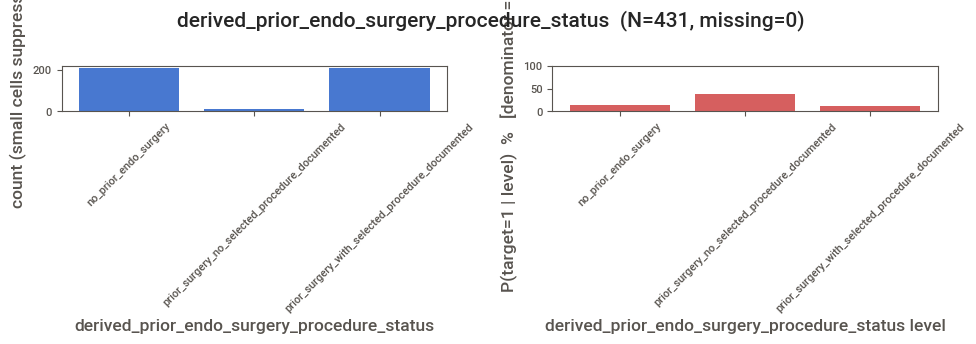

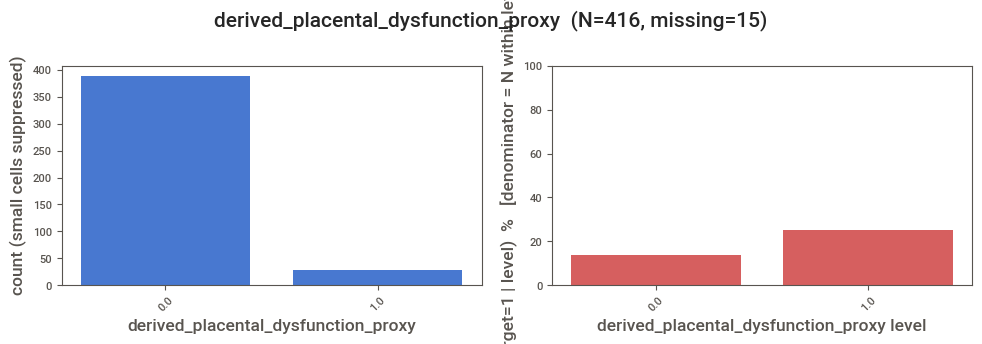

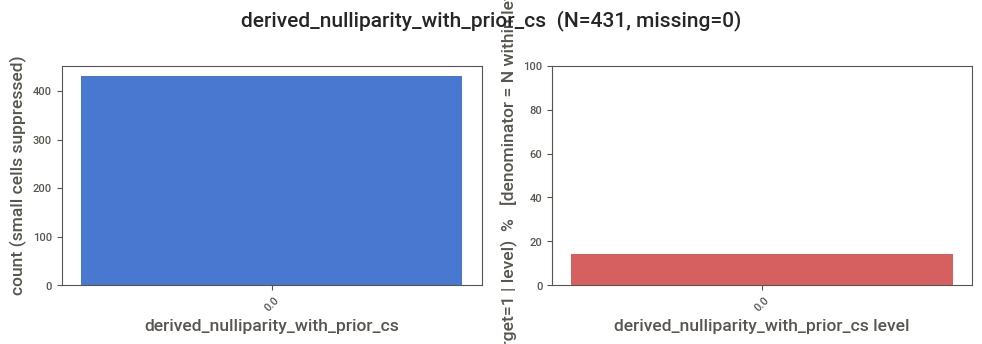

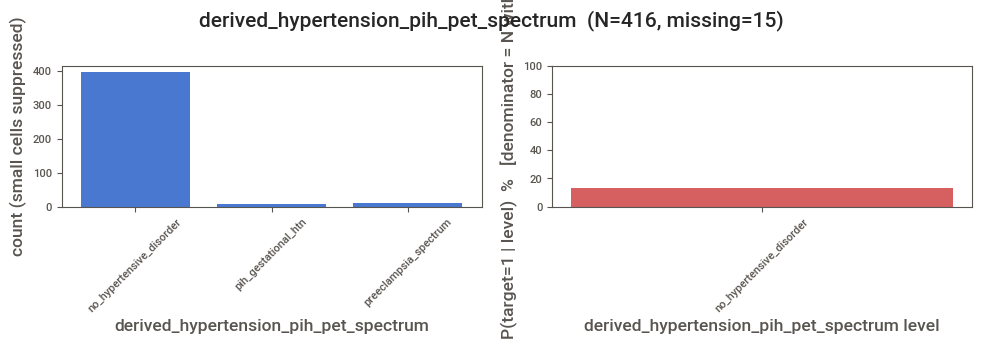

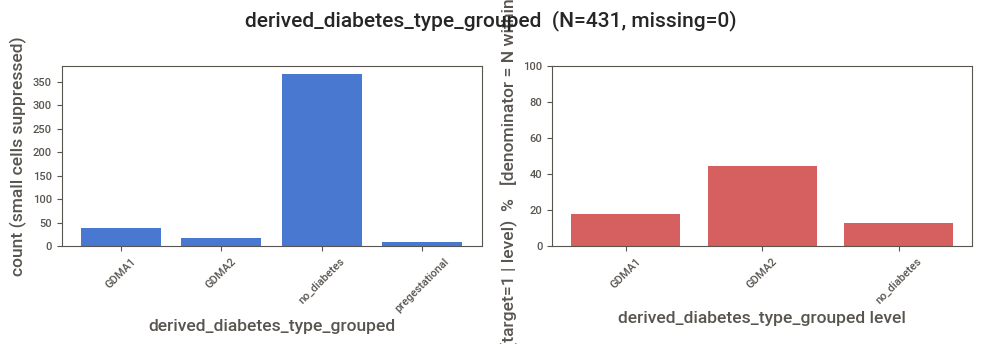


Original-predictor redundancy recheck (Spearman rho >= 0.7 | Cramér's V >= 0.5):


                                          var1                                 var2      measure  value
                                             G                                    P spearman_rho  0.778
                                             G                           LIVE_BIRTH spearman_rho  0.761
                                             P                           LIVE_BIRTH spearman_rho  0.962
                       weight_before_pregnancy                  weight_in_pregnancy spearman_rho  0.883
                       weight_before_pregnancy                           BMI_before spearman_rho  0.908
                       weight_before_pregnancy                            BMI_after spearman_rho  0.764
                           weight_in_pregnancy                           BMI_before spearman_rho  0.744
                           weight_in_pregnancy                            BMI_after spearman_rho  0.858
                                    BMI_before                  

In [15]:
def cramers_v(table):
    chi2 = stats.chi2_contingency(table, correction=False)[0]
    n = table.to_numpy().sum()
    denom = min(table.shape) - 1
    return float(np.sqrt(chi2 / (n * denom))) if n > 0 and denom > 0 else float("nan")


def _target_association(series, target, vtype, min_n=10):
    # Type-correct, UNSIGNED descriptive association between a (derived) feature
    # and the binary target. Returns (measure_name, strength_0_to_1):
    #   numeric                 -> |Spearman rho|
    #   binary                  -> |point-biserial r| (== |Pearson phi| for 0/1 x 0/1)
    #   multi-level categorical -> Cramer's V
    # Three DIFFERENT strength measures, NOT interchangeable as a signed effect --
    # the measure name is always carried alongside the number. No eligibility
    # decision depends on this.
    _p = pd.concat([series.rename("_f"), target.rename("_t")], axis=1).dropna()
    if len(_p) < min_n:
        return "insufficient_n", float("nan")
    if vtype == "numeric":
        _rho = stats.spearmanr(_p["_f"], _p["_t"]).statistic
        return "abs_spearman", (float(abs(_rho)) if pd.notna(_rho) else float("nan"))
    if vtype == "binary":
        _fn = pd.to_numeric(_p["_f"], errors="coerce")
        if _fn.notna().all() and set(_fn.unique()) <= {0.0, 1.0}:
            if _fn.nunique() < 2:
                return "abs_point_biserial", float("nan")  # constant -> undefined
            _r = np.corrcoef(_fn.to_numpy(float), _p["_t"].to_numpy(float))[0, 1]
            return "abs_point_biserial", (float(abs(_r)) if pd.notna(_r) else float("nan"))
        # non-clean binary coding -> fall back to Cramer's V, do NOT silently
        # return NaN from a failed .corr()
        _tab = pd.crosstab(_p["_f"], _p["_t"])
        return "cramers_v", (cramers_v(_tab) if min(_tab.shape) >= 2 else float("nan"))
    # multi-level categorical
    _tab = pd.crosstab(_p["_f"], _p["_t"])
    return "cramers_v", (cramers_v(_tab) if min(_tab.shape) >= 2 else float("nan"))


# ── Derived feature validation ─────────────────────────────────────────────────
print("=" * 70)
print("DERIVED FEATURE VALIDATION")
print("=" * 70)

_SS_C10 = bool(SHARE_SAFE_MODE) if "SHARE_SAFE_MODE" in dir() else True
_SS_C10_THR = share_safe.DEFAULT_DISCLOSURE_THRESHOLD

validation_rows = []
# Descriptive review threshold ONLY. NOT an eligibility threshold. A derived
# feature above it is flagged high_target_association_review for lineage/semantic
# review -- it is never hard-excluded, reclassified, or dropped for it.
# The legacy threshold constant name and the legacy leakage_flag column it
# backed are fully retired (2026-09-01) -- high_target_association_review is
# the sole canonical name for both the threshold and the flag.
DERIVED_TARGET_ASSOC_REVIEW_THRESHOLD = 0.7

_VALIDATION_COLS = [
    "derived_feature", "type", "N_valid", "missing_%", "max_src_missing_%",
    "derived_missingness_review", "miss_flag",
    "association_measure", "association_strength", "|r|_vs_target",
    "high_target_association_review",
    "max_redundancy", "redundancy_detail",
    "impossible_flag", "impossible_note",
    "separation_flag", "too_sparse_flag", "min_cell_count", "min_cell_count_display",
]
_contract_violations = []
_missing_contracts = []

for dv in DERIVED_VARS:
    src_str = derived_meta[dv]["source_columns"]
    src_cols = [c.strip() for c in src_str.split(",") if c.strip()]
    vtype = infer_var_type(df_analysis[dv])
    n_valid = int(df_analysis[dv].notna().sum())
    n_miss = int(df_analysis[dv].isna().sum())
    miss_pct = round(n_miss / len(df_analysis) * 100, 1)

    # (C4) derived_missingness_review -- DESCRIPTIVE heuristic only, no eligibility
    src_miss_pcts = [round(df_analysis[c].isna().mean() * 100, 1)
                     for c in src_cols if c in df_analysis.columns]
    max_src_miss = max(src_miss_pcts) if src_miss_pcts else float("nan")
    derived_missingness_review = bool(pd.notna(max_src_miss) and miss_pct > max_src_miss + 5)
    _miss_context = ""
    if derived_missingness_review:
        _miss_context = (
            f"formula needs {len(src_cols)} source field(s) jointly; combined "
            "missingness legitimately exceeds any single source -- descriptive only"
        )

    # (C2) type-correct target association (renamed concept: high_target_association_review)
    association_measure, association_strength = _target_association(
        df_analysis[dv], df_analysis[TARGET_COL], vtype
    )
    high_target_association_review = bool(
        pd.notna(association_strength)
        and association_strength > DERIVED_TARGET_ASSOC_REVIEW_THRESHOLD
    )

    # Redundancy with source columns (disclosure for EDA D, not a drop)
    redundancy_max = float("nan")
    redundancy_detail = ""
    for sc in src_cols:
        if sc not in df_analysis.columns:
            continue
        _pr = df_analysis[[dv, sc]].dropna()
        if len(_pr) < 10:
            continue
        sv = infer_var_type(df_analysis[sc])
        try:
            if vtype == "numeric" and sv == "numeric":
                r = abs(float(stats.spearmanr(_pr[dv], _pr[sc]).statistic))
            else:
                _tab = pd.crosstab(_pr[dv], _pr[sc])
                if _tab.shape[0] >= 2 and _tab.shape[1] >= 2:
                    r = cramers_v(_tab)
                else:
                    r = float("nan")
            if pd.notna(r) and (pd.isna(redundancy_max) or r > redundancy_max):
                redundancy_max = r
                redundancy_detail = f"{sc}:{r:.2f}"
        except Exception:
            pass

    # (C3) deterministic valid-value contract -- ALL materialized derived features.
    # Validates ONLY the formula's own declared output domain (DERIVED_FEATURE_CONTRACTS,
    # from C9) -- not an invented clinical plausibility range.
    _contract = DERIVED_FEATURE_CONTRACTS.get(dv)
    impossible_flag = False
    impossible_note = ""
    if _contract is None:
        _missing_contracts.append(dv)
        impossible_flag = True
        impossible_note = "NO DERIVED_FEATURE_CONTRACTS entry"
    else:
        _allowed = _contract["allowed_values"]
        _obs = df_analysis[dv].dropna()
        if vtype in ("binary", "numeric"):
            _obs_norm = set(
                float(v) for v in pd.to_numeric(_obs, errors="coerce").dropna().unique()
            )
            _allowed_norm = set(float(v) for v in _allowed)
        else:
            _obs_norm = set(_obs.astype(str).unique())
            _allowed_norm = set(str(v) for v in _allowed)
        _bad_vals = sorted(_obs_norm - _allowed_norm, key=str)
        if _bad_vals:
            impossible_flag = True
            impossible_note = f"values outside declared output domain: {_bad_vals}"
            _contract_violations.append(f"{dv}: {_bad_vals} not in {sorted(_allowed_norm, key=str)}")

    # Sparsity / separation gate -- C6 (sparsity_df) only covers ANALYSIS_VARS, not
    # DERIVED_VARS, so binary/categorical derived features must be checked here too.
    # Exact values kept in derived_validation_df; a share-safe display copy is made.
    separation_flag = False
    too_sparse_flag = False
    min_cell_count = -1
    if vtype in ("binary", "categorical"):
        _obs2 = df_analysis[[dv, TARGET_COL]].dropna(subset=[dv])
        _g0 = _obs2[_obs2[TARGET_COL] == 0]
        _g1 = _obs2[_obs2[TARGET_COL] == 1]
        _cells = []
        for _lvl in sorted(_obs2[dv].unique(), key=str):
            _cells.append(int((_g0[dv] == _lvl).sum()))
            _cells.append(int((_g1[dv] == _lvl).sum()))
        min_cell_count = min(_cells) if _cells else 0
        separation_flag = any(c == 0 for c in _cells)
        too_sparse_flag = (not separation_flag) and (min_cell_count < 5)
    _min_cell_display = share_safe.safe_count(
        min_cell_count if min_cell_count >= 0 else None,
        threshold=_SS_C10_THR, enabled=_SS_C10,
    )

    row = {
        "derived_feature": dv,
        "type": vtype,
        "N_valid": n_valid,
        "missing_%": miss_pct,
        "max_src_missing_%": max_src_miss,
        "derived_missingness_review": derived_missingness_review,
        "miss_flag": derived_missingness_review,   # legacy alias, same value
        "association_measure": association_measure,
        "association_strength": round(association_strength, 3) if pd.notna(association_strength) else float("nan"),
        "|r|_vs_target": round(association_strength, 3) if pd.notna(association_strength) else float("nan"),
        "high_target_association_review": high_target_association_review,
        "max_redundancy": round(redundancy_max, 3) if pd.notna(redundancy_max) else float("nan"),
        "redundancy_detail": redundancy_detail,
        "impossible_flag": impossible_flag,
        "impossible_note": impossible_note,
        "separation_flag": separation_flag,
        "too_sparse_flag": too_sparse_flag,
        "min_cell_count": min_cell_count,
        "min_cell_count_display": _min_cell_display,
        "derived_missingness_context": _miss_context,
    }
    validation_rows.append(row)

    flags = []
    if derived_missingness_review:
        flags.append("MISSINGNESS_REVIEW")
    if high_target_association_review:
        flags.append("HIGH_TARGET_ASSOC_REVIEW")
    if impossible_flag:
        flags.append("CONTRACT_VIOLATION")
    if separation_flag:
        flags.append("SEPARATION")
    elif too_sparse_flag:
        flags.append("SPARSE")
    flag_str = " | ".join(flags) if flags else "ok"
    print(f"  {dv:<40} {flag_str}  [{association_measure}={row['association_strength']}]")

# (C3 / PART H) fail loud on any contract gap or violation -- deterministic
# derivation-integrity failures, not tolerated.
if _missing_contracts:
    raise RuntimeError(
        "C10: materialized derived feature(s) have NO DERIVED_FEATURE_CONTRACTS "
        f"entry: {_missing_contracts}. Every materialized derived feature must "
        "have a shared formula/valid-value contract (defined in C9)."
    )
if _contract_violations:
    raise RuntimeError(
        "C10: derived-feature deterministic valid-value contract VIOLATED -- an "
        "observed derived value is outside the formula's own declared output "
        "domain: " + "; ".join(_contract_violations)
    )

derived_validation_df = pd.DataFrame(validation_rows, columns=_VALIDATION_COLS + ["derived_missingness_context"])
# share-safe display copy: exact analytical frame keeps every value; the printed
# copy hides protected small min-cell counts only (presentation layer).
derived_validation_display_df = derived_validation_df.drop(columns=["min_cell_count", "derived_missingness_context"])
print()
print(derived_validation_display_df.to_string(index=False))
print()
print("NOTE: association_strength is a TYPE-CORRECT descriptive measure "
      "(abs_spearman / abs_point_biserial / cramers_v -- named per row, NOT a "
      "signed cross-comparable effect). high_target_association_review "
      "is a lineage-review flag ONLY -- no eligibility effect. "
      "min_cell_count shown share-safe; exact value retained in derived_validation_df.")

# ── PART H reconciliation: every materialized DERIVED_VARS member is covered ──
_recon_c10 = []
for _dv in DERIVED_VARS:
    _has_meta = _dv in derived_meta
    _has_contract = _dv in DERIVED_FEATURE_CONTRACTS
    _n_rows = int((derived_validation_df["derived_feature"] == _dv).sum())
    _recon_c10.append({"derived_feature": _dv, "has_derived_meta": _has_meta,
                       "has_contract": _has_contract, "validation_rows": _n_rows})
derived_coverage_df = pd.DataFrame(
    _recon_c10, columns=["derived_feature", "has_derived_meta", "has_contract", "validation_rows"]
)
print()
print("C10 derived-feature coverage reconciliation:")
print(derived_coverage_df.to_string(index=False) if len(derived_coverage_df) else "  (no materialized derived features)")
_cov_bad = derived_coverage_df[
    (~derived_coverage_df["has_derived_meta"]) | (~derived_coverage_df["has_contract"])
    | (derived_coverage_df["validation_rows"] != 1)
] if len(derived_coverage_df) else derived_coverage_df
if len(_cov_bad):
    raise RuntimeError(
        "C10 coverage reconciliation FAILED -- each materialized DERIVED_VARS member "
        "must have derived_meta, a DERIVED_FEATURE_CONTRACTS entry, and exactly one "
        f"derived_validation_df row:\n{_cov_bad.to_string(index=False)}"
    )

# ── Distribution plots for derived features ────────────────────────────────────
print()
print("Derived feature distributions:")
for dv in DERIVED_VARS:
    vtype = infer_var_type(df_analysis[dv])
    _data = df_analysis[dv].dropna()
    if _data.empty:
        print(f"  {dv}: all missing — skipping plot")
        continue
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    if vtype == "numeric":
        sns.histplot(
            data=df_analysis[[dv, TARGET_COL]].dropna(),
            x=dv, hue=TARGET_COL, stat="density", common_norm=False,
            kde=True, element="step", ax=axes[0], palette={0: _C0, 1: _C1},
        )
        sns.boxplot(
            data=df_analysis[[dv, TARGET_COL]].dropna(),
            x=TARGET_COL, y=dv, hue=TARGET_COL, ax=axes[1],
            palette={0: _C0, 1: _C1}, legend=False,
        )
        axes[1].set_xlabel("0=Vaginal  1=Intrapartum CS")
    else:
        # LEFT: aggregate level-count bar (share-safe: small bars masked)
        _vc = df_analysis[dv].value_counts().sort_index()
        _cohort_n = int(df_analysis[dv].notna().sum())
        _bar_x, _bar_h = [], []
        for _lev, _cnt in _vc.items():
            _disp = share_safe.safe_count_with_complement(
                int(_cnt), _cohort_n, threshold=_SS_C10_THR, enabled=_SS_C10)
            _bar_x.append(str(_lev))
            _bar_h.append(np.nan if isinstance(_disp, str) else int(_cnt))
        axes[0].bar([x for x, h in zip(_bar_x, _bar_h) if not (isinstance(h, float) and np.isnan(h))],
                    [h for h in _bar_h if not (isinstance(h, float) and np.isnan(h))], color=_C0)
        axes[0].set_xlabel(dv)
        axes[0].set_ylabel("count (small cells suppressed)")
        axes[0].tick_params(axis="x", rotation=45)
        # RIGHT: explicitly-denominated target-stratified rate -- P(target=1 | level).
        # Row-normalised crosstab (denominator = N within that derived level),
        # matching the corrected-C4b "within-level %" convention. This is
        # P(target | category), NOT P(category | target).
        _ct = pd.crosstab(df_analysis[dv], df_analysis[TARGET_COL])
        _within_level_n = _ct.sum(axis=1)
        _p_t1_given_level = (_ct.get(1, pd.Series(0, index=_ct.index)) / _within_level_n)
        _rate_x, _rate_h = [], []
        for _lev in _ct.index:
            _c1 = int(_ct.get(1, pd.Series(0, index=_ct.index)).get(_lev, 0))
            _t = int(_within_level_n.get(_lev, 0))
            _pct, _ = share_safe.safe_pct_with_denominator(
                _c1, _t, threshold=_SS_C10_THR, enabled=_SS_C10)
            _rate_x.append(str(_lev))
            _rate_h.append(_pct if isinstance(_pct, (int, float)) else np.nan)
        axes[1].bar(_rate_x, _rate_h, color=_C1)
        axes[1].set_xlabel(f"{dv} level")
        axes[1].set_ylabel("P(target=1 | level)  %   [denominator = N within level]")
        axes[1].tick_params(axis="x", rotation=45)
        axes[1].set_ylim(0, max(100, np.nanmax(_rate_h + [1]) * 1.15))
    _n_miss_p = int(df_analysis[dv].isna().sum())
    _n_disp = share_safe.safe_count_with_complement(
        len(_data), len(df_analysis), threshold=_SS_C10_THR, enabled=_SS_C10)
    fig.suptitle(f"{dv}  (N={_n_disp}, missing={share_safe.safe_count(_n_miss_p, threshold=_SS_C10_THR, enabled=_SS_C10)})")
    plt.tight_layout()
    plt.show()

# ── Original-predictor redundancy matrix (recheck) ────────────────────────────
print()
print("Original-predictor redundancy recheck (Spearman rho >= 0.7 | Cramér's V >= 0.5):")
_numeric_vars = [c for c in ANALYSIS_VARS if infer_var_type(df_analysis[c]) == "numeric"]
_cat_vars = [c for c in ANALYSIS_VARS if infer_var_type(df_analysis[c]) in ("binary", "categorical")]

_REDUNDANCY_PAIRS_COLS = ["var1", "var2", "measure", "value"]
high_redundancy_pairs = []
if len(_numeric_vars) >= 2:
    for i, v1 in enumerate(_numeric_vars):
        for v2 in _numeric_vars[i + 1:]:
            _pair = df_analysis[[v1, v2]].dropna()
            if len(_pair) >= 10:
                rho = stats.spearmanr(_pair[v1], _pair[v2]).statistic
                if pd.notna(rho) and abs(rho) >= 0.7:
                    high_redundancy_pairs.append({"var1": v1, "var2": v2,
                                                   "measure": "spearman_rho",
                                                   "value": round(float(rho), 3)})
if len(_cat_vars) >= 2:
    for i, v1 in enumerate(_cat_vars):
        for v2 in _cat_vars[i + 1:]:
            _pair = df_analysis[[v1, v2]].dropna()
            if len(_pair) >= 10:
                _tab = pd.crosstab(_pair[v1], _pair[v2])
                if _tab.shape[0] >= 2 and _tab.shape[1] >= 2:
                    cv = cramers_v(_tab)
                    if pd.notna(cv) and cv >= 0.5:
                        high_redundancy_pairs.append({"var1": v1, "var2": v2,
                                                       "measure": "cramers_v",
                                                       "value": round(cv, 3)})

redundancy_pairs_df = pd.DataFrame(high_redundancy_pairs, columns=_REDUNDANCY_PAIRS_COLS)
if len(redundancy_pairs_df):
    print(redundancy_pairs_df.to_string(index=False))
else:
    print("  No high-redundancy pairs found (rho >= 0.7 or V >= 0.5).")

# ── Explicit named redundancy pairs (raw source vs. deterministic derivative) ──
# The generic pairwise scan above will surface these numerically, but the
# specific relationship, audit visibility, and enforcement point are
# documented explicitly here rather than left implicit in a large pairs table.
print()
print("Named raw/deterministic-derivative pairs (explicit documentation):")
_named_pairs = [
    {
        "pair": ("mode_of_conception", "mode_of_conception_ivf_vs_all"),
        "relationship_type": (
            "mode_of_conception_ivf_vs_all is a deterministic re-expression of "
            "mode_of_conception (== 1 iff mode_of_conception == 1, else 0; "
            "Decision 30), carrying no information not already in "
            "mode_of_conception."
        ),
        "both_visible_for_audit": "yes -- both remain in df_analysis and ANALYSIS_VARS",
        "may_both_enter_same_model": (
            "NO -- this is one of the eight HARD, target-independent co-entry "
            "pairs in the C13 contract (reason_type = deterministic_recompute; "
            "sole authored source: contracts/model_coentry_constraints.yaml). "
            "EDA C keeps BOTH eligible (it does not pre-judge eligibility by "
            "dropping one), but the contract records that they may never be "
            "simultaneously entered as independent model predictors, in any "
            "model family including LASSO / Elastic Net. This is a "
            "deterministic-lineage fact, NOT target-informed feature selection."
        ),
        "redundancy_decision_enforced_where": (
            "C13 hard co-entry registry (target-independent, global). EDA C keeps "
            "both eligible; the co-entry prohibition is a fixed contract, not a "
            "target-informed CV choice."
        ),
    },
]
for _p in _named_pairs:
    _v1, _v2 = _p["pair"]
    _both_present = _v1 in df_analysis.columns and _v2 in df_analysis.columns
    print(f"  {_v1} <-> {_v2}  (both present in df_analysis: {_both_present})")
    print(f"    Relationship  : {_p['relationship_type']}")
    print(f"    Audit visible : {_p['both_visible_for_audit']}")
    print(f"    Same model?   : {_p['may_both_enter_same_model']}")
    print(f"    Enforced where: {_p['redundancy_decision_enforced_where']}")
    if _both_present:
        _pair_data = df_analysis[[_v1, _v2]].dropna()
        if len(_pair_data) >= 10:
            _tab = pd.crosstab(_pair_data[_v1], _pair_data[_v2])
            if _tab.shape[0] >= 2 and _tab.shape[1] >= 2:
                _cv = cramers_v(_tab)
                print(f"    Measured Cramer's V (this run, N={len(_pair_data)}): {_cv:.3f}")

## Section C10b — Derived-Feature Formula and Interpretation Registry

Documents, for **every materialized** derived feature validated in C10 above:
the exact formula/rule, its intended clinical interpretation, and its
valid-value range. This is documentation only — it creates no new column.

**Single source of truth.** The deterministic parts (formula inputs, rule,
allowed non-missing output values, NaN propagation) are pulled directly from
the shared `DERIVED_FEATURE_CONTRACTS` object defined in C9 and also used by
C10's valid-value check and the tests — there is **no second, independently
maintained valid-value set**. C10b adds only the clinical-interpretation text.

**Coverage is FAIL-LOUD.** If any materialized `DERIVED_VARS` member has no
registry entry, this section raises — a canonical EDA C run must never claim
complete derived-feature documentation while a materialized feature has no
formula contract.

`derived_endo_surgery_adhesion_status` appears here as **lineage-only**
documentation (it is created upstream in Data Cleaning B, not in EDA C, and is
not in `DERIVED_VARS`); its current B implementation has **3 active states** —
the retired `prior_surgery_adhesion_status_unknown` state is not materialized
and is not listed as an active valid value.

In [16]:
# Clinical-interpretation text ONLY -- the deterministic formula/valid-value
# parts come from the shared DERIVED_FEATURE_CONTRACTS (C9). Keeping the two
# layers separate avoids a divergent second registry (PART D3).
_DERIVED_INTERPRETATION = {
    "derived_prior_endo_surgery_procedure_status": {
        "interpretation": (
            "Exploratory prior-endometriosis-surgery status with a coarse "
            "documentation-status distinction for a selected subset of reliably "
            "coded structured procedure variables; NOT a severity score, NOT a "
            "burden score, and NOT a claim that 'no selected procedure documented' "
            "means no procedure occurred"
        ),
    },
    "derived_placental_dysfunction_proxy": {
        "interpretation": (
            "Exploratory placenta-mediated complication proxy based only on PET "
            "status and IUGR; NOT a validated clinical score, NOT a severity "
            "score, and NOT a missingness indicator"
        ),
    },
    "derived_nulliparity_with_prior_cs": {
        "interpretation": (
            "SANITY-CHECK ONLY -- flags a logically inconsistent combination "
            "(nulliparous but has a prior CS); not a modeling candidate. A "
            "non-zero count indicates a data-quality issue, not a real clinical "
            "subgroup"
        ),
    },
    "derived_hypertension_pih_pet_spectrum": {
        "interpretation": (
            "Approved 3-level clinical grouping of the hypertension family "
            "(Decision 77): none / PIH-gestational-hypertension / "
            "preeclampsia-spectrum. Defined from clinical/source semantics "
            "(Decision 45), NOT target association. Co-entry with the individual "
            "hypertension source variables is review_within_modeling "
            "(hypertension_spectrum relationship group) -- NOT an automatic HARD "
            "pair; this feature has no HARD co-entry pair in the C13 registry"
        ),
    },
    "derived_diabetes_type_grouped": {
        "interpretation": (
            "Approved 4-level grouping of diabetes_type's confirmed code "
            "dictionary (Decision 78): no_diabetes / pregestational (1,2,3) / "
            "GDMA1 (4) / GDMA2 (5). Grouped on category-size and clinical-"
            "interpretability grounds, NOT target association"
        ),
    },
}

# Lineage-only entry for the B-created adhesion-status column (NOT in DERIVED_VARS).
_ADHESION_LINEAGE_ONLY = {
    "derived_endo_surgery_adhesion_status": {
        "status": "lineage_only -- created in Data Cleaning B (Section B5g, 2026-08-27), not EDA C",
        "formula": (
            "no_prior_endo_surgery if endometriosis_surgery==0; "
            "prior_surgery_without_documented_adhesions if endometriosis_surgery==1 and "
            "endo_surgery_adhesiolysis==0; prior_surgery_with_documented_adhesions if "
            "endometriosis_surgery==1 and endo_surgery_adhesiolysis==1"
        ),
        "interpretation": (
            "Exploratory prior-endometriosis-surgery adhesion finding/status "
            "representation; does NOT indicate whether adhesiolysis was performed; "
            "NOT a severity/burden score, NOT a standalone missingness indicator"
        ),
        "active_valid_values": "{no_prior_endo_surgery, prior_surgery_without_documented_adhesions, "
                               "prior_surgery_with_documented_adhesions} + NaN (3 active states; "
                               "the retired 'prior_surgery_adhesion_status_unknown' state is NOT "
                               "materialized in the current B implementation)",
    },
}

# Assemble the printed registry for materialized features from the SHARED contract.
DERIVED_VAR_FORMULAS = {}
for _dv in DERIVED_VARS:
    _c = DERIVED_FEATURE_CONTRACTS.get(_dv)
    _i = _DERIVED_INTERPRETATION.get(_dv, {})
    if _c is None:
        continue
    _allowed_disp = "{" + ", ".join(sorted(str(v) for v in _c["allowed_values"])) + ", NaN}"
    DERIVED_VAR_FORMULAS[_dv] = {
        "formula_inputs": _c["formula_inputs"],
        "formula": _c["rule"],
        "nan_propagation": _c["nan_propagation"],
        "valid_range": _allowed_disp,
        "intended_interpretation": _i.get("interpretation", "(interpretation text missing)"),
    }

print("Derived-feature formula/interpretation/valid-range registry "
      "(deterministic parts from the shared DERIVED_FEATURE_CONTRACTS):")
for _dv in DERIVED_VARS:
    _f = DERIVED_VAR_FORMULAS.get(_dv)
    if _f is None:
        continue
    print(f"  {_dv}")
    print(f"    Formula inputs : {_f['formula_inputs']}")
    print(f"    Rule           : {_f['formula']}")
    print(f"    NaN propagation : {_f['nan_propagation']}")
    print(f"    Valid range    : {_f['valid_range']}")
    print(f"    Interpretation : {_f['intended_interpretation']}")

print()
print("Lineage-only (created in Data Cleaning B, not EDA C):")
for _dv, _e in _ADHESION_LINEAGE_ONLY.items():
    print(f"  {_dv}  [{_e['status']}]")
    print(f"    Rule                : {_e['formula']}")
    print(f"    Active valid values : {_e['active_valid_values']}")

# PART D1: missing registry coverage of a MATERIALIZED feature is now FAIL-LOUD.
_missing_registry = [dv for dv in DERIVED_VARS if dv not in DERIVED_VAR_FORMULAS]
if _missing_registry:
    raise RuntimeError(
        "C10b: materialized derived feature(s) have NO formula/interpretation "
        f"registry entry: {_missing_registry}. A canonical EDA C run must not "
        "claim complete derived-feature validation while a materialized feature "
        "has no formula contract."
    )
# Cross-check: the shared contract's allowed_values must match what C10 validated.
for _dv in DERIVED_VARS:
    _c10_note = derived_validation_df.loc[
        derived_validation_df["derived_feature"] == _dv, "impossible_note"
    ]
    assert len(_c10_note) == 1 and not str(_c10_note.iloc[0]).startswith("values outside"), (
        f"C10b: {_dv} failed its C10 valid-value contract check -- registries disagree"
    )
print()
print("C10b coverage OK: every materialized DERIVED_VARS member has a shared-contract "
      "registry entry; no divergent valid-value set is maintained here.")

Derived-feature formula/interpretation/valid-range registry (deterministic parts from the shared DERIVED_FEATURE_CONTRACTS):
  derived_prior_endo_surgery_procedure_status
    Formula inputs : ['endometriosis_surgery', 'endo_resection_ovarian_endometrioma_unilateral', 'endo_resection_lesion', 'endo_resection_adhesiolysis']
    Rule           : no_prior_endo_surgery if endometriosis_surgery==0; prior_surgery_no_selected_procedure_documented if endometriosis_surgery==1 and all 3 selected procedure vars are observed and ==0; prior_surgery_with_selected_procedure_documented if endometriosis_surgery==1 and all 3 selected procedure vars are observed and any ==1
    NaN propagation : NaN when endometriosis_surgery is missing, or when endometriosis_surgery==1 and any selected-procedure source is missing (status unresolvable)
    Valid range    : {no_prior_endo_surgery, prior_surgery_no_selected_procedure_documented, prior_surgery_with_selected_procedure_documented, NaN}
    Interpretation : Exp

## Section C10c — Predictor–Predictor Relationships & Redundancy (adapts CURRENT A2.10)

Ports the richer **CURRENT A2 Section A2.10** predictor–predictor architecture
onto the cleaned analysis universe (`ANALYSIS_VARS` + implementable derived
features, i.e. `SCREEN_VARS`):

- **A. Numeric–numeric** — Spearman correlation matrix + heatmap; high-|ρ| pair
  table (|ρ| ≥ 0.7); one scatterplot per high-|ρ| pair (not every pair).
- **B. Numeric–categorical** — per pair, Kruskal–Wallis H + epsilon-squared
  effect size. The Kruskal H statistic is computed only on the **retained
  groups** (each ≥ 3 observations, preserving the A2 convention), so the
  epsilon-squared denominator and the reported analysis N use **exactly those
  same observations** — `n_analyzed = Σ len(retained group)`, never
  `len(complete_pair)`. Each row exposes `n_complete_pair`, `n_analyzed`,
  `n_excluded_small_groups`, `n_groups_analyzed`, `kruskal_H`, `p_value`,
  `epsilon_squared`. A pair with fewer than two analyzable groups is skipped
  with a documented reason. The ε² ≥ 0.10 descriptive threshold is applied to
  the **corrected** effect size. No eligibility decision depends on it.
- **C. Categorical–categorical** — Cramér's V matrix + heatmap; high-V pair
  table (V ≥ 0.5).
- **D. Representation-relationship classification** for **every** high-association
  pair from A, B **and** C — including numeric×categorical: `exact/superseded
  duplicate` / `deterministic re-expression` / `clinically overlapping` /
  `clinically distinct but correlated`. Each row keeps its own
  `strength_measure` (`spearman_rho` / `cramers_v` / `epsilon_squared`) — these
  are **different, non-interchangeable** strength scales, never compared as a
  signed effect. B-lineage matching uses **exact source-variable tokens** (the
  feature-dictionary comma delimiter), not substring containment.
- **D (audit).** The known deterministic pairs `P ↔ nulliparity` and
  `CS ↔ S_P_CS` are audited explicitly: if they meet the live high-association
  criterion they appear in the classification table; otherwise their measured
  relationship is reported as a named deterministic-lineage check so the known
  relationship is never lost to an arbitrary descriptive threshold.

**No variable is removed here.** High pairwise association is disclosed for
EDA D's collinearity handling — a high correlation between two clinically
distinct predictors is NOT a duplicate. No target variable is used in any
representation-classification decision.

### Cramér's V estimator — final methodological decision (2026-09-01)
The **uncorrected** Cramér's V estimator (`chi2_contingency(..., correction=
False)`, `sqrt(chi2 / (n * (min(table.shape) - 1)))`) is retained as canonical
across A1/A2/EDA C for cross-stage consistency, not because it is assumed to
be universally superior to the bias-corrected (Bergsma–Wicher) estimator. It
is a **descriptive/diagnostic association-strength measure only**: the V ≥ 0.5
threshold above is a descriptive review threshold, no feature
eligibility/exclusion decision is based on Cramér's V alone, and no hard
co-entry constraint is ever generated from it. A bias-corrected sensitivity
check was performed against the live 431-row cohort's high-association
categorical–categorical pairs (49 pairs at the current V ≥ 0.5 threshold,
including the newly-eligible PET-family pairs): it changed values slightly
and moved 3 pairs below the descriptive 0.5 threshold
(`indication_for_induction_status`↔`derived_hypertension_pih_pet_spectrum`,
`any_PET_cat`↔`indication_for_induction_status`,
`endo_resection_ovarian_endometrioma_unilateral`↔`derived_prior_endo_surgery_
procedure_status`). It changed **no** eligibility, candidate-pool,
hard-exclusion, co-entry, or modeling decision — therefore it does not
replace the canonical estimator.

C10c predictor-predictor scope: 85 variables (14 numeric, 71 binary/categorical)


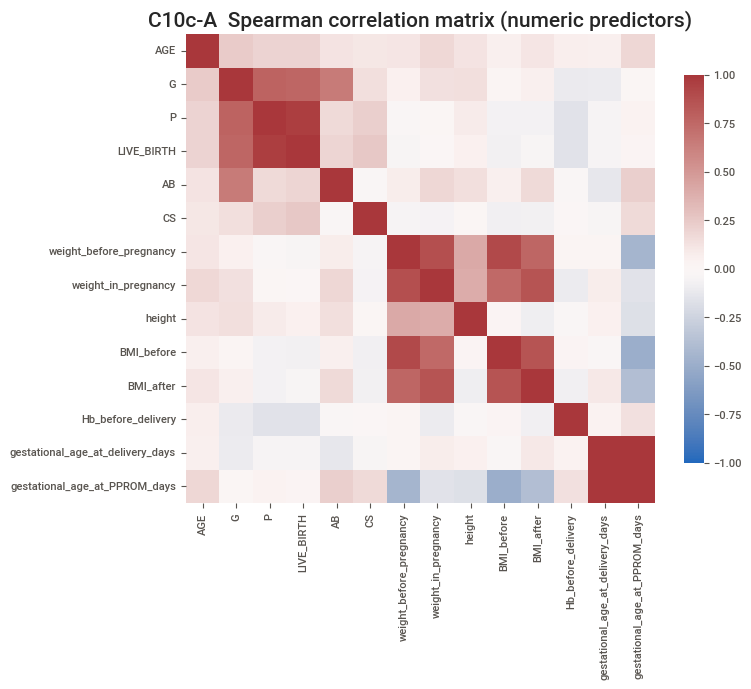


A. High numeric-numeric correlation (|Spearman rho| >= 0.7):
                           var_a                         var_b  spearman_rho   n
gestational_age_at_delivery_days gestational_age_at_PPROM_days         0.993  16
                               P                    LIVE_BIRTH         0.962 431
         weight_before_pregnancy                    BMI_before         0.908 317
         weight_before_pregnancy           weight_in_pregnancy         0.883 163
                      BMI_before                     BMI_after         0.859 160
             weight_in_pregnancy                     BMI_after         0.858 184
                               G                             P         0.778 431
         weight_before_pregnancy                     BMI_after         0.764 160
                               G                    LIVE_BIRTH         0.761 431
             weight_in_pregnancy                    BMI_before         0.744 160


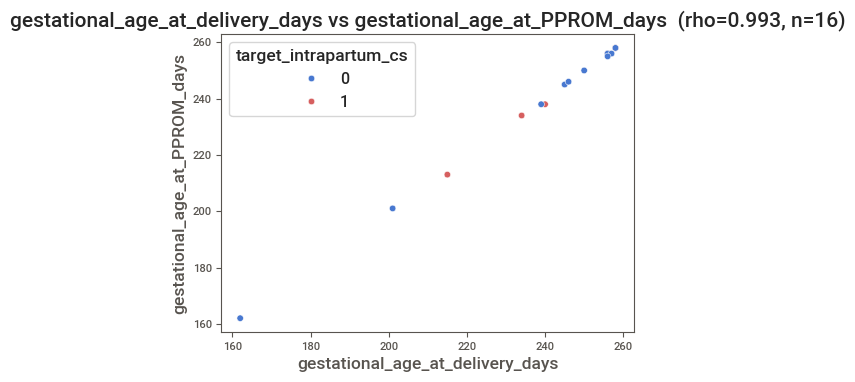

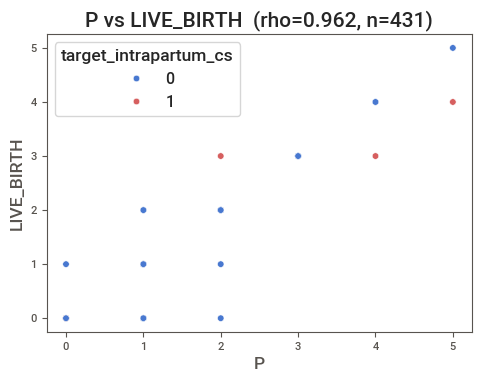

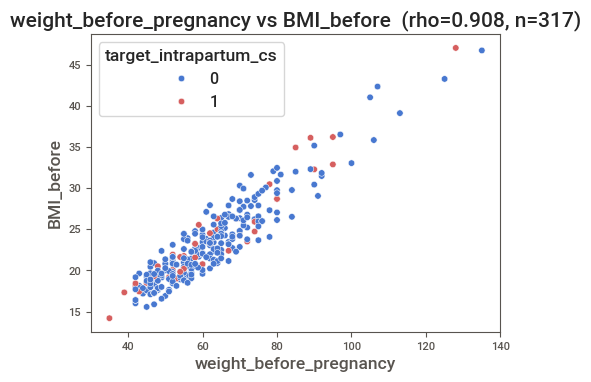

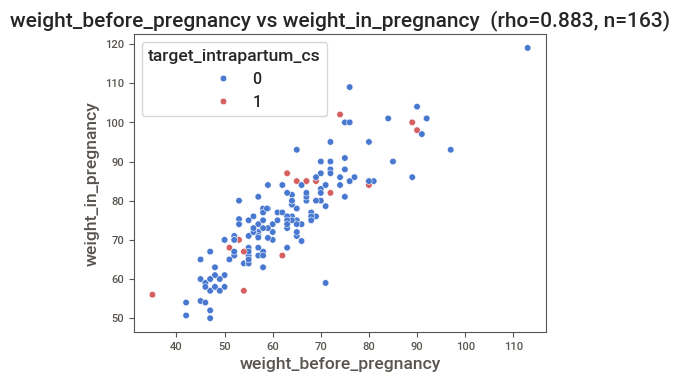

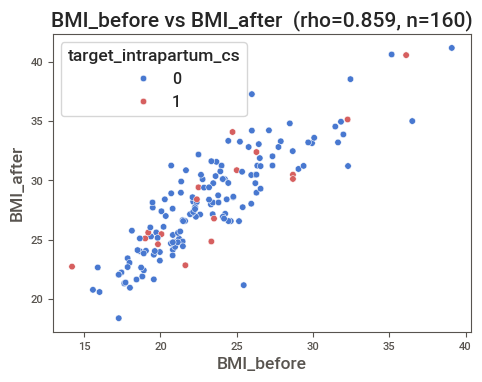

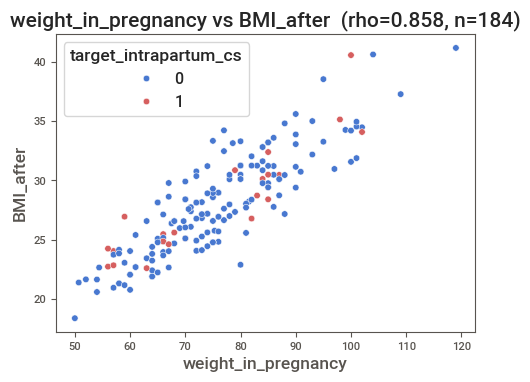

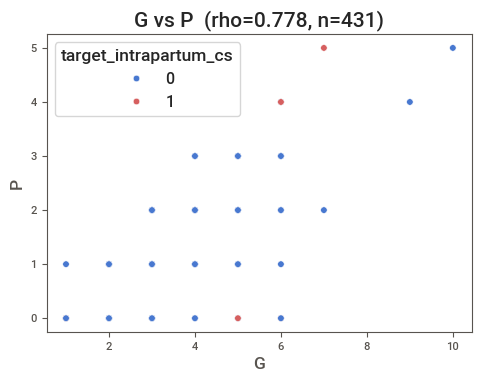

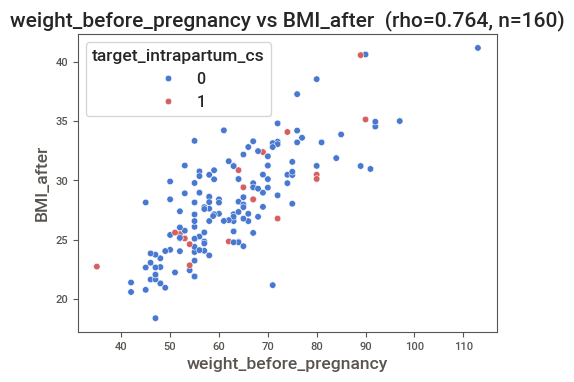

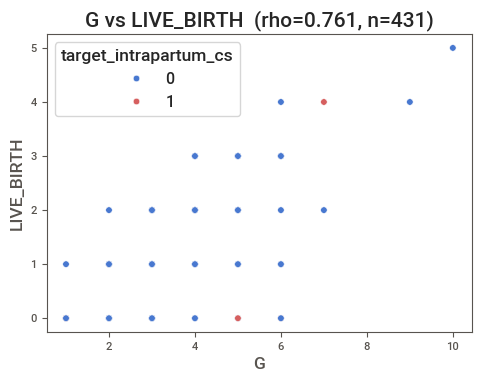

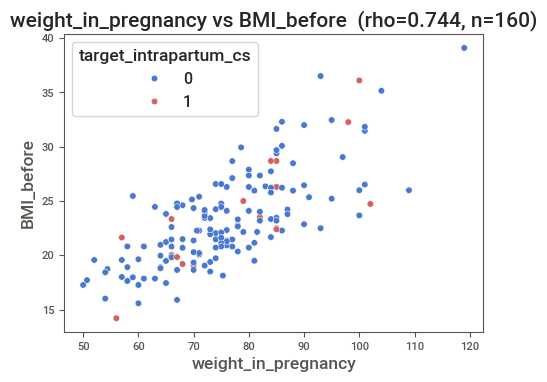


B. Numeric x categorical (Kruskal-Wallis on retained groups; epsilon^2 uses n_analyzed = sum of retained-group sizes, NOT len(complete_pair)):
                         numeric                                    categorical  n_complete_pair  n_analyzed  n_excluded_small_groups  n_groups_analyzed  kruskal_H  p_value  epsilon_squared  high_association                             skipped_reason
                              CS                                         S_P_CS              431         431                        0                  2    429.920    0.000            1.000              True                                           
                               P                                    nulliparity              431         431                        0                  2    394.020    0.000            0.916              True                                           
                      LIVE_BIRTH                                    nulliparity              431       

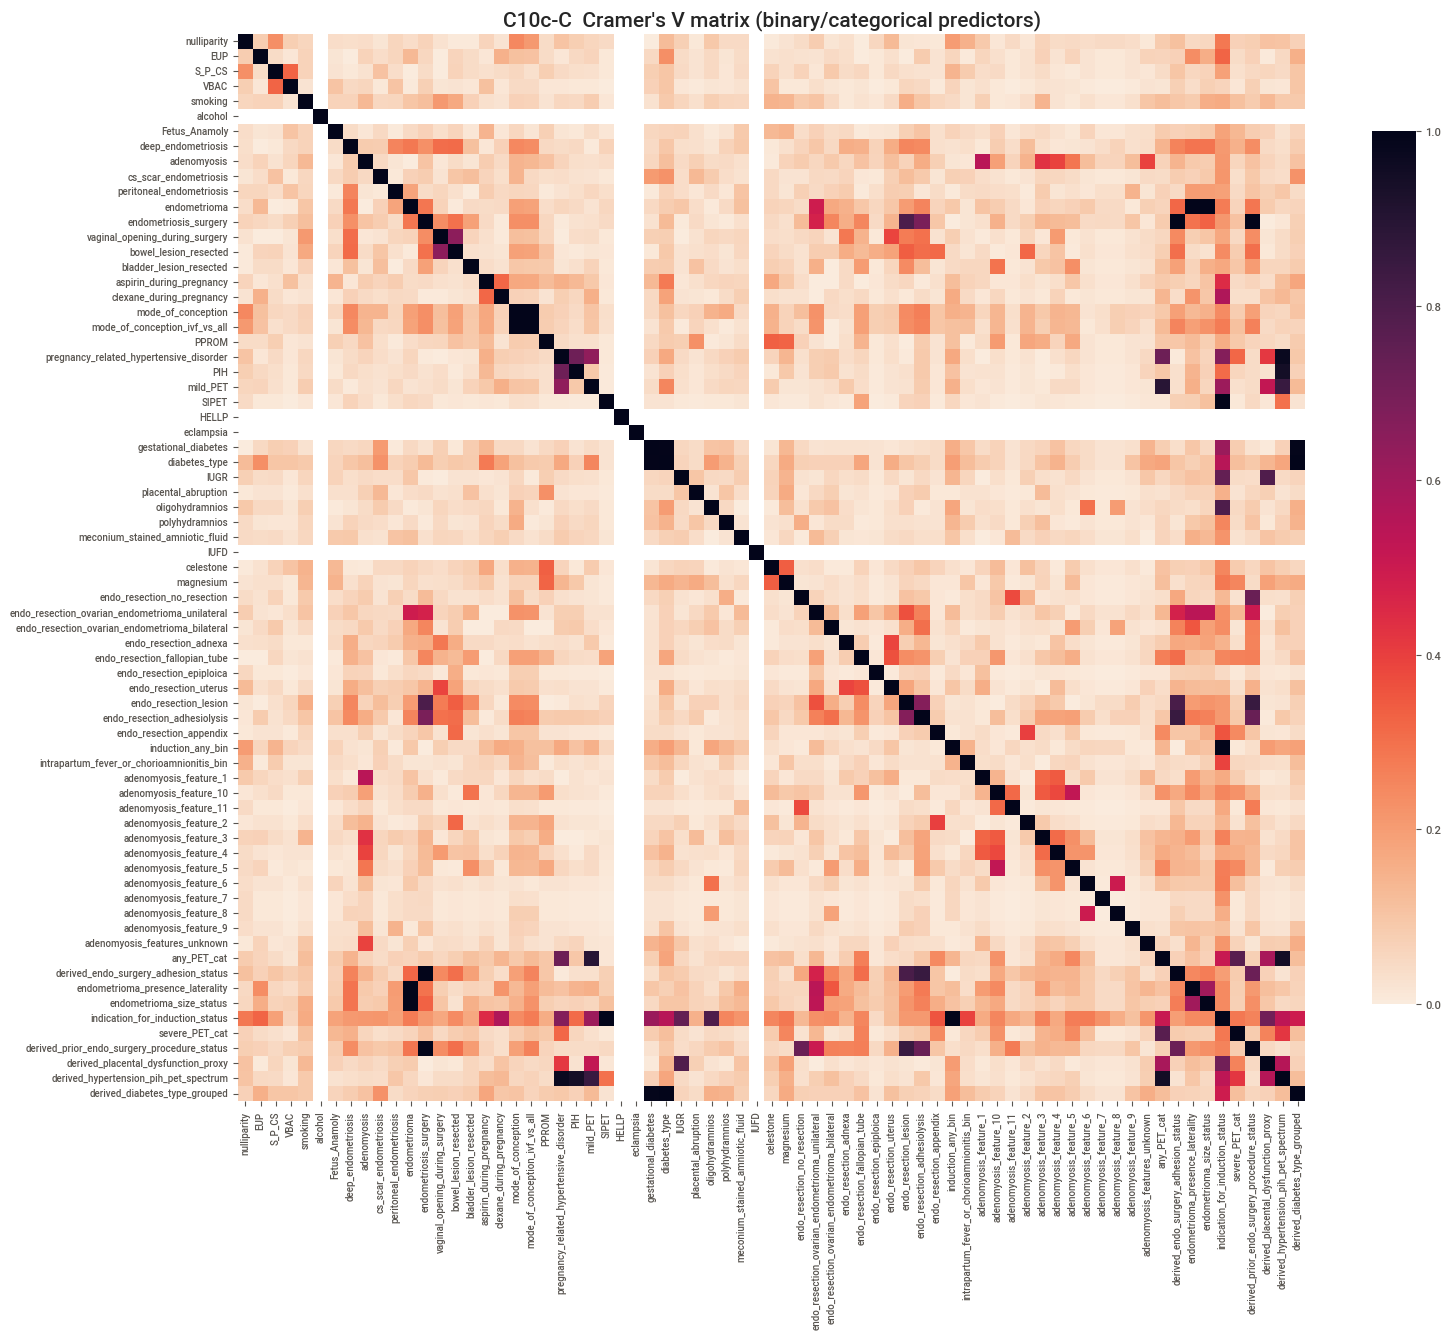


C. High categorical-categorical association (Cramer's V >= 0.5):
                                         var_a                                       var_b  cramers_v   n
                                  endometrioma            endometrioma_presence_laterality      1.000 431
                            mode_of_conception               mode_of_conception_ivf_vs_all      1.000 431
                                  endometrioma                    endometrioma_size_status      1.000 431
                         endometriosis_surgery derived_prior_endo_surgery_procedure_status      1.000 431
                         endometriosis_surgery        derived_endo_surgery_adhesion_status      1.000 431
                                 diabetes_type               derived_diabetes_type_grouped      1.000 431
                             induction_any_bin             indication_for_induction_status      1.000 431
                                         SIPET             indication_for_induction_st

In [17]:
# C10c runs before C11, so SCREEN_VARS is not defined yet -- build the same
# universe inline (ANALYSIS_VARS + implementable derived features).
_rel_vars = [c for c in (ANALYSIS_VARS + [dv for dv in DERIVED_VARS
             if dv != "derived_nulliparity_with_prior_cs"]) if c in df_analysis.columns]
_num = [c for c in _rel_vars if infer_var_type(df_analysis[c]) == "numeric"]
_cat = [c for c in _rel_vars if infer_var_type(df_analysis[c]) in ("binary", "categorical")]
print(f"C10c predictor-predictor scope: {len(_rel_vars)} variables ({len(_num)} numeric, {len(_cat)} binary/categorical)")

# ── A. Numeric-numeric: Spearman matrix + heatmap + high-|rho| pairs ──────────
numeric_spearman_df = pd.DataFrame()
nn_high_pairs_df = pd.DataFrame()
if len(_num) >= 2:
    numeric_spearman_df = df_analysis[_num].corr(method="spearman")
    fig, ax = plt.subplots(figsize=(min(1.0 + 0.5 * len(_num), 14), min(1.0 + 0.5 * len(_num), 14)))
    sns.heatmap(numeric_spearman_df, cmap="vlag", center=0, vmin=-1, vmax=1, square=True,
                cbar_kws={"shrink": 0.6}, ax=ax)
    ax.set_title("C10c-A  Spearman correlation matrix (numeric predictors)")
    plt.tight_layout(); plt.show(); plt.close(fig)
    _nn = []
    for _i in range(len(_num)):
        for _j in range(_i + 1, len(_num)):
            _a, _b = _num[_i], _num[_j]
            _pair = df_analysis[[_a, _b]].dropna()
            if len(_pair) < 10:
                continue
            _rho = stats.spearmanr(_pair[_a], _pair[_b]).statistic
            if pd.notna(_rho) and abs(_rho) >= 0.7:
                _nn.append({"var_a": _a, "var_b": _b, "spearman_rho": round(float(_rho), 3), "n": len(_pair)})
    nn_high_pairs_df = pd.DataFrame(_nn, columns=["var_a", "var_b", "spearman_rho", "n"])
    if len(nn_high_pairs_df):
        nn_high_pairs_df = nn_high_pairs_df.sort_values(
            "spearman_rho", key=lambda s: s.abs(), ascending=False)
    print()
    print("A. High numeric-numeric correlation (|Spearman rho| >= 0.7):")
    print(nn_high_pairs_df.to_string(index=False) if len(nn_high_pairs_df) else "  none")
    for _r in nn_high_pairs_df.to_dict("records"):
        _pd = df_analysis[[_r["var_a"], _r["var_b"], TARGET_COL]].dropna()
        fig, ax = plt.subplots(figsize=(5, 4))
        sns.scatterplot(data=_pd, x=_r["var_a"], y=_r["var_b"], hue=TARGET_COL, palette={0: _C0, 1: _C1}, ax=ax, s=22)
        ax.set_title(f"{_r['var_a']} vs {_r['var_b']}  (rho={_r['spearman_rho']}, n={_r['n']})")
        plt.tight_layout(); plt.show(); plt.close(fig)
else:
    print("A. Fewer than 2 numeric predictors -- numeric-numeric matrix skipped.")

# ── B. Numeric-categorical: Kruskal-Wallis + epsilon^2 ────────────────────────
# BLOCKER 1 FIX: the Kruskal H statistic is computed on the RETAINED groups
# only (each >= 3 obs, the A2 convention). The epsilon-squared denominator and
# the reported analysis N must therefore use those SAME observations, not
# len(complete_pair). Every field below reconciles:
#   n_complete_pair = n_analyzed + n_excluded_small_groups.
_NUMCAT_MIN_GROUP = 3
_NUMCAT_MIN_PAIR = 15


def _epsilon_squared(h_stat, n_analyzed, k_groups):
    # n_analyzed MUST be the number of observations actually passed to
    # stats.kruskal (sum of retained group sizes), not the full complete-pair N.
    return float((h_stat - k_groups + 1) / (n_analyzed - k_groups)) if n_analyzed > k_groups else float("nan")


_NUMCAT_COLS = [
    "numeric", "categorical", "n_complete_pair", "n_analyzed",
    "n_excluded_small_groups", "n_groups_analyzed", "kruskal_H", "p_value",
    "epsilon_squared", "high_association", "skipped_reason",
]
_numcat_rows = []
for _nc in _num:
    for _cc in _cat:
        _pair = df_analysis[[_nc, _cc]].dropna()
        _n_complete = int(len(_pair))
        if _n_complete < _NUMCAT_MIN_PAIR or _pair[_cc].nunique() < 2:
            continue
        _kept = [(str(_gn), g[_nc].to_numpy()) for _gn, g in _pair.groupby(_cc)
                 if len(g) >= _NUMCAT_MIN_GROUP]
        _n_groups = len(_kept)
        _n_analyzed = int(sum(len(v) for _, v in _kept))
        _n_excluded = _n_complete - _n_analyzed
        if _n_groups < 2:
            _numcat_rows.append({
                "numeric": _nc, "categorical": _cc, "n_complete_pair": _n_complete,
                "n_analyzed": _n_analyzed, "n_excluded_small_groups": _n_excluded,
                "n_groups_analyzed": _n_groups, "kruskal_H": float("nan"),
                "p_value": float("nan"), "epsilon_squared": float("nan"),
                "high_association": False,
                "skipped_reason": f"fewer than 2 groups with >= {_NUMCAT_MIN_GROUP} observations",
            })
            continue
        try:
            _h, _p = stats.kruskal(*[v for _, v in _kept])
        except ValueError as _e:
            _numcat_rows.append({
                "numeric": _nc, "categorical": _cc, "n_complete_pair": _n_complete,
                "n_analyzed": _n_analyzed, "n_excluded_small_groups": _n_excluded,
                "n_groups_analyzed": _n_groups, "kruskal_H": float("nan"),
                "p_value": float("nan"), "epsilon_squared": float("nan"),
                "high_association": False, "skipped_reason": f"kruskal ValueError: {_e}",
            })
            continue
        _eps2 = _epsilon_squared(_h, _n_analyzed, _n_groups)
        _numcat_rows.append({
            "numeric": _nc, "categorical": _cc, "n_complete_pair": _n_complete,
            "n_analyzed": _n_analyzed, "n_excluded_small_groups": _n_excluded,
            "n_groups_analyzed": _n_groups, "kruskal_H": round(float(_h), 2),
            "p_value": float(_p),
            "epsilon_squared": round(_eps2, 3) if pd.notna(_eps2) else float("nan"),
            "high_association": bool(pd.notna(_eps2) and _eps2 >= 0.10),
            "skipped_reason": "",
        })

numeric_categorical_df = pd.DataFrame(_numcat_rows, columns=_NUMCAT_COLS)
if len(numeric_categorical_df):
    numeric_categorical_df = numeric_categorical_df.sort_values(
        "epsilon_squared", ascending=False, na_position="last")
# reconciliation: every analyzed row must satisfy n_complete = n_analyzed + n_excluded
_bad_recon = numeric_categorical_df[
    numeric_categorical_df["n_complete_pair"]
    != numeric_categorical_df["n_analyzed"] + numeric_categorical_df["n_excluded_small_groups"]
] if len(numeric_categorical_df) else numeric_categorical_df
if len(_bad_recon):
    raise RuntimeError(
        "C10c-B reconciliation FAILED: n_complete_pair != n_analyzed + "
        f"n_excluded_small_groups for:\n{_bad_recon.to_string(index=False)}"
    )
numcat_high_pairs_df = (
    numeric_categorical_df[numeric_categorical_df["high_association"]].copy()
    if len(numeric_categorical_df) else numeric_categorical_df
)
print()
print("B. Numeric x categorical (Kruskal-Wallis on retained groups; epsilon^2 uses "
      "n_analyzed = sum of retained-group sizes, NOT len(complete_pair)):")
print(numeric_categorical_df.to_string(index=False) if len(numeric_categorical_df) else "  none analyzable")
print(f"  strong (epsilon^2 >= 0.10, corrected): {len(numcat_high_pairs_df)}")

# ── C. Categorical-categorical: Cramer's V matrix + heatmap + high-V pairs ────
categorical_cramersv_df = pd.DataFrame()
cc_high_pairs_df = pd.DataFrame(columns=["var_a", "var_b", "cramers_v", "n"])
if len(_cat) >= 2:
    _cv_mat = pd.DataFrame(np.eye(len(_cat)), index=_cat, columns=_cat)
    _cc = []
    for _i in range(len(_cat)):
        for _j in range(_i + 1, len(_cat)):
            _a, _b = _cat[_i], _cat[_j]
            _pair = df_analysis[[_a, _b]].dropna()
            _v = float("nan")
            if len(_pair) >= 10:
                _tab = pd.crosstab(_pair[_a], _pair[_b])
                if _tab.shape[0] >= 2 and _tab.shape[1] >= 2:
                    _v = cramers_v(_tab)
            _cv_mat.loc[_a, _b] = _cv_mat.loc[_b, _a] = _v
            if pd.notna(_v) and _v >= 0.5:
                _cc.append({"var_a": _a, "var_b": _b, "cramers_v": round(_v, 3), "n": len(_pair)})
    categorical_cramersv_df = _cv_mat
    cc_high_pairs_df = pd.DataFrame(_cc, columns=["var_a", "var_b", "cramers_v", "n"])
    if len(cc_high_pairs_df):
        cc_high_pairs_df = cc_high_pairs_df.sort_values("cramers_v", ascending=False)
    fig, ax = plt.subplots(figsize=(min(1.0 + 0.45 * len(_cat), 16), min(1.0 + 0.45 * len(_cat), 16)))
    sns.heatmap(_cv_mat.astype(float), cmap="rocket_r", vmin=0, vmax=1, square=True,
                cbar_kws={"shrink": 0.6}, ax=ax)
    ax.set_title("C10c-C  Cramer's V matrix (binary/categorical predictors)")
    ax.tick_params(labelsize=7)
    plt.tight_layout(); plt.show(); plt.close(fig)
    print()
    print("C. High categorical-categorical association (Cramer's V >= 0.5):")
    print(cc_high_pairs_df.to_string(index=False) if len(cc_high_pairs_df) else "  none")
else:
    print("C. Fewer than 2 binary/categorical predictors -- Cramer's V matrix skipped.")

# ── D. Representation-relationship classification for EVERY high-association pair ─
# BLOCKER 2 FIX: numeric x categorical high pairs are now included, not only
# numeric-numeric and categorical-categorical. Uses lineage/decision facts only
# (target-independent -- no target variable is referenced anywhere in D).
# PART G: exact source-variable-token B-lineage matching (feature-dictionary
# comma delimiter), NOT substring containment.
_B_SRC_TOKENS = {}
if B_FEATURE_DICT is not None and "new_column" in B_FEATURE_DICT.columns:
    for _newc, _srcc in zip(B_FEATURE_DICT["new_column"], B_FEATURE_DICT["source_column"]):
        _B_SRC_TOKENS[str(_newc)] = [t.strip() for t in str(_srcc).split(",") if t.strip()]

_DETERMINISTIC_PAIRS = {
    frozenset({"mode_of_conception", "mode_of_conception_ivf_vs_all"}): "deterministic re-expression (ivf_vs_all == 1 iff mode_of_conception == 1) -- HARD target-independent co-entry pair in the C13 YAML contract; the two must never enter a model together",
    frozenset({"P", "nulliparity"}): "deterministic derivation (nulliparity == 1 iff P == 0; nulliparity is recomputed upstream directly from the authoritative parity count P) -- review-only relationship group (parity_obstetric_history), NOT a hard co-entry pair: nulliparity is a NONLINEAR basis function of P, so P (count) and I(P == 0) (threshold) can jointly enter a model; joint entry is a modeling-review / coefficient-stability matter, not a global ban. P also carries the full parity count",
    frozenset({"S_P_CS", "CS"}): "deterministic re-expression at the binary level (S_P_CS == 1 iff CS > 0) -- review-only relationship group, not a hard co-entry pair; CS also carries the prior-CS count, clinically distinct for TOLAC risk",
    frozenset({"BMI_before", "weight_before_pregnancy"}): "index vs component (BMI_before = weight/(height/100)^2)",
    frozenset({"BMI_before", "height"}): "index vs component (BMI_before = weight/(height/100)^2)",
}
_OVERLAP_FAMILIES = {
    "endometriosis phenotype": {"endometrioma", "endometrioma_size_status", "endometrioma_presence_laterality",
                                 "deep_endometriosis", "adenomyosis", "peritoneal_endometriosis", "cs_scar_endometriosis"},
    "hypertension spectrum": {"pregnancy_related_hypertensive_disorder", "PIH", "mild_PET", "SIPET",
                               "severe_PET_cat", "any_PET_cat", "derived_hypertension_pih_pet_spectrum"},
    "diabetes": {"gestational_diabetes", "diabetes_type", "derived_diabetes_type_grouped"},
    "parity / obstetric history": {"G", "P", "LIVE_BIRTH", "AB", "EUP", "nulliparity"},
    "prior CS": {"S_P_CS", "CS", "VBAC"},
    "prior endo surgery": {"endometriosis_surgery", "derived_endo_surgery_adhesion_status",
                            "derived_prior_endo_surgery_procedure_status"},
}


def _exact_b_lineage(a, b):
    # exact variable-token membership, not substring containment
    return (b in _B_SRC_TOKENS.get(a, [])) or (a in _B_SRC_TOKENS.get(b, []))


def _classify_pair(a, b):
    fs = frozenset({a, b})
    if _exact_b_lineage(a, b):
        return "exact/superseded or direct-lineage representation (one is derived in B from the other)"
    if fs in _DETERMINISTIC_PAIRS:
        return _DETERMINISTIC_PAIRS[fs]
    for _fam, _members in _OVERLAP_FAMILIES.items():
        if a in _members and b in _members:
            return f"clinically overlapping ({_fam}) -- redundancy disclosed, both retained"
    return "clinically distinct but correlated -- retain both; NOT a duplicate"


_REL_COLS = ["var_a", "var_b", "relationship_kind", "strength_measure", "strength", "n",
             "representation_classification"]
_all_high_pairs = []
for _r in (nn_high_pairs_df.to_dict("records") if len(nn_high_pairs_df) else []):
    _all_high_pairs.append({
        "var_a": _r["var_a"], "var_b": _r["var_b"], "relationship_kind": "numeric-numeric",
        "strength_measure": "spearman_rho", "strength": _r["spearman_rho"], "n": _r["n"],
        "representation_classification": _classify_pair(_r["var_a"], _r["var_b"]),
    })
for _r in (cc_high_pairs_df.to_dict("records") if len(cc_high_pairs_df) else []):
    _all_high_pairs.append({
        "var_a": _r["var_a"], "var_b": _r["var_b"], "relationship_kind": "categorical-categorical",
        "strength_measure": "cramers_v", "strength": _r["cramers_v"], "n": _r["n"],
        "representation_classification": _classify_pair(_r["var_a"], _r["var_b"]),
    })
for _r in (numcat_high_pairs_df.to_dict("records") if len(numcat_high_pairs_df) else []):
    _all_high_pairs.append({
        "var_a": _r["numeric"], "var_b": _r["categorical"], "relationship_kind": "numeric-categorical",
        "strength_measure": "epsilon_squared", "strength": _r["epsilon_squared"], "n": _r["n_analyzed"],
        "representation_classification": _classify_pair(_r["numeric"], _r["categorical"]),
    })
representation_relationship_df = pd.DataFrame(_all_high_pairs, columns=_REL_COLS)
if len(representation_relationship_df):
    representation_relationship_df = representation_relationship_df.sort_values(
        ["relationship_kind", "strength"], ascending=[True, False])
print()
print("D. Representation-relationship classification of EVERY high-association pair "
     "(numeric-numeric + categorical-categorical + numeric-categorical; "
     "target-independent lineage/decision facts only; strength_measure kept per row):")
print(representation_relationship_df.to_string(index=False) if len(representation_relationship_df)
      else "  no high-association pairs to classify")

# ── D (audit). Named deterministic cross-type / lineage checks ────────────────
# P/nulliparity and CS/S_P_CS are known deterministic relationships. If they
# do not clear the descriptive high-association threshold above, their measured
# relationship is still reported here so the known relationship is not lost.
_DET_AUDIT_COLS = ["var_a", "var_b", "pair_type", "strength_measure", "measured_strength",
                   "in_representation_table", "known_relationship"]
_det_audit_rows = []
_rep_pairs_seen = {frozenset({r["var_a"], r["var_b"]}) for r in _all_high_pairs}
for _fs, _rel in _DETERMINISTIC_PAIRS.items():
    _a, _b = sorted(_fs)
    if _a not in df_analysis.columns or _b not in df_analysis.columns:
        _det_audit_rows.append({
            "var_a": _a, "var_b": _b, "pair_type": "n/a (not both present)",
            "strength_measure": "n/a", "measured_strength": float("nan"),
            "in_representation_table": False, "known_relationship": _rel,
        })
        continue
    _ta = infer_var_type(df_analysis[_a])
    _tb = infer_var_type(df_analysis[_b])
    _pr = df_analysis[[_a, _b]].dropna()
    _meas = float("nan")
    _measure = "n/a"
    _ptype = f"{_ta}-{_tb}"
    if len(_pr) >= 10:
        if _ta == "numeric" and _tb == "numeric":
            _measure = "spearman_rho"
            _rr = stats.spearmanr(_pr[_a], _pr[_b]).statistic
            _meas = float(abs(_rr)) if pd.notna(_rr) else float("nan")
        elif _ta in ("binary", "categorical") and _tb in ("binary", "categorical"):
            _measure = "cramers_v"
            _tab = pd.crosstab(_pr[_a], _pr[_b])
            _meas = cramers_v(_tab) if min(_tab.shape) >= 2 else float("nan")
        else:
            _measure = "epsilon_squared"
            _numv, _catv = (_a, _b) if _ta == "numeric" else (_b, _a)
            _kept2 = [g[_numv].to_numpy() for _gn, g in _pr.groupby(_catv) if len(g) >= _NUMCAT_MIN_GROUP]
            if len(_kept2) >= 2:
                _hh, _ = stats.kruskal(*_kept2)
                _meas = _epsilon_squared(_hh, int(sum(len(v) for v in _kept2)), len(_kept2))
    _det_audit_rows.append({
        "var_a": _a, "var_b": _b, "pair_type": _ptype, "strength_measure": _measure,
        "measured_strength": round(_meas, 3) if pd.notna(_meas) else float("nan"),
        "in_representation_table": _fs in _rep_pairs_seen,
        "known_relationship": _rel,
    })
deterministic_lineage_audit_df = pd.DataFrame(_det_audit_rows, columns=_DET_AUDIT_COLS)
print()
print("D (audit). Named deterministic-pair lineage checks "
      "(reported regardless of the descriptive high-association threshold):")
print(deterministic_lineage_audit_df.to_string(index=False) if len(deterministic_lineage_audit_df)
      else "  (none)")
for _key in (("P", "nulliparity"), ("CS", "S_P_CS")):
    _row = deterministic_lineage_audit_df[
        (deterministic_lineage_audit_df["var_a"].isin(_key))
        & (deterministic_lineage_audit_df["var_b"].isin(_key))
    ]
    if len(_row):
        _r0 = _row.iloc[0]
        print(f"  {_key[0]} <-> {_key[1]}: {_r0['strength_measure']}="
              f"{_r0['measured_strength']}, in representation table: {_r0['in_representation_table']} "
              f"({_r0['known_relationship']})")

print()
print("REMINDER: C10c removes NO variable and changes NO eligibility. High pairwise "
      "association between clinically distinct predictors is a collinearity note for "
      "EDA D, not a duplicate. epsilon_squared, spearman_rho and Cramer's V are "
      "separate, non-interchangeable strength scales.")

## Section C11 — Exploratory Statistical Screening

> **EXPLORATORY SCREENING ONLY — not feature selection.**
> **Final feature selection must occur inside the modeling pipeline / cross-validation, not here.**

Association tests between each candidate variable (approved + derived) and the target.

**Test-selection contract (corrected 2026-09-01 -- see that correction's
Parts A-D). Every `SCREEN_VARS` member gets exactly one explicit screening
record; no variable silently disappears.**

- **Target-group support:** before any inferential test, the complete-case
  subset must contain at least one `target=0` AND at least one `target=1`
  observation. If either group is empty, the test is skipped
  (`test_status = "skipped_no_two_target_groups"`, `p_value = NaN`,
  `included_in_bh = False`) rather than crashed or given a fabricated p-value.
- **Numeric variables:** two-sided Mann-Whitney U, unchanged. Effect size is
  **signed** rank-biserial r, computed as
  `r = 2 * U(target1, target0) / (n1 * n0) - 1`, where `U(target1, target0)`
  is the Mann-Whitney U statistic computed with the `target=1` sample as the
  first argument (the count of (target1_i, target0_j) pairs with
  `target1_i > target0_j`, ties counted as 0.5). **Positive r means the
  predictor tends to be HIGHER in `target_intrapartum_cs = 1` than in
  `target_intrapartum_cs = 0`.** (Corrected 2026-09-01 -- the previous formula
  computed U with the target=0 sample first, which silently produced the
  opposite sign; the two-sided p-value is unchanged by this convention, since
  Mann-Whitney's two-sided p-value does not depend on argument order.)
  `effect_contrast = "target1_vs_target0"`; `target0_median` / `target1_median`
  are reported alongside.
- **Categorical variables — assumption diagnostics:** built from complete
  cases only. Every categorical/binary row records `table_shape`,
  `min_expected_count`, `n_expected_cells_lt5`, `pct_expected_cells_lt5`, and
  `any_expected_lt1` (from `scipy.stats.contingency.expected_freq`) — a sparse
  Rx2 table is never silently called an ordinary valid asymptotic chi-square.
- **2x2 tables:** unchanged project convention -- Fisher's exact test when the
  minimum expected cell count is `< 5`, ordinary chi-square (`correction=False`)
  otherwise. Effect size is an odds ratio with an **explicit, labelled
  contrast**: for a canonical binary 0/1 predictor,
  `OR = odds(target=1 | predictor=1) / odds(target=1 | predictor=0)`
  (`effect_contrast = "predictor1_vs_predictor0 (target1 odds)"`); for any
  other two-level categorical predictor, the exact two observed levels are
  recorded as `effect_level` (numerator/exposure) and `reference_level`
  (denominator/reference), sorted ascending, with
  `effect_contrast = "{effect_level}_vs_{reference_level} (target1 odds)"`.
  No unlabelled OR is ever emitted.
- **Zero-cell 2x2 tables:** if any of the four cells is 0, the ordinary sample
  OR is 0/undefined/infinite. No ad hoc continuity correction is invented.
  `effect_size = NaN` and `effect_estimate_status =
  "zero_cell_unstable_or_undefined"`; the exact/asymptotic test p-value (still
  valid) is retained and still enters the BH family.
- **Multi-level (Rx2) categorical tables (the corrected blocker):** an
  **assumption-aware** strategy replaces the previous "always asymptotic
  chi-square" behavior:
  1. **Adequate table** (no expected cell `< 1`, and `<= 20%` of expected
     cells `< 5` -- a conventional Cochran's-rule threshold; no stricter
     project-specific rule exists) -> ordinary asymptotic chi-square
     (`correction=False`), `test_status = "tested"`.
  2. **Sparse table**, installed SciPy supports a native Monte Carlo
     contingency-table method (`scipy.stats.chi2_contingency(...,
     method=scipy.stats.MonteCarloMethod(...))`, added in SciPy 1.15,
     feature-detected via `hasattr`, not a hardcoded version string) ->
     reproducible Monte Carlo p-value with a fixed seed and a fixed resample
     count (both named in the code), `test_status = "tested_monte_carlo"`,
     test name explicitly says "Monte Carlo" -- it is never presented as the
     ordinary asymptotic p-value.
  3. **Sparse table, no Monte Carlo support available** (or the call itself
     fails) -> `test_status = "descriptive_only_sparse_multilevel"`,
     `p_value = NaN`, `included_in_bh = False`. Cramér's V is still reported
     (see below) -- an invalid asymptotic p-value is never fabricated as a
     fallback.
- **Multi-level effect size:** Cramér's V is always computed and reported for
  multi-level categorical predictors, independent of which p-value branch
  above was taken -- the p-value method and the effect-size measure are two
  separate, clearly-labelled concerns; a Monte Carlo p-value does not change
  Cramér's V's definition.
- **Binary prevalence wording:** the two by-target percentages reported for a
  binary predictor are **predictor prevalence within each target group**
  (`predictor_prevalence_target1_pct`, `predictor_prevalence_target0_pct` --
  `g1.mean()*100` / `g0.mean()*100`), never "CS risk/rate" or "vaginal rate"
  -- those would be the reverse conditional (risk of the target given the
  predictor), which is not what these two group-means compute.

**BH-FDR family:** `SCREEN_VARS` is the **screening universe** (one row per
member, always) -- it is NOT automatically the BH hypothesis family. The
family is every `SCREEN_VARS` member with `included_in_bh = True`, i.e. every
successfully tested hypothesis (asymptotic or Monte Carlo) with a finite,
valid p-value; `bh_family_n` records that count and is attached to every row.
Skipped/descriptive-only rows stay visible in `screening_df` with
`included_in_bh = False` and `q_value_bh = NaN` -- "Screened N variables"
never implies all N contributed a p-value to Benjamini-Hochberg.

**Tested-hypothesis family scope (updated 2026-08-16 -- corrects a stale
pre-Decision-65 description; unchanged by the 2026-09-01 correction above):**
`SCREEN_VARS` itself is `ANALYSIS_VARS` + derived features, excluding the one
sanity-check-only derived feature. As of Decision 65 (2026-08-12),
`ANALYSIS_VARS` is the unified union of `predictor_allowed`,
`secondary_near_delivery_predictor`, and
`intrapartum_predictor_exclude_from_prelabor_model` columns present in
`df_analysis` -- only `intrapartum_candidate_pending_timing_confirmation`
columns (and other `_FORBIDDEN_COLS` categories) remain structurally absent
from `df_analysis` and therefore outside the BH-FDR family; secondary- and
intrapartum-horizon variables ARE part of it. This is intentional, not an
oversight: a variable's FDR-adjusted q-value is a property of the family it was
tested alongside, so **reclassifying any variable into or out of `ANALYSIS_VARS`
changes the family size and will shift every other tested variable's q-value**
(their raw p-values and effect sizes are unaffected) — this is the expected,
correct behavior of Benjamini-Hochberg, not a defect, and does not by itself
change any variable's eligibility decision. This remains the project's single
**global, unified multi-horizon** screening family -- Stage 1/2/3 are NOT
split into separate BH families in this correction; q-values are descriptive
exploratory signals only, not eligibility criteria, and stage-specific
modeling does not treat this global q-value as a fold-safe feature-selection
result.

A variable with a significant FDR-corrected q-value has an association signal
worth investigating further in the modeling pipeline. It is not sufficient grounds
for automatic inclusion — clinical rationale and redundancy considerations apply.

A non-significant q-value does not rule out a variable if it has strong clinical
prior support. Clinical priority tier (from `config.py`) is included where available.

**Presentation:** `screening_df` always retains exact analytical values. A
presentation-only `screening_display_df` additionally share-safe-suppresses
small `N` / `N_missing` / `target0_n` / `target1_n` / sparse-expected-cell-count
values under `SHARE_SAFE_MODE` for the printed table only -- p-values,
q-values, and effect sizes are never altered or suppressed.

In [18]:
print("=" * 70)
print("EXPLORATORY SCREENING ONLY — not feature selection.")
print("Final feature selection must occur inside the modeling pipeline / cross-validation.")
print("=" * 70)
print()


# ── Sparse-multilevel test-selection constants (2026-09-01 C11 correction) ─────
# Conventional Cochran's-rule chi-square adequacy threshold for an Rx2 table:
# no expected cell <1, and no more than this fraction of expected cells <5.
# No stricter CURRENT project rule exists, so this conventional threshold is
# used and documented explicitly (see SC11_HEADER).
MULTILEVEL_ADEQUACY_MAX_PCT_LT5 = 20.0
# Fixed, documented Monte Carlo configuration -- reproducible by construction.
MONTE_CARLO_SEED = 20260901
MONTE_CARLO_N_RESAMPLES = 9999


def benjamini_hochberg(p_values):
    # Benjamini-Hochberg FDR correction. NaN p-values (skipped / descriptive-
    # only hypotheses) are excluded from the family (m) and pass through as
    # NaN q-values, aligned position-for-position with the input index.
    # 2026-09-01 correction: any FINITE p-value outside [0, 1] now fails loud
    # instead of being silently accepted into the BH family -- the underlying
    # ranking/cummin algorithm itself is unchanged (validated independently in
    # test_c11_statistical_screening_correction_2026_09_01.py).
    p = pd.to_numeric(pd.Series(p_values), errors="coerce")
    adjusted = pd.Series(float("nan"), index=p.index, dtype=float)
    valid = p.dropna()
    _invalid = valid[(valid < 0) | (valid > 1)]
    if len(_invalid):
        raise ValueError(
            f"benjamini_hochberg received {len(_invalid)} finite p-value(s) "
            f"outside [0, 1]: {sorted(_invalid.tolist())}"
        )
    valid = valid.sort_values()
    if valid.empty:
        return adjusted
    m = len(valid)
    raw = valid * m / np.arange(1, m + 1)
    adjusted.loc[raw.index] = raw.iloc[::-1].cummin().iloc[::-1].clip(upper=1.0)
    return adjusted


def _categorical_assumption_diagnostics(table):
    # Chi-square adequacy diagnostics for a complete-case contingency table.
    # Used both for the 2x2 exact-vs-asymptotic decision (unchanged threshold)
    # and the multi-level adequate-vs-sparse decision (new). No rounding here
    # -- decisions below compare against these values directly, so rounding
    # first could shift a value across its own decision boundary.
    _expected = stats.contingency.expected_freq(table.to_numpy())
    _n_cells = int(_expected.size)
    _n_lt5 = int((_expected < 5).sum())
    return {
        "table_shape": table.shape,
        "min_expected_count": float(_expected.min()),
        "n_expected_cells_lt5": _n_lt5,
        "pct_expected_cells_lt5": (100.0 * _n_lt5 / _n_cells if _n_cells else float("nan")),
        "any_expected_lt1": bool((_expected < 1).any()),
    }


def _sparse_multilevel_monte_carlo(table):
    # Reproducible Monte Carlo chi-square p-value for a sparse Rx2 table,
    # using SciPy's native chi2_contingency(..., method=MonteCarloMethod(...))
    # support (added in SciPy 1.15). Feature-detected via hasattr, not a
    # hardcoded version string, so this degrades gracefully on an older SciPy
    # build. Returns (p_value, statistic), or None if unsupported or if the
    # call itself fails for any reason -- either way the caller falls back to
    # the explicit descriptive-only branch rather than an invalid asymptotic
    # p-value.
    if not hasattr(stats, "MonteCarloMethod"):
        return None
    try:
        _rng = np.random.default_rng(MONTE_CARLO_SEED)
        _method = stats.MonteCarloMethod(n_resamples=MONTE_CARLO_N_RESAMPLES, rng=_rng)
        _res = stats.chi2_contingency(table, correction=False, method=_method)
        return float(_res.pvalue), float(_res.statistic)
    except Exception:
        return None


# ── Timing label normalization ─────────────────────────────────────────────────
# Maps raw TIMING_MAP / derived_meta timing values to the richer labeling scheme
# used for feature-selection review. Per project guidance: timing must not become
# the dominant reason for excluding variables -- this remains true below (timing
# is disclosure-only; see timing_uncertain/meets_quality_bar further down, which
# never hard-exclude a variable from the pool).
#
# CORRECTED 2026-08-18 (timing-leakage prevention audit, gestational_age_at_
# delivery_days): the previous version of this function returned
# 'unknown_but_likely_pre_delivery' for genuinely unknown/absent timing,
# justified by a comment claiming "every variable reaching this point already
# passed the predictor_allowed classification gate in C3". That premise is
# FALSE -- SCREEN_VARS is built from ANALYSIS_VARS, which under Decision 65
# (2026-08-12) is the union of predictor_allowed, secondary_near_delivery_predictor,
# and intrapartum_predictor_exclude_from_prelabor_model; the latter two
# categories are never gated through C3's predictor_allowed check and, by
# config.py's own convention, are deliberately never given a TIMING_MAP entry
# at all (that map "may only contain predictor_allowed keys"). So every
# secondary/intrapartum-horizon variable with no TIMING_MAP entry was silently
# being asserted "likely pre-delivery" by default -- an assumption, not a fact.
# UNKNOWN TIMING != PRE-DELIVERY AVAILABLE: genuinely unknown/unclear timing
# now normalizes to a neutral 'timing_unknown' label instead. This label still
# sets timing_uncertain=True (unchanged, disclosure-only) and still never hard-
# excludes a variable (eligibility_status/candidate_role_for_modeling_review
# are driven by explicit classification-category branches elsewhere in this
# file, not by this function) -- the only behavior change is that
# compute_priority_score below no longer grants an implicit "presumed
# pre-delivery" scoring bonus for a variable whose timing is genuinely
# unresolved. Hard timing exclusion for variables truly known only at/after
# delivery is enforced upstream, at the canonical classification level (C2/C3
# -- those columns never reach ANALYSIS_VARS/SCREEN_VARS at all); this
# function was never the right place for that decision and still is not.
_POST_OUTCOME_RAW_TIMINGS = {"postpartum", "post_delivery", "neonatal", "outcome"}


def normalize_timing_label(raw_timing):
    if raw_timing in ("pre_pregnancy", "pregnancy"):
        return raw_timing
    # "antepartum" (a Data Cleaning B feature-dictionary clinical_timing value
    # for the PPROM timing family) means "during pregnancy, before birth" -- it
    # is a pre-delivery timing, equivalent to "pregnancy" for every use here
    # (descriptive labelling + the pre-admission scoring bonus). Added 2026-08-31
    # C2 correction so the feature dictionary can be authoritative for
    # B-registered variables' timing without collapsing to "timing_unknown".
    if raw_timing == "antepartum":
        return "pregnancy"
    if raw_timing == "admission_labor":
        return "admission_or_pre_delivery"
    if raw_timing in _POST_OUTCOME_RAW_TIMINGS:
        return "postpartum_or_outcome"
    if raw_timing in ("unclear", "unknown", "same_as_source", None):
        return "timing_unknown"
    return "timing_unknown"


SCREEN_VARS = ANALYSIS_VARS + [dv for dv in DERIVED_VARS
                                if dv != "derived_nulliparity_with_prior_cs"]

# Fail loud (2026-09-01 correction): SCREEN_VARS must not contain duplicate
# variable names -- a duplicate would silently receive two screening rows and
# corrupt the BH family count.
_screen_vars_series = pd.Series(SCREEN_VARS)
_screen_var_dups = sorted(set(_screen_vars_series[_screen_vars_series.duplicated()]))
if _screen_var_dups:
    raise AssertionError(f"SCREEN_VARS contains duplicate variable name(s): {_screen_var_dups}")

_SKIP_ROW_TEMPLATE = {
    "test_status": None, "included_in_bh": False, "test": "none",
    "statistic": float("nan"), "p_value": float("nan"),
    "effect_size": float("nan"), "effect_size_type": "—",
    "effect_contrast": "—", "effect_level": float("nan"),
    "reference_level": float("nan"), "effect_estimate_status": "not_applicable",
    "target0_median": float("nan"), "target1_median": float("nan"),
    "table_shape": "—", "min_expected_count": float("nan"),
    "n_expected_cells_lt5": float("nan"), "pct_expected_cells_lt5": float("nan"),
    "any_expected_lt1": None,
    "predictor_prevalence_target1_pct": float("nan"),
    "predictor_prevalence_target0_pct": float("nan"),
}

screening_rows = []
for col in SCREEN_VARS:
    if col not in df_analysis.columns:
        # No variable may silently disappear -- record the gap explicitly
        # rather than a silent `continue`. Not expected to fire given the
        # current ANALYSIS_VARS/df_analysis contract; kept as a fail-safe.
        screening_rows.append({
            **_SKIP_ROW_TEMPLATE,
            "variable": col, "type": "unknown", "N": 0, "N_missing": None,
            "target0_n": 0, "target1_n": 0, "n_levels": 0,
            "test_status": "skipped_variable_absent_from_df_analysis",
            "extra_info": "variable listed in SCREEN_VARS but absent from df_analysis",
        })
        continue

    vtype = infer_var_type(df_analysis[col])
    _pair = df_analysis[[col, TARGET_COL]].dropna()
    n_levels = int(_pair[col].nunique())
    g0 = _pair.loc[_pair[TARGET_COL] == 0, col]
    g1 = _pair.loc[_pair[TARGET_COL] == 1, col]

    if len(_pair) < 10 or n_levels < 2:
        screening_rows.append({
            **_SKIP_ROW_TEMPLATE,
            "variable": col, "type": vtype,
            "N": len(_pair), "N_missing": int(df_analysis[col].isna().sum()),
            "target0_n": int(len(g0)), "target1_n": int(len(g1)), "n_levels": n_levels,
            "test_status": "skipped_insufficient_data_or_zero_variance",
            "extra_info": "insufficient data or zero variance",
        })
        continue

    # A1 -- target-group support: never run an inferential test with an
    # empty target group; never fabricate a null p-value.
    if len(g0) == 0 or len(g1) == 0:
        screening_rows.append({
            **_SKIP_ROW_TEMPLATE,
            "variable": col, "type": vtype,
            "N": int(len(_pair)), "N_missing": int(df_analysis[col].isna().sum()),
            "target0_n": int(len(g0)), "target1_n": int(len(g1)), "n_levels": n_levels,
            "test_status": "skipped_no_two_target_groups",
            "extra_info": "one target group has zero complete-case observations",
        })
        continue

    if vtype == "numeric":
        n_g0, n_g1 = len(g0), len(g1)
        # Two-sided Mann-Whitney U, target=1 sample first so the signed
        # rank-biserial r below has an explicit, clinically readable
        # direction: positive r = predictor tends to be HIGHER in target=1
        # than target=0. r = 2*U(target1, target0)/(n1*n0) - 1. The two-sided
        # p-value is identical regardless of argument order (verified in the
        # correction tests), so this sign fix does not change any p-value.
        stat_g1, p = stats.mannwhitneyu(g1, g0, alternative="two-sided")
        effect = (2 * stat_g1 / (n_g1 * n_g0) - 1) if n_g0 * n_g1 > 0 else float("nan")
        screening_rows.append({
            "variable": col, "type": vtype,
            "N": int(len(_pair)), "N_missing": int(df_analysis[col].isna().sum()),
            "target0_n": n_g0, "target1_n": n_g1, "n_levels": n_levels,
            "test_status": "tested", "included_in_bh": True,
            "test": "Mann-Whitney U", "statistic": round(float(stat_g1), 1),
            "p_value": float(p), "effect_size": round(float(effect), 3),
            "effect_size_type": "rank-biserial r",
            "effect_contrast": "target1_vs_target0",
            "effect_level": float("nan"), "reference_level": float("nan"),
            "effect_estimate_status": "ok",
            "target0_median": float(g0.median()), "target1_median": float(g1.median()),
            "table_shape": "—", "min_expected_count": float("nan"),
            "n_expected_cells_lt5": float("nan"), "pct_expected_cells_lt5": float("nan"),
            "any_expected_lt1": None,
            "predictor_prevalence_target1_pct": float("nan"),
            "predictor_prevalence_target0_pct": float("nan"),
            "extra_info": f"target0_median={g0.median():.2f} target1_median={g1.median():.2f}",
        })
        continue

    # ── Categorical / binary ────────────────────────────────────────────────
    _tab = pd.crosstab(_pair[col], _pair[TARGET_COL])
    _levels = sorted(_pair[col].unique())
    _diag = _categorical_assumption_diagnostics(_tab)

    if _tab.shape == (2, 2):
        # Unchanged project convention: Fisher exact when the minimum
        # expected cell count is < 5, ordinary chi-square otherwise.
        if _diag["min_expected_count"] < 5:
            stat_ = float("nan")
            _, p = stats.fisher_exact(_tab)
            test_name = "Fisher exact"
        else:
            stat_, p, _, _ = stats.chi2_contingency(_tab, correction=False)
            test_name = "chi-square"
        test_status = "tested"
        included_in_bh = True

        reference_level, effect_level = _levels[0], _levels[1]
        _is_canonical_01 = False
        try:
            _is_canonical_01 = {float(reference_level), float(effect_level)} == {0.0, 1.0}
        except (TypeError, ValueError):
            _is_canonical_01 = False
        if _is_canonical_01:
            reference_level, effect_level = 0, 1

        # Explicit contrast: OR = odds(target=1|predictor=effect_level) /
        # odds(target=1|predictor=reference_level). Any zero cell among the
        # four counts makes the ordinary sample OR 0/undefined/infinite -- no
        # continuity correction is invented; effect_size is left NaN with an
        # explicit status, and the (still valid) test p-value is retained.
        a_ = int(_tab.loc[effect_level, 1])
        b_ = int(_tab.loc[effect_level, 0])
        c_ = int(_tab.loc[reference_level, 1])
        d_ = int(_tab.loc[reference_level, 0])
        if min(a_, b_, c_, d_) == 0:
            effect = float("nan")
            effect_estimate_status = "zero_cell_unstable_or_undefined"
        else:
            effect = round(float((a_ * d_) / (b_ * c_)), 3)
            effect_estimate_status = "ok"
        effect_size_type = "odds ratio"
        effect_contrast = (
            "predictor1_vs_predictor0 (target1 odds)" if _is_canonical_01
            else f"{effect_level}_vs_{reference_level} (target1 odds)"
        )
    else:
        # The corrected blocker: assumption-aware Rx2 test selection.
        reference_level = effect_level = float("nan")
        effect_estimate_status = "not_applicable"
        effect_contrast = "association_strength (unsigned)"
        _adequate = (
            not _diag["any_expected_lt1"]
            and _diag["pct_expected_cells_lt5"] <= MULTILEVEL_ADEQUACY_MAX_PCT_LT5
        )
        if _adequate:
            stat_, p, _, _ = stats.chi2_contingency(_tab, correction=False)
            test_name = "chi-square"
            test_status = "tested"
            included_in_bh = True
        else:
            _mc = _sparse_multilevel_monte_carlo(_tab)
            if _mc is not None:
                p, stat_ = _mc
                test_name = (
                    f"chi-square (Monte Carlo, seed={MONTE_CARLO_SEED}, "
                    f"n_resamples={MONTE_CARLO_N_RESAMPLES})"
                )
                test_status = "tested_monte_carlo"
                included_in_bh = True
            else:
                stat_, p = float("nan"), float("nan")
                test_name = "none"
                test_status = "descriptive_only_sparse_multilevel"
                included_in_bh = False
        # Cramér's V is always reported, independent of which p-value branch
        # above was taken.
        effect = round(cramers_v(_tab), 3)
        effect_size_type = "Cramér's V"

    if vtype == "binary":
        # Predictor prevalence WITHIN each target group, not "CS risk"/
        # "vaginal rate" (those would be the reverse conditional).
        predictor_prevalence_target1_pct = round(float(g1.mean()) * 100, 1)
        predictor_prevalence_target0_pct = round(float(g0.mean()) * 100, 1)
        extra_info = (
            f"predictor_prevalence_target1_pct={predictor_prevalence_target1_pct}% "
            f"predictor_prevalence_target0_pct={predictor_prevalence_target0_pct}%"
        )
    else:
        predictor_prevalence_target1_pct = float("nan")
        predictor_prevalence_target0_pct = float("nan")
        extra_info = f"levels={list(_levels)}"

    screening_rows.append({
        "variable": col, "type": vtype,
        "N": int(len(_pair)), "N_missing": int(df_analysis[col].isna().sum()),
        "target0_n": int(len(g0)), "target1_n": int(len(g1)), "n_levels": n_levels,
        "test_status": test_status, "included_in_bh": included_in_bh,
        "test": test_name,
        "statistic": (round(float(stat_), 3) if pd.notna(stat_) else float("nan")),
        "p_value": float(p) if pd.notna(p) else float("nan"),
        "effect_size": effect, "effect_size_type": effect_size_type,
        "effect_contrast": effect_contrast,
        "effect_level": effect_level, "reference_level": reference_level,
        "effect_estimate_status": effect_estimate_status,
        "target0_median": float("nan"), "target1_median": float("nan"),
        "table_shape": _diag["table_shape"], "min_expected_count": _diag["min_expected_count"],
        "n_expected_cells_lt5": _diag["n_expected_cells_lt5"],
        "pct_expected_cells_lt5": _diag["pct_expected_cells_lt5"],
        "any_expected_lt1": _diag["any_expected_lt1"],
        "predictor_prevalence_target1_pct": predictor_prevalence_target1_pct,
        "predictor_prevalence_target0_pct": predictor_prevalence_target0_pct,
        "extra_info": extra_info,
    })

screening_df = pd.DataFrame(screening_rows)

# Fail loud: every SCREEN_VARS member must receive EXACTLY one screening row.
_row_counts = screening_df["variable"].value_counts()
_missing_rows = [v for v in SCREEN_VARS if v not in _row_counts.index]
_multi_rows = sorted(v for v, n in _row_counts.items() if n > 1)
if _missing_rows:
    raise AssertionError(f"SCREEN_VARS member(s) received zero screening rows: {_missing_rows}")
if _multi_rows:
    raise AssertionError(f"SCREEN_VARS member(s) received more than one screening row: {_multi_rows}")

screening_df["q_value_bh"] = benjamini_hochberg(screening_df["p_value"]).values
screening_df["fdr_sig"] = screening_df["q_value_bh"] < 0.05

# Fail loud: included_in_bh must exactly match "has a finite p_value" -- the
# two are defined together above; this is a construction sanity check, not a
# second independent rule.
_finite_p_mask = screening_df["p_value"].notna()
_bh_mismatch = screening_df.loc[screening_df["included_in_bh"] != _finite_p_mask, "variable"].tolist()
if _bh_mismatch:
    raise AssertionError(f"included_in_bh disagrees with p_value finiteness for: {_bh_mismatch}")

bh_family_n = int(_finite_p_mask.sum())
screening_df["bh_family_n"] = bh_family_n
if bh_family_n != int(screening_df["included_in_bh"].sum()):
    raise AssertionError("bh_family_n does not match the count of included_in_bh=True rows")

screening_df["clinical_tier"] = screening_df["variable"].map(
    lambda v: CLINICAL_TIER.get(v, "—")
)
screening_df["timing_raw"] = screening_df["variable"].map(
    lambda v: TIMING_MAP.get(v, derived_meta.get(v, {}).get("timing", "unknown"))
)
screening_df["timing"] = screening_df["timing_raw"].map(normalize_timing_label)
screening_df["original_or_derived"] = screening_df["variable"].apply(
    lambda v: "derived" if v in DERIVED_VARS else "original"
)
screening_df = screening_df.sort_values("q_value_bh", ascending=True)

# ── Reconciliation summary ──────────────────────────────────────────────────
_n_tested = int((screening_df["test_status"] == "tested").sum())
_n_tested_mc = int((screening_df["test_status"] == "tested_monte_carlo").sum())
_n_descriptive_only = int((screening_df["test_status"] == "descriptive_only_sparse_multilevel").sum())
_n_skipped_no_groups = int((screening_df["test_status"] == "skipped_no_two_target_groups").sum())
_n_skipped_insufficient = int((screening_df["test_status"] == "skipped_insufficient_data_or_zero_variance").sum())
_n_skipped_absent = int((screening_df["test_status"] == "skipped_variable_absent_from_df_analysis").sum())

print(f"SCREEN_VARS universe: {len(SCREEN_VARS)} variables (one screening record each)")
print(
    f"  inferentially tested: {_n_tested + _n_tested_mc} "
    f"(asymptotic chi-square/Fisher/Mann-Whitney={_n_tested}, sparse-multilevel Monte Carlo={_n_tested_mc})"
)
print(
    f"  descriptive-only / skipped: {len(SCREEN_VARS) - (_n_tested + _n_tested_mc)} "
    f"(sparse multi-level descriptive-only={_n_descriptive_only}, "
    f"no two target groups={_n_skipped_no_groups}, "
    f"insufficient data/zero variance={_n_skipped_insufficient}, "
    f"absent from df_analysis={_n_skipped_absent})"
)
print(f"  BH-FDR family N (bh_family_n): {bh_family_n}")
print(f"  FDR-significant (q < 0.05): {int(screening_df['fdr_sig'].sum())}")
print()

# ── Share-safe presentation-only view ───────────────────────────────────────
# screening_df above keeps exact analytical values throughout -- this view is
# for the printed table only and never feeds back into any computation.
_SS_C11 = bool(SHARE_SAFE_MODE) if "SHARE_SAFE_MODE" in dir() else True


def _suppress_screening_display_row(row):
    return pd.Series({
        "N": share_safe.safe_count(row["N"], enabled=_SS_C11),
        "N_missing": share_safe.safe_count(row["N_missing"], enabled=_SS_C11),
        "target0_n": share_safe.safe_count_with_complement(row["target0_n"], row["N"], enabled=_SS_C11),
        "target1_n": share_safe.safe_count_with_complement(row["target1_n"], row["N"], enabled=_SS_C11),
        "n_expected_cells_lt5": (
            share_safe.safe_count(row["n_expected_cells_lt5"], enabled=_SS_C11)
            if pd.notna(row["n_expected_cells_lt5"]) else row["n_expected_cells_lt5"]
        ),
    })


screening_display_df = screening_df.copy()
_display_overrides = screening_df.apply(_suppress_screening_display_row, axis=1)
for _c in _display_overrides.columns:
    screening_display_df[_c] = _display_overrides[_c]

print(screening_display_df[[
    "variable", "original_or_derived", "type", "N", "N_missing",
    "test", "test_status", "p_value", "q_value_bh", "included_in_bh", "fdr_sig",
    "effect_size", "effect_size_type", "effect_contrast",
    "clinical_tier", "timing",
]].to_string(index=False))
print()
print("=" * 70)
print("REMINDER: q-values are exploratory signals only.")
print("Final feature selection must occur inside the modeling pipeline.")
print("=" * 70)

EXPLORATORY SCREENING ONLY — not feature selection.
Final feature selection must occur inside the modeling pipeline / cross-validation.



SCREEN_VARS universe: 85 variables (one screening record each)
  inferentially tested: 81 (asymptotic chi-square/Fisher/Mann-Whitney=72, sparse-multilevel Monte Carlo=9)
  descriptive-only / skipped: 4 (sparse multi-level descriptive-only=0, no two target groups=0, insufficient data/zero variance=4, absent from df_analysis=0)
  BH-FDR family N (bh_family_n): 81
  FDR-significant (q < 0.05): 7

                                      variable original_or_derived        type       N  N_missing                                                      test                                test_status  p_value  q_value_bh  included_in_bh  fdr_sig  effect_size effect_size_type                         effect_contrast clinical_tier                    timing
                             induction_any_bin            original      binary 431.000      0.000                                                chi-square                                     tested    0.000       0.000            True     True    

## Section C12 — Candidate Feature Review Table

> **This table is a candidate review document only.**
> **Final feature selection must occur inside the modeling pipeline / cross-validation — not here.**

One row per variable (original approved + derived). The `candidate_role_for_modeling_review`
column summarises the screening evidence and known constraints using a **neutral
review taxonomy** (corrected 2026-09-01 -- see below):

| Role | Meaning |
|------|---------|
| `association_signal_review` | FDR-significant (± high clinical tier); an association signal **worth investigating in the modeling pipeline** -- never automatic inclusion |
| `clinical_priority_review` | High clinical-priority tier, no FDR signal; a clinically-motivated candidate for discussion |
| `horizon_specific_review` | Secondary/intrapartum-horizon classification, or ambiguous pre-admission timing; routing information, not a quality judgment |
| `general_review` | Redundant with another approved variable, or no particular signal either way; include only with clinical justification |
| `soft_risk_review` | Separation, sparse target cells, or high target-association -- **target-informed, full-dataset risk flags that must never drive pre-CV inclusion or exclusion**; the variable stays in the eligible pool if it clears the (target-independent) hard-exclusion rules |
| `hard_exclusion_review` | A genuinely **target-independent** hard issue only -- a deterministic derived-output contract violation/impossible value, or explicit pending timing confirmation; matches `eligibility_status="hard_excluded"` |

**Methodological correction (2026-09-01):** the previous taxonomy
(`include_candidate` / `review_candidate` / `secondary_candidate` /
`exclude_candidate`) labelled separation, high target-association
(`leakage_flag`), and sparse cells as `exclude_candidate` -- contradicting
C12b's own architecture, which treats all three as **soft, target-informed,
descriptive warnings that never remove a variable from the pool before CV**.
No other code in this repository reads the old role field name or its
specific values (confirmed by a repo-wide trace); the field name
`candidate_role_for_modeling_review` is unchanged for continuity, but every
value now uses the neutral taxonomy above. `predictor_classification` remains
the sole authoritative horizon field; `eligibility_status` /
`hard_exclusion_reason` (C12b) remain the sole authoritative eligibility
fields. FDR/nominal association **never** implies automatic inclusion;
separation/sparsity/high target-association **never** imply exclusion.

**Roles are screening recommendations only.** A variable must not be mechanically
included or excluded from the modeling pipeline based on this table alone.

In [19]:
print("=" * 70)
print("CANDIDATE FEATURE REVIEW TABLE")
print("EXPLORATORY ONLY — not feature selection.")
print("Final feature selection must occur inside the modeling pipeline / cross-validation.")
print("=" * 70)
print()

# Domain assignment for derived features (2026-09-01 C12 correction, Part B):
# the local DERIVED_DOMAIN_MAP registry was retired -- it was a second,
# incomplete domain registry that had drifted stale (missing
# derived_hypertension_pih_pet_spectrum / derived_diabetes_type_grouped) and
# was largely dead code anyway: derived_endo_surgery_adhesion_status is no
# longer is_derived (relocated to Data Cleaning B, see the C9 note below --
# its domain already comes from DOMAIN_MAP via the B feature dictionary, not
# this map), so only C9-materialized features could ever reach the
# DERIVED_DOMAIN_MAP.get(...) fallback. C9 already stores each materialized
# derived feature's authoritative domain directly in derived_meta[dv]["domain"]
# (set at creation time in eda_c_part3_feature_engineering.py) -- use that
# single source of truth instead of a second hand-maintained copy, and fail
# loud rather than silently exporting "unknown" for a materialized modeling
# derived predictor with no registered domain.

# B-created (non-C9-derived) column lineage, read from Data Cleaning B's own
# feature dictionary -- used below to populate source_columns for columns
# like endometrioma_presence_laterality that are neither raw classification-
# CSV rows nor C9 feature-engineered (is_derived=False for both).
B_CREATED_SOURCE_COLUMNS = (
    dict(zip(B_FEATURE_DICT["new_column"], B_FEATURE_DICT["source_column"]))
    if B_FEATURE_DICT is not None and "new_column" in B_FEATURE_DICT.columns
    else {}
)

# Early load of compute_structural_applicability_aware_missing_pct (Part B3,
# 2026-08-27 correction) -- needed inside the main screening loop below, ahead
# of the later eda_c_screening_helpers import used for data_type/variance
# (Section C12b). structural_missingness_registry itself is already a global
# from eda_c_part1_setup_gate.py (same shared notebook namespace).
_early_helpers_path = _root / "analysis" / "eda" / "notebook_build" / "eda_c" / "eda_c_screening_helpers.py"
_early_helpers_spec = importlib.util.spec_from_file_location("_eda_c_screening_helpers_early", _early_helpers_path)
_early_helpers = importlib.util.module_from_spec(_early_helpers_spec)
_early_helpers_spec.loader.exec_module(_early_helpers)
compute_structural_applicability_aware_missing_pct = _early_helpers.compute_structural_applicability_aware_missing_pct

candidate_rows = []

for col in SCREEN_VARS:
    if col not in df_analysis.columns:
        continue

    is_derived = col in DERIVED_VARS
    src_cols_str = derived_meta.get(col, {}).get("source_columns", col) if is_derived else col
    vtype = infer_var_type(df_analysis[col])
    # Domain (2026-09-01 correction, Part B): derived_meta is the single
    # source of truth for a materialized derived feature's domain -- fail
    # loud rather than silently falling back to "unknown" for one.
    if is_derived:
        if "domain" not in derived_meta.get(col, {}):
            raise AssertionError(
                f"{col}: materialized derived feature has no 'domain' entry in "
                "derived_meta -- register one in eda_c_part3_feature_engineering.py "
                "rather than silently exporting an unknown domain."
            )
        domain = derived_meta[col]["domain"]
    else:
        domain = DOMAIN_MAP.get(col, "unknown")
    timing_raw = (derived_meta.get(col, {}).get("timing", "unknown")
                  if is_derived else TIMING_MAP.get(col, "unknown"))
    timing = normalize_timing_label(timing_raw)
    # Whole-cohort naive (RAW) missingness -- always computed, always exported.
    # NOT necessarily the PRIMARY missingness value used for modeling-facing
    # metadata/scoring (see the three-tier contract immediately below).
    miss_pct = round(df_analysis[col].isna().mean() * 100, 1)
    clinical_tier = CLINICAL_TIER.get(col, "—") if not is_derived else "derived"

    # ── Three-tier structural-missingness PRIMARY contract (2026-09-01
    # correction, Part C -- restores the exact distinction C5 already makes,
    # which this file had collapsed into one applicability-aware figure for
    # BOTH tiers):
    #   1. ORDINARY variable            -> PRIMARY = RAW whole-column NaN rate.
    #   2. CONFIRMED STRUCTURAL variable -> PRIMARY = genuine missingness
    #      WITHIN the applicable subgroup (structural non-applicability is
    #      NOT missingness).
    #   3. APPLICABILITY-LINKED variable (no preprocessing mask) -> PRIMARY =
    #      RAW whole-column NaN rate. The applicability relationship is known
    #      and its Data Cleaning B treatment is resolved, but no code-enforced
    #      structural-missingness gate exists, so the applicability-aware
    #      figure is exported ONLY as a separate, explicitly-labelled
    #      SENSITIVITY diagnostic -- it never replaces the primary view.
    # Uses the same STRUCTURAL_NAN_COLS (confirmed tier only) /
    # APPLICABILITY_LINKED_COLS (applicability-linked tier) sets and
    # structural_missingness_registry.applicability_gate_for() as C5 -- never
    # inferred from the raw missingness figure itself.
    _applicability_linked_set = set(APPLICABILITY_LINKED_COLS) if "APPLICABILITY_LINKED_COLS" in dir() else set()
    _is_confirmed_structural = col in STRUCTURAL_NAN_COLS
    _is_applicability_linked = col in _applicability_linked_set
    structural_applicability_status = (
        "confirmed_structural" if _is_confirmed_structural
        else ("applicability_linked_no_preprocessing_mask" if _is_applicability_linked else "none")
    )
    _structural_applicability = None
    if _is_confirmed_structural or _is_applicability_linked:
        _applicability_gate = structural_missingness_registry.applicability_gate_for(col)
        _structural_applicability = compute_structural_applicability_aware_missing_pct(
            col, df_analysis, _applicability_gate
        )
    if _is_confirmed_structural and _structural_applicability is not None:
        primary_missing_pct_for_modeling = _structural_applicability["genuine_missing_pct"]
    else:
        # Applicability-linked AND ordinary variables both use RAW as PRIMARY --
        # without a code-enforced gate the applicability-aware figure is never
        # swapped in as authoritative.
        primary_missing_pct_for_modeling = miss_pct
    applicability_aware_missing_pct_sensitivity = (
        _structural_applicability["genuine_missing_pct"] if _structural_applicability is not None else None
    )

    # Screening stats (2026-09-01 correction, Part G: propagate the corrected
    # C11 inferential-contract metadata alongside the preserved p/q/effect
    # fields). Every SCREEN_VARS member gets exactly one screening_df row
    # (enforced fail-loud in C11 itself), so the `else` branch below is a
    # defensive fallback, not an expected live path.
    _s_row = screening_df.loc[screening_df["variable"] == col]
    if len(_s_row):
        _sr = _s_row.iloc[0]
        p_val = _sr["p_value"]
        q_val = _sr["q_value_bh"]
        fdr_sig = bool(_sr["fdr_sig"])
        effect_size = _sr["effect_size"]
        effect_size_type = _sr["effect_size_type"]
        c11_test_status = _sr["test_status"]
        c11_test = _sr["test"]
        c11_included_in_bh = bool(_sr["included_in_bh"])
        c11_bh_family_n = _sr["bh_family_n"]
        c11_effect_contrast = _sr["effect_contrast"]
        c11_effect_estimate_status = _sr["effect_estimate_status"]
        c11_target0_n = _sr["target0_n"]
        c11_target1_n = _sr["target1_n"]
    else:
        p_val = q_val = effect_size = float("nan")
        fdr_sig = False
        effect_size_type = "—"
        c11_test_status = "not_screened"
        c11_test = "not_screened"
        c11_included_in_bh = False
        c11_bh_family_n = bh_family_n if "bh_family_n" in dir() else None
        c11_effect_contrast = "—"
        c11_effect_estimate_status = "not_applicable"
        c11_target0_n = None
        c11_target1_n = None

    # Derived feature flags from C10 (high target association, impossible values, sparsity/separation)
    _v_row = derived_validation_df.loc[derived_validation_df["derived_feature"] == col] if is_derived and len(derived_validation_df) else pd.DataFrame()
    high_target_association_review = bool(_v_row.iloc[0]["high_target_association_review"]) if len(_v_row) else False
    impossible_flag = bool(_v_row.iloc[0]["impossible_flag"]) if len(_v_row) else False

    # Sparsity / separation — from C6 (original ANALYSIS_VARS) or C10 (DERIVED_VARS,
    # which C6's sparsity_df never covers).
    if is_derived:
        separation = bool(_v_row.iloc[0]["separation_flag"]) if len(_v_row) else False
        sparse = bool(_v_row.iloc[0]["too_sparse_flag"]) if len(_v_row) else False
        min_cell_count = int(_v_row.iloc[0]["min_cell_count"]) if len(_v_row) else -1
    else:
        _sp_row = sparsity_df.loc[sparsity_df["variable"] == col] if col in sparsity_df["variable"].values else pd.DataFrame()
        separation = bool(_sp_row.iloc[0]["separation_risk"]) if len(_sp_row) else False
        sparse = bool(_sp_row.iloc[0]["too_sparse"]) if len(_sp_row) else False
        min_cell_count = int(_sp_row.iloc[0]["min_cell_count"]) if len(_sp_row) else -1
    event_info = (f"min_cell={min_cell_count}" if vtype != "numeric" and min_cell_count >= 0
                  else (f"med={round(float(df_analysis[col].dropna().median()), 1)}" if vtype == "numeric" else "—"))

    # Redundancy flag
    _is_in_redundant_pair = (
        len(redundancy_pairs_df) > 0 and col in (
            list(redundancy_pairs_df.get("var1", [])) + list(redundancy_pairs_df.get("var2", []))
        )
    )

    # Secondary near-delivery / intrapartum-confirmed classification. Both
    # pass through the same generic QC/screening logic below as every other
    # candidate (separation/leakage/impossible-value checks still apply
    # first); their classification only routes them to a review-oriented
    # role afterward, rather than either hard-excluding them (pre-Decision-65
    # behavior for intrapartum) or silently treating them as indistinguishable
    # from predictor_allowed. predictor_classification (added below) is the
    # authoritative field for downstream horizon filtering -- this role/reason
    # is descriptive only.
    is_secondary = col in SECONDARY_NEAR_DELIVERY_PREDICTOR_COLS
    is_intrapartum_confirmed = col in INTRAPARTUM_PREDICTOR_EXCLUDE_COLS

    # Primary model timing check
    primary_eligible = derived_meta.get(col, {}).get("primary_model_eligible", None) if is_derived else None
    if primary_eligible is None:
        primary_eligible = "yes" if timing in ("pre_pregnancy", "pregnancy") else "review"

    # Determine candidate role (2026-09-01 correction, Part A -- neutral
    # review taxonomy that cannot be mistaken for target-informed pre-CV
    # feature selection; see SC12_HEADER for the full mapping/rationale).
    # `candidate_role_for_modeling_review` is DESCRIPTIVE ONLY: it never
    # implies inclusion (association_signal_review) or exclusion
    # (soft_risk_review) by itself -- eligibility_status/hard_exclusion_reason
    # from C12b remain the sole authoritative eligibility fields, and
    # predictor_classification remains the sole authoritative horizon field.
    # Only a genuinely target-independent hard issue (impossible_flag here;
    # pending-timing-confirmation in the separate block below) may receive
    # the exclusion-oriented `hard_exclusion_review` label -- separation,
    # sparse cells, and high target association are all target-informed,
    # full-dataset statistics and must never be framed as exclusion
    # recommendations before CV.
    reasons = []
    if impossible_flag:
        role = "hard_exclusion_review"
        reasons.append("impossible values detected (deterministic derived-output contract violation)")
    elif separation:
        role = "soft_risk_review"
        reasons.append("separation in 2x2 table (target-informed modeling-stage risk, not an exclusion)")
    elif high_target_association_review:
        role = "soft_risk_review"
        reasons.append(
            f"|association with target| > {DERIVED_TARGET_ASSOC_REVIEW_THRESHOLD} (high_target_association_review "
            "-- lineage/semantic review warranted, not proof of leakage by itself)"
        )
    elif is_secondary:
        role = "horizon_specific_review"
        reasons.append("secondary_near_delivery_predictor classification")
    elif is_intrapartum_confirmed:
        role = "horizon_specific_review"
        reasons.append(
            "intrapartum_predictor_exclude_from_prelabor_model classification "
            "(confirmed intrapartum timing; part of the unified master pool "
            "per Decision 65, eligible for the intrapartum modeling horizon only)"
        )
    elif primary_eligible == "no":
        role = "horizon_specific_review"
        reasons.append("not primary-model eligible per feature plan")
    elif sparse:
        role = "soft_risk_review"
        reasons.append("too sparse (events < 5) -- target-informed modeling-stage risk, not an exclusion")
    elif _is_in_redundant_pair:
        role = "general_review"
        reasons.append("high redundancy with another approved variable")
    elif fdr_sig and clinical_tier in ("1", "2", 1, 2, "tier_1", "tier_2"):
        role = "association_signal_review"
        reasons.append("FDR-significant + high clinical tier -- a signal worth investigating, not automatic inclusion")
    elif fdr_sig:
        role = "association_signal_review"
        reasons.append("FDR-significant -- a signal worth investigating, not automatic inclusion")
    elif clinical_tier in ("1", 1, "tier_1"):
        role = "clinical_priority_review"
        reasons.append("high clinical tier but not FDR-significant")
    elif primary_eligible == "review" and not is_derived:
        role = "horizon_specific_review"
        reasons.append("timing or eligibility requires clinical review")
    else:
        role = "general_review"
        reasons.append("no FDR signal; include only with clinical justification")

    # predictor_classification: the authoritative original classification,
    # preserved as metadata through screening so the modeling boundary can
    # later derive horizon-specific eligibility without re-deriving it here
    # (Decision 65 / multi-horizon plan Batch 2). Original (non-derived)
    # variables get it directly from the classification CSV-derived lists;
    # derived (C9 feature-engineered) variables have no raw classification-CSV
    # row of their own, so their approved classification is read from
    # derived_meta (set at creation time in eda_c_part3_feature_engineering.py
    # -- all three currently implemented derived predictors are approved
    # predictor_allowed).
    if col in PREDICTOR_ALLOWED_COLS:
        predictor_classification = "predictor_allowed"
    elif col in SECONDARY_NEAR_DELIVERY_PREDICTOR_COLS:
        predictor_classification = "secondary_near_delivery_predictor"
    elif col in INTRAPARTUM_PREDICTOR_EXCLUDE_COLS:
        predictor_classification = "intrapartum_predictor_exclude_from_prelabor_model"
    elif is_derived:
        predictor_classification = derived_meta.get(col, {}).get("analytical_role", "predictor_allowed")
    elif col in B_CREATED_PREDICTOR_CLASSIFICATION:
        # B_CREATED_PREDICTOR_CLASSIFICATION is now a live projection of Data
        # Cleaning B's exported feature dictionary (2026-08-16), not a local
        # override -- see eda_c_part1_setup_gate.py. A column with an UNSET
        # value here should already have been excluded from
        # B_CREATED_ANALYSIS_VARS / SCREEN_VARS upstream; this branch is
        # normally only reached for columns with a real, resolved value.
        predictor_classification = B_CREATED_PREDICTOR_CLASSIFICATION[col]
    else:
        predictor_classification = "unknown"

    candidate_rows.append({
        "variable": col,
        "predictor_classification": predictor_classification,
        "original_or_derived": "derived" if is_derived else "original",
        "source_columns": (
            src_cols_str if is_derived
            else B_CREATED_SOURCE_COLUMNS.get(col, "—")
        ),
        "domain": domain,
        "timing": timing,
        "timing_raw": timing_raw,
        # Missingness metadata (2026-09-01 correction, Part C/C1): raw_missing_pct
        # and primary_missing_pct_for_modeling are the new explicit fields;
        # missing_% is kept as the raw value (compat, unchanged meaning);
        # effective_missing_pct_for_exclusion is kept ONLY as a documented
        # compatibility alias of primary_missing_pct_for_modeling (its old name
        # is stale -- the generic missingness hard-exclusion rule no longer
        # exists) -- it never carries a applicability-linked sensitivity value.
        "missing_%": miss_pct,
        "raw_missing_pct": miss_pct,
        "primary_missing_pct_for_modeling": primary_missing_pct_for_modeling,
        "effective_missing_pct_for_exclusion": primary_missing_pct_for_modeling,
        "structural_applicability_status": structural_applicability_status,
        "applicability_aware_missing_pct_sensitivity": applicability_aware_missing_pct_sensitivity,
        "structural_applicability_applicable_n": (
            _structural_applicability["applicable_n"] if _structural_applicability is not None else None
        ),
        "structural_applicability_genuine_missing_applicable_n": (
            _structural_applicability["genuine_missing_applicable_n"] if _structural_applicability is not None else None
        ),
        "model_entry_mode": B_CREATED_MODEL_ENTRY_MODE.get(col, "direct"),
        "redundant_with": (
            B_CREATED_REDUNDANT_WITH.get(col)
            if B_CREATED_REDUNDANT_WITH.get(col) not in (None, "UNSET") else None
        ),
        "event_count_info": event_info,
        "min_cell_count": min_cell_count,
        "p_value": round(p_val, 4) if pd.notna(p_val) else float("nan"),
        "fdr_q_value": round(q_val, 4) if pd.notna(q_val) else float("nan"),
        "effect_size": round(effect_size, 3) if pd.notna(effect_size) else float("nan"),
        "effect_size_type": effect_size_type,
        # C11 audit metadata (2026-09-01 correction, Part G) -- additive,
        # never used to change hard eligibility.
        "test_status": c11_test_status,
        "test": c11_test,
        "included_in_bh": c11_included_in_bh,
        "bh_family_n": c11_bh_family_n,
        "effect_contrast": c11_effect_contrast,
        "effect_estimate_status": c11_effect_estimate_status,
        "target0_n": c11_target0_n,
        "target1_n": c11_target1_n,
        "redundancy_flag": _is_in_redundant_pair,
        "high_target_association_review": high_target_association_review,
        "impossible_flag": impossible_flag,
        "separation_flag": separation,
        "too_sparse_flag": sparse,
        "clinical_priority_tier": clinical_tier,
        "primary_model_eligible": primary_eligible,
        "candidate_role_for_modeling_review": role,
        "reason": "; ".join(reasons),
    })

candidate_df = pd.DataFrame(candidate_rows).sort_values(
    ["candidate_role_for_modeling_review", "fdr_q_value"],
    ascending=[True, True],
)

PENDING_TIMING_CONFIRMATION_REASON = (
    "pending_timing_confirmation_before_intrapartum_cs_decision"
)
_pending_timing_rows = []
_already_listed = set(candidate_df["variable"]) if len(candidate_df) else set()
for _pending_col in PENDING_TIMING_CONFIRMATION_COLS:
    if _pending_col in _already_listed:
        continue
    _pending_timing_rows.append({
        "variable": _pending_col,
        "predictor_classification": "intrapartum_candidate_pending_timing_confirmation",
        "original_or_derived": "original",
        # "—" matches the convention used for every other original (non-derived)
        # variable's source_columns value elsewhere in this file (see the main
        # screening loop above). Previously read "classification_csv", a leftover
        # placeholder with no real source-column meaning for these original,
        # not-statistically-screened rows (2026-07-26 classification reconciliation;
        # 2026-07-28 split into this residual plus the
        # intrapartum_predictor_exclude_from_prelabor_model block below -- both
        # groups' membership has changed since via later decisions; see the live
        # counts printed elsewhere in this notebook, not hardcoded here).
        "source_columns": "—",
        "domain": DOMAIN_MAP.get(_pending_col, "pending_timing_confirmation"),
        "timing": "pending_timing_confirmation",
        "timing_raw": "pending_timing_confirmation",
        "missing_%": float("nan"),
        "raw_missing_pct": float("nan"),
        "primary_missing_pct_for_modeling": float("nan"),
        "effective_missing_pct_for_exclusion": float("nan"),
        "structural_applicability_status": "not_screened",
        "applicability_aware_missing_pct_sensitivity": None,
        "structural_applicability_applicable_n": None,
        "structural_applicability_genuine_missing_applicable_n": None,
        "event_count_info": "not screened",
        "min_cell_count": -1,
        "p_value": float("nan"),
        "fdr_q_value": float("nan"),
        "effect_size": float("nan"),
        "effect_size_type": "not_screened",
        # C11 metadata (Part G): pending-timing rows were never screened --
        # explicit "not_screened" / included_in_bh=False, not ambiguous NaN.
        "test_status": "not_screened",
        "test": "not_screened",
        "included_in_bh": False,
        "bh_family_n": bh_family_n if "bh_family_n" in dir() else None,
        "effect_contrast": "—",
        "effect_estimate_status": "not_applicable",
        "target0_n": None,
        "target1_n": None,
        "redundancy_flag": False,
        "high_target_association_review": False,
        "impossible_flag": False,
        "separation_flag": False,
        "too_sparse_flag": False,
        "clinical_priority_tier": "pending",
        "primary_model_eligible": "no",
        # A true target-independent hard issue (explicit pending timing
        # confirmation, Part A3) -- the one case where the exclusion-oriented
        # role is correct, not a contradiction of the soft-warning/hard-
        # exclusion separation the rest of this file now enforces.
        "candidate_role_for_modeling_review": "hard_exclusion_review",
        "reason": (
            "intrapartum_candidate_pending_timing_confirmation classification; "
            "excluded pending clinical confirmation that the value was available "
            "before the intrapartum cesarean decision"
        ),
    })
if _pending_timing_rows:
    candidate_df = pd.concat([candidate_df, pd.DataFrame(_pending_timing_rows)], ignore_index=True)
    print(f"Added {len(_pending_timing_rows)} pending timing-confirmation exclusion rows "
          "from the classification CSV.")

# NOTE: the category-wide "confirmed-intrapartum exclusion" placeholder-row
# block that used to live here was removed 2026-08-13 (Decision 65 / multi-
# horizon plan Batch 2). intrapartum_predictor_exclude_from_prelabor_model
# variables are now part of ANALYSIS_VARS/SCREEN_VARS (see
# eda_c_part1_setup_gate.py) and are screened through the normal loop above
# like every other candidate -- see the is_intrapartum_confirmed branch,
# which routes them to candidate_role_for_modeling_review="horizon_specific_review"
# (renamed 2026-09-01 from "secondary_candidate"; unless a hard QC rule fires
# first) instead of an unconditional exclusion-oriented placeholder row.
# Their classification is preserved via predictor_classification for the
# modeling-boundary horizon split.

_role_counts = candidate_df["candidate_role_for_modeling_review"].value_counts()
print(f"Candidate table: {len(candidate_df)} variables")
for _role, _n in _role_counts.items():
    print(f"  {_role}: {_n}")
print()
print(candidate_df.to_string(index=False))
print()
print("=" * 70)
print("REMINDER: this table is a candidate review document only.")
print("Final feature selection must occur inside the modeling pipeline / cross-validation.")
print("=" * 70)

CANDIDATE FEATURE REVIEW TABLE
EXPLORATORY ONLY — not feature selection.
Final feature selection must occur inside the modeling pipeline / cross-validation.

Candidate table: 85 variables
  soft_risk_review: 36
  general_review: 34
  horizon_specific_review: 11
  clinical_priority_review: 3
  association_signal_review: 1

                                      variable                          predictor_classification original_or_derived                                                                                                            source_columns                  domain                    timing      timing_raw  missing_%  raw_missing_pct  primary_missing_pct_for_modeling  effective_missing_pct_for_exclusion            structural_applicability_status  applicability_aware_missing_pct_sensitivity  structural_applicability_applicable_n  structural_applicability_genuine_missing_applicable_n      model_entry_mode                              redundant_with event_count_info  min_ce

## Section C12b — Eligibility Filtering and Candidate Pool Construction

> **EDA C performs eligibility filtering only. It does not choose the final modeling
> variables.** Every variable that clears every hard-exclusion rule below is exported
> in the candidate pool — there is no cap, no greedy pick, no compact "primary list."
> Final variable/model selection happens later, in EDA D, under cross-validation.

Applies a fixed set of **hard exclusion** rules to every screened variable (original
approved + derived). A variable failing **any** hard rule is dropped from the
candidate pool entirely. Variables that clear all hard rules are exported, along
with **soft warning** flags that disclose remaining concerns without removing the
variable from the pool — those concerns (rare prevalence, timing uncertainty,
redundancy with another variable) are exactly the kind of thing regularized/stepwise
methods in EDA D are equipped to resolve statistically, not something EDA C should
pre-judge by dropping the variable.

### Hard exclusion rules (any one of these removes a variable from the pool)
**RECLASSIFIED 2026-08-19 (target-informed pre-CV screening consistency
correction, no new numbered clinical Decision):** separation, boundary-sparse
instability, and too-sparse are no longer hard-exclusion rules — see the
"Soft warnings" section below.
**RECLASSIFIED again 2026-08-20 (same correction, closing the one remaining
gap):** `leakage_flag` (target-correlation smoke test) is *also* no longer a
hard-exclusion rule — see "Soft warnings" below. A full-dataset correlation
with the target, however large, is a WARNING that lineage/semantic review is
warranted, not proof of leakage by itself; it must not perform automatic
pre-CV feature selection. All remaining hard-exclusion rules are fully
target-independent (never read `target_intrapartum_cs` at all), so predictor
eligibility continues to be decided before any CV split without using any
full-dataset target-informed statistic as an automatic pre-CV filter.
Semantic/clinical leakage — post-outcome, post-delivery, or intrapartum-only
variables identified by clinical meaning, timing, or explicit classification
(`leakage_exclude`, `intrapartum_or_post_delivery_exclude`, etc.) — is
enforced upstream in C2/C3 (see the Note below) and by the
`predictor_classification` gate, and is completely unaffected by this
correction: those exclusions were never based on a target-correlation
statistic and remain exactly as strict as before.
1. **Invalid / impossible values** — `impossible_flag` (C10).
2. **Zero variance** — fewer than 2 distinct non-missing values in the cohort (no
   missing values, exactly one observed unique value). Enforced during pool
   construction.
3. **~~High missingness above a threshold~~ — REMOVED in the 2026-08-31
   methodological rebuild.** In a predictive CV project a high-missingness
   predictor is handled by fold-safe imputation / an explicit not-documented
   category inside the training fold, not by pre-CV deletion. Missingness is now
   (a) diagnostic metadata -- `raw_missing_pct` (always whole-cohort),
   `primary_missing_pct_for_modeling` (the modeling-facing PRIMARY value; see
   the three-tier contract below), `structural_applicability_status`,
   `applicability_aware_missing_pct_sensitivity`, and the structural-applicability
   `_n` fields (`effective_missing_pct_for_exclusion` is retained ONLY as a
   documented compatibility alias of `primary_missing_pct_for_modeling` --
   its old name is stale now that no generic missingness rule exists to be
   "excluded" from; it never carries a applicability-linked sensitivity value) --
   (b) a SOFT warning (`high_missingness_diagnostic`) above the 40%
   `HIGH_MISSINGNESS_DIAGNOSTIC_THRESHOLD` (evaluated against the PRIMARY
   value), and (c) a machine-readable downstream preprocessing requirement
   (C13). The ad-hoc `HIGH_MISSINGNESS_EXCLUDE_OVERRIDE = {"BMI_after",
   "weight_in_pregnancy"}` escape hatch existed only to circumvent the generic
   rule and is retired (empty set).

   **Three-tier structural-missingness PRIMARY contract (2026-09-01
   correction — restores the exact distinction C5 already makes, which this
   section had collapsed into one applicability-aware figure for both
   structural tiers):**
   1. **Ordinary** variable → PRIMARY = RAW whole-column NaN rate.
   2. **Confirmed structural** variable (`STRUCTURAL_NAN_COLS`, a documented
      code-enforced subgroup gate) → PRIMARY = genuine missingness **within**
      the applicable subgroup; structural non-applicability outside it is not
      missingness.
   3. **Applicability-linked (no preprocessing mask)** variable
      (`APPLICABILITY_LINKED_COLS`) → the applicability relationship is known
      and its Data Cleaning B treatment is resolved, but there is **no**
      code-enforced structural-missingness gate, so PRIMARY = RAW whole-column
      NaN rate, exactly like an ordinary variable. The applicability-aware
      figure is exported ONLY as a separate, explicitly-labelled
      `applicability_aware_missing_pct_sensitivity` diagnostic and **never**
      silently replaces the primary value. Nothing about this tier is pending a
      clinical or methodological decision.
      `gestational_age_at_PPROM_days` is the live example: raw ≈96.3%
      is PRIMARY; ≈5.9% (genuine-missing within the PPROM==1 subgroup) is
      sensitivity-only.
4. **Hard clinical unresolved / pending decision** — corrected 2026-09-01
   (Part E): the legacy `primary_model_eligible` field (C8 explicitly
   documents it as **legacy/compatibility only**) is no longer read here at
   all. A materialized derived predictor is hard-excluded on this basis only
   when its authoritative `derived_meta[dv]["analytical_role"]` is an
   explicit unresolved-state value (`"review"` / `"unresolved"`) rather than
   an approved role (`"predictor_allowed"`, etc.) -- and a materialized
   derived feature with NO registered `analytical_role` at all fails loud
   rather than being silently treated as resolved or unresolved. A
   conditionally-unresolved feature (e.g. `derived_placental_dysfunction_proxy`
   while its `any_PET_cat` source remains UNSET, Decision 71) is simply never
   materialized in the first place, so it never reaches `DERIVED_VARS`/
   `SCREEN_VARS`/the candidate pool at all -- there is nothing for this rule
   to exclude in that case.
5. **Sanity-check-only derived feature** — `derived_nulliparity_with_prior_cs`
   (`analytical_role="sanity_check_only"` in its C8 plan entry; constructed
   purely to detect data contradictions, never a modeling candidate). This
   rule is **structurally inert, not merely inactive**: the feature is
   explicitly excluded from `SCREEN_VARS` before C12 even builds
   `candidate_df` (see C11's `SCREEN_VARS` construction), so it never becomes
   a `candidate_df` row for this rule to evaluate in the first place -- it is
   NOT an active candidate-pool exclusion mechanism today, only defense-in-depth
   against a future accidental change that adds it to `SCREEN_VARS`.
6. **Pending timing confirmation (original variable)** — an original variable
   classified `intrapartum_candidate_pending_timing_confirmation`
   (`pending_timing_confirmation_before_intrapartum_cs_decision`); distinct from
   rule 4, which covers only a *derived* feature's unresolved `analytical_role`
   state, not an original variable awaiting clinical timing confirmation.

Note: **hard timing exclusion** (post-event / intrapartum / post-delivery / neonatal
variables) is already enforced upstream in C2/C3 — those columns never reach
`ANALYSIS_VARS`/`SCREEN_VARS` in the first place, so no additional rule is needed here.

### Soft warnings (disclosure only — never remove a variable from the pool)
- **Rare feature** — cohort-wide prevalence < 3% or fewer than 15 total positive
  cases. Was always disclosure-only; effect estimates may be unstable but the
  variable is not excluded.
- **Timing uncertain** — timing normalizes to `timing_unknown` (renamed 2026-08-18
  from `unknown_but_likely_pre_delivery`; the old name asserted a pre-delivery
  presumption for genuinely unresolved timing, which was not always true — see the
  `normalize_timing_label` correction). Timing uncertainty alone was never
  sufficient to exclude a variable and still isn't; the only behavior change from
  the rename is that genuinely unknown timing no longer earns an implicit
  "presumed pre-delivery" bonus in `priority_score`.
- **Redundancy-demoted** — a member of a redundancy family that has a **fixed,
  target-independent representative** (e.g. `parity_history` → `nulliparity`),
  and is not that representative. It **remains in the pool**, disclosed via
  `redundancy_group`/`redundancy_demoted`.
- **Redundancy-unresolved** (2026-08-31 rebuild) — a member of a redundancy
  family with **no** fixed representative (`representative=None`). EDA C no
  longer picks a winner by `priority_score` (that used target effect size + FDR
  — target-informed pre-CV selection). **Every member stays eligible**, flagged
  `redundancy_unresolved` / `redundancy_unresolved_group`; the co-entry choice
  is deferred to EDA D under CV.
- **Weak univariate signal** (`weak_univariate_signal`; renamed 2026-09-01 from the
  misleading `below_quality_bar`) — `clinical_priority_tier < 1 AND p_value >= 0.05
  AND fdr_q_value >= 0.05 AND nominal p >= 0.05`. **A weak univariate association is
  NOT low data quality** and does **not** imply exclusion: interactions and
  multivariable effects may still make the predictor useful. Disclosure only; never
  affects eligibility.
- **Separation risk** (`separation_risk`) / **Sparse-event risk** (`sparse_event_risk`)
  / **Boundary-sparse instability risk** (`boundary_sparse_instability_risk`) —
  **added 2026-08-19**, moved here from the hard-exclusion rules above. Empty cell in
  the 2×N target crosstab (separation), fewest target-group cell count < 5 (too
  sparse), or exactly at that boundary with a large odds ratio (boundary-sparse
  instability) are all computed from a full-dataset target crosstabulation —
  using them to remove a variable from the candidate pool before any CV split is
  target-informed pre-CV feature selection, which this project's methodology
  prohibits (predictor eligibility must be target-independent; sparse-event/
  separation instability is a modeling-stage estimation concern — regularized/
  penalized estimation, fold-specific diagnostics — not a pre-model exclusion
  reason, consistent with Decision 74/77/78's own "deferred to Modeling D"
  language, now made architecturally consistent rather than merely asserted in
  prose). The variable **remains in the pool**; `min_cell_count`/`separation_flag`/
  `too_sparse_flag` are still fully computed and exported for descriptive/audit
  purposes and for Modeling D's own sparse-event-aware handling.
- **High target association — review** (`high_target_association_review`; renamed
  2026-09-01 from the misleading `target_correlation_leakage_risk`, and its
  legacy `leakage_flag` column alias fully retired the same day) —
  **added 2026-08-20**, moved here from the hard-exclusion rules above.
  `high_target_association_review` (`|correlation with target| >
  DERIVED_TARGET_ASSOC_REVIEW_THRESHOLD`, derived features only, C10). **High
  association with the target is NOT by itself evidence of leakage** — actual
  leakage is determined from timing / provenance / post-outcome semantics /
  classification (enforced upstream in C2/C3, never here). This flag is a
  descriptive prompt for manual lineage review of a derived feature's construction;
  it never removes a variable. A strong full-dataset target correlation is useful
  as a signal that lineage/semantic review is warranted (it may indicate a
  post-outcome-proxy construction bug in a derived feature) — but correlation
  strength alone does not prove leakage, and must not itself perform feature
  selection ahead of CV. The variable **remains in the pool**;
  `high_target_association_review`/`|r|_vs_target` are still fully computed and
  exported for descriptive/audit purposes and for manual lineage review. This
  does not affect semantic/clinical leakage exclusion (post-outcome,
  post-delivery, intrapartum-only, or
  explicitly `leakage_exclude`/`intrapartum_or_post_delivery_exclude`-classified
  variables), which is timing- and classification-based, never
  correlation-based, and is unchanged by this correction — see the Note above.

### Four eligibility/disclosure columns
- `eligibility_status` — `"eligible"` or `"hard_excluded"`.
- `hard_exclusion_reason` — populated only when hard-excluded (one or more of the 6
  rules above, joined with `; `); null when eligible.
- `soft_warning_flags` — any applicable soft warnings, joined with `; `.
- `review_reason` — a distinct clinical-caveat note (from `MANUAL_KNOWN_LIMITATIONS`,
  or C12's descriptive-role rationale for any role other than
  `association_signal_review` -- see SC12_HEADER) for variables that ARE in
  the pool but merit a clinician's attention; null when there is no such caveat.

### `parity_history` redundancy family — clinically distinct counts, no fixed representative
`P` is authoritative for prior-parity status (`manual_decisions_log.md`
Decision 11), and `nulliparity` is corrected upstream directly from `P` as a
deterministic binarisation (`nulliparity == 1` iff `P == 0`), not an
independent measurement. `G` (gravidity), `LIVE_BIRTH`, `AB` (abortions), and
`EUP` (ectopic pregnancies) are clinically **distinct** obstetric-history
counts that `nulliparity` does not subsume, so this family has **no fixed
canonical representative** in EDA C: `config.py`'s
`REDUNDANCY_GROUPS["parity_history"]` default (`representative="nulliparity"`)
is deliberately not honoured — the only family EDA C honours a
fixed-representative demotion for is `endometrioma_location`. **`G`, `P`,
`LIVE_BIRTH`, `AB`, `EUP`, and `nulliparity` all remain eligible and in the
exported candidate pool**, flagged `redundancy_unresolved`
(family=`parity_history`); this is a **review-only** relationship group and the
co-entry choice among all its members (`G` / `AB` / `EUP` / `LIVE_BIRTH` / `P`
/ `nulliparity`) is resolved within modeling / CV. `P` ↔ `nulliparity` is a
**deterministic derivation** (`nulliparity == I(P == 0)`) but **not** one of
the eight hard co-entry pairs: `nulliparity` is a *nonlinear* basis function of
`P`, so `P` (count) and `I(P == 0)` (threshold) may jointly enter a model, and
their joint entry is a modeling-review / coefficient-stability matter, not a
global ban. Live EDA C has `redundancy_demoted = 0` for this family (and
overall). `parity_binary_0_vs_1plus` is retired and is no longer created or
exported.

### Composite priority score (DESCRIPTIVE ONLY — never a filter or a tiebreaker)
Each effect size is normalized to a comparable ~0-1 scale by its own type before
combining with clinical tier, FDR signal, timing, and missingness — using the
same weights as `analysis/model_variable_readiness/config.py` `SCORING_WEIGHTS`.
`priority_score` is exported as a ranking/sort column on the candidate pool.
**2026-08-31 rebuild:** it is **not** used to cap or trim the pool, and it is
**no longer** used to pick a redundancy-family representative (that was
target-informed pre-CV selection — removed). It carries target-derived signal
and must never drive an eligibility or co-entry decision.

### Advisory-only EPV statistic
A conservative event-per-variable cap (`min(floor(0.10 * n_rows), floor(n_events / 6))`)
is still computed and printed for reference, but it is **advisory only** — it is never
used to filter or cap the exported candidate pool.

### Share-safe presentation (`candidate_display_df`, added 2026-09-01)
`candidate_df` / `candidate_pool_df` / `excluded_features_df` are analytical/audit
frames and always keep exact values. `candidate_display_df` (+
`candidate_pool_display_df` / `excluded_features_display_df`) is a presentation-only
copy, share-safe-suppressed under `SHARE_SAFE_MODE` for `min_cell_count`,
`target0_n`/`target1_n` (propagated from C11), the structural-applicability `_n`
fields, and any `event_count_info` text that embeds a protected small count — used
for the printed previews only. `p_value` / `q_value_bh` / `fdr_q_value` / `effect_size`
/ eligibility fields are never masked.

In [20]:
import math

print("=" * 70)
print("ELIGIBILITY FILTERING AND CANDIDATE POOL CONSTRUCTION")
print("EDA C performs eligibility filtering only -- it does not choose final")
print("modeling variables. Final variable/model selection happens in EDA D.")
print("=" * 70)
print()


# ── Advisory-only EPV statistic (NOT used to filter or cap the pool) ────────────
def compute_feature_caps(n_rows, n_events, row_fraction=0.10, events_denominator=6):
    max_by_rows = math.floor(row_fraction * n_rows)
    max_by_events = math.floor(n_events / events_denominator)
    max_features = min(max_by_rows, max_by_events)
    return max_by_rows, max_by_events, max_features


N_ROWS = len(df_analysis)
N_EVENTS = int((df_analysis[TARGET_COL] == 1).sum())
_ADVISORY_BY_ROWS, _ADVISORY_BY_EVENTS, ADVISORY_CONSERVATIVE_FEATURE_CAP = compute_feature_caps(N_ROWS, N_EVENTS)

print("ADVISORY ONLY -- NOT used to filter or cap the candidate pool:")
print(f"  n_rows={N_ROWS}  n_events={N_EVENTS}")
print(f"  a conservative EPV-based primary-model cap would be ~{ADVISORY_CONSERVATIVE_FEATURE_CAP} "
      f"features (min(10% of rows, events/6)) -- for EDA D's reference only.")
print()


# ── Redundancy families ──────────────────────────────────────────────────────────
# Config-driven clinical redundancy groups (from
# analysis/model_variable_readiness/config.py, which may declare a
# `representative`) plus EDA-C-specific derived-vs-source overlap groups.
# CORRECTED 2026-09-01 (Part I, five-family audit -- see the
# EDA_C_FIXED_REPRESENTATIVE_FAMILIES definition and comment further below,
# and README "Five fixed-representative families"): `representative=None`
# does NOT mean "score-resolved at runtime" -- EDA C no longer picks a
# redundancy-family winner by priority_score at all (that was target-informed
# pre-CV selection, removed in the 2026-08-31 rebuild). It means every live
# member of that family stays eligible in the exported pool, flagged
# `redundancy_unresolved`, with the co-entry choice deferred to EDA D under
# CV. A fixed-representative demotion is honoured in EDA C ONLY for a family
# explicitly listed in `EDA_C_FIXED_REPRESENTATIVE_FAMILIES` (currently just
# `endometrioma_location`) -- config.py's own `representative` value for every
# OTHER family (including its own `parity_history` default) is deliberately
# NOT honoured here, regardless of what config.py itself says, because it is
# shared with other stages where it may still apply differently.
#
# "parity_history" is intentionally NOT overridden by DERIVED_REDUNDANCY_GROUPS
# below -- an earlier version of this pipeline gave it a fixed representative
# (the now-retired parity_binary_0_vs_1plus) because preprocessing's raw
# nulliparity disagreed with P at the time (Decision 11, 2026-07-02).
# Preprocessing now overwrites nulliparity directly from P, so nulliparity is
# itself the authoritative, P-derived predictor and there is no longer a
# disagreement to override. config.py's own default representative for this
# family ("nulliparity") is NOT honoured by EDA C either way --
# `parity_history` members G/LIVE_BIRTH/AB/EUP are clinically distinct
# obstetric counts, not subsumed by the nulliparity binarisation, so it is
# NOT in EDA_C_FIXED_REPRESENTATIVE_FAMILIES and demotes nothing here: G, P,
# LIVE_BIRTH, AB, EUP, and nulliparity all remain eligible, flagged
# redundancy_unresolved. See SC12B_HEADER's "parity_history redundancy
# family" subsection for the full corrected explanation.
DERIVED_REDUNDANCY_GROUPS = {
    "placental_dysfunction_representation": {
        "members": ["derived_placental_dysfunction_proxy", "any_PET_cat", "IUGR"],
        "representative": None,
    },
    "prior_endo_surgery_status_representation": {
        "members": ["endometriosis_surgery", "derived_prior_endo_surgery_procedure_status"],
        "representative": None,
    },
    "endo_surgery_adhesion_status_representation": {
        "members": ["endometriosis_surgery", "derived_endo_surgery_adhesion_status"],
        "representative": None,
    },
    # endometrioma_presence_laterality_representation: added Decision 70
    # (2026-08-15) with endometrioma_presence_laterality's classification.
    # Groups the derived laterality variable with its own direct lineage
    # (endometrioma, endometrioma_laterality, endometrioma_place_clean, per
    # cleaning_b_feature_dictionary.csv) so a redundant representation cannot
    # co-enter the model. endometrioma_laterality/endometrioma_place_clean
    # are excluded from Data Cleaning B's export entirely and are never
    # actually screened; only endometrioma vs. endometrioma_presence_
    # laterality can co-occur in practice.
    "endometrioma_presence_laterality_representation": {
        "members": ["endometrioma", "endometrioma_laterality", "endometrioma_place_clean",
                    "endometrioma_presence_laterality"],
        "representative": None,
    },
    # hypertension_pih_pet_spectrum_representation: added Decision 77
    # (2026-08-19) alongside derived_hypertension_pih_pet_spectrum's creation.
    # Groups the new 3-level clinical grouping with the full source-variable
    # family it summarizes (config.py's REDUNDANCY_GROUPS["hypertension"]
    # covers only the six predictor_allowed source variables it was already
    # tracking there -- HELLP/eclampsia were not previously in that group
    # despite being predictor_allowed and part of the umbrella derivation;
    # both are added here rather than to config.py, since config.py is
    # guarded to preprocessing-level source variables only and this group's
    # purpose is specifically to protect the new derived feature).
    # representative=None: the individual subtype variables retain
    # independent clinical value (e.g. distinguishing PIH from preeclampsia
    # severity) that the 3-level grouping intentionally coarsens -- same
    # policy as diabetes_status/surgical_detail_overlap below.
    "hypertension_pih_pet_spectrum_representation": {
        "members": ["pregnancy_related_hypertensive_disorder", "PIH", "mild_PET",
                    "severe_PET", "any_PET", "SIPET", "HELLP", "eclampsia",
                    "derived_hypertension_pih_pet_spectrum"],
        "representative": None,
    },
    # diabetes_representation: added Decision 78 (2026-08-19) alongside
    # derived_diabetes_type_grouped's creation. Extends A2's existing
    # diabetes_status group (gestational_diabetes/diabetes_type, association-
    # only evidence, Cramer's V 0.982, not an independently confirmed
    # derivation -- see a2_part1_setup_scope.py) with the new derived
    # member. representative=None for the same association-only-evidence
    # reason as diabetes_status itself.
    "diabetes_representation": {
        "members": ["gestational_diabetes", "diabetes_type", "derived_diabetes_type_grouped"],
        "representative": None,
    },
    # endometrioma_size_status_representation: added Decision 84 (2026-08-19)
    # alongside endometrioma_size_status's predictor-eligibility approval
    # (closes the forgotten-eligibility gap left open by Decision 71). Groups
    # the categorical size/status representation with its own direct lineage
    # (endometrioma, endometrioma_size_clean, per cleaning_b_feature_dictionary.csv)
    # so a redundant representation cannot co-enter the model -- same pattern
    # as endometrioma_presence_laterality_representation above.
    # endometrioma_size_clean is excluded from Data Cleaning B's export
    # entirely and is never actually screened; only endometrioma vs.
    # endometrioma_size_status can co-occur in practice. The retired
    # endometrioma_size_severity representation is deliberately NOT listed
    # here -- it no longer exists as a column anywhere in the pipeline
    # (fully replaced, not merely excluded from export), so there is no live
    # column for it to be redundant with.
    "endometrioma_size_status_representation": {
        "members": ["endometrioma", "endometrioma_size_clean", "endometrioma_size_status"],
        "representative": None,
    },
    # Note on representative=None groups below -- CORRECTED 2026-09-01 (Part I;
    # supersedes the 2026-08-27 note that used to read here). representative=None
    # IS disclosure-only under the current (2026-08-31 rebuild / 2026-09-01
    # five-family-audit) architecture: EDA C does not pick a per-group winner by
    # priority_score any more (see the EDA_C_FIXED_REPRESENTATIVE_FAMILIES block
    # below) -- every live member of a representative=None group stays eligible
    # in the exported pool, flagged redundancy_unresolved, and the co-entry
    # choice is deferred to EDA D under CV. This remains exactly why the
    # adenomyosis multi-hot family (see the comment near the end of this dict)
    # must still NOT be grouped at all: even under the current disclosure-only
    # mechanism, grouping 13 members that are not mutually exclusive (a
    # positive-disease flag plus its own granular sub-feature indicators) would
    # incorrectly flag 12 of them redundancy_unresolved against a family they
    # do not actually compete with -- a misleading disclosure, not a lost
    # feature (no member is actually removed from the pool either way).
    #
    # BMI_after_representation: BMI_after_cat is not materialized as a real df
    # column -- it is a documented-only, fold-safe-deferred representation
    # computed only at modeling time, so this group currently has only one live
    # member (BMI_after itself, disclosed model_entry_mode=transform_source_only)
    # and affects nothing today -- kept registered so a future accidental
    # re-materialization of BMI_after_cat as a real column is correctly caught.
    "BMI_after_representation": {
        "members": ["BMI_after", "BMI_after_cat"],
        "representative": None,
    },
    # weight_in_pregnancy_representation: weight_in_pregnancy__missing_ind has
    # been retired entirely (its former redundancy with the fold-safe
    # weight_in_pregnancy_cat representation's own not_documented bucket is now
    # moot -- the indicator can no longer exist to be redundant with anything)
    # and removed from this group's members, matching the
    # BMI_after_representation pattern above. Currently only
    # weight_in_pregnancy itself is a live member (weight_in_pregnancy_cat
    # never materializes as a real df column), so this group affects nothing
    # today -- registered so it activates automatically if
    # weight_in_pregnancy_cat ever becomes live.
    "weight_in_pregnancy_representation": {
        "members": ["weight_in_pregnancy", "weight_in_pregnancy_cat"],
        "representative": None,
    },
    # pprom_timing_representation: the raw binary PPROM predictor overlaps with
    # the fold-safe gestational_age_at_PPROM_days_timing_status representation's
    # own no_PPROM category (Part A13). Both PPROM and
    # gestational_age_at_PPROM_days are live members today. CORRECTED 2026-09-01
    # (Part I): this group does NOT demote gestational_age_at_PPROM_days -- it
    # has representative=None like every other family here, so BOTH members
    # stay eligible, flagged redundancy_unresolved(family=pprom_timing_representation);
    # the co-entry choice between them is deferred to EDA D under CV, not
    # resolved by this group's registration.
    "pprom_timing_representation": {
        "members": ["gestational_age_at_PPROM_days", "PPROM", "gestational_age_at_PPROM_days_timing_status"],
        "representative": None,
    },
    # indication_for_induction_status_representation: induction_any_bin is
    # reconstructable from indication_for_induction_status (no_induction -> 0,
    # else -> 1) -- both are live members. CORRECTED 2026-09-01 (Part I): this
    # group does NOT demote either variable in favor of the other --
    # representative=None means both stay eligible, flagged
    # redundancy_unresolved(family=indication_for_induction_status_representation);
    # deferred to EDA D under CV, not resolved here.
    "indication_for_induction_status_representation": {
        "members": ["induction_any_bin", "indication_for_induction_status"],
        "representative": None,
    },
    # adenomyosis_sonographic_features_status_representation (Decision 85's
    # deferred registration): DELETED, not replaced -- 2026-08-27 fix, rationale
    # updated 2026-09-01 (Part I) to match the current disclosure-only
    # mechanism (this group was originally deleted because the OLDER
    # score-based auto-demotion mechanism wrongly demoted 12 of its 13 live
    # members; that specific mechanism no longer exists, but registering this
    # group would still incorrectly flag those 12 members redundancy_unresolved
    # against a family they do not actually compete with). The retired
    # combination-level categorical this group used to protect no longer
    # exists (superseded by the multi-hot indicators), and the multi-hot
    # family must NOT be grouped with plain adenomyosis at all -- same as
    # endo_resection_* (Decision 19), which has no redundancy_group
    # registration for the identical reason: a positive-disease binary flag
    # and its granular sub-feature multi-hot indicators are not mutually
    # exclusive.
}
ALL_REDUNDANCY_GROUPS = dict(REDUNDANCY_GROUPS)
ALL_REDUNDANCY_GROUPS.update(DERIVED_REDUNDANCY_GROUPS)


# ── Composite priority score ──────────────────────────────────────────────────────
def _tier_to_numeric(clinical_priority_tier):
    if clinical_priority_tier in (2, "2", "tier_2"):
        return 2.0
    if clinical_priority_tier in (1, "1", "tier_1"):
        return 1.0
    if clinical_priority_tier == "derived":
        return 1.0  # derived features are clinically motivated by construction
    return 0.0


def _effect_to_unit_scale(effect_size, effect_size_type):
    if pd.isna(effect_size):
        return 0.0
    if effect_size_type in ("rank-biserial r", "Cramér's V"):
        return float(min(abs(effect_size), 1.0))
    if effect_size_type == "odds ratio":
        if effect_size <= 0:
            return 0.0
        # log-odds-ratio, capped so OR ~= 7.4 (log = 2) already reaches the ceiling
        return float(min(abs(np.log(effect_size)) / 2.0, 1.0))
    return 0.0


def compute_priority_score(row):
    tier = _tier_to_numeric(row["clinical_priority_tier"])
    eff = _effect_to_unit_scale(row["effect_size"], row["effect_size_type"])
    fdr_bonus = (SCORING_WEIGHTS.get("fdr_significant_bonus", 0.5)
                 if pd.notna(row["fdr_q_value"]) and row["fdr_q_value"] < 0.05 else 0.0)
    if row["timing"] in ("pre_pregnancy", "pregnancy"):
        timing_term = SCORING_WEIGHTS.get("timing_pre_admission_bonus", 1.0)
    else:
        # 'timing_unknown' (2026-08-18 correction, was 'unknown_but_likely_
        # pre_delivery'): genuinely unresolved timing no longer earns an
        # implicit "presumed pre-delivery" scoring bonus -- neutral like
        # 'admission_or_pre_delivery' and 'postpartum_or_outcome'. See the
        # normalize_timing_label comment above for the full rationale.
        timing_term = 0.0
    # 2026-09-01 correction (Part D): the missingness term now uses the SAME
    # three-tier PRIMARY missingness semantics as C5/C12 (ordinary /
    # applicability-linked -> raw; confirmed-structural -> genuine missingness within
    # the applicable subgroup), via primary_missing_pct_for_modeling. The
    # previous blanket "0.0 penalty for every STRUCTURAL_NAN_COLS variable"
    # rule is REMOVED -- it silently erased real within-subgroup missingness
    # information for a confirmed-structural variable that has genuine
    # missing values inside its applicable subgroup. A confirmed-structural
    # variable with 0% genuine missingness within its applicable subgroup
    # still naturally scores a 0.0 penalty (0/10 * weight == 0) -- no special
    # case is needed to produce that outcome. priority_score remains
    # descriptive only -- it never filters, caps, or ranks-to-select the pool.
    _pen_pct = row.get("primary_missing_pct_for_modeling", row.get("effective_missing_pct_for_exclusion", row["missing_%"]))
    if pd.isna(_pen_pct):
        _pen_pct = row["missing_%"]
    miss_penalty = SCORING_WEIGHTS.get("missingness_penalty_per_10pct", -0.4) * (_pen_pct / 10.0)
    score = (
        SCORING_WEIGHTS.get("clinical_tier", 3.0) * tier
        + SCORING_WEIGHTS.get("association_effect", 4.0) * eff
        + fdr_bonus + timing_term + miss_penalty
    )
    return round(float(score), 3)


candidate_df["priority_score"] = candidate_df.apply(compute_priority_score, axis=1)

# Per-variable metadata: data type, non-missing count, unique-value count.
#
# Bug fix (2026-07-30, discovered during Decision 37 / oligohydramnios): these
# summaries must reflect the variable's ACTUAL observed data, independent of
# whether statistical screening was performed. At the time of this fix,
# `df_analysis` was restricted to ANALYSIS_VARS = PREDICTOR_ALLOWED_COLS +
# derived features only, deliberately excluding PENDING_TIMING_CONFIRMATION_COLS
# and INTRAPARTUM_PREDICTOR_EXCLUDE_COLS. Decision 65 (2026-08-12) later widened
# ANALYSIS_VARS to also include INTRAPARTUM_PREDICTOR_EXCLUDE_COLS (see
# eda_c_part1_setup_gate.py, ORIGINAL_ANALYSIS_VARS) -- today, only
# PENDING_TIMING_CONFIRMATION_COLS (via `_FORBIDDEN_COLS`) remains structurally
# excluded from df_analysis, even though those variables are real columns in the
# loaded dataset (`df`) with real data. The underlying bug this fix addresses is
# unchanged: the previous code fell back to a hardcoded 0/"unknown" placeholder
# whenever a variable was absent from df_analysis, which `zero_variance_flag =
# n_unique <= 1` then misread as a zero/non-variation finding for every such
# variable -- "not statistically screened" is not the same fact as "zero
# variance", "zero non-missing observations", or "impossible values", and must
# never be conflated with them. `event_count_info == "not screened"` (set above
# for both forbidden groups) already distinguishes skipped-screening rows from
# genuinely-screened ones; inferential fields (p_value/effect_size/fdr_q_value)
# correctly stay NaN for skipped rows and are unaffected by this fix -- only the
# deterministic, non-inferential data-quality summaries below are corrected.
# `df` (the full loaded dataset, never column-restricted) is the fallback source
# for any variable absent from df_analysis; both frames are checked because
# derived features (part3) exist only in df_analysis, not in df. The summary
# logic itself lives in eda_c_screening_helpers.py (loaded from disk, same
# pattern as config.py above) so it is independently unit-tested rather than
# duplicated here.
_screening_helpers_path = _root / "analysis" / "eda" / "notebook_build" / "eda_c" / "eda_c_screening_helpers.py"
_screening_helpers_spec = importlib.util.spec_from_file_location(
    "_eda_c_screening_helpers", _screening_helpers_path
)
_screening_helpers = importlib.util.module_from_spec(_screening_helpers_spec)
_screening_helpers_spec.loader.exec_module(_screening_helpers)
compute_observed_variance_summary = _screening_helpers.compute_observed_variance_summary
resolve_observed_series = _screening_helpers.resolve_observed_series

candidate_df["data_type"] = candidate_df["variable"].apply(
    lambda v: (
        infer_var_type(resolve_observed_series(v, df_analysis, df))
        if resolve_observed_series(v, df_analysis, df) is not None else "unknown"
    )
)
_observed_summary = candidate_df["variable"].apply(
    lambda v: compute_observed_variance_summary(v, df_analysis, df)
)
candidate_df["non_missing_count"] = _observed_summary.apply(lambda t: t[0])
candidate_df["n_unique"] = _observed_summary.apply(lambda t: t[1])
# Hard exclusion rule #6: zero variance. The helper applies the project policy:
# constant status may be audited across all variables, but automatic exclusion is
# limited to the analytical predictor scope and requires no missing values plus
# exactly one observed unique value. All-missing and partially missing single-
# value variables are handled separately through missingness logic.
candidate_df["zero_variance_flag"] = _observed_summary.apply(lambda t: t[2])


# ── Hard exclusion rule #8: hard clinical unresolved / pending decision ─────────
# 2026-09-01 correction (Part E): retired the legacy `primary_model_eligible`
# field as an all-horizon hard-exclusion driver -- C8 explicitly documents it
# as legacy/compatibility only; the authoritative multi-horizon contract is
# `analytical_role` + `earliest_entry_stage`. Only iterates SCREEN_VARS members
# (never the sanity-check-only feature, which C11 already excludes from
# SCREEN_VARS -- see Part F) so every materialized derived predictor reaching
# this check is expected to have a real, resolved analytical_role; a
# materialized one with none at all fails loud rather than being silently
# treated as resolved. A derived feature is hard-excluded here only when its
# analytical_role is an EXPLICIT unresolved-state value -- an approved role
# (predictor_allowed, etc.) is never treated as unresolved regardless of what
# the legacy field says. A conditionally-unresolved feature (e.g.
# derived_placental_dysfunction_proxy while any_PET_cat is UNSET, Decision 71)
# is simply never materialized, so it never reaches DERIVED_VARS/SCREEN_VARS
# at all -- there is nothing here for this rule to exclude in that case.
_UNRESOLVED_ANALYTICAL_ROLES = {"review", "unresolved"}
_hard_excl_pending_review = set()
for _dv in DERIVED_VARS:
    if _dv not in SCREEN_VARS:
        continue
    _dv_role = derived_meta.get(_dv, {}).get("analytical_role")
    if _dv_role is None:
        raise AssertionError(
            f"{_dv}: materialized derived predictor (in SCREEN_VARS) has no "
            "'analytical_role' in derived_meta -- the multi-horizon contract "
            "requires every materialized modeling derived feature to declare "
            "its role explicitly; primary_model_eligible is legacy/compat only "
            "and must not be used to infer this."
        )
    if _dv_role in _UNRESOLVED_ANALYTICAL_ROLES:
        _hard_excl_pending_review.add(_dv)
_hard_excl_pending_timing_confirmation = set(PENDING_TIMING_CONFIRMATION_COLS)
# NOTE: _hard_excl_intrapartum_predictor_exclude (a category-wide hard
# exclusion of intrapartum_predictor_exclude_from_prelabor_model) was removed
# 2026-08-13 (Decision 65 / multi-horizon plan Batch 2). That classification
# is now part of the unified master pool and is only hard-excluded if it
# independently trips one of the substantive QC rules below (leakage,
# separation, sparsity, missingness, zero-variance, etc.), exactly like any
# predictor_allowed variable.

# ── Modeling-risk flag: severe quasi-separation (boundary-sparse instability) ───
# A variable can legitimately pass the C6/C10 too_sparse_flag rule (min_cell >= 5)
# while still sitting exactly on that boundary. Combined with a large odds ratio,
# this is the classic small-cell instability pattern (a rare feature with a
# huge-looking effect estimate driven by a handful of events).
# RECLASSIFIED 2026-08-19 (target-informed pre-CV screening consistency
# correction, no new numbered clinical Decision -- see that correction's log
# entry): this was a hard exclusion from the whole candidate pool in the prior
# design. min_cell_count/effect_size(odds ratio) are both computed from a
# full-dataset target crosstabulation, making this a target-dependent
# statistic -- excluding a variable from the candidate pool on this basis
# before any CV split is exactly the target-informed pre-CV feature-selection
# pattern this project's methodology prohibits (predictor eligibility must be
# target-independent; sparse-event/separation risk is a modeling-stage
# concern, per Decision 74/77/78's own "deferred to Modeling D" language).
# Now a disclosure-only modeling-risk flag (soft_warning_flags), same
# treatment as redundancy_demoted -- the variable remains in the pool, the
# risk is disclosed, not silently hidden. Renamed from
# _hard_excl_boundary_sparse (no longer a hard-exclusion set).
MIN_EVENT_CELL_BOUNDARY = 5  # matches the C6/C10 too_sparse_flag threshold (min_cell < 5)
BOUNDARY_SPARSE_OR_THRESHOLD = 3.0


def _is_boundary_sparse_unstable(row):
    if row["min_cell_count"] != MIN_EVENT_CELL_BOUNDARY:
        return False
    if row["effect_size_type"] != "odds ratio" or pd.isna(row["effect_size"]):
        return False
    return row["effect_size"] > BOUNDARY_SPARSE_OR_THRESHOLD


_boundary_sparse_risk_vars = set(
    candidate_df.loc[candidate_df.apply(_is_boundary_sparse_unstable, axis=1), "variable"]
)

# Manual clinical-interpretation notes for specific variables (reviewed case by case;
# not derived automatically). Feeds review_reason for ELIGIBLE variables that still
# carry a clinical caveat -- this is a first-class part of the pipeline; extend it
# directly in source when a new caveat is agreed, rather than editing exported files.
MANUAL_KNOWN_LIMITATIONS = {
    # oligohydramnios: entry removed 2026-07-30 (Decision 37, EDA B14 DEC-04
    # resolved), then reclassified back to predictor_allowed 2026-08-04
    # (Decision 62, superseding Decision 37 -- Keren clarified it is assessed
    # by ultrasound during pregnancy, like polyhydramnios). No manual
    # limitation note is added here for it -- it is now screened normally
    # like any other predictor_allowed variable, with no special caveat
    # beyond the ordinary screening gates.
    "aspirin_during_pregnancy": (
        "Represents pregnancy risk-management context/prophylaxis, not a causal "
        "medication effect."
    ),
    "endometrioma_size_clean": (
        "High missingness / conditional applicability -- interpret cautiously if "
        "still eligible. Missingness is diagnostic/soft-warning only in the current "
        "architecture (see high_missingness_diagnostic / structural_applicability_status); "
        "it is never itself a hard_exclusion_reason (2026-09-01 wording correction -- "
        "the generic missingness hard-exclusion rule this note originally referred to "
        "was removed 2026-08-31)."
    ),
}

# ── Missingness: DIAGNOSTIC ONLY (2026-08-31 methodological rebuild) ───────────
# The generic full-cohort ">40% effective missingness -> hard exclusion" rule
# has been REMOVED. In a predictive CV project, a high-missingness predictor is
# handled by fold-safe imputation / an explicit not-documented category inside
# the training fold, not by pre-CV deletion. High missingness is now:
#   * always exported as diagnostic metadata (raw_missing_pct /
#     primary_missing_pct_for_modeling / structural-applicability fields --
#     see the three-tier PRIMARY contract in SC12B_HEADER, Part C), and
#   * a SOFT warning (`high_missingness_diagnostic`) above the 40% mark
#     (evaluated against the PRIMARY value, never the raw value for a
#     confirmed-structural variable, and never the sensitivity value for a
#     applicability-linked one),
# and it changes eligibility ONLY when an explicit upstream clinical/
# methodological decision already declares the variable unusable (handled by
# classification / _FORBIDDEN_COLS upstream, or by the sanity-check-only /
# pending-review rules below -- never by a bare percentage here).
HIGH_MISSINGNESS_DIAGNOSTIC_THRESHOLD = 40.0  # percent -- SOFT warning boundary, not an exclusion
# HIGH_MISSINGNESS_EXCLUDE_OVERRIDE (2026-09-01 wording correction, Part J):
# everything below this line is HISTORICAL PROVENANCE for this now-permanently-
# inert name (always `set()` today, kept only for back-compat). There is no
# current exemption mechanism to describe, because there is no current generic
# missingness EXCLUSION rule left for any variable to be "exempted" from --
# high missingness is diagnostic-only, uniformly, for every variable. The
# BMI_after/weight_in_pregnancy provenance below is retained only because it
# explains real historical decisions (Decisions 86-89) that shaped where these
# two variables ended up (ordinary secondary_near_delivery_predictor
# candidates, `model_entry_mode=transform_source_only`, fold-safe categorical
# treatment carried in the C13 downstream_preprocessing_requirement contract)
# -- not because any override is still active.
#
# BMI_after: added 2026-08-27 (variable-specific high-missingness override,
# implementing the dedicated BMI_after missingness review -- see
# docs/clinical_decisions/manual_decisions_log.md). Approved as a
# representation/model-architecture exception, not a repeal of the generic
# 40% rule (which still existed as a hard-exclusion rule at that point in the
# project's history): BMI_after is entirely deterministic from
# weight_in_pregnancy/height (zero independent missingness, zero
# deterministically-reconstructable rows), but the project's primary logistic
# model family uses linear main effects only (no automatic
# interaction/polynomial terms), so BMI_after's normalized ratio
# representation is not reconstructable from its raw source columns by that
# model class -- unlike a variable whose exclusion would lose no
# representational information. `weight_in_pregnancy` itself was NOT added at
# the time; it remained subject to the (then still-active) generic rule. This
# override did not change BMI_after's Stage 1/2/3 timing eligibility
# (Decision 86, unaffected, not reopened).
#
# EMPTIED 2026-08-27 (Decision 89, same day as Decision 87): Decision 88
# originally closed the missingness-handling question with a modeling-stage
# fold-safe transformer, leaving raw BMI_after itself as the (overridden)
# EDA C candidate. Decision 89 simplified this further -- BMI_after_cat is
# now created directly in Data Cleaning B as a complete (0% missing)
# categorical, and raw BMI_after is hard-excluded from ANALYSIS_VARS entirely
# via MODEL_CANDIDATE_EXCLUDE_DESPITE_CLASSIFICATION_COLS
# (eda_c_part1_setup_gate.py) -- it never reaches candidate_df, so this rule
# never even evaluates it. BMI_after_cat itself never needs an override
# either: its own missingness is 0% (every row falls into one of its four
# categories), so it never trips the >40% threshold in the first place. The
# "BMI_after" entry was therefore removed 2026-08-27 (Decision 89) as
# genuinely unnecessary at the time.
#
# RE-POPULATED 2026-08-27, same day (correction supersedes Decision 89's
# materialize-in-B mechanism only): BMI_after_cat is no longer materialized
# in Data Cleaning B at all -- raw BMI_after is back in the candidate pool
# (secondary_near_delivery_predictor, model_entry_mode=transform_source_only)
# with its real 57.3% whole-cohort missingness, and there is no registered
# structural-applicability gate for it (its missingness is genuine, not
# structural), so its PRIMARY missingness is that same 57.3% figure -- BMI_after
# and weight_in_pregnancy both have an approved-but-deferred fold-safe
# categorical treatment plan (BMI_after_cat / weight_in_pregnancy_cat,
# computed at modeling time), disclosed via
# `fold_safe_representation_pending_modeling_stage`, not via any missingness
# override mechanism (2026-08-31 rebuild removed the generic rule this
# override circumvented, so the override itself became meaningless, not just
# unnecessary).
# gestational_age_at_PPROM_days: PENDING-structural, so its PRIMARY missingness
# is the RAW ~96.3% (2026-09-01 three-tier correction, Part C -- previously
# this section wrongly implied its low applicability-aware figure was already
# authoritative here).
HIGH_MISSINGNESS_EXCLUDE_OVERRIDE = set()  # retired -- kept as an empty name for back-compat only


def _is_high_missingness_diagnostic(row):
    # Uses primary_missing_pct_for_modeling (the tier-aware PRIMARY value --
    # RAW for ordinary/applicability-linked, genuine-within-applicable-subgroup
    # for confirmed-structural; see the three-tier contract in SC12B_HEADER).
    # effective_missing_pct_for_exclusion is read as a fallback ONLY for
    # defensive compatibility with a row that predates this field (never
    # expected live) -- it is now a pure alias of the same value, not an
    # independent computation. SOFT diagnostic only -- never removes a
    # variable from the pool.
    _pct = row.get("primary_missing_pct_for_modeling", row.get("effective_missing_pct_for_exclusion", row["missing_%"]))
    return pd.notna(_pct) and _pct > HIGH_MISSINGNESS_DIAGNOSTIC_THRESHOLD


_high_missingness_diagnostic_vars = set(
    candidate_df.loc[candidate_df.apply(_is_high_missingness_diagnostic, axis=1), "variable"]
)
# Retained name for downstream code that still references it -- now ALWAYS empty
# (no variable is hard-excluded for missingness under the rebuilt architecture).
_hard_excl_high_missingness = set()


def _is_sanity_check_only(col):
    # 2026-09-01 correction (Part F): checks the authoritative analytical_role
    # (matches the C8 plan's own "sanity_check_only" contract) rather than the
    # legacy primary_model_eligible=="no" field. In practice this predicate
    # never fires for any live candidate_df row: derived_nulliparity_with_prior_cs
    # is excluded from SCREEN_VARS before candidate_df is even built (see C11),
    # so it is NOT an active candidate-pool exclusion mechanism today -- this
    # remains here purely as defense-in-depth against a future accidental
    # change that adds it to SCREEN_VARS.
    return derived_meta.get(col, {}).get("analytical_role") == "sanity_check_only"


# ── Hard-exclusion reason (target-independent rules only) and eligibility_status ─
# separation_flag / too_sparse_flag / boundary-sparse-instability REMOVED from
# hard exclusion 2026-08-19 (target-informed pre-CV screening consistency
# correction -- see that correction's manual_decisions_log.md entry). All
# three are computed from a full-dataset target crosstabulation
# (min_cell_count / separation are counts of target=0 vs target=1 rows per
# category level); using them to remove a variable from the candidate pool
# before any CV split is target-informed pre-CV feature selection, which this
# project's methodology prohibits (predictor eligibility must be
# target-independent; sparse-event/separation risk is a modeling-stage
# concern -- see Decision 74/77/78's own "deferred to Modeling D" language,
# now made architecturally consistent rather than merely asserted in prose).
# They remain fully computed and disclosed via soft_warning_flags below
# (separation_risk / sparse_event_risk / boundary_sparse_instability_risk) --
# a modeling-risk flag, not an eligibility exclusion.
#
# leakage_flag REMOVED from hard exclusion 2026-08-20 (same target-informed
# pre-CV screening consistency correction, closing the one remaining gap --
# see the hard-exclusion-rules docstring above and that correction's
# manual_decisions_log.md entry). leakage_flag (derived-feature correlation
# with target_intrapartum_cs > LEAKAGE_FLAG_THRESHOLD, C10) is itself computed
# from the target column; automatically removing a variable from the pool on
# that basis alone, before any CV split, is target-informed pre-CV feature
# selection -- a strong full-dataset correlation is a WARNING that lineage/
# semantic review is needed, not proof of leakage. It remains fully computed
# and disclosed via soft_warning_flags below (high_target_association_review)
# -- a modeling-risk/review flag, not an eligibility exclusion. This does NOT
# weaken semantic/clinical leakage protection: post-outcome, post-delivery, or
# intrapartum-only variables are excluded upstream in C2/C3 (before
# ANALYSIS_VARS/SCREEN_VARS is even built) purely by clinical timing and
# explicit classification (leakage_exclude,
# intrapartum_or_post_delivery_exclude, etc.) -- never by a correlation
# statistic -- and that mechanism is completely untouched by this change.
#
# Every remaining hard-exclusion rule below is target-independent: impossible
# values, zero variance, hard-clinical-unresolved, pending-timing-confirmation,
# and sanity-check-only. The generic high-missingness rule was REMOVED in the
# 2026-08-31 methodological rebuild (see the missingness-rule note above) --
# missingness is now diagnostic + soft warning only.
def _hard_exclusion_reasons(row):
    reasons = []
    if row["impossible_flag"]:
        reasons.append("invalid_or_impossible_values")
    if row["zero_variance_flag"]:
        reasons.append("zero_variance")
    if row["variable"] in _hard_excl_pending_review:
        reasons.append("hard_clinical_unresolved_pending_review")
    if row["variable"] in _hard_excl_pending_timing_confirmation:
        reasons.append(PENDING_TIMING_CONFIRMATION_REASON)
    if _is_sanity_check_only(row["variable"]):
        reasons.append("sanity_check_only_not_a_modeling_candidate")
    return "; ".join(reasons)


candidate_df["hard_exclusion_reason"] = candidate_df.apply(_hard_exclusion_reasons, axis=1)
_hard_excluded_mask = candidate_df["hard_exclusion_reason"] != ""
candidate_df["eligibility_status"] = np.where(_hard_excluded_mask, "hard_excluded", "eligible")
candidate_df.loc[~_hard_excluded_mask, "hard_exclusion_reason"] = None


# ── Soft warnings (disclosure only -- never remove a variable from the pool) ────
RARE_PREVALENCE_THRESHOLD = 0.03   # 3% of the cohort
RARE_ABSOLUTE_COUNT_THRESHOLD = 15  # total positive count across the full cohort


def _rare_feature_flag(variable):
    if variable not in df_analysis.columns:
        return False
    s = df_analysis[variable]
    if not set(s.dropna().unique()).issubset({0, 1, 0.0, 1.0}):
        return False
    total_pos = int((s == 1).sum())
    prevalence = total_pos / len(df_analysis)
    return prevalence < RARE_PREVALENCE_THRESHOLD or total_pos < RARE_ABSOLUTE_COUNT_THRESHOLD


candidate_df["rare_feature_flag"] = candidate_df["variable"].apply(_rare_feature_flag)

# Timing-uncertain flag: timing uncertainty alone is never sufficient to exclude a
# variable from the pool -- disclosure only.
candidate_df["timing_uncertain"] = candidate_df["timing"] == "timing_unknown"


# Quality bar is disclosure-only now (it used to gate the old compact "primary" pick).
def _meets_quality_bar(row):
    tier = _tier_to_numeric(row["clinical_priority_tier"])
    fdr_sig = pd.notna(row["fdr_q_value"]) and row["fdr_q_value"] < 0.05
    nominal_sig = pd.notna(row["p_value"]) and row["p_value"] < 0.05
    return tier >= 1 or fdr_sig or nominal_sig


candidate_df["meets_quality_bar"] = candidate_df.apply(_meets_quality_bar, axis=1)


# ── Redundancy resolution: TARGET-INDEPENDENT ONLY (2026-08-31 rebuild;
#    five-family audit 2026-09-01) ───────────────────────────────────────────
# METHODOLOGICAL CORRECTION: the previous version, when a redundancy family had
# `representative=None`, chose the surviving representative by `priority_score`
# (which includes target effect size + FDR) -- target-informed pre-CV feature
# selection. That is removed.
#
# 2026-09-01 FIVE-FAMILY AUDIT (see README "Five fixed-representative families"):
# config.py's five fixed-representative families were traced against source
# lineage + the decision log. Only families where one representation is an
# explicitly-approved canonical replacement/supersession of the other(s)
# (Category A) may keep a fixed-representative demotion IN EDA C. The audit
# result:
#   parity_history        -> B (nulliparity is a deterministic binarisation of P;
#                                G/LIVE_BIRTH/AB/EUP are distinct obstetric counts)
#   prior_cs_count         -> C (S_P_CS = CS>0, but CS carries the count, which is
#                                clinically distinct for TOLAC risk)
#   anthropometry          -> B (BMI_before is the index; weight_before_pregnancy /
#                                height are its own components -- do not demote
#                                components merely because the index exists)
#   hypertension           -> C (PIH / mild_PET / SIPET carry distinct severity
#                                information; Decision 77 retained them ungrouped)
#   endometrioma_location  -> A (endometrioma_place_clean/_laterality superseded by
#                                endometrioma_presence_laterality, Decision 24/25/70)
#                                -- but INERT: neither raw member is in Batch19, so
#                                this family has < 2 present members and demotes
#                                nothing anyway.
# => EDA C honours a fixed-representative demotion ONLY for families named in
#    EDA_C_FIXED_REPRESENTATIVE_FAMILIES (currently the one Category-A family).
#    Every other family -- config or derived, whatever its `representative` value
#    -- is treated as representative=None: all members kept, redundancy_unresolved,
#    choice deferred to EDA D under CV. config.py is NOT modified (it is shared
#    with other stages / descriptive-only there); this override is EDA-C-local.
EDA_C_FIXED_REPRESENTATIVE_FAMILIES = {"endometrioma_location"}
_redundancy_demoted = {}     # variable -> (group_name, representative_variable)  [Category-A families only]
_redundancy_unresolved = {}  # variable -> group_name                            [all other families]
for _grp, _def in ALL_REDUNDANCY_GROUPS.items():
    _members_present = [m for m in _def["members"] if m in candidate_df["variable"].values]
    if len(_members_present) < 2:
        continue
    _fixed_rep = _def.get("representative")
    _fixed_rep_eligible = (
        _grp in EDA_C_FIXED_REPRESENTATIVE_FAMILIES
        and _fixed_rep is not None
        and _fixed_rep in _members_present
        and candidate_df.loc[candidate_df["variable"] == _fixed_rep, "eligibility_status"].iloc[0] == "eligible"
    )
    if _fixed_rep_eligible:
        for _m in _members_present:
            if _m != _fixed_rep:
                _redundancy_demoted[_m] = (_grp, _fixed_rep)
    else:
        # No target-independent canonical winner -> keep all members, defer to CV.
        for _m in _members_present:
            _redundancy_unresolved[_m] = _grp

candidate_df["redundancy_group"] = candidate_df["variable"].apply(
    lambda v: (
        _redundancy_demoted[v][0] if v in _redundancy_demoted
        else (_redundancy_unresolved[v] if v in _redundancy_unresolved else "—")
    )
)
candidate_df["redundancy_demoted"] = candidate_df["variable"].isin(_redundancy_demoted)
candidate_df["redundancy_unresolved"] = candidate_df["variable"].isin(_redundancy_unresolved)
candidate_df["redundancy_unresolved_group"] = candidate_df["variable"].apply(
    lambda v: _redundancy_unresolved.get(v, "—")
)


# ── soft_warning_flags and review_reason (built once all inputs are ready) ──────
# separation_risk / sparse_event_risk / boundary_sparse_instability_risk added
# 2026-08-19; high_target_association_review added 2026-08-20 (renamed 2026-09-01; same
# target-informed pre-CV screening consistency correction): disclosure-only
# modeling-risk flags for the four target-dependent statistics that were
# previously hard exclusions -- see the removal note on
# _hard_exclusion_reasons above. Same disclosure-not-exclusion treatment as
# redundancy_demoted; separation/sparsity must be handled inside Modeling D
# (regularized/penalized estimation, fold-specific diagnostics), and a
# disclosed high_target_association_review must be resolved by manual
# lineage/semantic review of the derived feature's construction, not by an
# automatic statistical rule -- neither is resolved here.
def _soft_warning_flags(row):
    flags = []
    if row["rare_feature_flag"]:
        flags.append("rare_feature")
    if row["timing_uncertain"]:
        flags.append("timing_uncertain")
    if row["redundancy_demoted"]:
        flags.append(f"redundancy_demoted(family={row['redundancy_group']})")
    if row.get("redundancy_unresolved"):
        # representative=None family -- BOTH/ALL members stay eligible; the
        # co-entry choice is a CV/modeling decision, never made here.
        flags.append(f"redundancy_unresolved(family={row.get('redundancy_unresolved_group', row['redundancy_group'])})")
    if not row["meets_quality_bar"]:
        flags.append("weak_univariate_signal")
    if row["separation_flag"]:
        flags.append("separation_risk")
    elif row["too_sparse_flag"]:
        flags.append("sparse_event_risk")
    if row["variable"] in _boundary_sparse_risk_vars:
        flags.append("boundary_sparse_instability_risk")
    if row["high_target_association_review"]:
        flags.append("high_target_association_review")
    # high_missingness_diagnostic: the generic >40% HARD rule was removed in the
    # 2026-08-31 rebuild. A pool variable above the 40% (structural-applicability-
    # aware) mark keeps missing_%/effective_missing_pct populated and carries
    # this SOFT flag so downstream fold-safe imputation/encoding is explicitly
    # planned -- it is never a reason for pre-CV deletion.
    if row["variable"] in _high_missingness_diagnostic_vars:
        flags.append("high_missingness_diagnostic")
    # fold_safe_representation_pending_modeling_stage: added 2026-08-27
    # (Part A9/A11/A13/A20/A22 correction). Distinct from
    # high_missingness_risk_documented_override above -- this flags that the
    # variable's APPROVED model-facing representation is a fold-safe
    # categorical computed only at modeling time (never a real column here),
    # so "eligible" must never be read as "safe to feed directly into a
    # design matrix as a plain numeric predictor."
    if row.get("model_entry_mode") == "transform_source_only":
        flags.append("fold_safe_representation_pending_modeling_stage")
    return "; ".join(flags)


candidate_df["soft_warning_flags"] = candidate_df.apply(_soft_warning_flags, axis=1)


def _review_reason(row):
    # 2026-09-01 correction (Part A4): under the old taxonomy this only fired
    # for role=="review_candidate", so an eligible variable carrying a soft
    # risk (separation/high-target-association/sparse -- all "exclude_candidate"
    # under the OLD, contradictory taxonomy) silently lost its explicit review
    # reason. Every DESCRIPTIVE role except "association_signal_review" (a
    # clean positive-only signal, by construction of the role if/elif chain in
    # SC12_CANDIDATE_TABLE -- a row only reaches that role when none of the
    # soft-risk/horizon/redundancy branches above it fired) now carries its
    # reason forward here; "hard_exclusion_review" rows are never eligible
    # (see eligibility_status), so the guard below already excludes them.
    parts = []
    if row["variable"] in MANUAL_KNOWN_LIMITATIONS:
        parts.append(MANUAL_KNOWN_LIMITATIONS[row["variable"]])
    if (row["eligibility_status"] == "eligible"
            and row["candidate_role_for_modeling_review"] != "association_signal_review"):
        parts.append(row["reason"])
    text = "; ".join(parts)
    return text if text else None


candidate_df["review_reason"] = candidate_df.apply(_review_reason, axis=1)


# ── Candidate pool: every eligible variable, no cap, no greedy pick ─────────────
candidate_pool_df = (
    candidate_df.loc[candidate_df["eligibility_status"] == "eligible"]
    .sort_values("priority_score", ascending=False)
    .reset_index(drop=True)
)
excluded_features_df = (
    candidate_df.loc[candidate_df["eligibility_status"] == "hard_excluded"]
    .sort_values("variable")
    .reset_index(drop=True)
)

# Fail-loud rule (Decision 70, 2026-08-15; strengthened 2026-08-16): no
# "unknown"/"UNSET"/unclassified variable may enter the eligible EDA C
# candidate pool. "UNSET" is the centralized-registry sentinel (Data Cleaning
# B's exported feature dictionary); "unknown" is this file's own historical
# fallback for anything not covered by any classification source at all.
# B-created columns with UNSET metadata are excluded upstream in
# eda_c_part1_setup_gate.py (B_CREATED_EXCLUDED_UNSET_METADATA) before they
# ever reach SCREEN_VARS, so this check should never actually fire for them
# in practice -- it remains here as defense-in-depth, not the primary gate.
# This does not block the overall EDA C run's provisional status.
_unknown_in_pool = candidate_pool_df.loc[
    candidate_pool_df["predictor_classification"].isna()
    | candidate_pool_df["predictor_classification"].isin(["unknown", "UNSET"]),
    "variable",
].tolist()
if _unknown_in_pool:
    raise AssertionError(
        "Fail-loud rule violated: unknown/UNSET/unclassified variable(s) in "
        f"the eligible candidate pool: {_unknown_in_pool}. Register a "
        "predictor_classification for each in Data Cleaning B's centralized "
        "feature-creation registry (cleaning_b_part1_setup_inputs.py, "
        "new_feature_dictionary_entry) or derived_meta before it may enter the pool."
    )

# Informational only: pool size if fixed-representative families were additionally
# resolved to their (target-independent) representative. representative=None
# families contribute NOTHING to this reduction any more -- their members are all
# kept and the choice is deferred to CV (2026-08-31 rebuild).
_post_redundancy_mask = (
    (candidate_df["eligibility_status"] == "eligible") & (~candidate_df["redundancy_demoted"])
)
eligible_pool_df = candidate_df.loc[_post_redundancy_mask].sort_values("priority_score", ascending=False)

candidate_df["_sort_key"] = candidate_df["eligibility_status"].map({"eligible": 0, "hard_excluded": 1})
candidate_df = candidate_df.sort_values(["_sort_key", "priority_score"], ascending=[True, False]).drop(columns="_sort_key")

# ── Share-safe presentation-only view (2026-09-01 correction, Part H) ──────────
# candidate_df / candidate_pool_df / excluded_features_df above always keep
# exact analytical values -- this view is for printed/displayed tables only
# and never feeds back into any computation, p/q/effect-size, or eligibility
# logic (those are never masked here).
_SS_C12 = bool(SHARE_SAFE_MODE) if "SHARE_SAFE_MODE" in dir() else True


def _suppress_candidate_display_row(row):
    _min_cell = row["min_cell_count"]
    _min_cell_disp = (
        share_safe.safe_count(_min_cell, enabled=_SS_C12)
        if isinstance(_min_cell, (int, float)) and pd.notna(_min_cell) and _min_cell >= 0
        else _min_cell
    )
    _t0, _t1 = row.get("target0_n"), row.get("target1_n")
    _local_total = (_t0 + _t1) if (pd.notna(_t0) and pd.notna(_t1)) else None
    _t0_disp = share_safe.safe_count_with_complement(_t0, _local_total, enabled=_SS_C12) if pd.notna(_t0) else _t0
    _t1_disp = share_safe.safe_count_with_complement(_t1, _local_total, enabled=_SS_C12) if pd.notna(_t1) else _t1
    _applic_n = row["structural_applicability_applicable_n"]
    _applic_n_disp = share_safe.safe_count(_applic_n, enabled=_SS_C12) if pd.notna(_applic_n) else _applic_n
    _genuine_n = row["structural_applicability_genuine_missing_applicable_n"]
    _genuine_n_disp = share_safe.safe_count(_genuine_n, enabled=_SS_C12) if pd.notna(_genuine_n) else _genuine_n
    # event_count_info embeds min_cell_count as text ("min_cell=N") for a
    # categorical/binary variable -- rebuild it from the already-suppressed
    # display value so the protected small count isn't leaked via the string.
    _event_info_disp = row["event_count_info"]
    if isinstance(_event_info_disp, str) and _event_info_disp.startswith("min_cell="):
        _event_info_disp = f"min_cell={_min_cell_disp}"
    return pd.Series({
        "min_cell_count": _min_cell_disp,
        "target0_n": _t0_disp,
        "target1_n": _t1_disp,
        "structural_applicability_applicable_n": _applic_n_disp,
        "structural_applicability_genuine_missing_applicable_n": _genuine_n_disp,
        "event_count_info": _event_info_disp,
    })


candidate_display_df = candidate_df.copy()
_cd_display_overrides = candidate_df.apply(_suppress_candidate_display_row, axis=1)
for _c in _cd_display_overrides.columns:
    candidate_display_df[_c] = _cd_display_overrides[_c]
candidate_pool_display_df = candidate_display_df.loc[candidate_display_df["eligibility_status"] == "eligible"]
excluded_features_display_df = (
    candidate_display_df.loc[candidate_display_df["eligibility_status"] == "hard_excluded"]
    .sort_values("variable")
)

print(f"Screened variables: {len(candidate_df)}")
print(f"Hard-excluded: {len(excluded_features_df)}")
print(f"Eligible candidate pool (exported, includes redundancy-flagged members): {len(candidate_pool_df)}")
print(f"  of which redundancy-demoted (fixed-representative family, kept in pool, flagged): {int(candidate_pool_df['redundancy_demoted'].sum())}")
print(f"  of which redundancy-unresolved (representative=None family, kept in pool, choice deferred to CV): {int(candidate_pool_df['redundancy_unresolved'].sum())}")
print(f"  if fixed-representative families were additionally reduced: {len(eligible_pool_df)}")
print()

_hard_excl_counts = {
    # leakage_or_post_outcome_proxy / complete_or_quasi_separation /
    # severe_quasi_separation_boundary_sparse_instability /
    # too_sparse_insufficient_cell_counts REMOVED from this dict (2026-08-19
    # separation/sparsity; 2026-08-20 leakage_flag) -- none are hard-exclusion
    # rules any more, see _soft_counts below.
    "invalid_or_impossible_values": int(candidate_df["impossible_flag"].sum()),
    "zero_variance": int(candidate_df["zero_variance_flag"].sum()),
    # high_missingness_exceeds_threshold REMOVED as a hard-exclusion rule
    # (2026-08-31 methodological rebuild) -- reported as a soft warning
    # (`high_missingness_diagnostic`) in _soft_counts below. Kept here pinned at
    # 0 so downstream manifest consumers that read this key do not KeyError.
    "high_missingness_exceeds_threshold": 0,
    "hard_clinical_unresolved_pending_review": int(candidate_df["variable"].isin(_hard_excl_pending_review).sum()),
    PENDING_TIMING_CONFIRMATION_REASON: int(candidate_df["variable"].isin(_hard_excl_pending_timing_confirmation).sum()),
    # NOTE: the category-wide intrapartum_predictor_exclude_from_prelabor_model
    # hard-exclusion count was removed here 2026-08-13 (Decision 65 / multi-
    # horizon plan Batch 2) -- that classification is no longer a hard-exclusion
    # rule of its own. Its per-variable disposition is still fully visible via
    # candidate_df["predictor_classification"].
    # sanity_check_only: structurally guaranteed to be 0 (Part F, 2026-09-01) --
    # derived_nulliparity_with_prior_cs is excluded from SCREEN_VARS before
    # candidate_df is even built (see C11), so it never becomes a candidate_df
    # row for this predicate to match. Kept as a live, executable defense-in-depth
    # count, not evidence of an active candidate-pool exclusion mechanism.
    "sanity_check_only": int(candidate_df["variable"].apply(_is_sanity_check_only).sum()),
}
print("Hard-exclusion counts by rule (not mutually exclusive -- a variable can trip more than one):")
for _k, _v in _hard_excl_counts.items():
    print(f"  {_k}: {_v}")
print()

_soft_counts = {
    "rare_feature": int(candidate_df["rare_feature_flag"].sum()),
    "timing_uncertain": int(candidate_df["timing_uncertain"].sum()),
    "redundancy_demoted": int(candidate_df["redundancy_demoted"].sum()),
    "redundancy_unresolved": int(candidate_df["redundancy_unresolved"].sum()),
    "high_missingness_diagnostic": int(candidate_df["variable"].isin(_high_missingness_diagnostic_vars).sum()),
    # weak_univariate_signal: renamed 2026-09-01 from below_quality_bar (a weak
    # univariate association is NOT low data quality and never excludes).
    "weak_univariate_signal": int((~candidate_df["meets_quality_bar"]).sum()),
    # separation_risk / sparse_event_risk / boundary_sparse_instability_risk
    # added 2026-08-19; high_target_association_review added 2026-08-20 (renamed
    # 2026-09-01 from target_correlation_leakage_risk -- high target association
    # is NOT by itself leakage) -- disclosure only, never removes a variable.
    "separation_risk": int(candidate_df["separation_flag"].sum()),
    "sparse_event_risk": int((candidate_df["too_sparse_flag"] & ~candidate_df["separation_flag"]).sum()),
    "boundary_sparse_instability_risk": int(candidate_df["variable"].isin(_boundary_sparse_risk_vars).sum()),
    "high_target_association_review": int(candidate_df["high_target_association_review"].sum()),
}
print("Soft-warning counts (disclosure only -- NOT excluded from the pool):")
for _k, _v in _soft_counts.items():
    print(f"  {_k}: {_v}")
print()

print(f"Candidate pool preview (top 15 of {len(candidate_pool_df)} by priority_score, share-safe display):")
_POOL_PREVIEW_COLS = [
    "variable", "domain", "timing", "missing_%", "p_value", "fdr_q_value",
    "effect_size", "effect_size_type", "priority_score", "soft_warning_flags", "review_reason",
]
print(candidate_pool_display_df[_POOL_PREVIEW_COLS].head(15).to_string(index=False))
print()

print(f"Hard-excluded variables ({len(excluded_features_df)}):")
print(excluded_features_display_df[["variable", "hard_exclusion_reason"]].to_string(index=False))
print()
print("=" * 70)

ELIGIBILITY FILTERING AND CANDIDATE POOL CONSTRUCTION
EDA C performs eligibility filtering only -- it does not choose final
modeling variables. Final variable/model selection happens in EDA D.

ADVISORY ONLY -- NOT used to filter or cap the candidate pool:
  n_rows=431  n_events=61
  a conservative EPV-based primary-model cap would be ~10 features (min(10% of rows, events/6)) -- for EDA D's reference only.

Screened variables: 85
Hard-excluded: 4
Eligible candidate pool (exported, includes redundancy-flagged members): 81
  of which redundancy-demoted (fixed-representative family, kept in pool, flagged): 0
  of which redundancy-unresolved (representative=None family, kept in pool, choice deferred to CV): 32
  if fixed-representative families were additionally reduced: 81

Hard-exclusion counts by rule (not mutually exclusive -- a variable can trip more than one):
  invalid_or_impossible_values: 0
  zero_variance: 4
  high_missingness_exceeds_threshold: 0
  hard_clinical_unresolved_pendi

## Section C12c — Candidate Pool Validation Checks

Assert-style checks on the C12b candidate pool. These run every time this
notebook executes (independent of the `SAVE_*` export flags) so a broken pool
is caught immediately, not only when files are written.

`pool_validation_passed = True` only when every check below passes. These checks
exist specifically to confirm the hard-exclusion taxonomy was applied correctly --
i.e. that no hard-excluded variable leaked into the exported candidate pool.

**Strengthened 2026-09-01 (Part L):** additional checks confirm SCREEN_VARS
completeness/uniqueness in `candidate_df`; every materialized derived predictor
has a non-unknown `domain`; separation/high-target-association/sparse-event
variables remain **eligible** (soft warning, never a hard exclusion);
`hard_exclusion_reason` never contains a target-informed metric token and only
ever uses the approved target-independent vocabulary; the three-tier
missingness PRIMARY contract holds (applicability-linked primary == raw;
confirmed-structural primary == genuine-within-applicable-subgroup; ordinary
primary == raw); `high_missingness_diagnostic` is evaluated against the
PRIMARY value; `candidate_display_df` never alters analytical p/q/effect-size
values; every SCREEN_VARS member has C11 `test_status` populated; and the
zero-variance hard exclusions are exactly the four expected live variables.

In [21]:
print("=" * 70)
print("CANDIDATE POOL VALIDATION CHECKS")
print("=" * 70)

_POOL_VARS = list(candidate_pool_df["variable"])
_check_matrix_cols = [TARGET_COL] + _POOL_VARS
_check_matrix = df_analysis[[c for c in _check_matrix_cols if c in df_analysis.columns]].copy()

_POSTPARTUM_OUTCOME_HINTS = set(LEAKAGE_EXCLUDE_COLS) | set(INTRAPARTUM_OR_POST_DELIVERY_EXCLUDE_COLS)
_PENDING_TIMING_HINTS = set(PENDING_TIMING_CONFIRMATION_COLS)

# 2026-09-01 correction (Part K): the exact, exhaustive, target-independent
# hard-exclusion vocabulary. Every non-null hard_exclusion_reason value must
# be composed only of tokens from this set -- a target-informed C10/C11
# metric (p-value, q-value, FDR significance, effect size, separation, sparse
# cells, target association, priority score, redundancy) must NEVER appear.
_APPROVED_HARD_EXCLUSION_VOCAB = {
    "invalid_or_impossible_values",
    "zero_variance",
    "hard_clinical_unresolved_pending_review",
    PENDING_TIMING_CONFIRMATION_REASON,
    "sanity_check_only_not_a_modeling_candidate",
}
_TARGET_INFORMED_HARD_EXCLUSION_TOKENS = (
    "p_value", "q_value", "fdr", "effect_size", "separation", "sparse",
    "target_association", "priority_score", "redundancy", "high_target_association_review",
)
# NOTE: _INTRAPARTUM_PREDICTOR_EXCLUDE_HINTS (backing the check that
# intrapartum_predictor_exclude_from_prelabor_model must be absent from the
# candidate pool) was removed 2026-08-13 (Decision 65 / multi-horizon plan
# Batch 2) -- that classification is now an approved, expected member of the
# unified master pool. See the predictor_classification metadata check below
# instead.

pool_validation_checks = {
    "Target column exists in dataset":
        TARGET_COL in df.columns,
    "All candidate-pool variables exist in the processed dataset":
        all(v in df_analysis.columns for v in _POOL_VARS),
    "Target column is not among candidate-pool variables":
        TARGET_COL not in _POOL_VARS,
    "No candidate-pool variable is an ID column":
        not (set(_POOL_VARS) & set(ID_COLS)),
    # leakage_flag is no longer a hard-exclusion criterion (2026-08-20,
    # target-informed pre-CV screening consistency correction -- it is a
    # full-dataset target-correlation statistic, so hard-excluding on it
    # before any CV split was the same anti-pattern already corrected for
    # separation/sparsity on 2026-08-19). A candidate-pool variable WITH this
    # risk flag is expected and correct, as long as the risk is disclosed via
    # soft_warning_flags rather than silently hidden -- same self-consistency
    # pattern as redundancy_demoted/separation_risk/sparse_event_risk.
    "Every candidate-pool variable with a high target association discloses high_target_association_review":
        bool(
            candidate_pool_df.loc[candidate_pool_df["high_target_association_review"], "soft_warning_flags"]
            .str.contains("high_target_association_review").all()
        ) if candidate_pool_df["high_target_association_review"].any() else True,
    "No candidate-pool variable is a known postpartum/delivery/neonatal outcome variable":
        not (set(_POOL_VARS) & _POSTPARTUM_OUTCOME_HINTS),
    "No candidate-pool variable is pending timing confirmation":
        not (set(_POOL_VARS) & _PENDING_TIMING_HINTS),
    "Every candidate-pool variable has a populated predictor_classification (Decision 65 metadata-preservation requirement)":
        bool(
            candidate_pool_df["predictor_classification"].notna().all()
            and (candidate_pool_df["predictor_classification"] != "unknown").all()
        ) if "predictor_classification" in candidate_pool_df.columns else False,
    # separation_flag / too_sparse_flag / boundary-sparse-instability are no
    # longer hard-exclusion criteria (2026-08-19, target-informed pre-CV
    # screening consistency correction) -- a candidate-pool variable WITH one
    # of these target-dependent risk flags is expected and correct, as long
    # as the risk is disclosed via soft_warning_flags rather than silently
    # hidden. Same self-consistency pattern as redundancy_demoted.
    "Every candidate-pool variable with separation risk discloses separation_risk":
        bool(
            candidate_pool_df.loc[candidate_pool_df["separation_flag"], "soft_warning_flags"]
            .str.contains("separation_risk").all()
        ) if candidate_pool_df["separation_flag"].any() else True,
    "Every candidate-pool variable with sparse-event risk discloses sparse_event_risk":
        bool(
            candidate_pool_df.loc[
                candidate_pool_df["too_sparse_flag"] & ~candidate_pool_df["separation_flag"], "soft_warning_flags"
            ].str.contains("sparse_event_risk").all()
        ) if (candidate_pool_df["too_sparse_flag"] & ~candidate_pool_df["separation_flag"]).any() else True,
    "No candidate-pool variable has impossible values":
        not bool(candidate_pool_df["impossible_flag"].any()),
    "No candidate-pool variable is zero-variance":
        not bool(candidate_pool_df["zero_variance_flag"].any()),
    "Every candidate-pool variable with boundary-sparse instability risk discloses boundary_sparse_instability_risk":
        bool(
            candidate_pool_df.loc[
                candidate_pool_df["variable"].isin(_boundary_sparse_risk_vars), "soft_warning_flags"
            ].str.contains("boundary_sparse_instability_risk").all()
        ) if (set(_POOL_VARS) & _boundary_sparse_risk_vars) else True,
    # 2026-08-31 rebuild: the generic >40% missingness HARD rule is removed.
    # We now only verify that a high-missingness pool member DISCLOSES the soft
    # diagnostic (same disclosure-not-exclusion pattern as separation/sparsity).
    f"Every candidate-pool variable above {HIGH_MISSINGNESS_DIAGNOSTIC_THRESHOLD:.0f}% effective missingness discloses high_missingness_diagnostic":
        bool(
            candidate_pool_df.loc[
                candidate_pool_df["variable"].isin(_high_missingness_diagnostic_vars), "soft_warning_flags"
            ].str.contains("high_missingness_diagnostic").all()
        ) if (set(_POOL_VARS) & _high_missingness_diagnostic_vars) else True,
    "No candidate-pool variable is hard-excluded for missingness (generic >40% rule removed 2026-08-31)":
        not (set(_POOL_VARS) & _hard_excl_high_missingness),
    "No candidate-pool variable is pending hard clinical review":
        not (set(_POOL_VARS) & _hard_excl_pending_review),
    "All pending timing-confirmation variables are hard-excluded":
        set(PENDING_TIMING_CONFIRMATION_COLS).issubset(set(excluded_features_df["variable"])),
    # "All confirmed-intrapartum (excluded-from-prelabor-model) variables are
    # hard-excluded" -- RETIRED 2026-08-15 (found stale during the Decision
    # 67/69 EDA C sync; matches the _INTRAPARTUM_PREDICTOR_EXCLUDE_HINTS
    # removal note above, which was already updated 2026-08-13 for Decision 65
    # but this sibling check was missed at the time). Decision 65 made
    # intrapartum_predictor_exclude_from_prelabor_model variables an approved,
    # expected part of the unified master pool -- screened normally, eligible
    # for the intrapartum modeling horizon, not unconditionally hard-excluded.
    # Superseded by the predictor_classification metadata check above, which
    # already verifies every pool variable (including this classification)
    # carries a populated, non-"unknown" predictor_classification tag.
    "No candidate-pool variable is the sanity-check-only derived feature":
        not any(_is_sanity_check_only(v) for v in _POOL_VARS),
    "Every hard-excluded variable has a non-null hard_exclusion_reason":
        bool((candidate_df.loc[candidate_df["eligibility_status"] == "hard_excluded", "hard_exclusion_reason"].notna()).all()),
    "Every eligible variable has a null hard_exclusion_reason":
        bool((candidate_df.loc[candidate_df["eligibility_status"] == "eligible", "hard_exclusion_reason"].isna()).all()),
    "Every screened variable has eligibility_status populated":
        bool(candidate_df["eligibility_status"].notna().all()),
    "Check matrix (target + candidate-pool variables) has the same row count as df_analysis":
        len(_check_matrix) == len(df_analysis),
    "Check matrix contains target + all candidate-pool variables (no fewer, no more)":
        list(_check_matrix.columns) == _check_matrix_cols,
    "Check matrix contains no hard-excluded columns":
        not (set(_check_matrix.columns) - {TARGET_COL} - set(_POOL_VARS)),
    "No duplicate columns in the check matrix":
        not _check_matrix.columns.duplicated().any(),

    # ── 2026-09-01 correction additions (Part L, C12c strengthening) ────────
    "Every SCREEN_VARS variable appears exactly once in candidate_df":
        set(SCREEN_VARS).issubset(set(candidate_df["variable"]))
        and bool(candidate_df.loc[candidate_df["variable"].isin(SCREEN_VARS), "variable"].value_counts().eq(1).all()),
    "candidate_df has no duplicate variable rows":
        not candidate_df["variable"].duplicated().any(),
    "Every candidate_df row has a populated predictor_classification":
        bool(
            candidate_df["predictor_classification"].notna().all()
            and (candidate_df["predictor_classification"] != "unknown").all()
        ),
    "Every materialized derived modeling predictor has a non-unknown domain":
        (
            bool(
                candidate_df.loc[candidate_df["original_or_derived"] == "derived", "domain"].notna().all()
                and (candidate_df.loc[candidate_df["original_or_derived"] == "derived", "domain"] != "unknown").all()
            ) if (candidate_df["original_or_derived"] == "derived").any() else True
        ),
    "Separation-risk variables remain eligible (soft warning only, never a hard exclusion)":
        (
            bool((candidate_df.loc[candidate_df["separation_flag"], "eligibility_status"] == "eligible").all())
            if candidate_df["separation_flag"].any() else True
        ),
    "High-target-association-review variables remain eligible (soft warning only, never a hard exclusion)":
        (
            bool((candidate_df.loc[candidate_df["high_target_association_review"], "eligibility_status"] == "eligible").all())
            if candidate_df["high_target_association_review"].any() else True
        ),
    "Sparse-event-risk variables remain eligible (soft warning only, never a hard exclusion)":
        (
            bool((candidate_df.loc[candidate_df["too_sparse_flag"], "eligibility_status"] == "eligible").all())
            if candidate_df["too_sparse_flag"].any() else True
        ),
    "No hard_exclusion_reason contains a target-informed metric token":
        not any(
            any(_tok in str(_r) for _tok in _TARGET_INFORMED_HARD_EXCLUSION_TOKENS)
            for _r in candidate_df.loc[candidate_df["hard_exclusion_reason"].notna(), "hard_exclusion_reason"]
        ),
    "Every hard_exclusion_reason token belongs to the approved target-independent vocabulary":
        all(
            all(_tok in _APPROVED_HARD_EXCLUSION_VOCAB for _tok in str(_r).split("; "))
            for _r in candidate_df.loc[candidate_df["hard_exclusion_reason"].notna(), "hard_exclusion_reason"]
        ),
    "Pending-structural variables' primary missingness equals raw missingness":
        (
            bool((
                candidate_df.loc[candidate_df["structural_applicability_status"]
                                  == "applicability_linked_no_preprocessing_mask", "primary_missing_pct_for_modeling"]
                .reset_index(drop=True)
                == candidate_df.loc[candidate_df["structural_applicability_status"]
                                     == "applicability_linked_no_preprocessing_mask", "raw_missing_pct"]
                .reset_index(drop=True)
            ).all())
            if (candidate_df["structural_applicability_status"] == "applicability_linked_no_preprocessing_mask").any()
            else True
        ),
    "Confirmed-structural variables' primary missingness equals genuine missingness within the applicable subgroup":
        (
            bool((
                candidate_df.loc[candidate_df["structural_applicability_status"]
                                  == "confirmed_structural", "primary_missing_pct_for_modeling"]
                .reset_index(drop=True)
                == candidate_df.loc[candidate_df["structural_applicability_status"]
                                     == "confirmed_structural", "applicability_aware_missing_pct_sensitivity"]
                .reset_index(drop=True)
            ).all())
            if (candidate_df["structural_applicability_status"] == "confirmed_structural").any() else True
        ),
    "Ordinary variables' primary missingness equals raw missingness":
        (
            bool((
                candidate_df.loc[candidate_df["structural_applicability_status"] == "none", "primary_missing_pct_for_modeling"]
                .reset_index(drop=True)
                == candidate_df.loc[candidate_df["structural_applicability_status"] == "none", "raw_missing_pct"]
                .reset_index(drop=True)
            ).all())
            if (candidate_df["structural_applicability_status"] == "none").any() else True
        ),
    "high_missingness_diagnostic is based on the PRIMARY missingness value":
        (
            bool((
                candidate_df.loc[candidate_df["variable"].isin(_high_missingness_diagnostic_vars),
                                  "primary_missing_pct_for_modeling"]
                > HIGH_MISSINGNESS_DIAGNOSTIC_THRESHOLD
            ).all())
            if _high_missingness_diagnostic_vars else True
        ),
    "candidate_display_df masking does not alter candidate_df analytical p/q/effect-size values":
        bool(
            candidate_display_df["p_value"].equals(candidate_df["p_value"])
            and candidate_display_df["fdr_q_value"].equals(candidate_df["fdr_q_value"])
            and candidate_display_df["effect_size"].equals(candidate_df["effect_size"])
        ),
    "Every SCREEN_VARS member's candidate_df row has C11 test_status populated":
        bool(candidate_df.loc[candidate_df["variable"].isin(SCREEN_VARS), "test_status"].notna().all()),
    "Hard-excluded zero-variance variables are exactly the expected four (alcohol, eclampsia, HELLP, IUFD)":
        set(candidate_df.loc[candidate_df["zero_variance_flag"], "variable"]) == {"HELLP", "IUFD", "alcohol", "eclampsia"},
}

for _label, _passed in pool_validation_checks.items():
    print(f"  [{'PASS' if _passed else 'FAIL'}] {_label}")

pool_validation_passed = all(pool_validation_checks.values())
print()
print(f"pool_validation_passed = {pool_validation_passed}")
if not pool_validation_passed:
    _failed_checks = [k for k, v in pool_validation_checks.items() if not v]
    print("FAILED CHECKS — resolve before handing this candidate pool off to EDA D:")
    for _f in _failed_checks:
        print(f"  - {_f}")
print("=" * 70)

CANDIDATE POOL VALIDATION CHECKS
  [PASS] Target column exists in dataset
  [PASS] All candidate-pool variables exist in the processed dataset
  [PASS] Target column is not among candidate-pool variables
  [PASS] No candidate-pool variable is an ID column
  [PASS] Every candidate-pool variable with a high target association discloses high_target_association_review
  [PASS] No candidate-pool variable is a known postpartum/delivery/neonatal outcome variable
  [PASS] No candidate-pool variable is pending timing confirmation
  [PASS] Every candidate-pool variable has a populated predictor_classification (Decision 65 metadata-preservation requirement)
  [PASS] Every candidate-pool variable with separation risk discloses separation_risk
  [PASS] Every candidate-pool variable with sparse-event risk discloses sparse_event_risk
  [PASS] No candidate-pool variable has impossible values
  [PASS] No candidate-pool variable is zero-variance
  [PASS] Every candidate-pool variable with boundary-spars

## Section C12d — Derived-Feature Final Role in the Candidate Pipeline

Closes the last field of the C10/C10b derived-feature validation record:
where each derived feature actually landed after C12b's eligibility filtering
-- eligible pool, hard-excluded (with reason), or not screened at all. This
is a read-only cross-reference of `candidate_df`/`candidate_pool_df` against
`DERIVED_VARS`; it does not change eligibility.

In [22]:
print("Derived-feature final role in the candidate pipeline:")
_final_role_rows = []
for _dv in DERIVED_VARS:
    if _dv in set(candidate_pool_df["variable"]):
        _role = "ELIGIBLE (in the exported candidate pool)"
    elif _dv in set(candidate_df["variable"]):
        _reason = candidate_df.loc[candidate_df["variable"] == _dv, "hard_exclusion_reason"]
        _role = f"HARD-EXCLUDED: {_reason.iloc[0] if len(_reason) else '?'}"
    elif _is_sanity_check_only(_dv):
        # 2026-09-01 correction (Part F/M): explicit wording rather than the
        # generic fallback -- this feature is excluded from SCREEN_VARS
        # BEFORE candidate_df is built (see C11), so it is never a hard
        # exclusion; it was never a modeling candidate in the first place.
        _role = "NOT SCREENED (sanity-check-only; not part of the screening universe)"
    else:
        _role = "NOT SCREENED (not in candidate_df)"
    _final_role_rows.append({"derived_feature": _dv, "final_role": _role})
    print(f"  {_dv:<40} {_role}")
final_role_df = pd.DataFrame(_final_role_rows)

Derived-feature final role in the candidate pipeline:
  derived_prior_endo_surgery_procedure_status ELIGIBLE (in the exported candidate pool)
  derived_placental_dysfunction_proxy      ELIGIBLE (in the exported candidate pool)
  derived_nulliparity_with_prior_cs        NOT SCREENED (sanity-check-only; not part of the screening universe)
  derived_hypertension_pih_pet_spectrum    ELIGIBLE (in the exported candidate pool)
  derived_diabetes_type_grouped            ELIGIBLE (in the exported candidate pool)


## Section C12e — Comprehensive Repeated-EDA Readiness Table (adapts CURRENT A2.12)

One readable master row per screened variable — the final summary of the
repeated EDA before the notebook transitions to **Feature Engineering** (already
executed in C8/C9) → **Feature Screening / Eligibility** (C12b) →
**Stage-Specific Modeling Handoff** (C13).

Columns mirror **CURRENT A2 Section A2.12** (`SB5_ELIGIBLE_TABLE`) plus this
project's stage/contract additions: `variable_type`, `predictor_classification`,
`earliest_entry_stage`, `model_entry_mode`, `non_missing_n`, and three explicit
missingness views (2026-09-01 correction, Part M -- never conflate the
applicability-linked sensitivity value with the primary one): `raw_missing_pct` (always
whole-cohort), `primary_missing_pct` (the modeling-facing PRIMARY value --
raw for ordinary/applicability-linked, genuine-within-applicable-subgroup for
confirmed-structural), `applicability_aware_missing_pct_sensitivity`
(applicability-linked sensitivity diagnostic only, never authoritative), and
`structural_applicability_status`; rare/sparse/separation flags; C11
`test_status`/`included_in_bh`; univariate `p` / BH-FDR `q` / effect size;
`redundancy_group`; source/derived; `soft_warning_flags`; `eligibility_status`;
`downstream_preprocessing_requirement`.

**It uses `p` / `q` / effect size for DESCRIPTION ONLY — never to decide
eligibility.** (The `downstream_preprocessing_requirement` column is populated
in C13; it is shown here as `--` and cross-referenced.)

In [23]:
_stage_from_cls = {"predictor_allowed": 1, "secondary_near_delivery_predictor": 2,
                   "intrapartum_predictor_exclude_from_prelabor_model": 3}
_cd = candidate_df.copy()
_cd["earliest_entry_stage"] = _cd["predictor_classification"].map(_stage_from_cls)
# structural_applicability_status is already computed once, correctly, in C12
# (SC12_CANDIDATE_TABLE's three-tier PRIMARY contract, 2026-09-01 correction)
# and carried on candidate_df -- reusing it here (rather than a second,
# independent recomputation) guarantees this table can never silently drift
# from C12's own status.

_READINESS_COLS = [
    "variable", "data_type", "predictor_classification", "earliest_entry_stage",
    "model_entry_mode", "non_missing_count",
    # Three explicit missingness views (2026-09-01 correction, Part M): never
    # label the applicability-linked sensitivity value as primary/effective.
    "raw_missing_pct", "primary_missing_pct_for_modeling",
    "applicability_aware_missing_pct_sensitivity", "structural_applicability_status",
    "rare_feature_flag", "too_sparse_flag", "separation_flag",
    # C11 test/BH status propagated for context (Part M) -- descriptive only.
    "test_status", "included_in_bh",
    "p_value", "fdr_q_value", "effect_size", "effect_size_type",
    "redundancy_group", "redundancy_unresolved", "original_or_derived",
    "soft_warning_flags", "eligibility_status", "hard_exclusion_reason",
]
_READINESS_COLS = [c for c in _READINESS_COLS if c in _cd.columns]
repeated_eda_readiness_df = (
    _cd[_READINESS_COLS]
    .rename(columns={
        "data_type": "variable_type",
        "non_missing_count": "non_missing_n",
        "primary_missing_pct_for_modeling": "primary_missing_pct",
        "fdr_q_value": "bh_fdr_q",
        "original_or_derived": "source_or_derived",
    })
    .sort_values(["eligibility_status", "earliest_entry_stage", "variable"])
    .reset_index(drop=True)
)
repeated_eda_readiness_df["downstream_preprocessing_requirement"] = "-- (populated in C13 export)"

print("=" * 70)
print("COMPREHENSIVE REPEATED-EDA READINESS TABLE (C12e) -- descriptive summary")
print("p / q / effect size are DESCRIPTIVE ONLY -- they never decide eligibility.")
print("=" * 70)
with pd.option_context("display.max_rows", 200, "display.width", 240):
    print(repeated_eda_readiness_df.to_string(index=False))
print()
print(f"Rows: {len(repeated_eda_readiness_df)}  |  eligible: "
      f"{int((repeated_eda_readiness_df['eligibility_status'] == 'eligible').sum())}  |  "
      f"hard-excluded: {int((repeated_eda_readiness_df['eligibility_status'] == 'hard_excluded').sum())}")
print("By earliest_entry_stage (eligible only): "
      + str(repeated_eda_readiness_df.loc[repeated_eda_readiness_df['eligibility_status'] == 'eligible', 'earliest_entry_stage']
             .value_counts().sort_index().to_dict()))
print()
print(">>> End of the repeated-EDA portion. The notebook now proceeds:")
print(">>> Feature Engineering (C8/C9, already run) -> Feature Screening / Eligibility (C12b) ->")
print(">>> Stage-Specific Modeling Handoff (C13).")

COMPREHENSIVE REPEATED-EDA READINESS TABLE (C12e) -- descriptive summary
p / q / effect size are DESCRIPTIVE ONLY -- they never decide eligibility.
                                      variable variable_type                          predictor_classification  earliest_entry_stage      model_entry_mode  non_missing_n  raw_missing_pct  primary_missing_pct  applicability_aware_missing_pct_sensitivity            structural_applicability_status  rare_feature_flag  too_sparse_flag  separation_flag                                test_status  included_in_bh  p_value  bh_fdr_q  effect_size effect_size_type                                redundancy_group  redundancy_unresolved source_or_derived                                                                                                                                              soft_warning_flags eligibility_status hard_exclusion_reason downstream_preprocessing_requirement
                                            AB       numeric        

## Section C13 — Export Artifacts

EDA C performs eligibility filtering only. It exports a broad, hard-exclusion-
filtered **candidate pool** — not a final selected-feature list. Final variable/
model selection happens later, in EDA D, under cross-validation.

### Core candidate/data handoff files (unchanged — do not rename or remove)

These 4 files are the **candidate-pool + patient-data** half of the EDA D
handoff and are what legacy/current EDA D
(`eda_d_part1_setup_and_contract.py`, `phase4b_endo_search_runner.py`)
already consumes. Nothing else in this section may change their name, meaning,
or content. They are **no longer the complete modeling contract on their own** —
see the next block.

| File | Content | Contains patient rows? |
|------|---------|----------------------|
| `outputs/eda_c/candidate_model_features.csv` | Eligible candidate pool only (C12b), full metadata per variable (incl. the C13 final model-facing fields) | No |
| `outputs/eda_c/candidate_feature_manifest.json` | Run metadata, thresholds, counts, pass/fail conclusion, `final_model_contract` section | No |
| `outputs/eda_c/candidate_feature_review_full.csv` | Full review table — eligible + hard-excluded rows | No |
| `outputs/eda_c/modeling_dataset_candidate_features.xlsx` | Target + ONLY eligible candidate-pool columns | **Yes — gitignored** |

### Mandatory final model-contract metadata artifacts (2026-09-01 — NEW)

Downstream modeling must **also** consume these after the modeling-consumer
migration. Together with the 4 core files above they form the complete
model-facing handoff contract; the 4 core files are **not** the "sole" or
complete contract any more.

| File | Content | Contains patient rows? |
|------|---------|----------------------|
| `outputs/eda_c/model_coentry_constraints.csv` | **Generated run snapshot** of the HARD, target-independent pairwise co-entry bans (canonical authored source: `analysis/eda/notebook_build/eda_c/contracts/model_coentry_constraints.yaml`), plus a run-computed `earliest_applicable_stage` column | No |
| `outputs/eda_c/model_relationship_groups.csv` | **Generated run snapshot** of the many-to-many `review_within_modeling` relationship groups (canonical authored source: `analysis/eda/notebook_build/eda_c/contracts/model_relationship_groups.yaml`) | No |
| `outputs/eda_c/variable_classification_snapshot.csv` | Final classification snapshot — authoritative `predictor_classification` for the handoff | No |
| `outputs/eda_c/variable_type_schema_snapshot.csv` | Final type-schema snapshot — authoritative `physical_variable_type` / `physical_n_categories` | No |
| `outputs/eda_c/predictor_relationship_diagnostics.csv` | Descriptive-only empirical relationship audit (ρ / Cramér's V / ε²); **never** a co-entry decision input | No |

### Other reference/audit files (unchanged)

| File | Content | Contains patient rows? |
|------|---------|----------------------|
| `outputs/eda_c/excluded_features_log.csv` | Hard-excluded variables + exact `hard_exclusion_reason` | No |
| `outputs/eda_c/feature_dictionary.csv` | Derived feature metadata | No |
| `outputs/eda_c/eda_c_action_log.csv` | Provenance + run metadata | No |

### Additional requested deliverables (new — parallel exports, not a second contract)

These are **convenience/versioned re-exports of the canonical files above**,
added because this session's requested deliverable names don't match the
canonical `candidate_*` names. They are never read by EDA D and never used
to derive the canonical files — they are derived *from* them, in the same
run. See "Design note" below for why these exact names carry history that
makes an explicit distinction necessary.

| File | Content | Relationship to canonical files | Contains patient rows? |
|------|---------|----------------------------------|------------------------|
| `outputs/eda_c/final_candidate_features.csv` | Same content as `candidate_feature_review_full.csv` | Convenience re-export, same data, not a second source of truth | No |
| `outputs/eda_c/modeling_dataset_all_clean_features.xlsx` | Target + all 79 baseline `ANALYSIS_VARS` (live-verified, Decision 91; unaffected by Decision 92 -- was 69 pre-Decision-91) + implementable derived features (`SCREEN_VARS`), **before** eligibility filtering | **Distinct content** — broader than `modeling_dataset_candidate_features.xlsx` (which is the narrower, post-hard-exclusion eligible pool that EDA D actually consumes) | **Yes — gitignored** |
| `outputs/eda_c/selected_model_features.csv` | Same variable rows as `candidate_model_features.csv`, plus explicit contract/provenance columns (`variable_name`, `selection_status`, `handoff_role`, `contract_version`, `reason`, `test_used`, `p_value`, `q_value`, `effect_size`, `redundancy_flag`, `timing_leakage_notes`) | Versioned re-export — **not** a competing selection, and explicitly not the old capped-10 Model V1 "conservative primary set" | No |
| `outputs/eda_c/feature_selection_manifest.json` | New, explicit contract manifest (`current_contract`, `canonical_d_handoff_files`, legacy-contract disclaimers) | **Not** a copy of `candidate_feature_manifest.json` — declares the contract rather than duplicating run statistics | No |

### Design note — why the distinction matters

EDA C used to export a capped 10-feature "conservative primary set" under
these exact names (`selected_model_features.csv`,
`feature_selection_manifest.json`, `final_candidate_features.csv`,
`modeling_dataset_selected_features.xlsx`) before the 2026-07-02→07-05
redesign to the current broad, no-cap candidate-pool design. `analysis/
modeling/` (Model V1, untouched, out of scope) still expects that old
contract and is already known-broken independent of this work (see
`eda_d/PHASE_4_HANDOFF.md`). The files above reuse three of those exact
filenames for this session's requested deliverables, but their *content* is
the current broad-pool design, not a revival of the capped selection —
`contract_version`/`handoff_role`/`current_contract` fields make that
explicit wherever it could otherwise be ambiguous.

The patient-level files must never be committed to Git. Verify that
`outputs/eda_c/*.xlsx` is covered by `.gitignore` before enabling output.
Per project safety rule (C0), none of them ever includes `subject_number` or
`delivery_id` — row traceability for local use is the DataFrame index.

`SAVE_AGGREGATED_OUTPUTS` controls the CSV/JSON files (no patient rows),
including the 3 new CSV/JSON deliverables above.
`SAVE_SELECTED_MODELING_DATASET` writes the patient-level datasets —
`modeling_dataset_candidate_features.xlsx` remains the one patient-level
output intended for direct handoff to EDA D;
`modeling_dataset_all_clean_features.xlsx` is an additional, broader
patient-level export governed by the same flag.
`SAVE_OUTPUTS` (from C1) is no longer used by this export cell — the old "broad
reference matrix, target + ALL screened features regardless of eligibility" concept
is superseded by the candidate pool itself, which is now the intended broad export.

### Section C13 (pre-export) — Final Model-Facing Contract

Before any file is written, EDA C freezes a single, machine-readable model-input
contract for **every eligible candidate-pool variable**, so downstream modeling
never has to infer variable semantics from pandas dtype, column names, or old
preprocessing files.

**Authoritative source-of-truth chain**
1. `analysis/eda/notebook_build/eda_c/contracts/model_coentry_constraints.yaml`
   — the ONLY canonical hand-authored source for pairwise **HARD**,
   target-independent co-entry constraints. Tracked; a fresh checkout reads it
   directly (no generator step). Each pair is stored canonically
   (`var_a < var_b`, case-sensitive). Every pair `constraint_level =
   hard_forbid_coentry`, `target_independent = true`. An empirical p / q /
   effect / ρ / V / ε² value can **never** create a pair here.
2. `analysis/eda/notebook_build/eda_c/contracts/model_relationship_groups.yaml`
   — the ONLY canonical hand-authored source for many-to-many **review**
   metadata (`modeling_action = review_within_modeling`) for
   clinically/numerically overlapping predictors that remain jointly eligible.
   Tracked; read directly. Never changes eligibility. A variable may appear in
   several groups. (The `outputs/eda_c/model_*_constraints.csv` /
   `model_relationship_groups.csv` files C13 writes are **generated run
   snapshots**, not a source of truth; any local `contracts/*.csv` is an
   ignored inspection mirror produced by `_build_contract_csvs.py`.)
3. The in-memory EDA C **type-schema snapshot** (`eda_c_type_schema_snapshot`)
   — authoritative `physical_variable_type` / `physical_n_categories`.
4. The in-memory EDA C **classification snapshot**
   (`eda_c_classification_snapshot`) — authoritative `predictor_classification`.

**Fail-loud reconciliation.** Every eligible variable must have exactly one
type-schema row and exactly one classification row; the coarse `data_type` must
be the approved projection of `physical_variable_type`
(`SCHEMA_TO_EDA_TYPE`); a categorical/binary `physical_n_categories` must
reconcile numerically with the observed `n_unique`; the candidate registry
value must equal the snapshot value. Any disagreement raises.

**Model representation vs. physical type.** `model_representation_type` is a
DISTINCT, explicit, fail-loud field. A physically continuous source column is
**not** relabelled categorical merely because a fold-safe transformation later
creates categories. Current live cases: ordinary numeric →
`same_as_physical_numeric`; ordinary binary → `binary_passthrough`; ordinary
categorical → `one_hot_categorical`; `BMI_after` / `weight_in_pregnancy` →
`fold_safe_quantile_categorical`; `gestational_age_at_PPROM_days` →
`fold_safe_pprom_timing_categorical`; `BMI_before` →
`fold_safe_recomputed_continuous` (verified: `FoldSafeRecomputedBMITransformer`
in `analysis/modeling/final_modeling/modeling_core.py` still recomputes BMI from
fold-safe-imputed height/weight within the training fold).

In [24]:
from pathlib import Path as _Path
import yaml as _yaml

# ── source-of-truth chain: two hand-authored YAML contract registries ────────
# The tracked YAML files under analysis/eda/notebook_build/eda_c/contracts/ are
# the ONLY canonical authored source. A fresh checkout reads them DIRECTLY --
# no generator pre-step, no CSV. The .csv files under outputs/eda_c/ (written
# later in C13) are GENERATED run-specific modeling-handoff snapshots, not a
# source of truth; any local contracts/*.csv is an ignored inspection mirror.
_CONTRACTS_DIR = (
    (_root / "analysis" / "eda" / "notebook_build" / "eda_c" / "contracts")
    if _root else _Path("analysis/eda/notebook_build/eda_c/contracts")
)
_COENTRY_SRC_PATH = _CONTRACTS_DIR / "model_coentry_constraints.yaml"
_RELGROUPS_SRC_PATH = _CONTRACTS_DIR / "model_relationship_groups.yaml"
for _p in (_COENTRY_SRC_PATH, _RELGROUPS_SRC_PATH):
    if not _p.is_file():
        raise FileNotFoundError(
            f"EDA C model contract canonical source missing: {_p}. This tracked "
            "YAML file is the hand-reviewed source of truth and must be present "
            "on any checkout before C13 runs (no generator step is required)."
        )

_COENTRY_FIELDS = ["var_a", "var_b", "constraint_level", "reason_type",
                   "target_independent", "rationale", "decision_source"]
_RELGROUP_FIELDS = ["group_name", "variable", "relationship_type",
                    "modeling_action", "rationale", "decision_source"]


def _load_coentry_yaml(_path):
    _doc = _yaml.safe_load(_path.read_text(encoding="utf-8")) or {}
    _rows = []
    for _p in (_doc.get("hard_coentry_pairs") or []):
        _rows.append({
            "var_a": str(_p.get("var_a", "")),
            "var_b": str(_p.get("var_b", "")),
            "constraint_level": str(_p.get("constraint_level", "")),
            "reason_type": str(_p.get("reason_type", "")),
            "target_independent": str(_p.get("target_independent", "")).strip().lower(),
            "rationale": str(_p.get("rationale", "")),
            "decision_source": str(_p.get("decision_source", "")),
        })
    return pd.DataFrame(_rows, columns=_COENTRY_FIELDS)


def _load_relgroups_yaml(_path):
    _doc = _yaml.safe_load(_path.read_text(encoding="utf-8")) or {}
    _rows = []
    for _g in (_doc.get("relationship_groups") or []):
        for _v in (_g.get("variables") or []):
            _rows.append({
                "group_name": str(_g.get("group_name", "")),
                "variable": str(_v),
                "relationship_type": str(_g.get("relationship_type", "")),
                "modeling_action": str(_g.get("modeling_action", "")),
                "rationale": str(_g.get("rationale", "")),
                "decision_source": str(_g.get("decision_source", "")),
            })
    return pd.DataFrame(_rows, columns=_RELGROUP_FIELDS)


_coentry_src = _load_coentry_yaml(_COENTRY_SRC_PATH).fillna("")
_relgroups_src = _load_relgroups_yaml(_RELGROUPS_SRC_PATH).fillna("")
# expose the parsed canonical source for downstream cells (C16) so they never
# re-read a file or a generated CSV.
MODEL_COENTRY_SRC_DF = _coentry_src.copy()
MODEL_RELGROUPS_SRC_DF = _relgroups_src.copy()

_CLS_STAGE = {
    "predictor_allowed": 1,
    "secondary_near_delivery_predictor": 2,
    "intrapartum_predictor_exclude_from_prelabor_model": 3,
}
_pool_vars = set(candidate_pool_df["variable"])
_pool_stage = dict(zip(
    candidate_pool_df["variable"],
    candidate_pool_df["predictor_classification"].map(_CLS_STAGE),
))

# ── validate model_coentry_constraints.csv ──────────────────────────────────
_COENTRY_COLS = ["var_a", "var_b", "constraint_level", "reason_type",
                 "target_independent", "rationale", "decision_source"]
_coentry_errors = []
if list(_coentry_src.columns) != _COENTRY_COLS:
    _coentry_errors.append(
        f"columns {list(_coentry_src.columns)} != required {_COENTRY_COLS}"
    )
# reason_type vocabulary: deterministic containment relationships only. An
# empirical-association token can NEVER appear here.
_ALLOWED_COENTRY_REASON = {
    "deterministic_recompute", "deterministic_coarsening",
    "deterministic_status_encoding", "deterministic_model_representation_gate",
}
_EMPIRICAL_TOKENS = ("p_value", "q_value", "fdr", "effect_size", "spearman",
                     "rho", "cramers_v", "cramer", "epsilon", "correlation",
                     "auc", "odds_ratio")
_seen_pairs = set()
for _r in _coentry_src.to_dict("records"):
    _a, _b = str(_r["var_a"]), str(_r["var_b"])
    if str(_r["constraint_level"]) != "hard_forbid_coentry":
        _coentry_errors.append(f"{_a}/{_b}: constraint_level != hard_forbid_coentry")
    if str(_r["target_independent"]).strip().lower() != "true":
        _coentry_errors.append(f"{_a}/{_b}: target_independent must be true")
    if _a >= _b:
        _coentry_errors.append(f"{_a}/{_b}: not stored canonically (var_a < var_b)")
    _key = (_a, _b)
    if _key in _seen_pairs or (_b, _a) in _seen_pairs:
        _coentry_errors.append(f"{_a}/{_b}: duplicate / reversed pair")
    _seen_pairs.add(_key)
    _rt = str(_r["reason_type"]).strip().lower()
    if _rt not in _ALLOWED_COENTRY_REASON:
        _coentry_errors.append(f"{_a}/{_b}: reason_type {_rt!r} not a deterministic type")
    if any(_tok in _rt for _tok in _EMPIRICAL_TOKENS) or any(
        _tok in str(_r["rationale"]).lower() for _tok in
        ("p<0.", "q<0.", "|r| >", "rho=", "cramers_v=", "epsilon_squared=")
    ):
        _coentry_errors.append(
            f"{_a}/{_b}: an empirical-association threshold must never create a hard pair"
        )
    for _m in (_a, _b):
        if _m not in _pool_vars:
            _coentry_errors.append(f"{_a}/{_b}: member {_m!r} is not a live eligible pool variable")
if _coentry_errors:
    raise AssertionError("model_coentry_constraints.csv INVALID:\n  - " + "\n  - ".join(_coentry_errors))

# ── validate model_relationship_groups.csv ──────────────────────────────────
_RELGROUP_COLS = ["group_name", "variable", "relationship_type",
                  "modeling_action", "rationale", "decision_source"]
_relgroup_errors = []
if list(_relgroups_src.columns) != _RELGROUP_COLS:
    _relgroup_errors.append(
        f"columns {list(_relgroups_src.columns)} != required {_RELGROUP_COLS}"
    )
for _r in _relgroups_src.to_dict("records"):
    if str(_r["modeling_action"]) != "review_within_modeling":
        _relgroup_errors.append(f"{_r['group_name']}/{_r['variable']}: modeling_action must be review_within_modeling")
    if str(_r["variable"]) not in _pool_vars:
        _relgroup_errors.append(f"{_r['group_name']}: variable {_r['variable']!r} is not a live eligible pool variable")
if _relgroups_src.duplicated(["group_name", "variable"]).any():
    _relgroup_errors.append("duplicate (group_name, variable) rows")
if _relgroup_errors:
    raise AssertionError("model_relationship_groups.csv INVALID:\n  - " + "\n  - ".join(_relgroup_errors))

# relationship groups must NOT change eligibility -- pure metadata assertion.
assert set(_relgroups_src["variable"]) <= _pool_vars, (
    "relationship groups reference a non-eligible variable -- they must never alter the pool"
)

# ── per-variable generated co-entry metadata (symmetric, from the pair table) ─
_hard_partners = {}
for _r in _coentry_src.to_dict("records"):
    _hard_partners.setdefault(str(_r["var_a"]), set()).add(str(_r["var_b"]))
    _hard_partners.setdefault(str(_r["var_b"]), set()).add(str(_r["var_a"]))
_var_groups = {}
for _r in _relgroups_src.to_dict("records"):
    _var_groups.setdefault(str(_r["variable"]), set()).add(str(_r["group_name"]))


def _hard_forbidden_with(v):
    return "; ".join(sorted(_hard_partners.get(v, set())))


def _relationship_groups(v):
    return "; ".join(sorted(_var_groups.get(v, set())))


# ── type-schema / classification reconciliation (fail-loud, eligible pool) ────
_ts_snap = eda_c_type_schema_snapshot.copy()
_cls_snap = eda_c_classification_snapshot.copy()
_ts_by_var = {r["variable_name"]: r for r in _ts_snap.to_dict("records")}
_ts_counts = _ts_snap["variable_name"].value_counts().to_dict()
_cls_counts = _cls_snap["column_name"].value_counts().to_dict()
_cls_by_var = {r["column_name"]: r for r in _cls_snap.to_dict("records")}

_MODEL_FACING_PHYSICAL_TYPES = {"binary", "categorical", "ordinal", "continuous", "count"}
_recon_errors = []
_physical_type = {}
_physical_n_cat = {}
for _v in sorted(_pool_vars):
    _crow = candidate_pool_df.loc[candidate_pool_df["variable"] == _v].iloc[0]
    # type-schema row cardinality
    _nt = int(_ts_counts.get(_v, 0))
    if _nt == 0:
        _recon_errors.append(f"{_v}: zero type-schema rows")
        continue
    if _nt > 1:
        _recon_errors.append(f"{_v}: {_nt} type-schema rows (must be exactly 1)")
        continue
    _pt = str(_ts_by_var[_v]["variable_type"])
    _nc = _ts_by_var[_v]["n_categories"]
    _physical_type[_v] = _pt
    _physical_n_cat[_v] = _nc
    if _pt not in _MODEL_FACING_PHYSICAL_TYPES:
        _recon_errors.append(f"{_v}: physical type {_pt!r} is not a model-facing type")
        continue
    if _pt not in SCHEMA_TO_EDA_TYPE:
        _recon_errors.append(f"{_v}: unknown/unhandled physical type {_pt!r}")
        continue
    # coarse data_type must be the approved projection
    _proj = SCHEMA_TO_EDA_TYPE[_pt]
    _dt = str(_crow["data_type"])
    if _dt != _proj:
        _recon_errors.append(
            f"{_v}: data_type {_dt!r} is not the approved projection {_proj!r} of physical {_pt!r}"
        )
    # n_categories reconciliation
    _obs_nu = _crow.get("n_unique")
    if _pt == "binary":
        if not (pd.isna(_nc) or float(_nc) == 2.0):
            _recon_errors.append(f"{_v}: binary physical_n_categories {_nc!r} must be 2 or blank")
    elif _pt in ("categorical", "ordinal"):
        if pd.isna(_nc) or float(_nc) < 2:
            _recon_errors.append(f"{_v}: categorical physical_n_categories {_nc!r} must be >= 2")
        elif pd.notna(_obs_nu) and float(_nc) != float(_obs_nu):
            _recon_errors.append(
                f"{_v}: physical_n_categories {_nc!r} != observed n_unique {_obs_nu!r}"
            )
    else:  # continuous / count
        if pd.notna(_nc):
            _recon_errors.append(f"{_v}: numeric physical_n_categories should be blank, got {_nc!r}")
    # classification row cardinality + agreement
    _ncls = int(_cls_counts.get(_v, 0))
    if _ncls != 1:
        _recon_errors.append(f"{_v}: {_ncls} classification rows (must be exactly 1)")
    else:
        _snap_cls = str(_cls_by_var[_v]["classification"])
        _reg_cls = str(_crow["predictor_classification"])
        if _snap_cls != _reg_cls:
            _recon_errors.append(
                f"{_v}: predictor_classification {_reg_cls!r} != final snapshot {_snap_cls!r}"
            )
if _recon_errors:
    raise AssertionError(
        "C13 final type/classification reconciliation FAILED:\n  - "
        + "\n  - ".join(_recon_errors)
    )
MODEL_CONTRACT_FINAL_TYPE_SCHEMA_VALID = True

# ── explicit model_representation_type (fail-loud, never a silent fallback) ───
_REPRESENTATION_BY_VAR = {
    "BMI_after": ("fold_safe_quantile_categorical", "FS_QUANTILE_CAT_V1"),
    "weight_in_pregnancy": ("fold_safe_quantile_categorical", "FS_QUANTILE_CAT_V1"),
    "gestational_age_at_PPROM_days": ("fold_safe_pprom_timing_categorical", "FS_PPROM_TIMING_CAT_V1"),
    "BMI_before": ("fold_safe_recomputed_continuous", "FS_RECOMPUTED_BMI_V1"),
}
_REP_BY_PHYSICAL = {
    "continuous": ("same_as_physical_numeric", "NUM_PASSTHROUGH_FOLD_SCALE_V1"),
    "count": ("same_as_physical_numeric", "NUM_PASSTHROUGH_FOLD_SCALE_V1"),
    "binary": ("binary_passthrough", "BIN_PASSTHROUGH_V1"),
    "categorical": ("one_hot_categorical", "CAT_ONEHOT_FOLD_V1"),
    "ordinal": ("one_hot_categorical", "CAT_ONEHOT_FOLD_V1"),
}
_TRANSFORM_SOURCE_ONLY_EXPECTED = {"BMI_after", "weight_in_pregnancy", "gestational_age_at_PPROM_days"}

# Verify the special fold-safe representations against the CURRENT modeling
# contract source (text scan only -- no import). A present modeling_core.py that
# has lost one of these transformers means the representation contract is stale
# and must fail loud.
_modeling_core_path = (
    (_root / "analysis" / "modeling" / "final_modeling" / "modeling_core.py")
    if _root else _Path("analysis/modeling/final_modeling/modeling_core.py")
)
_MODELING_CONTRACT_VERIFIED = {}
if _modeling_core_path.is_file():
    _mc_txt = _modeling_core_path.read_text(encoding="utf-8")
    _MODELING_CONTRACT_VERIFIED = {
        "FoldSafeRecomputedBMITransformer": "class FoldSafeRecomputedBMITransformer" in _mc_txt,
        "FoldSafeQuantileCategoryTransformer": "class FoldSafeQuantileCategoryTransformer" in _mc_txt,
        "pprom_timing_no_PPROM_gate": ('gate_label="no_PPROM"' in _mc_txt or "gate_label='no_PPROM'" in _mc_txt),
    }
    _missing_contract = [k for k, ok in _MODELING_CONTRACT_VERIFIED.items() if not ok]
    if _missing_contract:
        raise AssertionError(
            "C13 model-representation contract STALE: modeling_core.py exists but no "
            f"longer defines {_missing_contract}. The fold-safe representation types "
            "in _REPRESENTATION_BY_VAR would then be wrong -- review before proceeding."
        )
    print(f"  modeling contract verified: {_MODELING_CONTRACT_VERIFIED}")
else:
    print("  NOTE: analysis/modeling/final_modeling/modeling_core.py not found -- fold-safe "
          "representation types registered from the documented Data Cleaning B feature "
          "dictionary contract only (modeling outputs are separately stale, expected).")


def _model_representation(v):
    if v in _REPRESENTATION_BY_VAR:
        return _REPRESENTATION_BY_VAR[v]
    _mem = str(candidate_pool_df.loc[candidate_pool_df["variable"] == v, "model_entry_mode"].iloc[0])
    if _mem == "transform_source_only":
        raise AssertionError(
            f"{v!r} is model_entry_mode=transform_source_only but carries no explicit, "
            "reviewed model_representation_type. Add an explicit entry to "
            "_REPRESENTATION_BY_VAR after review -- EDA C never silently falls back "
            "for a non-standard representation."
        )
    _pt = _physical_type.get(v)
    if _pt in _REP_BY_PHYSICAL:
        return _REP_BY_PHYSICAL[_pt]
    raise AssertionError(f"{v!r}: no model_representation_type for physical type {_pt!r}")


# every transform_source_only pool member must be one we explicitly handled
_ts_only_pool = set(candidate_pool_df.loc[
    candidate_pool_df["model_entry_mode"] == "transform_source_only", "variable"
])
_unexpected_ts_only = _ts_only_pool - _TRANSFORM_SOURCE_ONLY_EXPECTED
if _unexpected_ts_only:
    raise AssertionError(
        f"C13: unexpected transform_source_only pool variable(s) {sorted(_unexpected_ts_only)} "
        "with no explicit reviewed model_representation_type -- do not silently fall back."
    )

_repr_map = {}
_contract_id_map = {}
for _v in _pool_vars:
    _rt, _cid = _model_representation(_v)
    _repr_map[_v] = _rt
    _contract_id_map[_v] = _cid
MODEL_CONTRACT_REPRESENTATION_VALID = all(_repr_map.get(v) for v in _pool_vars)

# ── contract-driven downstream preprocessing requirement (Part J) ────────────
# Driven by physical type + model_representation_type + three-tier structural
# missingness + model_entry_mode + primary_missing_pct_for_modeling. NEVER by
# effective_missing_pct_for_exclusion (stale alias) and NEVER by any
# p / q / effect / redundancy score.
def _downstream_requirement_v2(_row):
    _v = _row["variable"]
    _rep = _repr_map.get(_v) or _repr_by_row.get(_v) or ""
    _pt = _physical_type.get(_v, str(_row.get("data_type") or ""))
    _struct = str(_row.get("structural_applicability_status") or "none")
    _prim = _row.get("primary_missing_pct_for_modeling")
    _reqs = []
    if _rep == "fold_safe_quantile_categorical":
        _reqs += ["transform_source_only", "training_fold_quantile_categorization"]
    elif _rep == "fold_safe_pprom_timing_categorical":
        _reqs += ["transform_source_only", "training_fold_gated_median_categorization"]
    elif _rep == "fold_safe_recomputed_continuous":
        _reqs += ["training_fold_recompute_from_fold_safe_imputed_components"]
    elif _rep == "one_hot_categorical":
        _reqs += ["one_hot_encode_within_training_fold"]
    elif _rep == "binary_passthrough":
        _reqs += ["binary_passthrough_no_encoding"]
    elif _rep == "same_as_physical_numeric":
        _reqs += ["scale_within_training_fold_if_estimator_requires"]
    _is_fold_safe = _reqs and _reqs[0].startswith(("transform_source_only", "training_fold_recompute"))
    if not _is_fold_safe:
        if _struct == "confirmed_structural":
            _reqs.append("subgroup_aware_structural_missingness_no_blind_impute")
        elif _struct == "applicability_linked_no_preprocessing_mask":
            _reqs.append("applicability_sensitivity_raw_missingness_primary")
        elif pd.notna(_prim) and float(_prim) > 0:
            if _pt in ("continuous", "count"):
                _reqs.append("median_impute_within_training_fold")
            else:
                _reqs.append("most_frequent_or_explicit_unknown_within_training_fold")
    if not _reqs:
        _reqs.append("direct_as_is")
    return "; ".join(dict.fromkeys(_reqs))


# ── decorate candidate_df / candidate_pool_df / excluded_features_df ──────────
_repr_by_row = dict(_repr_map)  # eligible only; excluded rows resolve to ""
for _dfname in ("candidate_pool_df", "candidate_df", "excluded_features_df"):
    if _dfname not in dir():
        continue
    _d = eval(_dfname)
    _d["physical_variable_type"] = _d["variable"].map(
        lambda v: str(_ts_by_var[v]["variable_type"]) if v in _ts_by_var else ""
    )
    _d["physical_n_categories"] = _d["variable"].map(
        lambda v: _ts_by_var[v]["n_categories"] if v in _ts_by_var else np.nan
    )
    _d["model_representation_type"] = _d["variable"].map(lambda v: _repr_map.get(v, ""))
    _d["model_preprocessing_contract_id"] = _d["variable"].map(lambda v: _contract_id_map.get(v, ""))
    _d["hard_forbidden_with"] = _d["variable"].map(_hard_forbidden_with)
    _d["relationship_groups"] = _d["variable"].map(_relationship_groups)
    _d["relationship_review_required"] = _d["variable"].map(
        lambda v: bool(_hard_forbidden_with(v) or _relationship_groups(v))
    )
    _d["earliest_entry_stage"] = _d["predictor_classification"].map(_CLS_STAGE)
    _d["fold_safe_requirement"] = _d["variable"].map(
        lambda v: "training_fold_only"
        if str(_repr_map.get(v, "")).startswith("fold_safe_")
        or str(candidate_pool_df.loc[candidate_pool_df["variable"] == v, "model_entry_mode"].iloc[0]
               if v in _pool_vars else "") == "transform_source_only"
        else "none"
    )
    _d["downstream_preprocessing_requirement"] = _d.apply(_downstream_requirement_v2, axis=1)

# hard_forbidden_with must be symmetric and generated ONLY from the pair table
_hfw_check = {}
for _r in candidate_pool_df.to_dict("records"):
    _hfw_check[_r["variable"]] = set(
        p.strip() for p in str(_r["hard_forbidden_with"]).split(";") if p.strip()
    )
for _v, _partners in _hfw_check.items():
    for _p in _partners:
        assert _v in _hfw_check.get(_p, set()), (
            f"hard_forbidden_with not symmetric: {_v} lists {_p} but not vice versa"
        )
    assert _partners == _hard_partners.get(_v, set()), (
        f"hard_forbidden_with for {_v} does not match the pair registry"
    )
MODEL_CONTRACT_COENTRY_VALID = True

# ── build the run-specific export snapshots ──────────────────────────────────
_coentry_export = _coentry_src.copy()
_coentry_export["earliest_applicable_stage"] = _coentry_export.apply(
    lambda r: max(_pool_stage.get(r["var_a"]), _pool_stage.get(r["var_b"])), axis=1
).astype("Int64")
MODEL_COENTRY_EXPORT_DF = _coentry_export
MODEL_RELATIONSHIP_GROUPS_EXPORT_DF = _relgroups_src.copy()

# descriptive empirical relationship diagnostics -- SEPARATE, never a decision input
_diag_rows = []
for _r in (representation_relationship_df.to_dict("records")
           if "representation_relationship_df" in dir() and len(representation_relationship_df) else []):
    _diag_rows.append({
        "var_a": _r["var_a"], "var_b": _r["var_b"],
        "relationship_kind": _r["relationship_kind"],
        "strength_measure": _r["strength_measure"], "strength": _r["strength"],
        "representation_classification": _r["representation_classification"],
        "high_association": True,
    })
for _r in (deterministic_lineage_audit_df.to_dict("records")
           if "deterministic_lineage_audit_df" in dir() and len(deterministic_lineage_audit_df) else []):
    _diag_rows.append({
        "var_a": _r["var_a"], "var_b": _r["var_b"],
        "relationship_kind": _r.get("pair_type", "deterministic_audit"),
        "strength_measure": _r["strength_measure"], "strength": _r["measured_strength"],
        "representation_classification": _r["known_relationship"],
        "high_association": bool(_r.get("in_representation_table", False)),
    })
PREDICTOR_RELATIONSHIP_DIAGNOSTICS_DF = pd.DataFrame(_diag_rows, columns=[
    "var_a", "var_b", "relationship_kind", "strength_measure", "strength",
    "representation_classification", "high_association",
])

HARD_COENTRY_PAIR_COUNT = len(_coentry_src)
RELATIONSHIP_GROUP_COUNT = _relgroups_src["group_name"].nunique()
MODEL_CONTRACT_HARD_PAIRS = sorted(
    (str(r["var_a"]), str(r["var_b"])) for r in _coentry_src.to_dict("records")
)

print("=" * 70)
print("C13 FINAL MODEL-FACING CONTRACT")
print("=" * 70)
print(f"  eligible pool variables            : {len(_pool_vars)}")
print(f"  final type-schema contract valid   : {MODEL_CONTRACT_FINAL_TYPE_SCHEMA_VALID}")
print(f"  model-representation contract valid : {MODEL_CONTRACT_REPRESENTATION_VALID}")
print(f"  co-entry contract valid            : {MODEL_CONTRACT_COENTRY_VALID}")
print(f"  HARD co-entry pairs                 : {HARD_COENTRY_PAIR_COUNT}")
for _a, _b in MODEL_CONTRACT_HARD_PAIRS:
    print(f"      {_a}  <->  {_b}")
print(f"  relationship groups                 : {RELATIONSHIP_GROUP_COUNT}")
print(f"  variables with >=1 hard partner      : "
      f"{sum(1 for v in _pool_vars if _hard_partners.get(v))}")
print(f"  variables in >=1 relationship group  : "
      f"{sum(1 for v in _pool_vars if _var_groups.get(v))}")
_repr_counts = pd.Series(list(_repr_map.values())).value_counts().to_dict()
print(f"  model_representation_type breakdown  : {_repr_counts}")
print("  empirical rho / Cramer's V / epsilon-squared are NEVER used to create a hard pair.")

  modeling contract verified: {'FoldSafeRecomputedBMITransformer': True, 'FoldSafeQuantileCategoryTransformer': True, 'pprom_timing_no_PPROM_gate': True}


C13 FINAL MODEL-FACING CONTRACT
  eligible pool variables            : 81
  final type-schema contract valid   : True
  model-representation contract valid : True
  co-entry contract valid            : True
  HARD co-entry pairs                 : 8
      PPROM  <->  gestational_age_at_PPROM_days
      derived_diabetes_type_grouped  <->  diabetes_type
      derived_endo_surgery_adhesion_status  <->  endometriosis_surgery
      derived_prior_endo_surgery_procedure_status  <->  endometriosis_surgery
      endometrioma  <->  endometrioma_presence_laterality
      endometrioma  <->  endometrioma_size_status
      indication_for_induction_status  <->  induction_any_bin
      mode_of_conception  <->  mode_of_conception_ivf_vs_all
  relationship groups                 : 13
  variables with >=1 hard partner      : 14
  variables in >=1 relationship group  : 61
  model_representation_type breakdown  : {'binary_passthrough': 55, 'one_hot_categorical': 12, 'same_as_physical_numeric': 10, 'fold_saf

In [25]:
from pathlib import Path as _Path
from datetime import datetime as _dtm, timezone as _tzout
import json as _json_out

if SAVE_OUTPUTS:
    print("NOTE: SAVE_OUTPUTS = True, but this flag is no longer used by C13 -- the old")
    print("  broad 'target + ALL screened features' matrix is superseded by the candidate")
    print("  pool itself (modeling_dataset_candidate_features.xlsx, governed by")
    print("  SAVE_SELECTED_MODELING_DATASET). No separate file is written for SAVE_OUTPUTS.")
    print()

_any_output_flag = SAVE_AGGREGATED_OUTPUTS or SAVE_SELECTED_MODELING_DATASET
OUTPUT_PATHS = {}

if not _any_output_flag:
    print("SAVE_AGGREGATED_OUTPUTS = False, SAVE_SELECTED_MODELING_DATASET = False")
    print("No files written. Set one or more flags in C1 to enable export.")
else:
    _OUT_DIR = (_root / "outputs" / "eda_c") if _root else _Path("outputs/eda_c")
    if "notebooks" in _OUT_DIR.resolve().parts:
        raise RuntimeError(
            f"EDA C output directory resolved under 'notebooks/' ({_OUT_DIR.resolve()}) -- "
            "this indicates a working-directory/path-anchoring bug. Refusing to write "
            "outputs to a non-canonical location. Expected the project-root-anchored "
            "path, e.g. <project_root>/outputs/eda_c."
        )
    _OUT_DIR.mkdir(parents=True, exist_ok=True)

    # Anchored to the resolved project root (not a bare relative path) so the
    # check is correct regardless of the notebook's working directory. Still a
    # fail-safe: if no .gitignore is found, or none of the recognised patterns
    # cover these files, it warns rather than silently continuing.
    _gitignore_path = (_root / ".gitignore") if _root else _Path(".gitignore")
    _gitignore_ok = False
    if _gitignore_path.is_file():
        _gi_content = _gitignore_path.read_text(encoding="utf-8")
        _gitignore_ok = any(
            _pat in _gi_content
            for _pat in ("outputs/eda_c/*.xlsx", "outputs/**/*.xlsx", "*.xlsx",
                         "outputs/eda_c/", "outputs/eda_c")
        )
    if not _gitignore_ok:
        print("WARNING: 'outputs/eda_c/*.xlsx' may not be covered by .gitignore.")
        print("  Verify before committing. Patient-level data must not be committed.")

    _run_ts = _dtm.now(_tzout.utc).isoformat(timespec="seconds")

    # ── Cumulative-stage helpers (2026-08-31 rebuild) -- cell-level scope so ──
    # both the export block and the manifest block below can use them.
    _STAGE_BY_CLS = {
        "predictor_allowed": 1,
        "secondary_near_delivery_predictor": 2,
        "intrapartum_predictor_exclude_from_prelabor_model": 3,
    }

    def _stage_of(_cls):
        return _STAGE_BY_CLS.get(str(_cls), None)

    # NOTE (2026-09-01 pre-C13 contract freeze): the old cell-scoped
    # `_downstream_requirement` (driven by the stale
    # `effective_missing_pct_for_exclusion` alias + data_type + redundancy
    # score) is RETIRED. `earliest_entry_stage`, `downstream_preprocessing_
    # requirement`, `fold_safe_requirement`, and every new model-facing field
    # (`physical_variable_type`, `physical_n_categories`,
    # `model_representation_type`, `model_preprocessing_contract_id`,
    # `hard_forbidden_with`, `relationship_groups`,
    # `relationship_review_required`) are all set by the SC13_MODEL_CONTRACT
    # cell above, from the authoritative type/classification snapshots + the two
    # hand-authored contract registries. This cell only writes files.

    if SAVE_AGGREGATED_OUTPUTS or SAVE_SELECTED_MODELING_DATASET:
        # Fail-loud safeguard (2026-08-01, Decision 47) -- SUPERSEDED
        # 2026-08-04 (Decision 62): Keren explicitly clarified Celestone is
        # administered during pregnancy for preterm-delivery risk and is
        # therefore given before delivery; celestone was reclassified back to
        # predictor_allowed. This defense-in-depth safety block (matching the
        # ANALYSIS_VARS-level check in eda_c_part1_setup_gate.py) is
        # intentionally retired -- celestone reaching candidate_pool_df is now
        # the correct, expected outcome. See
        # docs/clinical_decisions/manual_decisions_log.md Decision 62.

        # ── Contract-cell reconciliation gate ──────────────────────────────────
        # SC13_MODEL_CONTRACT (the cell above) must have run and decorated every
        # frame with the final model-facing contract columns. Fail loud if not.
        _REQUIRED_CONTRACT_COLS = [
            "earliest_entry_stage", "downstream_preprocessing_requirement",
            "fold_safe_requirement", "physical_variable_type",
            "physical_n_categories", "model_representation_type",
            "model_preprocessing_contract_id", "hard_forbidden_with",
            "relationship_groups", "relationship_review_required",
        ]
        for _need in ("MODEL_CONTRACT_FINAL_TYPE_SCHEMA_VALID",
                      "MODEL_CONTRACT_REPRESENTATION_VALID",
                      "MODEL_CONTRACT_COENTRY_VALID"):
            if _need not in dir() or not eval(_need):
                raise AssertionError(
                    f"C13 export: {_need} is not True -- run the SC13_MODEL_CONTRACT "
                    "cell before the export cell."
                )
        for _stage_df_name in ("candidate_pool_df", "candidate_df", "excluded_features_df"):
            if _stage_df_name in dir():
                _sdf = eval(_stage_df_name)
                _missing_cc = [c for c in _REQUIRED_CONTRACT_COLS if c not in _sdf.columns]
                if _missing_cc:
                    raise AssertionError(
                        f"C13 export: {_stage_df_name} is missing model-contract column(s) "
                        f"{_missing_cc} -- SC13_MODEL_CONTRACT did not run."
                    )

        _pool_unstaged = candidate_pool_df.loc[candidate_pool_df["earliest_entry_stage"].isna(), "variable"].tolist()
        if _pool_unstaged:
            raise AssertionError(
                "STAGE HANDOFF FAILED: candidate-pool variable(s) have no "
                f"resolvable earliest_entry_stage: {_pool_unstaged}"
            )

        # Eligible candidate pool only -- the modelable set (no patient rows)
        if "candidate_pool_df" in dir() and len(candidate_pool_df):
            _out = _OUT_DIR / "candidate_model_features.csv"
            candidate_pool_df.to_csv(_out, index=False, encoding="utf-8")
            OUTPUT_PATHS["candidate_model_features"] = str(_out)
            print(f"Written: {_out} ({len(candidate_pool_df)} rows, no patient data) "
                  "-- cumulative Stage-3 handoff contract (see candidate_features_stage*.csv "
                  "for the per-stage cumulative slices)")

            # ── Three cumulative per-stage candidate exports (2026-08-31 rebuild) ──
            _STAGE_FILES = {
                1: "candidate_features_stage1.csv",
                2: "candidate_features_stage2_cumulative.csv",
                3: "candidate_features_stage3_cumulative.csv",
            }
            _stage_pool_sizes = {}
            for _stg, _fname in _STAGE_FILES.items():
                _slice = candidate_pool_df.loc[
                    candidate_pool_df["earliest_entry_stage"] <= _stg
                ].copy()
                _stage_pool_sizes[_stg] = len(_slice)
                _out_s = _OUT_DIR / _fname
                _slice.to_csv(_out_s, index=False, encoding="utf-8")
                OUTPUT_PATHS[f"candidate_features_stage{_stg}"] = str(_out_s)
                print(f"Written: {_out_s} ({len(_slice)} rows) -- cumulative Stage {_stg} eligible pool")
            # Strict nesting guarantee for the exported slices.
            _s1 = set(pd.read_csv(_OUT_DIR / _STAGE_FILES[1])["variable"])
            _s2 = set(pd.read_csv(_OUT_DIR / _STAGE_FILES[2])["variable"])
            _s3 = set(pd.read_csv(_OUT_DIR / _STAGE_FILES[3])["variable"])
            assert _s1 <= _s2 <= _s3, "STAGE HANDOFF FAILED: exported stage slices are not nested."
            assert _s3 == set(candidate_pool_df["variable"]), (
                "STAGE HANDOFF FAILED: cumulative Stage 3 slice must equal the full eligible pool."
            )

        # ── Final model-contract handoff artifacts (2026-09-01) ────────────────
        # Run-specific validated SNAPSHOTS of the two hand-authored source
        # registries under analysis/eda/notebook_build/eda_c/contracts/. The
        # source files remain the authoritative manually reviewed truth; these
        # are generated per-run and carry run-computed columns (earliest_
        # applicable_stage). No second manual copy is created anywhere.
        _out = _OUT_DIR / "model_coentry_constraints.csv"
        MODEL_COENTRY_EXPORT_DF.to_csv(_out, index=False, encoding="utf-8")
        OUTPUT_PATHS["model_coentry_constraints"] = str(_out)
        print(f"Written: {_out} ({len(MODEL_COENTRY_EXPORT_DF)} HARD, target-independent pairs)")

        _out = _OUT_DIR / "model_relationship_groups.csv"
        MODEL_RELATIONSHIP_GROUPS_EXPORT_DF.to_csv(_out, index=False, encoding="utf-8")
        OUTPUT_PATHS["model_relationship_groups"] = str(_out)
        print(f"Written: {_out} ({len(MODEL_RELATIONSHIP_GROUPS_EXPORT_DF)} rows, "
              f"{MODEL_RELATIONSHIP_GROUPS_EXPORT_DF['group_name'].nunique()} review groups)")

        # Descriptive empirical relationship diagnostics -- SEPARATE from the
        # authored hard registry; a high empirical association is NEVER a
        # hard_forbid_coentry decision criterion.
        _out = _OUT_DIR / "predictor_relationship_diagnostics.csv"
        PREDICTOR_RELATIONSHIP_DIAGNOSTICS_DF.to_csv(_out, index=False, encoding="utf-8")
        OUTPUT_PATHS["predictor_relationship_diagnostics"] = str(_out)
        print(f"Written: {_out} ({len(PREDICTOR_RELATIONSHIP_DIAGNOSTICS_DF)} rows, descriptive only)")

        # Hard-excluded variables + exact reasons (no patient rows)
        if "excluded_features_df" in dir():
            _out = _OUT_DIR / "excluded_features_log.csv"
            excluded_features_df.to_csv(_out, index=False, encoding="utf-8")
            OUTPUT_PATHS["excluded_features_log"] = str(_out)
            print(f"Written: {_out} ({len(excluded_features_df)} rows, no patient data)")

        # Full review table -- eligible + hard-excluded rows (no patient rows)
        if "candidate_df" in dir() and len(candidate_df):
            _out = _OUT_DIR / "candidate_feature_review_full.csv"
            candidate_df.to_csv(_out, index=False, encoding="utf-8")
            OUTPUT_PATHS["candidate_feature_review_full"] = str(_out)
            print(f"Written: {_out} ({len(candidate_df)} rows, no patient data)")

            # final_candidate_features.csv -- CONVENIENCE deliverable, same content as
            # candidate_feature_review_full.csv above, under this session's requested
            # filename. NOT a second source of truth; candidate_feature_review_full.csv
            # remains canonical. Written from the same in-memory candidate_df in the
            # same run, so the two files can never drift from each other.
            _out = _OUT_DIR / "final_candidate_features.csv"
            candidate_df.to_csv(_out, index=False, encoding="utf-8")
            OUTPUT_PATHS["final_candidate_features"] = str(_out)
            print(f"Written: {_out} ({len(candidate_df)} rows, no patient data) "
                  "-- convenience re-export of candidate_feature_review_full.csv")

            # selected_model_features.csv -- VERSIONED broad-candidate-pool deliverable.
            # Same variable rows as candidate_model_features.csv (candidate_pool_df),
            # plus explicit contract/provenance columns so this can never be mistaken
            # for the OLD, pre-redesign, capped-10-feature Model V1 "conservative
            # primary set" contract, which this does NOT reproduce. candidate_model_
            # features.csv remains the canonical EDA D input; this is a re-export with
            # a clarified contract, not a competing selection.
            if "candidate_pool_df" in dir() and len(candidate_pool_df):
                _sel_src = candidate_pool_df.copy()
                _test_used_map = (
                    screening_df.set_index("variable")["test"].to_dict()
                    if "screening_df" in dir() else {}
                )
                _selected_model_features_df = pd.DataFrame({
                    "variable_name": _sel_src["variable"],
                    "selection_status": _sel_src["eligibility_status"],
                    "handoff_role": "broad_candidate_pool_member",
                    "contract_version": "EDA_C_BROAD_CANDIDATE_POOL_v1",
                    "reason": _sel_src["reason"],
                    "test_used": _sel_src["variable"].map(_test_used_map).fillna("n/a"),
                    "p_value": _sel_src["p_value"],
                    "q_value": _sel_src["fdr_q_value"],
                    "effect_size": _sel_src["effect_size"],
                    "redundancy_flag": _sel_src["redundancy_flag"],
                    # 2026-08-20 (target-informed pre-CV screening consistency
                    # correction): leakage_flag (target-correlation smoke test)
                    # is no longer a hard-exclusion rule, so this note must
                    # reflect the row's ACTUAL disclosed state, not a hardcoded
                    # "no". Semantic/clinical leakage (post-outcome, timing,
                    # explicit classification) is unaffected and still enforced
                    # upstream in C2/C3 -- a variable reaching this table at all
                    # already passed that gate.
                    "timing_leakage_notes": _sel_src.apply(
                        lambda r: (
                            f"timing={r['timing']}; semantic_leakage_status=no "
                            "(post-outcome/timing/classification-based leakage is enforced "
                            "upstream in C2/C3, before this table is built -- unaffected by "
                            "the 2026-08-20 correction below); "
                            + (
                                "high_target_association_review=disclosed "
                                "(|r_vs_target| > DERIVED_TARGET_ASSOC_REVIEW_THRESHOLD -- a prompt for "
                                "manual lineage/semantic review; high target association is "
                                "NOT by itself leakage and is NOT an exclusion; see "
                                "soft_warning_flags)"
                                if bool(r.get("high_target_association_review", False))
                                else "high_target_association_review=no"
                            )
                        ),
                        axis=1,
                    ),
                })
                _out = _OUT_DIR / "selected_model_features.csv"
                _selected_model_features_df.to_csv(_out, index=False, encoding="utf-8")
                OUTPUT_PATHS["selected_model_features"] = str(_out)
                print(f"Written: {_out} ({len(_selected_model_features_df)} rows, no patient data) "
                      "-- versioned broad-candidate-pool deliverable; see contract_version "
                      "column -- NOT the old capped-10 Model V1 'conservative_primary_set'.")

        # Feature dictionary (no patient rows). 2026-09-01: `primary_model_eligible`
        # is a LEGACY compatibility field only -- it is renamed to
        # `primary_model_eligible_legacy` here and the authoritative multi-horizon
        # fields are added (`analytical_role`, `domain`, `expected_type`,
        # `runtime_availability`, `earliest_entry_stage`, `source_columns`,
        # `model_representation_type` where the feature is a live eligible
        # predictor). A reader must not treat legacy primary-model eligibility as
        # the multi-horizon authority.
        if DERIVED_VARS:
            _c8_plan_by_name = (
                {r["new_feature_name"]: r for r in _FEATURE_PLAN}
                if "_FEATURE_PLAN" in dir() else {}
            )
            _repr_lookup = _repr_map if "_repr_map" in dir() else {}
            _dict_rows = []
            for _dv in DERIVED_VARS:
                _m = derived_meta[_dv]
                _role = _m.get("analytical_role", "")
                _stage = {"predictor_allowed": 1,
                          "secondary_near_delivery_predictor": 2,
                          "intrapartum_predictor_exclude_from_prelabor_model": 3}.get(_role, "n/a")
                _dict_rows.append({
                    "feature": _dv,
                    "source_columns": _m["source_columns"],
                    "domain": _m.get("domain", ""),
                    "timing": _m["timing"],
                    "expected_type": _m.get("expected_type", ""),
                    "analytical_role": _role,
                    "earliest_entry_stage": _stage,
                    "runtime_availability": _c8_plan_by_name.get(_dv, {}).get("runtime_availability", ""),
                    "model_representation_type": _repr_lookup.get(_dv, ""),
                    "primary_model_eligible_legacy": _m["primary_model_eligible"],
                    "note": _m.get("note", ""),
                })
            _fd = pd.DataFrame(_dict_rows)
            _out = _OUT_DIR / "feature_dictionary.csv"
            _fd.to_csv(_out, index=False, encoding="utf-8")
            OUTPUT_PATHS["feature_dictionary"] = str(_out)
            print(f"Written: {_out} ({len(_fd)} rows)")

        # Action log (no patient rows)
        _log = pd.DataFrame([
            {"field": "run_timestamp", "value": _run_ts},
            {"field": "dataset", "value": DATA_PATH.name},
            {"field": "dataset_sha256", "value": _sha256[:24]},
            {"field": "analysis_vars_count", "value": len(ANALYSIS_VARS)},
            {"field": "derived_vars_count", "value": len(DERIVED_VARS)},
            # NOTE (2026-07-26 classification reconciliation; updated 2026-08-13,
            # Decision 65 / multi-horizon plan Batch 2): this counts only
            # ANALYSIS_VARS + DERIVED_VARS, i.e. variables that enter the
            # statistical screening loop in C12 (Part 4). intrapartum_predictor_
            # exclude_from_prelabor_model variables are now PART OF ANALYSIS_VARS
            # (they are in the unified master pool as of Decision 65) and so ARE
            # included in this count and screened normally -- they are no longer a
            # separate placeholder block appended afterward. The only remaining gap
            # between this count and candidate_feature_manifest.json's
            # "n_screened" is PENDING_TIMING_CONFIRMATION_COLS (currently 0
            # members), which is still appended after screening as a documented
            # placeholder (see the _pending_timing_rows block in
            # eda_c_part4_screening.py), since its timing remains unresolved.
            # Both counts are internally correct for what they measure; they are
            # not the same measurement and should not be expected to match.
            {"field": "screened_vars_count", "value": len(SCREEN_VARS)},
            {"field": "eligible_candidate_pool_count",
             "value": len(candidate_pool_df) if "candidate_pool_df" in dir() else "n/a"},
            {"field": "hard_excluded_count",
             "value": len(excluded_features_df) if "excluded_features_df" in dir() else "n/a"},
            # 2026-08-31: the hand-typed CLINICAL_DECISIONS_COMPLETE boolean was
            # retired. Report the live operational unresolved-state counts instead
            # (the actual thing the readiness gate now checks).
            {"field": "pending_timing_candidate_in_universe_count",
             "value": len(set(ANALYSIS_VARS) & set(PENDING_TIMING_CONFIRMATION_COLS))},
            {"field": "awaiting_clinical_clarification_in_universe_count",
             "value": len(set(ANALYSIS_VARS) & set(AWAITING_CLINICAL_CLARIFICATION_COLS))},
            {"field": "manual_review_pending_in_eligible_pool_count",
             "value": (len(set(candidate_pool_df["variable"]) & set(MANUAL_REVIEW_PENDING_COLS))
                       if "candidate_pool_df" in dir() else "n/a")},
            {"field": "save_aggregated_outputs", "value": SAVE_AGGREGATED_OUTPUTS},
            {"field": "save_selected_modeling_dataset", "value": SAVE_SELECTED_MODELING_DATASET},
        ])
        _out = _OUT_DIR / "eda_c_action_log.csv"
        _log.to_csv(_out, index=False, encoding="utf-8")
        OUTPUT_PATHS["eda_c_action_log"] = str(_out)
        print(f"Written: {_out}")

    if SAVE_SELECTED_MODELING_DATASET:
        # Patient-level modeling dataset — GITIGNORED
        # target + ONLY the eligible candidate-pool columns. No ID columns (C0 safety rule).
        _cand_cols = [TARGET_COL] + list(candidate_pool_df["variable"])
        _cand_cols = [c for c in dict.fromkeys(_cand_cols) if c in df_analysis.columns]
        _cand_cols = [c for c in _cand_cols if c not in set(ID_COLS)]
        _cand_matrix = df_analysis[_cand_cols].copy()
        _out = _OUT_DIR / "modeling_dataset_candidate_features.xlsx"
        _cand_matrix.to_excel(_out, index=False, engine="openpyxl")
        OUTPUT_PATHS["modeling_dataset_candidate_features"] = str(_out)
        print(f"Written: {_out} ({len(_cand_matrix)} rows x {len(_cand_cols)} cols) — PATIENT-LEVEL — GITIGNORED")
        print(f"  Columns: target + {len(candidate_pool_df)} eligible candidate-pool features (no ID columns).")
        print("  Verify this file is listed in .gitignore before committing.")

        # ── Three cumulative per-stage patient-level modeling datasets ─────────
        # (2026-08-31 rebuild) target + the eligible-pool columns for that
        # cumulative stage. transform_source_only raw sources ARE included
        # (they feed the fold-safe transformer at modeling time); their
        # non-direct status is carried in the candidate_features_stage*.csv
        # metadata, never lost. No learned quantity is materialized here.
        _stage_dataset_files = {
            1: "modeling_dataset_stage1.xlsx",
            2: "modeling_dataset_stage2_cumulative.xlsx",
            3: "modeling_dataset_stage3_cumulative.xlsx",
        }
        _stage_dataset_shapes = {}
        _prev_stage_cols = None
        for _stg, _fname in _stage_dataset_files.items():
            _stg_vars = candidate_pool_df.loc[
                candidate_pool_df["earliest_entry_stage"] <= _stg, "variable"
            ].tolist()
            _stg_cols = [TARGET_COL] + [c for c in _stg_vars if c in df_analysis.columns and c not in set(ID_COLS)]
            _stg_cols = list(dict.fromkeys(_stg_cols))
            if _prev_stage_cols is not None:
                assert set(_prev_stage_cols) <= set(_stg_cols), (
                    f"STAGE HANDOFF FAILED: stage {_stg} dataset columns are not a superset of the previous stage."
                )
            _prev_stage_cols = _stg_cols
            _stg_matrix = df_analysis[_stg_cols].copy()
            _n0 = int((_stg_matrix[TARGET_COL] == 0).sum())
            _n1 = int((_stg_matrix[TARGET_COL] == 1).sum())
            assert (_n0, _n1) == (int((df_analysis[TARGET_COL] == 0).sum()), int((df_analysis[TARGET_COL] == 1).sum())), (
                f"STAGE HANDOFF FAILED: stage {_stg} dataset target distribution changed."
            )
            _out_sd = _OUT_DIR / _fname
            _stg_matrix.to_excel(_out_sd, index=False, engine="openpyxl")
            OUTPUT_PATHS[f"modeling_dataset_stage{_stg}"] = str(_out_sd)
            _stage_dataset_shapes[_stg] = (len(_stg_matrix), len(_stg_cols))
            print(f"Written: {_out_sd} ({len(_stg_matrix)} rows x {len(_stg_cols)} cols, "
                  f"target {_n0}/{_n1}) -- cumulative Stage {_stg} — PATIENT-LEVEL — GITIGNORED")

        # Row-order delivery_id sidecar -- delivery_id is NEVER a candidate-pool
        # column or model feature (C0 safety rule; excluded from _cand_cols
        # above like every other ID). Exported from this SAME df_analysis
        # object, in the SAME row order as _cand_matrix just written above
        # (df_analysis[[...]] is a column-only selection either way, so both
        # come from identical rows in identical order). This is the row key
        # analysis/modeling/final_modeling/subject_groups.py joins against to
        # assign CV subject groups -- construction-guaranteed aligned with
        # modeling_dataset_candidate_features.xlsx, not merely same-row-count.
        _row_key_out = _OUT_DIR / "modeling_dataset_row_delivery_id_key.csv"
        pd.DataFrame({
            "row_index": range(len(df_analysis)),
            "delivery_id": df_analysis["_row_key_delivery_id"].to_numpy(),
        }).to_csv(_row_key_out, index=False)
        OUTPUT_PATHS["modeling_dataset_row_delivery_id_key"] = str(_row_key_out)
        print(f"Written: {_row_key_out} (row-order ID key, id-only) — GITIGNORED")

        # modeling_dataset_all_clean_features.xlsx -- DISTINCT from
        # modeling_dataset_candidate_features.xlsx above, not a mirror: target +
        # ALL baseline ANALYSIS_VARS (79 as of Decision 91, live-verified; was 69
        # pre-Decision-91 -- see len(ANALYSIS_VARS) printed at runtime, not
        # hardcoded here) + implementable derived features (SCREEN_VARS), i.e.
        # the full clean candidate universe BEFORE eligibility
        # filtering. No ID columns (C0 safety rule); no leakage, post-delivery/
        # intrapartum-outcome, or superseded-raw variables -- already structurally
        # guaranteed by how ANALYSIS_VARS (C3) and DERIVED_VARS (C9) are built, so
        # no additional filtering logic is needed here beyond dropping ID columns.
        _all_clean_cols = [TARGET_COL] + list(dict.fromkeys(SCREEN_VARS))
        _all_clean_cols = [c for c in _all_clean_cols if c in df_analysis.columns and c not in set(ID_COLS)]
        _all_clean_matrix = df_analysis[_all_clean_cols].copy()
        _out = _OUT_DIR / "modeling_dataset_all_clean_features.xlsx"
        _all_clean_matrix.to_excel(_out, index=False, engine="openpyxl")
        OUTPUT_PATHS["modeling_dataset_all_clean_features"] = str(_out)
        print(f"Written: {_out} ({len(_all_clean_matrix)} rows x {len(_all_clean_cols)} cols) "
              "— PATIENT-LEVEL — GITIGNORED")
        print(f"  Columns: target + {len(SCREEN_VARS)} clean baseline+derived candidates, "
              "BEFORE eligibility filtering -- broader than modeling_dataset_candidate_features.xlsx "
              f"({len(candidate_pool_df)} post-hard-exclusion columns), not a mirror of it.")
        print("  Verify this file is listed in .gitignore before committing.")

    # Candidate feature manifest (no patient rows) — written last so OUTPUT_PATHS
    # reflects every file actually written in this run, including the xlsx export.
    _manifest_ready = (
        (SAVE_AGGREGATED_OUTPUTS or SAVE_SELECTED_MODELING_DATASET)
        and "candidate_df" in dir() and len(candidate_df)
    )
    if _manifest_ready:
        # Defensive re-verification: confirm the input file on disk still hashes
        # to the value recorded at load time in Part 1, catching a mid-run
        # overwrite (e.g. a concurrent Data Cleaning B rerun) before trusting it
        # in the written manifest.
        _reverify_sha256 = _file_sha256(DATA_PATH)
        if _reverify_sha256 != _sha256:
            raise RuntimeError(
                f"Input dataset changed on disk during this run: loaded with "
                f"SHA-256 {_sha256}, now {_reverify_sha256}. Re-run EDA C against "
                "a stable input before trusting these results."
            )
        # Cumulative-stage architecture snapshot (2026-08-31 rebuild).
        _stage_arch = {}
        for _stg in (1, 2, 3):
            _before = [
                v for v in SCREEN_VARS
                if _stage_of(candidate_df.loc[candidate_df["variable"] == v, "predictor_classification"].iloc[0]) is not None
                and _stage_of(candidate_df.loc[candidate_df["variable"] == v, "predictor_classification"].iloc[0]) <= _stg
            ] if len(candidate_df) else []
            _elig = candidate_pool_df.loc[candidate_pool_df["earliest_entry_stage"] <= _stg, "variable"].tolist()
            _stage_arch[f"stage{_stg}"] = {
                "cumulative": True,
                "n_before_hard_exclusion": len(_before),
                "n_eligible": len(_elig),
                "variables_eligible": sorted(_elig),
            }

        # ── Validation-gated pipeline_status (2026-09-01) ─────────────────────
        _s1v = set(_stage_arch["stage1"]["variables_eligible"])
        _s2v = set(_stage_arch["stage2"]["variables_eligible"])
        _s3v = set(_stage_arch["stage3"]["variables_eligible"])
        _EDA_C_STATUS_GATES = {
            "pool_validation_passed (C12c)": bool(pool_validation_passed) if "pool_validation_passed" in dir() else False,
            "cohort rows == 431": N_ROWS == EXPECTED_ROWS,
            "target 370/61 preserved": (
                int((df_analysis[TARGET_COL] == 0).sum()) == EXPECTED_N0
                and int((df_analysis[TARGET_COL] == 1).sum()) == EXPECTED_N1
            ),
            "stage pools strictly nested": _s1v <= _s2v <= _s3v,
            "cumulative Stage 3 == full eligible pool": _s3v == set(candidate_pool_df["variable"]),
            "no hard-excluded variable in the pool": not (
                set(candidate_pool_df["variable"]) & set(excluded_features_df["variable"])
            ),
            "every hard exclusion is target-independent": all(
                all(
                    (part.strip() in {
                        "invalid_or_impossible_values", "zero_variance",
                        "hard_clinical_unresolved_pending_review",
                        "sanity_check_only_not_a_modeling_candidate",
                    }) or ("pending_timing_confirmation" in part)
                    for part in str(reason).split(";") if part.strip()
                )
                for reason in excluded_features_df["hard_exclusion_reason"]
            ) if len(excluded_features_df) else True,
            # ── Operational clinical-readiness gates (2026-08-31: replace the
            #    retired hand-typed CLINICAL_DECISIONS_COMPLETE /
            #    CLINICAL_DECISIONS_LOG_UPDATED booleans). Derived from the live
            #    classification metadata + the C12b pool. A blocked/unresolved
            #    upstream role reaching a stage or the eligible pool now forces
            #    pipeline_status = BLOCKED -- it can no longer be asserted away.
            "no pending-timing-confirmation variable in the analytical universe":
                not (set(ANALYSIS_VARS) & set(PENDING_TIMING_CONFIRMATION_COLS)),
            "no awaiting-clinical-clarification variable in the analytical universe":
                not (set(ANALYSIS_VARS) & set(AWAITING_CLINICAL_CLARIFICATION_COLS)),
            "no manual-review-pending variable in the eligible candidate pool":
                not (set(candidate_pool_df["variable"]) & set(MANUAL_REVIEW_PENDING_COLS)),
        }
        _EDA_C_GATES_OK = all(_EDA_C_STATUS_GATES.values())
        _EDA_C_PIPELINE_STATUS = "CANONICAL" if _EDA_C_GATES_OK else "BLOCKED"
        print()
        print("EDA C pipeline-status gates:")
        for _g, _ok in _EDA_C_STATUS_GATES.items():
            print(f"  [{'PASS' if _ok else 'FAIL'}] {_g}")
        print(f"  => pipeline_status = {_EDA_C_PIPELINE_STATUS}")

        # 2026-08-31 C3 correction: prefer repository-relative paths in the
        # machine-readable manifest -- absolute Windows paths are not portable
        # across a project-folder rename or a different checkout. The SHA-256
        # fields remain the authoritative content identity.
        def _rel_to_root(_p):
            try:
                return str(Path(_p).resolve().relative_to(Path(_root).resolve())).replace("\\", "/")
            except Exception:
                return str(_p)

        _manifest = {
            "run_timestamp_utc": _run_ts,
            "eda_c_architecture_version": "2026-08-31-stage-rebuild",
            # ── Canonical B->C input contract (2026-08-31 C3 correction) ──────
            "b_manifest_relpath": _rel_to_root(_B_MANIFEST_PATH),
            "b_manifest_sha256": _b_manifest_sha256,
            "b_manifest_output_file": str(_b_manifest.get("output_file")),
            "b_manifest_output_sha256": str(_b_manifest.get("output_sha256")),
            "input_dataset_relpath": _rel_to_root(DATA_PATH),
            "input_dataset_loaded_sha256": _sha256,
            "input_dataset_sha256_matches_b_manifest": (
                _sha256 == str(_b_manifest.get("output_sha256")).strip()
            ),
            "b_manifest_row_exclusions_applied": bool(_b_manifest.get("row_exclusions_applied")),
            "b_manifest_export_for_eda_c": _b_manifest.get("export_for_eda_c"),
            "row_key_sidecar_relpath": _rel_to_root(_row_key_path),
            "row_key_sidecar_sha256": _row_key_sidecar_sha256,
            "row_key_sidecar_binding_limitation": (
                "cleaning_b_manifest.json carries no cryptographic sidecar-binding "
                "field; row-count + 0..n-1 row_index equality is consistency "
                "evidence only, not cryptographic proof of same-export origin."
            ),
            "unnamed_import_artifact_dropped": bool(_UNNAMED_ARTIFACT_PRESENT),
            "duplicate_analytical_rows": int(_n_dup_analytical),
            "b_feature_dictionary_sha256": _b_feature_dict_sha256,
            "input_dataset_path": str(DATA_PATH),
            "input_dataset_sha256": _sha256,
            "input_classification_csv_path": str(CLASSIFICATION_PATH),
            "input_classification_csv_relpath": _rel_to_root(CLASSIFICATION_PATH),
            "input_classification_csv_sha256": _classification_sha256,
            "input_type_schema_csv_sha256": _type_schema_sha256,
            # 2026-08-27 correction (Decision 91, Gap 2), corrected again
            # 2026-08-28 (Gap 2 follow-up, independent review of the
            # committed patch): the preprocessing-level CSV fields above are
            # retained for provenance/audit comparison only -- they are NOT
            # the authoritative classification/type input. The Data Cleaning
            # B snapshots below ARE the authoritative source for both
            # _cols_for()/ORIGINAL_ANALYSIS_VARS eligibility AND
            # infer_var_type()'s type inference this run. A value difference
            # between a preprocessing-level field and its B-snapshot
            # counterpart is expected whenever B has approved a
            # reclassification/type change -- it is reported below for audit
            # visibility, never treated as an error, and never allowed to
            # override the B snapshot value (see eda_c_part1_setup_gate.py's
            # structural fail-loud checks + audit-only diff report).
            "b_classification_snapshot_path": str(_B_CLASSIFICATION_SNAPSHOT_PATH),
            "b_classification_snapshot_sha256": _b_classification_snapshot_sha256,
            "b_type_schema_snapshot_path": str(_B_TYPE_SCHEMA_SNAPSHOT_PATH),
            "b_type_schema_snapshot_sha256": _b_type_schema_snapshot_sha256,
            "b_classification_snapshot_is_authoritative_for_eda_c": True,
            "b_type_schema_snapshot_is_authoritative_for_eda_c": True,
            "classification_snapshot_audit_diffs": CLASSIFICATION_SNAPSHOT_AUDIT_DIFFS,
            "type_schema_snapshot_audit_diffs": TYPE_SCHEMA_SNAPSHOT_AUDIT_DIFFS,
            "provenance_note": (
                "Path fields above are absolute and not portable across a project "
                "folder rename; the SHA-256 fields are the authoritative content "
                "identity and should be used to verify inputs, not the path strings. "
                "b_classification_snapshot_* and b_type_schema_snapshot_* are the "
                "authoritative classification/type inputs for this run's variable "
                "eligibility and type inference; input_classification_csv_*/"
                "input_type_schema_csv_* are the raw preprocessing-level files, "
                "retained for provenance/lineage only. Preprocessing and B are NOT "
                "required to have identical classification/type values -- a "
                "legitimate B-level reclassification or type correction is expected "
                "to differ from the older preprocessing state. Any such difference "
                "is reported in classification_snapshot_audit_diffs/"
                "type_schema_snapshot_audit_diffs for audit visibility; B always "
                "controls, and the preprocessing value never overrides it."
            ),
            # pipeline_status is VALIDATION-GATED (2026-09-01 correction): it is
            # "CANONICAL" only when every required gate passes, otherwise
            # "BLOCKED" (and conclusion "FAIL"). "CANONICAL" reuses this
            # project's existing vocabulary for "the state to be trusted/used
            # now" (CANONICAL_PROCESSED_FINGERPRINT in
            # eda_shared/canonical_data_manifest.py). The gate is computed just
            # below from pool_validation_passed + the stage-nesting / row /
            # target invariants; the "conclusion" field mirrors it.
            "pipeline_status": _EDA_C_PIPELINE_STATUS,
            "n_rows": N_ROWS,
            "n_events": N_EVENTS,
            "advisory_conservative_feature_cap": ADVISORY_CONSERVATIVE_FEATURE_CAP,
            # 2026-08-31 rebuild: the generic >40% missingness HARD rule was
            # removed. This is now only the SOFT-warning boundary.
            "high_missingness_diagnostic_threshold_pct": HIGH_MISSINGNESS_DIAGNOSTIC_THRESHOLD,
            "generic_high_missingness_hard_exclusion_removed": True,
            "n_screened": len(candidate_df),
            "n_hard_excluded": len(excluded_features_df),
            "n_eligible_pool": len(candidate_pool_df),
            "stage_architecture": _stage_arch,
            "n_stage1_before_hard_exclusion": _stage_arch["stage1"]["n_before_hard_exclusion"],
            "n_stage1_eligible": _stage_arch["stage1"]["n_eligible"],
            "n_stage2_cumulative_before_hard_exclusion": _stage_arch["stage2"]["n_before_hard_exclusion"],
            "n_stage2_cumulative_eligible": _stage_arch["stage2"]["n_eligible"],
            "n_stage3_cumulative_before_hard_exclusion": _stage_arch["stage3"]["n_before_hard_exclusion"],
            "n_stage3_cumulative_eligible": _stage_arch["stage3"]["n_eligible"],
            "feature_engineering_count": len(DERIVED_VARS),
            "transform_source_only_count": int(
                (candidate_pool_df["model_entry_mode"] == "transform_source_only").sum()
            ) if "model_entry_mode" in candidate_pool_df.columns else 0,
            "no_analytical_row_deletion": True,
            "no_full_cohort_learned_imputation": True,
            "no_full_cohort_learned_cutpoint_fitting": True,
            "no_target_informed_hard_feature_selection": True,
            "target_informed_redundancy_winner_selection_removed": True,
            # ── Final model-facing contract (2026-09-01 pre-C13 freeze) ────────
            "final_model_contract": {
                "final_type_schema_contract_valid": bool(MODEL_CONTRACT_FINAL_TYPE_SCHEMA_VALID),
                "model_representation_contract_valid": bool(MODEL_CONTRACT_REPRESENTATION_VALID),
                "coentry_contract_valid": bool(MODEL_CONTRACT_COENTRY_VALID),
                "hard_coentry_pair_count": int(HARD_COENTRY_PAIR_COUNT),
                "relationship_group_count": int(RELATIONSHIP_GROUP_COUNT),
                "hard_coentry_target_independent_only": True,
                "empirical_association_not_used_for_hard_coentry": True,
                "hard_coentry_pairs": [list(p) for p in MODEL_CONTRACT_HARD_PAIRS],
                "coentry_source_registry": _rel_to_root(_COENTRY_SRC_PATH),
                "relationship_groups_source_registry": _rel_to_root(_RELGROUPS_SRC_PATH),
                "modeling_contract_source_verification": _MODELING_CONTRACT_VERIFIED,
            },
            "final_type_schema_contract_valid": bool(MODEL_CONTRACT_FINAL_TYPE_SCHEMA_VALID),
            "model_representation_contract_valid": bool(MODEL_CONTRACT_REPRESENTATION_VALID),
            "coentry_contract_valid": bool(MODEL_CONTRACT_COENTRY_VALID),
            "hard_coentry_pair_count": int(HARD_COENTRY_PAIR_COUNT),
            "relationship_group_count": int(RELATIONSHIP_GROUP_COUNT),
            "hard_coentry_target_independent_only": True,
            "empirical_association_not_used_for_hard_coentry": True,
            # ── Operational clinical-readiness (2026-08-31): the retired
            #    hand-typed CLINICAL_DECISIONS_COMPLETE /
            #    CLINICAL_DECISIONS_LOG_UPDATED booleans are replaced by these
            #    live-metadata counts. Each MUST be 0 for pipeline_status
            #    CANONICAL. A non-zero count means a blocked/unresolved upstream
            #    role actually reached a stage or the eligible pool.
            "manual_readiness_booleans_retired": True,
            "operational_clinical_readiness": {
                "pending_timing_candidate_in_universe_count":
                    len(set(ANALYSIS_VARS) & set(PENDING_TIMING_CONFIRMATION_COLS)),
                "awaiting_clinical_clarification_in_universe_count":
                    len(set(ANALYSIS_VARS) & set(AWAITING_CLINICAL_CLARIFICATION_COLS)),
                "manual_review_pending_in_eligible_pool_count":
                    len(set(candidate_pool_df["variable"]) & set(MANUAL_REVIEW_PENDING_COLS)),
                "forbidden_role_in_eligible_pool_count":
                    len(set(candidate_pool_df["variable"]) & (
                        set(LEAKAGE_EXCLUDE_COLS) | set(INTRAPARTUM_OR_POST_DELIVERY_EXCLUDE_COLS)
                        | set(SOURCE_OR_TEXT_AUDIT_EXCLUDE_COLS) | set(ID_COLS) | set(TARGET_COLS)
                    )),
            },
            "hard_exclusion_counts": {
                # leakage_or_post_outcome_proxy / complete_or_quasi_separation /
                # severe_quasi_separation_boundary_sparse_instability /
                # too_sparse_insufficient_cell_counts REMOVED from this dict
                # (2026-08-19 separation/sparsity; 2026-08-20 leakage_flag,
                # target-informed pre-CV screening consistency correction) --
                # none are hard-exclusion rules any more; see
                # soft_warning_counts below.
                "invalid_or_impossible_values": int(candidate_df["impossible_flag"].sum()),
                "zero_variance": int(candidate_df["zero_variance_flag"].sum()),
                # 2026-08-31 rebuild: generic >40% missingness hard rule removed
                # -> always 0. High missingness is now a soft warning
                # (`high_missingness_diagnostic`, see soft_warning_counts).
                "high_missingness_exceeds_threshold": 0,
                "hard_clinical_unresolved_pending_review": int(candidate_df["variable"].isin(_hard_excl_pending_review).sum()),
                "pending_timing_confirmation_before_intrapartum_cs_decision": int(candidate_df["variable"].isin(_hard_excl_pending_timing_confirmation).sum()),
                # confirmed_intrapartum_excluded_from_prelabor_model removed
                # 2026-08-13 (Decision 65 / multi-horizon plan Batch 2): that
                # classification is no longer a category-wide hard exclusion --
                # see the "intrapartum_predictor_exclude_from_prelabor_model"
                # block below for its unified-pool status instead.
                "sanity_check_only": int(candidate_df["variable"].apply(_is_sanity_check_only).sum()),
            },
            "soft_warning_counts": {
                "rare_feature": int(candidate_df["rare_feature_flag"].sum()),
                "timing_uncertain": int(candidate_df["timing_uncertain"].sum()),
                "redundancy_demoted": int(candidate_df["redundancy_demoted"].sum()),
                "redundancy_unresolved": int(candidate_df["redundancy_unresolved"].sum()),
                "high_missingness_diagnostic": int(candidate_df["variable"].isin(_high_missingness_diagnostic_vars).sum()),
                "weak_univariate_signal": int((~candidate_df["meets_quality_bar"]).sum()),
                # separation_risk / sparse_event_risk / boundary_sparse_
                # instability_risk added 2026-08-19, target_correlation_
                # leakage_risk added 2026-08-20 -- moved here from
                # hard_exclusion_counts above; disclosure only, does not
                # remove a variable from the pool.
                "separation_risk": int(candidate_df["separation_flag"].sum()),
                "sparse_event_risk": int((candidate_df["too_sparse_flag"] & ~candidate_df["separation_flag"]).sum()),
                "boundary_sparse_instability_risk": int(candidate_df["variable"].isin(_boundary_sparse_risk_vars).sum()),
                "high_target_association_review": int(candidate_df["high_target_association_review"].sum()),
            },
            "target_distribution": {
                TARGET_COL: {"n0": int((df_analysis[TARGET_COL] == 0).sum()),
                             "n1": int((df_analysis[TARGET_COL] == 1).sum())},
            },
            "pending_timing_confirmation": {
                "classification": "intrapartum_candidate_pending_timing_confirmation",
                "columns": list(PENDING_TIMING_CONFIRMATION_COLS),
                "exclusion_reason": (
                    "Excluded from primary and secondary modeling predictor pools "
                    "pending clinical confirmation that values were available before "
                    "the intrapartum cesarean decision."
                ),
            },
            "intrapartum_predictor_exclude_from_prelabor_model": {
                "classification": "intrapartum_predictor_exclude_from_prelabor_model",
                "columns": list(INTRAPARTUM_PREDICTOR_EXCLUDE_COLS),
                "status": (
                    "Part of the unified master candidate pool as of Decision 65 "
                    "(clinical review with Dr. Keren and Dr. Shai, 2026-08-12) -- "
                    "no longer categorically excluded here. Screened through the "
                    "same QC/screening pipeline as every other candidate; timing "
                    "relative to the intrapartum CS decision is clinically "
                    "confirmed as intrapartum (relayed by Keren, 28 July 2026), so "
                    "these variables are eligible for the intrapartum modeling "
                    "horizon only. Horizon eligibility (pre-labor / near-delivery / "
                    "intrapartum) is decided at the modeling boundary, downstream "
                    "of this handoff, not in EDA C -- see each variable's "
                    "predictor_classification in candidate_model_features.csv."
                ),
            },
            "output_paths": OUTPUT_PATHS,
        }
        _manifest["pipeline_status_gates"] = _EDA_C_STATUS_GATES
        if "pool_validation_passed" in dir():
            # conclusion mirrors the same validation gate as pipeline_status.
            _manifest["conclusion"] = "PASS" if _EDA_C_GATES_OK else "FAIL"
            _manifest["validation_checks"] = pool_validation_checks
        _out = _OUT_DIR / "candidate_feature_manifest.json"
        with open(_out, "w", encoding="utf-8") as _mf_out:
            _json_out.dump(_manifest, _mf_out, indent=2, ensure_ascii=False)
        OUTPUT_PATHS["candidate_feature_manifest"] = str(_out)
        print(f"Written: {_out}")

        # Classification-lineage: save the EDA C snapshot (fresh copy of the
        # Data Cleaning B snapshot plus exactly the approved EDA C
        # registrations above) -- the authoritative final classification
        # state for the modeling handoff. Never touches the Data Cleaning B
        # snapshot itself.
        _eda_c_cls_snapshot_path, _eda_c_schema_snapshot_path = classification_lineage.save_eda_c_snapshot(
            eda_c_classification_snapshot, eda_c_type_schema_snapshot, root=_root,
        )
        OUTPUT_PATHS["classification_snapshot"] = str(_eda_c_cls_snapshot_path)
        OUTPUT_PATHS["type_schema_snapshot"] = str(_eda_c_schema_snapshot_path)
        print(f"Classification-lineage snapshot saved: {_eda_c_cls_snapshot_path.resolve()}")
        print(f"                                       {_eda_c_schema_snapshot_path.resolve()}")

        # feature_selection_manifest.json -- NEW, EXPLICIT CONTRACT MANIFEST.
        # NOT a copy of candidate_feature_manifest.json: it declares this
        # deliverable's exact role and explicitly disclaims the OLD, pre-redesign,
        # capped-10-feature Model V1 "conservative_primary_set" contract, so the
        # two can never be confused. candidate_feature_manifest.json remains the
        # canonical EDA D manifest input; this file exists only because this
        # session requested a "feature_selection_manifest.json" deliverable.
        _feature_selection_manifest = {
            "run_timestamp_utc": _run_ts,
            "input_dataset_path": str(DATA_PATH),
            "current_contract": "EDA_C_BROAD_CANDIDATE_POOL",
            "canonical_d_handoff_files": [
                "candidate_model_features.csv",
                "modeling_dataset_candidate_features.xlsx",
                "candidate_feature_manifest.json",
                "candidate_feature_review_full.csv",
            ],
            "selected_model_features_role": (
                "broad candidate-pool deliverable, not final model formula"
            ),
            "legacy_model_v1_contract": "not reproduced",
            "legacy_selected_primary_features": "not provided",
            "model_v1_legacy_incompatibility": "known and out of scope",
            "eda_d_remains_intended_downstream_consumer": True,
            "n_rows": N_ROWS,
            "n_events": N_EVENTS,
            "n_eligible_pool": len(candidate_pool_df),
            "n_hard_excluded": len(excluded_features_df),
            "pending_timing_confirmation_columns": list(PENDING_TIMING_CONFIRMATION_COLS),
            "pending_timing_confirmation_exclusion_reason": (
                "Excluded from primary and secondary modeling predictor pools pending "
                "clinical timing confirmation."
            ),
            "intrapartum_predictor_exclude_from_prelabor_model_columns": list(INTRAPARTUM_PREDICTOR_EXCLUDE_COLS),
            "intrapartum_predictor_exclude_from_prelabor_model_status": (
                "Part of the unified master candidate pool (Decision 65, 2026-08-12) "
                "-- not categorically excluded. Timing confirmed as intrapartum "
                "(Keren, relayed 28 July 2026); eligible for the intrapartum modeling "
                "horizon only, decided at the modeling boundary, not here."
            ),
            "conclusion": _manifest.get("conclusion"),
        }
        _out = _OUT_DIR / "feature_selection_manifest.json"
        with open(_out, "w", encoding="utf-8") as _fsm_out:
            _json_out.dump(_feature_selection_manifest, _fsm_out, indent=2, ensure_ascii=False)
        OUTPUT_PATHS["feature_selection_manifest"] = str(_out)
        print(f"Written: {_out} -- explicit contract manifest, not a copy of "
              "candidate_feature_manifest.json")

Written: <PROJECT_ROOT>\outputs\eda_c\candidate_model_features.csv (81 rows, no patient data) -- cumulative Stage-3 handoff contract (see candidate_features_stage*.csv for the per-stage cumulative slices)
Written: <PROJECT_ROOT>\outputs\eda_c\candidate_features_stage1.csv (70 rows) -- cumulative Stage 1 eligible pool
Written: <PROJECT_ROOT>\outputs\eda_c\candidate_features_stage2_cumulative.csv (76 rows) -- cumulative Stage 2 eligible pool
Written: <PROJECT_ROOT>\outputs\eda_c\candidate_features_stage3_cumulative.csv (81 rows) -- cumulative Stage 3 eligible pool
Written: <PROJECT_ROOT>\outputs\eda_c\model_coentry_constraints.csv (8 HARD, target-independent pairs)
Written: <PROJECT_ROOT>\outputs\eda_c\model_relationship_groups.csv (65 rows, 13 review groups)
Written: <PROJECT_ROOT>\outputs\eda_c\predictor_relationship_diagnostics.csv (75 rows, descriptive only)
Written: <PROJECT_ROOT>\outputs\eda_c\excluded_features_log.csv (4 rows, no patient data)
Written: <PROJECT_ROOT>\outputs\eda_c

Written: <PROJECT_ROOT>\outputs\eda_c\feature_dictionary.csv (5 rows)
Written: <PROJECT_ROOT>\outputs\eda_c\eda_c_action_log.csv


Written: <PROJECT_ROOT>\outputs\eda_c\modeling_dataset_candidate_features.xlsx (431 rows x 82 cols) — PATIENT-LEVEL — GITIGNORED
  Columns: target + 81 eligible candidate-pool features (no ID columns).
  Verify this file is listed in .gitignore before committing.


Written: <PROJECT_ROOT>\outputs\eda_c\modeling_dataset_stage1.xlsx (431 rows x 71 cols, target 370/61) -- cumulative Stage 1 — PATIENT-LEVEL — GITIGNORED


Written: <PROJECT_ROOT>\outputs\eda_c\modeling_dataset_stage2_cumulative.xlsx (431 rows x 77 cols, target 370/61) -- cumulative Stage 2 — PATIENT-LEVEL — GITIGNORED


Written: <PROJECT_ROOT>\outputs\eda_c\modeling_dataset_stage3_cumulative.xlsx (431 rows x 82 cols, target 370/61) -- cumulative Stage 3 — PATIENT-LEVEL — GITIGNORED
Written: <PROJECT_ROOT>\outputs\eda_c\modeling_dataset_row_delivery_id_key.csv (row-order ID key, id-only) — GITIGNORED


Written: <PROJECT_ROOT>\outputs\eda_c\modeling_dataset_all_clean_features.xlsx (431 rows x 86 cols) — PATIENT-LEVEL — GITIGNORED
  Columns: target + 85 clean baseline+derived candidates, BEFORE eligibility filtering -- broader than modeling_dataset_candidate_features.xlsx (81 post-hard-exclusion columns), not a mirror of it.
  Verify this file is listed in .gitignore before committing.

EDA C pipeline-status gates:
  [PASS] pool_validation_passed (C12c)
  [PASS] cohort rows == 431
  [PASS] target 370/61 preserved
  [PASS] stage pools strictly nested
  [PASS] cumulative Stage 3 == full eligible pool
  [PASS] no hard-excluded variable in the pool
  [PASS] every hard exclusion is target-independent
  [PASS] no pending-timing-confirmation variable in the analytical universe
  [PASS] no awaiting-clinical-clarification variable in the analytical universe
  [PASS] no manual-review-pending variable in the eligible candidate pool
  => pipeline_status = CANONICAL
Written: <PROJECT_ROOT>\outputs\

## Section C14 — Imputation, Encoding, and Scaling Treatment Plan

This table specifies the intended preprocessing treatment for every approved and
derived variable. It is a **planning document** — no preprocessing is executed here.

### Rules
1. All learned preprocessing (imputation medians, frequency encodings, scalers)
   must be **fitted on training folds only** and applied to validation/test folds.
2. No transformation is applied to `df_analysis` or `df`.
3. Structural-missingness treatment comes from `structural_missingness_registry`
   (2026-08-31 C2 correction), not `config.py`. **Confirmed** structural columns
   (`STRUCTURAL_NAN_COLS`) must not be median/mode imputed. **Pending** structural
   columns and `transform_source_only` columns are handled by their modeling
   contract (applicability-gated / fold-safe transformer), never blind imputation.

### Contract-driven treatment (2026-09-01 pre-C13 freeze)
This plan is now **derived from the C13 final model-facing contract**
(`model_representation_type` + physical type + three-tier structural
missingness + `model_entry_mode`), not from a second independently-maintained
decision system. No p / q / effect / redundancy score influences preprocessing
type routing.

- **No generic missing indicator.** This project has **no active generic
  `__missing_ind` architecture**. A missing indicator is created ONLY when an
  explicit future variable-specific contract authorises one — never as blanket
  advice for "higher missing rates".
- **Confirmed structural missingness** → subgroup-aware handling; **no** blind
  median/mode imputation. Genuine missingness within the applicable subgroup is
  what gets treated.
- **Applicability-linked (no preprocessing mask)** → raw missingness remains
  primary; there is no code-enforced structural-missingness gate, so a
  structural-absence subtraction is **not** applied. An applicability
  sensitivity analysis accompanies it. Nothing about this tier is pending a
  clinical or methodological decision.
- **`transform_source_only` / fold-safe representation** (`BMI_after`,
  `weight_in_pregnancy`, `gestational_age_at_PPROM_days`, `BMI_before`) →
  handled entirely by its explicit fold-safe transformer at modeling time;
  never routed through generic numeric imputation here.
- **Ordinary numeric imputation**, where required, is simple median fitted
  **within the training fold only**.
- **Categorical missingness** follows the model contract (most-frequent or an
  explicit `unknown` category, fitted within the training fold) and must not
  silently conflate genuine missingness with a clinically meaningful category.
- **Encoding**: `binary_passthrough` for binary; `one_hot_categorical` (with
  unknown-category handling) for categorical.
- **Scaling**: `same_as_physical_numeric` variables are standardized inside the
  pipeline only if the estimator requires it (tree models do not).
- **No global full-cohort cutpoints, medians, scaling, or category collapsing.**

### Power-transform contract (aligned with Data Cleaning B Section B3, 2026-09-01)
This project applies a single, project-wide power-transform decision, defined
once in Data Cleaning B (Section B3) and inherited here without re-deciding it:
- **Skewness is retained only as descriptive audit information.** A `skewness`
  value is still computed and shown in the C14 table for every numeric
  variable. It does **not** trigger, name, or pre-select a transform.
- **There is no `|skewness| > 1.5` transformation rule anywhere in C14.**
  Skewness never drives `transformation_plan`.
- **Continuous numeric predictors** (`physical_variable_type == "continuous"`,
  i.e. direct or fold-safe-recomputed numeric representations) retain the
  Data-Cleaning-B-approved decision `raw_no_fixed_power_transform` — no log,
  log1p, sqrt, Box-Cox, or Yeo-Johnson transform is applied or recommended.
- **Ordinary discrete obstetric-history counts** (`physical_variable_type ==
  "count"`) are not continuous power-transform candidates; they retain the
  B-consistent decision `not_applicable_discrete_count`.
- **Standardization/scaling is a separate, downstream, estimator-specific
  decision** (fold-safe `StandardScaler` when the estimator requires it) and
  is never a response to skewness. `raw_no_fixed_power_transform` does not
  mean "no scaling" — power transformation and scaling are independent.
- **A future nonlinear functional-form alternative** (e.g. splines, a
  data-driven Box-Cox lambda) may only be introduced by a separate, explicit
  modeling-stage rationale grounded in an independently justified modeling
  criterion — never merely because `|skewness| > 1.5` — and, if
  data-dependent, must be evaluated fold-safely inside cross-validation.

In [26]:
ALL_CANDIDATE_VARS = (
    [v for v in ANALYSIS_VARS if v in df_analysis.columns]
    + [v for v in DERIVED_VARS if v in df_analysis.columns]
)

_APPLICABILITY_LINKED = set(APPLICABILITY_LINKED_COLS) if "APPLICABILITY_LINKED_COLS" in dir() else set()
_MEM_MODE = dict(B_FEATURE_MODEL_ENTRY_MODE) if "B_FEATURE_MODEL_ENTRY_MODE" in dir() else {}
_MEM_MODE.update(B_CREATED_MODEL_ENTRY_MODE if "B_CREATED_MODEL_ENTRY_MODE" in dir() else {})

# C14 is now GENERATED FROM the C13 final model-facing contract, not a second
# decision system. model_representation_type / downstream_preprocessing_
# requirement / physical_variable_type are read from candidate_df (populated by
# SC13_MODEL_CONTRACT). There is NO generic missing-indicator rule anywhere.
_c14_contract = (
    candidate_df.set_index("variable")[
        ["model_representation_type", "downstream_preprocessing_requirement",
         "physical_variable_type", "structural_applicability_status",
         "primary_missing_pct_for_modeling"]
    ].to_dict("index")
    if "candidate_df" in dir() else {}
)

treatment_rows = []
for col in ALL_CANDIDATE_VARS:
    vtype = infer_var_type(df_analysis[col])
    miss_pct = round(df_analysis[col].isna().mean() * 100, 1)
    is_structural = col in STRUCTURAL_NAN_COLS
    is_applicability_linked = col in _APPLICABILITY_LINKED
    is_transform_source_only = str(_MEM_MODE.get(col, "")).strip() == "transform_source_only"
    is_derived = col in DERIVED_VARS
    skewness = (
        float(df_analysis[col].dropna().skew())
        if vtype == "numeric" else float("nan")
    )
    _cc = _c14_contract.get(col, {})
    rep = str(_cc.get("model_representation_type") or "")
    contract_req = str(_cc.get("downstream_preprocessing_requirement") or "")

    if rep.startswith("fold_safe_") or is_transform_source_only:
        imputation = ("fold-safe representation — its explicit training-fold transformer "
                      "consumes the raw column; NOT median/mode imputed here")
    elif is_structural:
        imputation = "confirmed structural — subgroup-aware only; do not median/mode impute"
    elif is_applicability_linked:
        imputation = ("applicability-linked; no preprocessing mask — applicability-gated; "
                      "raw missingness stays primary, NOT blind imputation")
    elif miss_pct == 0:
        imputation = "none required"
    elif vtype == "numeric":
        # contract-driven simple median, training-fold only; NO NA-flag column
        imputation = "median fitted within training fold; no NA-flag column added"
    else:
        imputation = ("most-frequent or explicit 'unknown' category, fitted within training "
                      "fold — must not conflate genuine missingness with a clinical category")

    if rep == "one_hot_categorical" or (not rep and vtype == "categorical"):
        encoding = "one-hot encode within training fold, with unknown-category handling"
        scaling = "none"
        transform = "no global rare-level collapsing; any collapse needs an explicit rule"
    elif rep == "binary_passthrough" or (not rep and vtype == "binary"):
        encoding = "0/1 passthrough (verify no non-binary values)"
        scaling = "none"
        transform = "none"
    else:  # same_as_physical_numeric / fold_safe_recomputed_continuous / numeric
        encoding = "none (numeric passthrough)"
        scaling = "standardize inside pipeline only if the estimator requires it"
        # Transform decision is driven by the authoritative C13 physical_variable_type,
        # never by skewness -- skewness is descriptive-only, consistent with Data
        # Cleaning B Section B3 (Decision-aligned 2026-09-01). A fixed power transform
        # is never applied or recommended here regardless of |skewness|.
        _physical_type = str(_cc.get("physical_variable_type") or "")
        if _physical_type == "count":
            transform = "not_applicable_discrete_count"
        else:
            transform = "raw_no_fixed_power_transform"

    timing = (derived_meta.get(col, {}).get("timing", "unknown")
              if is_derived else TIMING_MAP.get(col, "unknown"))

    treatment_rows.append({
        "variable": col,
        "original_or_derived": "derived" if is_derived else "original",
        "type": vtype,
        "model_representation_type": rep or "n/a (not in eligible pool)",
        "timing": timing,
        "missing_%": miss_pct,
        "structural_nan": is_structural,
        "structural_status": ("confirmed_structural" if is_structural
                              else ("applicability_linked_no_preprocessing_mask" if is_applicability_linked
                                    else ("transform_source_only" if is_transform_source_only else "none"))),
        "skewness": round(skewness, 3) if pd.notna(skewness) else float("nan"),
        "imputation_plan": imputation,
        "encoding_plan": encoding,
        "scaling_plan": scaling,
        "transformation_plan": transform,
        "c13_contract_requirement": contract_req or "n/a",
    })

treatment_df = pd.DataFrame(treatment_rows)
print("Proposed modeling-pipeline treatment plan (generated from the C13 model contract)")
print("(Planning only — no preprocessing executed here)")
print()
print(treatment_df.to_string(index=False))
print()
# fail loud if a generic missing indicator ever creeps back in
assert not treatment_df["imputation_plan"].str.contains("missing indicator", case=False).any(), (
    "C14: a generic missing-indicator plan re-appeared -- this project has no active "
    "generic __missing_ind architecture; a missing indicator needs an explicit "
    "variable-specific contract."
)
print("IMPORTANT: All learned preprocessing must be fitted within cross-validation folds only.")
print("No generic missing indicators. No global full-cohort cutpoints / medians / scaling.")

Proposed modeling-pipeline treatment plan (generated from the C13 model contract)
(Planning only — no preprocessing executed here)

                                      variable original_or_derived        type          model_representation_type          timing  missing_%  structural_nan                          structural_status  skewness                                                                                                                            imputation_plan                                                       encoding_plan                                                  scaling_plan                                                  transformation_plan                                                                    c13_contract_requirement
                                           AGE            original     numeric           same_as_physical_numeric   pre_pregnancy      0.000           False                                       none    -0.130                   

## Section C15 — Modeling Handoff Contract

> **EDA C performs eligibility filtering only. It hands off a broad, hard-exclusion-
> filtered candidate pool — not a final selected-feature list.** Final variable and
> model selection will happen later, in EDA D, under cross-validation.

This section summarises the agreed inputs for that handoff:
- Target variable and cohort size
- Primary model timing boundary
- Confirmed leakage exclusions
- Unresolved clinical decisions
- Candidate pool size (eligible vs. hard-excluded)
- Recommended modeling pipeline safeguards
- Co-entry / relationship handling guidance for EDA D (2026-09-01 pre-C13 freeze):
  1. **`outputs/eda_c/model_coentry_constraints.csv`** (the generated run
     snapshot of the sole authored source
     `analysis/eda/notebook_build/eda_c/contracts/model_coentry_constraints.yaml`)
     — the **8** HARD, global, **target-independent** deterministic pairwise
     constraints. These pairs must **never** be entered as independent
     predictors together, regardless of model strategy. Penalization does
     **not** waive them: LASSO / Elastic Net must still respect
     `hard_forbid_coentry`.
  2. **`outputs/eda_c/model_relationship_groups.csv`** (generated snapshot of
     `contracts/model_relationship_groups.yaml`) — the **12** REVIEW-only
     relationship groups. Multiple members may remain candidates and be
     evaluated together within training/CV when methodologically appropriate;
     they never require one-member-only resolution and never change eligibility.
  3. Empirical full-cohort ρ / Cramér's V / ε² are descriptive diagnostics
     only (`predictor_relationship_diagnostics.csv`); they never generate a
     global hard ban.
  4. For unpenalized logistic regression: assess rank deficiency / condition
     number / VIF (or equivalent) **within the training process** — do **not**
     use "one member per `redundancy_group`" as a blanket full-cohort rule.
  5. The legacy `redundancy_group` / `redundancy_demoted` columns are
     descriptive EDA grouping only — **not** a co-entry prohibition and not the
     canonical relationship registry.

The handoff contract is printed for review. This notebook does not produce a
candidate-pool dataset unless `SAVE_SELECTED_MODELING_DATASET = True` and `C13`
has been run.

In [27]:
_n0 = int((df[TARGET_COL] == 0).sum())
_n1 = int((df[TARGET_COL] == 1).sum())
# 2026-08-31: no hand-typed clinical-readiness boolean. "Unresolved blocked
# variable(s)" is now measured directly from the live metadata/pool state:
# any pending-timing / awaiting-clarification variable that reached the
# analytical universe, or any manual-review-pending variable that reached the
# eligible pool -- each of these SHOULD be 0.
_pending_in_universe = sorted(set(ANALYSIS_VARS) & set(PENDING_TIMING_CONFIRMATION_COLS))
_awaiting_in_universe = sorted(set(ANALYSIS_VARS) & set(AWAITING_CLINICAL_CLARIFICATION_COLS))
_manual_review_in_pool = sorted(
    set(candidate_pool_df["variable"]) & set(MANUAL_REVIEW_PENDING_COLS)
) if "candidate_pool_df" in dir() else []
_manual_review_in_universe = sorted(set(ANALYSIS_VARS) & set(MANUAL_REVIEW_PENDING_COLS))
# manual_review_pending exists in the authoritative Data Cleaning B
# classification snapshot but must be 0 in the analytical universe and the
# eligible pool. As of 2026-09-01 (Decision 94) the B snapshot itself has
# zero manual_review_pending members: severe_PET_cat / any_PET_cat (the
# former two, Decision 71) are now approved standalone predictor_allowed /
# Stage 1 predictors, present in ANALYSIS_VARS, every cumulative stage, and
# the eligible pool via the ordinary staged-analysis path -- any_PET_cat is
# also a direct formula input to derived_hypertension_pih_pet_spectrum and
# derived_placental_dysfunction_proxy.
_manual_review_pending_in_b_snapshot = sorted(MANUAL_REVIEW_PENDING_COLS)
_n_unresolved_dec = len(_pending_in_universe) + len(_awaiting_in_universe) + len(_manual_review_in_pool)
_n_eligible_pool = (
    len(candidate_pool_df) if "candidate_pool_df" in dir() else "n/a"
)
_n_hard_excluded = (
    len(excluded_features_df) if "excluded_features_df" in dir() else "n/a"
)

contract_rows = [
    {"field": "target_column", "value": TARGET_COL},
    {"field": "cohort_rows", "value": len(df)},
    {"field": "target_0_vaginal", "value": _n0},
    {"field": "target_1_intrapartum_CS", "value": _n1},
    {"field": "positive_event_rate", "value": f"{round(_n1 / len(df) * 100, 1)}%"},
    {"field": "analysis_vars_count", "value": len(ANALYSIS_VARS)},
    {"field": "derived_vars_implemented", "value": len(DERIVED_VARS)},
    {"field": "total_screened_vars", "value": len(SCREEN_VARS) if "SCREEN_VARS" in dir() else "n/a"},
    {"field": "eligible_candidate_pool_count", "value": _n_eligible_pool},
    {"field": "hard_excluded_count", "value": _n_hard_excluded},
    # Updated 2026-08-13 (Decision 65 / multi-horizon plan Batch 2): the EDA C
    # master candidate pool is no longer pre_pregnancy/pregnancy-only -- it is
    # the unified union of predictor_allowed, secondary_near_delivery_predictor,
    # and intrapartum_predictor_exclude_from_prelabor_model timing groups.
    # Horizon-specific timing restriction happens only at the modeling
    # boundary, not here; see each variable's predictor_classification for its
    # timing group.
    {"field": "master_pool_timing_composition",
     "value": "pre_pregnancy + pregnancy + admission_labor/intrapartum_confirmed (unified; horizon split deferred to modeling boundary)"},
    {"field": "leakage_excluded_count", "value": len(LEAKAGE_EXCLUDE_COLS)},
    {"field": "intrapartum_excluded_count", "value": len(INTRAPARTUM_OR_POST_DELIVERY_EXCLUDE_COLS)},
    # manual_review_pending is reported at two distinct layers so the two are
    # never conflated: the upstream Data Cleaning B classification snapshot vs
    # the active EDA C analytical universe / eligible modeling pool.
    {"field": "manual_review_pending_in_B_classification_snapshot",
     "value": f"{len(_manual_review_pending_in_b_snapshot)}  {_manual_review_pending_in_b_snapshot} "
              "(zero as of Decision 94, 2026-09-01 -- severe_PET_cat/any_PET_cat, "
              "the former two members under Decision 71, are now approved "
              "standalone predictor_allowed/Stage 1 predictors)"},
    {"field": "manual_review_pending_in_analytical_universe (ANALYSIS_VARS)",
     "value": len(_manual_review_in_universe)},
    {"field": "manual_review_pending_in_eligible_modeling_pool",
     "value": len(_manual_review_in_pool)},
    {"field": "unresolved_blocked_variables_in_universe_or_pool", "value": _n_unresolved_dec},
    {"field": "  detail_pending_timing_in_universe", "value": _pending_in_universe},
    {"field": "  detail_awaiting_clarification_in_universe", "value": _awaiting_in_universe},
    {"field": "  detail_manual_review_pending_in_eligible_pool", "value": _manual_review_in_pool},
    {"field": "save_selected_modeling_dataset_enabled", "value": SAVE_SELECTED_MODELING_DATASET},
    {"field": "dataset", "value": DATA_PATH.name},
]

print("=" * 70)
print("MODELING HANDOFF CONTRACT")
print("EDA C hands off a broad, eligible candidate pool -- NOT a final selection.")
print("Final variable/model selection will happen in EDA D, under cross-validation.")
print("=" * 70)
print(pd.DataFrame(contract_rows).to_string(index=False))
print()
print("Recommended modeling pipeline safeguards (for EDA D):")
safeguards = [
    f"Stratified train/test split with a fixed random seed ({_n1} positive outcomes -- "
    "use the same seed throughout)",
    "All preprocessing (imputation, encoding, scaling) fitted inside training folds only",
    f"Cross-validation scheme appropriate for {_n1} positive outcomes (e.g., repeated stratified k-fold)",
    "Report both ROC-AUC and PR-AUC; do not rely on accuracy alone",
    "Select decision threshold from clinical objective (sensitivity vs. specificity tradeoff)",
    "Final feature selection occurs inside the CV pipeline — not before training, and not in EDA C",
    "Preserve an untouched hold-out test set for a final sanity check only — not for model selection",
    "Calibrate predicted probabilities if used clinically",
]
for i, s in enumerate(safeguards, 1):
    print(f"  {i}. {s}")
print()
print("Co-entry / relationship handling in EDA D (2026-09-01 pre-C13 contract freeze):")
redundancy_notes = [
    "model_coentry_constraints.csv = HARD, global, target-independent pairwise constraints. "
    "These pairs must NEVER be simultaneously entered as independent predictors, regardless "
    "of model strategy. hard_forbidden_with in candidate_model_features.csv is generated "
    "symmetrically from that pair table.",
    "Penalization does NOT waive an approved HARD deterministic co-entry constraint -- "
    "LASSO / Elastic Net must still respect hard_forbid_coentry.",
    "model_relationship_groups.csv = REVIEW metadata only (relationship_groups / "
    "relationship_review_required columns). Multiple members may remain candidates and be "
    "evaluated together within training/CV when methodologically appropriate. It never "
    "changes eligibility.",
    "Empirical full-cohort rho / Cramer's V / epsilon-squared "
    "(predictor_relationship_diagnostics.csv) are descriptive diagnostics only -- they never "
    "generate a global hard ban.",
    "For unpenalized logistic regression: assess rank deficiency / condition number / VIF (or "
    "equivalent) WITHIN the training process. Do NOT use 'one member per redundancy_group' as "
    "a blanket full-cohort rule -- the legacy redundancy_group / redundancy_demoted columns "
    "are descriptive EDA grouping only.",
    "Soft relationship groups may be explored under penalization / CV. There is no "
    "target-informed global winner.",
]
for i, s in enumerate(redundancy_notes, 1):
    print(f"  {i}. {s}")
# fail loud if the retired one-per-redundancy_group rule ever reappears here
assert not any(
    ("more than one" in s and "redundancy_group" in s)
    or "one member per redundancy_group" in s.lower().replace("-", " ")
    for s in redundancy_notes
    if "Do NOT" not in s and "do NOT" not in s
), "C15: the retired 'one member per redundancy_group' selection rule reappeared."

MODELING HANDOFF CONTRACT
EDA C hands off a broad, eligible candidate pool -- NOT a final selection.
Final variable/model selection will happen in EDA D, under cross-validation.
                                                       field                                                                                                                                                                                value
                                               target_column                                                                                                                                                                target_intrapartum_cs
                                                 cohort_rows                                                                                                                                                                                  431
                                            target_0_vaginal                                    

## Section C16 — Final Readiness Checklist

`MODELING_HANDOFF_READY = True` only when ALL **blocking** checks pass.
Analytical sections (C4–C15) run regardless of flag values.

**Important design note (corrected 2026-07-05; clarified 2026-09-01):** the
modeling handoff contract is candidate-pool based, not approved-variable based.
The two situations are **not** the same:

- **Zero variance** is a genuine, target-independent HARD exclusion. A
  zero-variance variable is correctly absent from `candidate_model_features.csv`
  and its appearance in the full `ANALYSIS_VARS` set is reported below only as
  an informational note.
- **Separation risk / sparse-event risk / boundary-sparse instability** are
  **target-informed diagnostics**, NOT hard exclusions. A predictor carrying one
  of these MAY (and routinely does) remain in the eligible candidate pool. The
  blocking readiness requirement for such a predictor is **correct disclosure in
  `soft_warning_flags`** (`separation_risk` / `sparse_event_risk` /
  `boundary_sparse_instability_risk`) — not removal from the pool. Only an
  undisclosed case (in the pool without the flag, or missing from `candidate_df`
  entirely) is worth investigating.

The old approved-variable-wide zero-variance / C6-sparsity checks are reported
below as informational notes (`[INFO]`/`[WARN]`), not blocking checks. The
blocking checks apply directly to the exported candidate pool and to the C13
final model-facing contract.

In [28]:
_all_vars_present = all(v in df.columns for v in ANALYSIS_VARS)
_no_forbidden = not bool(set(ANALYSIS_VARS) & _FORBIDDEN_COLS)

# ── Operational clinical-readiness checks (2026-08-31: replace the retired
#    hand-typed CLINICAL_DECISIONS_COMPLETE / CLINICAL_DECISIONS_LOG_UPDATED
#    booleans). Derived entirely from the live classification metadata + the
#    C12b candidate pool -- no narrative parsing, no second registry, no
#    target-informed inference. Each MUST be empty. ────────────────────────────
_pool_var_set = set(candidate_pool_df["variable"]) if "candidate_pool_df" in dir() else set()
_universe_set = set(ANALYSIS_VARS)
_op_pending_timing_in_universe = sorted(_universe_set & set(PENDING_TIMING_CONFIRMATION_COLS))
_op_awaiting_clarification_in_universe = sorted(_universe_set & set(AWAITING_CLINICAL_CLARIFICATION_COLS))
_op_manual_review_in_pool = sorted(_pool_var_set & set(MANUAL_REVIEW_PENDING_COLS))
_op_forbidden_class_in_pool = sorted(
    _pool_var_set & (
        set(LEAKAGE_EXCLUDE_COLS) | set(INTRAPARTUM_OR_POST_DELIVERY_EXCLUDE_COLS)
        | set(SOURCE_OR_TEXT_AUDIT_EXCLUDE_COLS) | set(MANUAL_REVIEW_PENDING_COLS)
        | set(AWAITING_CLINICAL_CLARIFICATION_COLS) | set(PENDING_TIMING_CONFIRMATION_COLS)
        | set(ID_COLS) | set(TARGET_COLS)
    )
)
_op_stage_nesting_ok = set(STAGE_1_COLS) <= set(STAGE_2_COLS) <= set(STAGE_3_COLS)
_op_stage_universe_ok = set(STAGE_3_COLS) == _universe_set
_op_hard_exclusions_target_independent = all(
    all(
        (part.strip() in {
            "invalid_or_impossible_values", "zero_variance",
            "hard_clinical_unresolved_pending_review",
            "sanity_check_only_not_a_modeling_candidate",
        }) or ("pending_timing_confirmation" in part)
        for part in str(reason).split(";") if part.strip()
    )
    for reason in excluded_features_df["hard_exclusion_reason"]
) if "excluded_features_df" in dir() and len(excluded_features_df) else True
_OPERATIONAL_READINESS = {
    "No intrapartum_candidate_pending_timing_confirmation variable in the analytical universe":
        not _op_pending_timing_in_universe,
    "No awaiting_clinical_clarification variable in the analytical universe":
        not _op_awaiting_clarification_in_universe,
    "No manual_review_pending variable in the eligible candidate pool":
        not _op_manual_review_in_pool,
    "No forbidden/leakage/post-outcome/source-audit classification in the eligible pool":
        not _op_forbidden_class_in_pool,
    "Cumulative stage construction is strictly nested (S1 subset S2 subset S3)":
        bool(_op_stage_nesting_ok),
    "Cumulative Stage 3 equals the full analytical universe":
        bool(_op_stage_universe_ok),
    "Candidate-pool validation (C12c) passed":
        "pool_validation_passed" in dir() and bool(pool_validation_passed),
    "Every hard exclusion is target-independent":
        bool(_op_hard_exclusions_target_independent),
}
print("Operational clinical-readiness checks (live metadata/pool state; replaces the retired manual booleans):")
for _k, _v in _OPERATIONAL_READINESS.items():
    print(f"  [{'PASS' if _v else 'FAIL'}] {_k}")
if _op_pending_timing_in_universe:
    print(f"    pending-timing variable(s) that reached the universe: {_op_pending_timing_in_universe}")
if _op_awaiting_clarification_in_universe:
    print(f"    awaiting-clarification variable(s) that reached the universe: {_op_awaiting_clarification_in_universe}")
if _op_manual_review_in_pool:
    print(f"    manual-review-pending variable(s) that reached the eligible pool: {_op_manual_review_in_pool}")
if _op_forbidden_class_in_pool:
    print(f"    forbidden-classification variable(s) that reached the eligible pool: {_op_forbidden_class_in_pool}")
_OPERATIONAL_READINESS_OK = all(_OPERATIONAL_READINESS.values())

_derived_valid = (
    not any(bool(r["impossible_flag"]) for r in (derived_validation_df.to_dict("records") if "derived_validation_df" in dir() and len(derived_validation_df) else []))
)
# _no_leakage_derived RENAMED/REDEFINED 2026-08-20 (target-informed pre-CV
# screening consistency correction): leakage_flag (target-correlation smoke
# test) is no longer a hard-exclusion rule -- it is a full-dataset
# target-correlation statistic, so hard-blocking the handoff on "zero derived
# features have it" before any CV split was the same target-informed pre-CV
# pattern already corrected for separation/sparsity on 2026-08-19. A derived
# feature carrying this risk flag is now expected and correct, as long as the
# risk is disclosed via soft_warning_flags rather than silently hidden -- same
# self-consistency pattern as _pool_separation_risk_disclosed below. Scoped to
# candidate_pool_df (where soft_warning_flags is populated) rather than
# derived_validation_df: a derived feature hard-excluded for a different,
# genuinely target-independent reason (e.g. high missingness) never reaches
# the pool and has nothing to disclose.
_candidate_table_built = "candidate_df" in dir() and len(candidate_df) > 0
_candidate_pool_built = "candidate_pool_df" in dir() and len(candidate_pool_df) > 0
_pool_checks_passed = "pool_validation_passed" in dir() and pool_validation_passed

# ── Pool-level blocking checks (candidate pool, not the full approved-variable set) ─
_pool_no_zero_var = not bool(candidate_pool_df["zero_variance_flag"].any())
# _pool_no_severe_sparsity / _pool_no_separation REDEFINED 2026-08-19
# (target-informed pre-CV screening consistency correction): separation_flag/
# too_sparse_flag/boundary-sparse-instability are no longer hard exclusions
# (they are target-dependent, full-dataset-target-crosstab statistics -- using
# them to remove a variable from the pool before any CV split is exactly the
# target-informed pre-CV feature-selection pattern this project's methodology
# prohibits; see eda_c_part4_screening.py's hard-exclusion-rules docstring and
# that correction's manual_decisions_log.md entry). A pool variable carrying
# one of these risk flags is now expected and correct, as long as the risk is
# disclosed via soft_warning_flags rather than silently hidden -- same
# self-consistency check already applied to redundancy_demoted.
_pool_sparse_mask = candidate_pool_df["too_sparse_flag"] & ~candidate_pool_df["separation_flag"]
_pool_boundary_mask = candidate_pool_df["variable"].isin(_boundary_sparse_risk_vars)
_pool_sparsity_risk_disclosed = (
    bool(candidate_pool_df.loc[_pool_sparse_mask, "soft_warning_flags"].str.contains("sparse_event_risk").all())
    if _pool_sparse_mask.any() else True
) and (
    bool(candidate_pool_df.loc[_pool_boundary_mask, "soft_warning_flags"].str.contains("boundary_sparse_instability_risk").all())
    if _pool_boundary_mask.any() else True
)
_pool_separation_risk_disclosed = (
    bool(candidate_pool_df.loc[candidate_pool_df["separation_flag"], "soft_warning_flags"].str.contains("separation_risk").all())
    if candidate_pool_df["separation_flag"].any() else True
)
_no_leakage_derived = (
    bool(candidate_pool_df.loc[candidate_pool_df["high_target_association_review"], "soft_warning_flags"].str.contains("high_target_association_review").all())
    if candidate_pool_df["high_target_association_review"].any() else True
)
# 2026-08-31 rebuild: the generic >40% missingness HARD rule (and its ad-hoc
# HIGH_MISSINGNESS_EXCLUDE_OVERRIDE escape hatch) are removed. High missingness
# is now a SOFT diagnostic; this gate only confirms that any high-missingness
# pool member DISCLOSES the `high_missingness_diagnostic` soft warning -- same
# disclosure-not-exclusion pattern as sparsity/separation/leakage above.
_pool_high_missingness_diag_disclosed = (
    bool(
        candidate_pool_df.loc[
            candidate_pool_df["variable"].isin(_high_missingness_diagnostic_vars), "soft_warning_flags"
        ].str.contains("high_missingness_diagnostic").all()
    )
    if (set(candidate_pool_df["variable"]) & _high_missingness_diagnostic_vars) else True
)
_pool_no_hard_excluded_leak = not bool(
    set(candidate_pool_df["variable"]) & set(excluded_features_df["variable"])
)
_pool_no_pending_timing = not bool(
    set(candidate_pool_df["variable"]) & set(PENDING_TIMING_CONFIRMATION_COLS)
)
# NOTE: _pool_no_intrapartum_predictor_exclude was removed 2026-08-13
# (Decision 65 / multi-horizon plan Batch 2) -- intrapartum_predictor_
# exclude_from_prelabor_model is now an approved, expected member of the
# unified master pool, not something the readiness gate should block on.
# The predictor_classification metadata-preservation check in C12c
# (pool_validation_checks, eda_c_part4_screening.py) already validates that
# every pool variable's classification -- including this one -- is
# correctly populated and carried through to the handoff.
_pool_excl_reasons_populated = bool(excluded_features_df["hard_exclusion_reason"].notna().all())
_pool_eligibility_populated = bool(candidate_df["eligibility_status"].notna().all())
_pool_matrix_cols_match = list(_check_matrix.columns) == _check_matrix_cols
_pool_no_id_cols = not (set(_check_matrix.columns) & set(ID_COLS))

# ── C13 final model-facing contract readiness gates (Part M) ──────────────────
# Every eligible variable must carry exactly one final classification row, one
# final type-schema row, an approved coarse-type projection, a populated
# model_representation_type, and the co-entry contract must be canonical,
# target-independent, symmetric, and empirical-threshold-free.
_pool_v = list(candidate_pool_df["variable"])
_c13_ts_counts = eda_c_type_schema_snapshot["variable_name"].value_counts().to_dict()
_c13_cls_counts = eda_c_classification_snapshot["column_name"].value_counts().to_dict()
_c13_ts_map = dict(zip(eda_c_type_schema_snapshot["variable_name"],
                       eda_c_type_schema_snapshot["variable_type"]))
_c13_cls_map = dict(zip(eda_c_classification_snapshot["column_name"],
                        eda_c_classification_snapshot["classification"]))
_c13_pool_rows = {r["variable"]: r for r in candidate_pool_df.to_dict("records")}
# canonical co-entry source: the parsed YAML DataFrame from SC13_MODEL_CONTRACT
# (never a file re-read, never a generated CSV).
_c13_coentry = MODEL_COENTRY_SRC_DF.copy() if "MODEL_COENTRY_SRC_DF" in dir() else pd.DataFrame()

_c13_one_cls = all(_c13_cls_counts.get(v, 0) == 1 for v in _pool_v)
_c13_one_type = all(_c13_ts_counts.get(v, 0) == 1 for v in _pool_v)
_c13_cls_match = all(
    str(_c13_pool_rows[v]["predictor_classification"]) == str(_c13_cls_map.get(v)) for v in _pool_v
)
_c13_type_match = all(
    str(_c13_pool_rows[v].get("physical_variable_type")) == str(_c13_ts_map.get(v)) for v in _pool_v
)
_c13_ncat_ok = True
for v in _pool_v:
    _pt = str(_c13_ts_map.get(v))
    _nc = _c13_pool_rows[v].get("physical_n_categories")
    _nu = _c13_pool_rows[v].get("n_unique")
    if _pt == "binary" and not (pd.isna(_nc) or float(_nc) == 2.0):
        _c13_ncat_ok = False
    if _pt in ("categorical", "ordinal"):
        if pd.isna(_nc) or (pd.notna(_nu) and float(_nc) != float(_nu)):
            _c13_ncat_ok = False
    if _pt in ("continuous", "count") and pd.notna(_nc):
        _c13_ncat_ok = False
_c13_proj_ok = all(
    str(_c13_pool_rows[v].get("data_type")) == SCHEMA_TO_EDA_TYPE.get(str(_c13_ts_map.get(v)))
    for v in _pool_v
)
_c13_repr_populated = all(str(_c13_pool_rows[v].get("model_representation_type") or "") for v in _pool_v)
_KNOWN_REPRS = {
    "same_as_physical_numeric", "binary_passthrough", "one_hot_categorical",
    "fold_safe_quantile_categorical", "fold_safe_pprom_timing_categorical",
    "fold_safe_recomputed_continuous",
}
_c13_repr_known = all(
    str(_c13_pool_rows[v].get("model_representation_type")) in _KNOWN_REPRS for v in _pool_v
)
_c13_special_contract_ids = all(
    bool(str(_c13_pool_rows[v].get("model_preprocessing_contract_id") or ""))
    for v in _pool_v
    if str(_c13_pool_rows[v].get("model_representation_type", "")).startswith("fold_safe_")
)
_c13_pairs_canonical = (
    len(_c13_coentry) == 0
    or (
        (_c13_coentry["var_a"] < _c13_coentry["var_b"]).all()
        and not _c13_coentry.duplicated(["var_a", "var_b"]).any()
    )
)
_c13_pairs_target_indep = (
    len(_c13_coentry) == 0
    or (_c13_coentry["target_independent"].str.strip().str.lower() == "true").all()
)
_c13_pairs_live = (
    len(_c13_coentry) == 0
    or (set(_c13_coentry["var_a"]) | set(_c13_coentry["var_b"])) <= set(_pool_v)
)
_c13_hfw_symmetric = True
_c13_hfw_from_registry = True
_c13_reg_partners = {}
for _r in _c13_coentry.to_dict("records"):
    _c13_reg_partners.setdefault(str(_r["var_a"]), set()).add(str(_r["var_b"]))
    _c13_reg_partners.setdefault(str(_r["var_b"]), set()).add(str(_r["var_a"]))
for _r in candidate_pool_df.to_dict("records"):
    _listed = set(p.strip() for p in str(_r["hard_forbidden_with"]).split(";") if p.strip())
    if _listed != _c13_reg_partners.get(_r["variable"], set()):
        _c13_hfw_from_registry = False
    for _p in _listed:
        _prow = _c13_pool_rows.get(_p)
        if _prow is None:
            _c13_hfw_symmetric = False
        else:
            _back = set(x.strip() for x in str(_prow["hard_forbidden_with"]).split(";") if x.strip())
            if _r["variable"] not in _back:
                _c13_hfw_symmetric = False
_EMP_TOKENS = ("p_value", "q_value", "fdr", "effect_size", "spearman", "rho",
               "cramers_v", "cramer", "epsilon", "correlation")
_c13_no_empirical_hard = (
    len(_c13_coentry) == 0
    or not _c13_coentry["reason_type"].str.lower().apply(
        lambda s: any(t in s for t in _EMP_TOKENS)
    ).any()
)
_c13_groups_no_elig = (
    set(MODEL_RELATIONSHIP_GROUPS_EXPORT_DF["variable"]) <= set(_pool_v)
    if "MODEL_RELATIONSHIP_GROUPS_EXPORT_DF" in dir() else True
)
# no legacy primary_model_eligible field controls this handoff contract: none
# of the C13 gate booleans above read `primary_model_eligible`.
_c13_no_legacy_primary_control = True

_c13_contract_gates = {
    "C13: every eligible variable has exactly one final classification row": _c13_one_cls,
    "C13: every eligible variable has exactly one final type-schema row": _c13_one_type,
    "C13: candidate predictor_classification matches the final classification snapshot": _c13_cls_match,
    "C13: candidate physical_variable_type matches the final type snapshot": _c13_type_match,
    "C13: candidate physical_n_categories reconciles with observed n_unique": _c13_ncat_ok,
    "C13: coarse data_type is the approved projection of physical type": _c13_proj_ok,
    "C13: every eligible variable has a populated model_representation_type": _c13_repr_populated,
    "C13: every model_representation_type is an explicitly reviewed value": _c13_repr_known,
    "C13: every fold-safe representation carries a model_preprocessing_contract_id": _c13_special_contract_ids,
    "C13: every hard co-entry pair is canonical and unique": _c13_pairs_canonical,
    "C13: every hard co-entry row is target_independent=true": _c13_pairs_target_indep,
    "C13: every hard co-entry pair references only live eligible variables": _c13_pairs_live,
    "C13: hard_forbidden_with is symmetric": _c13_hfw_symmetric,
    "C13: hard_forbidden_with is generated exactly from the pair registry": _c13_hfw_from_registry,
    "C13: no empirical-association threshold created a hard pair": _c13_no_empirical_hard,
    "C13: relationship groups do not change the eligible pool": _c13_groups_no_elig,
    "C13: no legacy primary_model_eligible field controls the handoff contract": _c13_no_legacy_primary_control,
}

readiness_checks = {
    # 2026-08-31: the two hand-typed booleans previously here
    # (CLINICAL_DECISIONS_COMPLETE / CLINICAL_DECISIONS_LOG_UPDATED) were
    # retired. Clinical-readiness is now proven by the live operational checks
    # computed above from the classification metadata + the C12b pool -- an
    # unresolved/blocked upstream role can no longer be "asserted away".
    **_OPERATIONAL_READINESS,
    "Preprocessing corrections applied; correct batch confirmed":
        True,  # documented by provenance manifest in C3 — user must confirm
    "All approved variables present in dataset":
        _all_vars_present,
    "No forbidden/leakage columns in ANALYSIS_VARS":
        _no_forbidden,
    "Missingness strategy documented per variable (C5)":
        "missingness_df" in dir() and len(missingness_df) > 0,
    "Redundancy strategy documented (C10)":
        "redundancy_pairs_df" in dir(),
    "Derived features validated — no impossible values (C10)":
        _derived_valid,
    # Relabeled 2026-08-20 (target-informed pre-CV screening consistency
    # correction): leakage_flag is disclosure-only now (target_correlation_
    # leakage_risk in soft_warning_flags), not a hard exclusion -- this check
    # verifies disclosure, not absence. See _no_leakage_derived definition above.
    "Every candidate-pool derived feature with a high target association discloses high_target_association_review (soft warning, not a hard block; high association is not leakage)":
        _no_leakage_derived,
    "Candidate review table built (C12)":
        _candidate_table_built,
    "Candidate pool built (C12b)":
        _candidate_pool_built,
    "No candidate-pool variable has zero variance":
        _pool_no_zero_var,
    "Every candidate-pool variable with sparse-event/boundary-sparse risk discloses it (soft warning, not a hard block -- 2026-08-19 correction)":
        _pool_sparsity_risk_disclosed,
    "Every candidate-pool variable with separation risk discloses it (soft warning, not a hard block -- 2026-08-19 correction)":
        _pool_separation_risk_disclosed,
    "Every candidate-pool variable above the missingness diagnostic threshold discloses high_missingness_diagnostic (soft warning; generic >40% hard rule removed 2026-08-31)":
        _pool_high_missingness_diag_disclosed,
    "No hard-excluded variable appears in candidate_model_features (in-memory pool)":
        _pool_no_hard_excluded_leak,
    "No pending timing-confirmation variable appears in candidate_model_features":
        _pool_no_pending_timing,
    "Every hard-excluded variable has hard_exclusion_reason populated":
        _pool_excl_reasons_populated,
    "Every screened variable has eligibility_status populated":
        _pool_eligibility_populated,
    "Candidate-pool export matrix contains target + all candidate-pool variables":
        _pool_matrix_cols_match,
    "No ID columns in the candidate-pool export matrix":
        _pool_no_id_cols,
    "Candidate pool validation checks passed in full (C12c)":
        _pool_checks_passed,
    "Modeling safeguards reviewed (C15)":
        True,  # printed in C15 — user must confirm
    # ── C13 final model-facing contract gates (2026-09-01 pre-C13 freeze) ─────
    **_c13_contract_gates,
}

print("=" * 70)
print("MODELING READINESS CHECKLIST (blocking)")
print("=" * 70)
for label, passed in readiness_checks.items():
    print(f"  [{'PASS' if passed else 'FAIL'}] {label}")

MODELING_HANDOFF_READY = all(readiness_checks.values())
print()
print(f"MODELING_HANDOFF_READY = {MODELING_HANDOFF_READY}")
print()

# ── Informational notes (approved-variable-wide diagnostics — NOT blocking) ──────
# These check the FULL approved ANALYSIS_VARS set, which by design still contains
# variables that get hard-excluded from the candidate pool (that is the point of
# C12b). A variable failing here is expected as long as it is correctly
# hard-excluded above -- these notes exist for transparency only.
def _is_complete_zero_variance_for_exclusion(series):
    # Zero-variance policy: constant status may be audited across all variables,
    # but automatic zero-variance exclusion applies only within the relevant
    # analytical predictor scope. A true zero-variance exclusion has no missing
    # values and exactly one observed unique value; all-missing and partially
    # missing single-value variables are handled by missingness logic. Cohort
    # controls and other already-excluded variables retain their role reason.
    return int(series.isna().sum()) == 0 and int(series.dropna().nunique()) == 1


_full_no_zero_var = all(not _is_complete_zero_variance_for_exclusion(df_analysis[v]) for v in ANALYSIS_VARS)
# C6 renamed `blocking_sparsity_vars` -> `sparsity_warning_vars` (2026-09-01):
# C6 is a soft diagnostic, not an eligibility gate. Accept either name for
# backward compatibility across a partial rebuild.
_c6_sparsity_warning_vars = (
    sparsity_warning_vars if "sparsity_warning_vars" in dir()
    else (blocking_sparsity_vars if "blocking_sparsity_vars" in dir() else [])
)
_full_no_separation = len(_c6_sparsity_warning_vars) == 0
_zero_var_approved_vars = [
    v for v in ANALYSIS_VARS if _is_complete_zero_variance_for_exclusion(df_analysis[v])
]
_separation_approved_vars = list(_c6_sparsity_warning_vars)

# Note (2026-08-19, target-informed pre-CV screening consistency correction):
# a variable flagged by C6's sparsity_warning_vars (separation or too-sparse
# against the full-dataset target crosstab) is NO LONGER expected to be
# hard-excluded -- it is expected to be in the candidate pool with the
# corresponding risk flag disclosed (separation_risk/sparse_event_risk in
# soft_warning_flags). Only genuinely undisclosed cases (present in the pool
# without the risk flag, or genuinely missing from candidate_df entirely) are
# worth investigating. This is a materially different check from the
# zero-variance note above (zero-variance is unaffected by this correction
# and remains a genuine hard exclusion).
_variable_to_flags = dict(zip(candidate_df["variable"], candidate_df["soft_warning_flags"].fillna("")))


def _separation_sparsity_disclosed(v):
    _flags = _variable_to_flags.get(v)
    if _flags is None:
        return False  # not screened at all -- genuinely worth investigating
    return ("separation_risk" in _flags) or ("sparse_event_risk" in _flags) or (v in set(excluded_features_df["variable"]))


informational_notes = {
    "No zero-variance variables among the full approved ANALYSIS_VARS set":
        (_full_no_zero_var, _zero_var_approved_vars, None),
    "No separation/sparse-warning variables among the full baseline staged analysis universe (C6 diagnostic)":
        (_full_no_separation, _separation_approved_vars, _separation_sparsity_disclosed),
}

print("INFORMATIONAL NOTES (do not block MODELING_HANDOFF_READY):")
for label, (passed, offending_vars, disclosure_check) in informational_notes.items():
    _tag = "INFO" if passed else "WARN"
    print(f"  [{_tag}] {label}")
    if not passed:
        print(f"        {len(offending_vars)} approved variable(s) affected: {offending_vars}")
        if disclosure_check is not None:
            _undisclosed = [v for v in offending_vars if not disclosure_check(v)]
            if _undisclosed:
                print(f"        WARNING -- {len(_undisclosed)} of these carry NEITHER a hard exclusion "
                      f"NOR a disclosed separation_risk/sparse_event_risk soft warning and require "
                      f"investigation: {_undisclosed}")
            else:
                print("        All of these are either correctly hard-excluded (for a separate, "
                      "target-independent reason) or retained in the candidate pool with the "
                      "separation/sparse-event risk correctly disclosed (expected, 2026-08-19 correction).")
        else:
            _unexcluded = [v for v in offending_vars if v not in set(excluded_features_df["variable"])]
            if _unexcluded:
                print(f"        WARNING -- {len(_unexcluded)} of these are NOT hard-excluded from the "
                      f"candidate pool and require investigation: {_unexcluded}")
            else:
                print("        All of these are correctly hard-excluded from the candidate pool (expected).")
print()
if MODELING_HANDOFF_READY:
    print("EDA C handoff complete.")
    print("A broad, eligible candidate pool has been produced (not a final selection).")
    print("Final variable/model selection may proceed in EDA D. Required safeguards are listed in C15.")
else:
    _failed = [label for label, passed in readiness_checks.items() if not passed]
    print("NOT READY. Resolve the following before handing off to EDA D:")
    for f in _failed:
        print(f"  - {f}")

Operational clinical-readiness checks (live metadata/pool state; replaces the retired manual booleans):
  [PASS] No intrapartum_candidate_pending_timing_confirmation variable in the analytical universe
  [PASS] No awaiting_clinical_clarification variable in the analytical universe
  [PASS] No manual_review_pending variable in the eligible candidate pool
  [PASS] No forbidden/leakage/post-outcome/source-audit classification in the eligible pool
  [PASS] Cumulative stage construction is strictly nested (S1 subset S2 subset S3)
  [PASS] Cumulative Stage 3 equals the full analytical universe
  [PASS] Candidate-pool validation (C12c) passed
  [PASS] Every hard exclusion is target-independent
MODELING READINESS CHECKLIST (blocking)
  [PASS] No intrapartum_candidate_pending_timing_confirmation variable in the analytical universe
  [PASS] No awaiting_clinical_clarification variable in the analytical universe
  [PASS] No manual_review_pending variable in the eligible candidate pool
  [PASS] No 

### End of EDA C

This notebook does not train models, choose final modeling variables, preprocess
data, or write patient-level files (unless `SAVE_SELECTED_MODELING_DATASET = True`
was explicitly set). It performs eligibility filtering only and hands off a broad
candidate pool to EDA D.

Any failed readiness check is an open TODO for clinical review, configuration,
or data correction. Rerun EDA C after each correction batch.

## Section C17 — Output Verification (Colab/local, run last)

Checks the files this run just wrote to `outputs/eda_c/` on disk — not just
in-memory state — so a stale/incomplete upload or a run with the wrong output
flags is caught immediately rather than discovered later in EDA D or Colab.
Requires `SAVE_AGGREGATED_OUTPUTS = True` and `SAVE_SELECTED_MODELING_DATASET
= True` in C1 (both default to `True`); otherwise every check below fails
with a clear "file not written" message.

In [29]:
print("=" * 70)
print("C17 — OUTPUT VERIFICATION (reads outputs/eda_c/ from disk)")
print("=" * 70)

_verify_dir = (_root / "outputs" / "eda_c") if _root else _Path("outputs/eda_c")
if "notebooks" in _verify_dir.resolve().parts:
    raise RuntimeError(
        f"EDA C output verification directory resolved under 'notebooks/' ({_verify_dir.resolve()}) -- "
        "this indicates a working-directory/path-anchoring bug. Refusing to verify "
        "outputs at a non-canonical location."
    )
_verify_checks = {}

_req_files = {
    "candidate_model_features.csv": _verify_dir / "candidate_model_features.csv",
    "excluded_features_log.csv": _verify_dir / "excluded_features_log.csv",
    "candidate_feature_review_full.csv": _verify_dir / "candidate_feature_review_full.csv",
    "modeling_dataset_candidate_features.xlsx": _verify_dir / "modeling_dataset_candidate_features.xlsx",
    "candidate_feature_manifest.json": _verify_dir / "candidate_feature_manifest.json",
    "candidate_features_stage1.csv": _verify_dir / "candidate_features_stage1.csv",
    "candidate_features_stage2_cumulative.csv": _verify_dir / "candidate_features_stage2_cumulative.csv",
    "candidate_features_stage3_cumulative.csv": _verify_dir / "candidate_features_stage3_cumulative.csv",
    "modeling_dataset_stage1.xlsx": _verify_dir / "modeling_dataset_stage1.xlsx",
    "modeling_dataset_stage2_cumulative.xlsx": _verify_dir / "modeling_dataset_stage2_cumulative.xlsx",
    "modeling_dataset_stage3_cumulative.xlsx": _verify_dir / "modeling_dataset_stage3_cumulative.xlsx",
    # ── C13 final model-contract artifacts (2026-09-01 pre-C13 freeze) ────────
    "model_coentry_constraints.csv": _verify_dir / "model_coentry_constraints.csv",
    "model_relationship_groups.csv": _verify_dir / "model_relationship_groups.csv",
    "predictor_relationship_diagnostics.csv": _verify_dir / "predictor_relationship_diagnostics.csv",
    "variable_classification_snapshot.csv": _verify_dir / "variable_classification_snapshot.csv",
    "variable_type_schema_snapshot.csv": _verify_dir / "variable_type_schema_snapshot.csv",
}
for _label, _path in _req_files.items():
    _verify_checks[f"{_label} exists"] = _path.is_file()

# ── Canonical YAML contract sources are tracked and are the ONLY authored ────
# source; a fresh checkout must not need contracts/*.csv or a generator step.
_contracts_dir_v = (
    (_root / "analysis" / "eda" / "notebook_build" / "eda_c" / "contracts")
    if _root else _Path("analysis/eda/notebook_build/eda_c/contracts")
)
_verify_checks["canonical contracts/model_coentry_constraints.yaml exists (tracked source of truth)"] = (
    (_contracts_dir_v / "model_coentry_constraints.yaml").is_file()
)
_verify_checks["canonical contracts/model_relationship_groups.yaml exists (tracked source of truth)"] = (
    (_contracts_dir_v / "model_relationship_groups.yaml").is_file()
)
_verify_checks["C13 does not depend on contracts/*.csv (generated inspection mirror only)"] = (
    "_COENTRY_SRC_PATH" not in dir() or str(_COENTRY_SRC_PATH).endswith(".yaml")
)

# ── C13 model-contract disk cross-checks (Part N) ────────────────────────────
try:
    _pool_disk = pd.read_csv(_verify_dir / "candidate_model_features.csv")
    for _sc in ("hard_forbidden_with", "relationship_groups", "model_representation_type",
                "physical_variable_type"):
        if _sc in _pool_disk.columns:
            _pool_disk[_sc] = _pool_disk[_sc].fillna("")
    _cls_disk = pd.read_csv(_verify_dir / "variable_classification_snapshot.csv")
    _type_disk = pd.read_csv(_verify_dir / "variable_type_schema_snapshot.csv")
    _co_disk = pd.read_csv(_verify_dir / "model_coentry_constraints.csv", dtype=str).fillna("")
    _rg_disk = pd.read_csv(_verify_dir / "model_relationship_groups.csv", dtype=str).fillna("")
    _pool_names = set(_pool_disk["variable"])
    _cls_disk_map = dict(zip(_cls_disk["column_name"], _cls_disk["classification"]))
    _type_disk_map = dict(zip(_type_disk["variable_name"], _type_disk["variable_type"]))
    _cls_disk_counts = _cls_disk["column_name"].value_counts().to_dict()
    _type_disk_counts = _type_disk["variable_name"].value_counts().to_dict()

    _verify_checks["candidate_model_features.csv has exactly one row per eligible variable"] = (
        _pool_disk["variable"].is_unique
    )
    _exp_pool_n = EXPECTED_ELIGIBLE_POOL if "EXPECTED_ELIGIBLE_POOL" in dir() else len(candidate_pool_df)
    _verify_checks[f"candidate_model_features.csv has {_exp_pool_n} eligible rows"] = (
        len(_pool_disk) == _exp_pool_n
    )
    _verify_checks["disk: every eligible variable has exactly one classification snapshot row"] = all(
        _cls_disk_counts.get(v, 0) == 1 for v in _pool_names
    )
    _verify_checks["disk: every eligible variable has exactly one type-schema snapshot row"] = all(
        _type_disk_counts.get(v, 0) == 1 for v in _pool_names
    )
    _verify_checks["disk: predictor_classification agrees with the classification snapshot"] = all(
        str(r["predictor_classification"]) == str(_cls_disk_map.get(r["variable"]))
        for r in _pool_disk.to_dict("records")
    )
    _verify_checks["disk: physical_variable_type agrees with the type snapshot"] = all(
        str(r["physical_variable_type"]) == str(_type_disk_map.get(r["variable"]))
        for r in _pool_disk.to_dict("records")
    )
    _verify_checks["disk: coarse data_type is the projection of physical_variable_type"] = all(
        str(r["data_type"]) == SCHEMA_TO_EDA_TYPE.get(str(r["physical_variable_type"]))
        for r in _pool_disk.to_dict("records")
    )
    _verify_checks["disk: earliest_entry_stage agrees with predictor_classification"] = all(
        int(r["earliest_entry_stage"]) == {
            "predictor_allowed": 1, "secondary_near_delivery_predictor": 2,
            "intrapartum_predictor_exclude_from_prelabor_model": 3,
        }.get(str(r["predictor_classification"]))
        for r in _pool_disk.to_dict("records")
    )
    _verify_checks["disk: every eligible variable has a populated model_representation_type"] = (
        _pool_disk["model_representation_type"].fillna("").str.len().gt(0).all()
    )
    # hard_forbidden_with reconciles exactly with the pair registry (symmetric)
    _co_partners = {}
    for _r in _co_disk.to_dict("records"):
        _co_partners.setdefault(str(_r["var_a"]), set()).add(str(_r["var_b"]))
        _co_partners.setdefault(str(_r["var_b"]), set()).add(str(_r["var_a"]))
    _hfw_ok = all(
        set(p.strip() for p in str(r["hard_forbidden_with"]).split(";") if p.strip())
        == _co_partners.get(r["variable"], set())
        for r in _pool_disk.to_dict("records")
    )
    _verify_checks["disk: hard_forbidden_with reconciles exactly with model_coentry_constraints.csv"] = _hfw_ok
    _verify_checks["disk: every hard co-entry row is target_independent=true"] = (
        len(_co_disk) == 0 or (_co_disk["target_independent"].str.strip().str.lower() == "true").all()
    )
    _verify_checks["disk: every hard co-entry pair member is a live eligible variable"] = (
        (set(_co_disk["var_a"]) | set(_co_disk["var_b"])) <= _pool_names
    )
    # relationship_groups reconcile exactly with the group table
    _rg_by_var = {}
    for _r in _rg_disk.to_dict("records"):
        _rg_by_var.setdefault(str(_r["variable"]), set()).add(str(_r["group_name"]))
    _rg_ok = all(
        set(g.strip() for g in str(r["relationship_groups"]).split(";") if g.strip())
        == _rg_by_var.get(r["variable"], set())
        for r in _pool_disk.to_dict("records")
    )
    _verify_checks["disk: relationship_groups reconcile exactly with model_relationship_groups.csv"] = _rg_ok
    _verify_checks["disk: relationship groups reference only live eligible variables (no eligibility change)"] = (
        set(_rg_disk["variable"]) <= _pool_names
    )
except Exception as _c13_verify_exc:
    _verify_checks["C13 model-contract disk cross-checks ran"] = False
    print(f"  C13 model-contract disk verification raised: {_c13_verify_exc}")

# Cumulative-stage nesting on the exported per-stage files (2026-08-31 rebuild).
try:
    _cs1 = set(pd.read_csv(_verify_dir / "candidate_features_stage1.csv")["variable"])
    _cs2 = set(pd.read_csv(_verify_dir / "candidate_features_stage2_cumulative.csv")["variable"])
    _cs3 = set(pd.read_csv(_verify_dir / "candidate_features_stage3_cumulative.csv")["variable"])
    _verify_checks["stage candidate files are strictly nested (S1 subset S2 subset S3)"] = _cs1 <= _cs2 <= _cs3
    _verify_checks["cumulative Stage 3 candidate file == full candidate pool"] = (
        _cs3 == set(pd.read_csv(_verify_dir / "candidate_model_features.csv")["variable"])
    )
    _md1 = pd.read_excel(_verify_dir / "modeling_dataset_stage1.xlsx")
    _md3 = pd.read_excel(_verify_dir / "modeling_dataset_stage3_cumulative.xlsx")
    _verify_checks["stage modeling datasets keep target 370/61"] = (
        int((_md1[TARGET_COL] == 0).sum()) == EXPECTED_N0 and int((_md1[TARGET_COL] == 1).sum()) == EXPECTED_N1
        and int((_md3[TARGET_COL] == 0).sum()) == EXPECTED_N0 and int((_md3[TARGET_COL] == 1).sum()) == EXPECTED_N1
    )
    _verify_checks["stage modeling datasets keep 431 rows"] = len(_md1) == EXPECTED_ROWS and len(_md3) == EXPECTED_ROWS
    _verify_checks["stage modeling dataset columns are nested"] = set(_md1.columns) <= set(_md3.columns)
except Exception as _stage_verify_exc:
    _verify_checks["stage candidate files are strictly nested (S1 subset S2 subset S3)"] = False
    _verify_checks["cumulative Stage 3 candidate file == full candidate pool"] = False
    _verify_checks["stage modeling datasets keep target 370/61"] = False
    _verify_checks["stage modeling datasets keep 431 rows"] = False
    _verify_checks["stage modeling dataset columns are nested"] = False
    print(f"  stage-file verification raised: {_stage_verify_exc}")

if _req_files["candidate_model_features.csv"].is_file():
    _pool_check = pd.read_csv(_req_files["candidate_model_features.csv"])
    _pool_vars = set(_pool_check["variable"])
    # Redundancy is disclosed, not hard-excluded -- BOTH members of a redundancy pair/
    # family MAY legitimately co-exist in the broad pool. This check verifies the
    # resolution mechanism itself worked correctly: for every redundancy family with
    # 2+ members present in the exported pool, exactly one of them is the non-demoted
    # representative (redundancy_demoted == False). It does NOT require only one member
    # to be present -- see the C15 handoff note on redundancy handling for EDA D.
    # 2026-09-01 five-family audit: EDA C honours a fixed-representative demotion
    # ONLY for families in EDA_C_FIXED_REPRESENTATIVE_FAMILIES (Category A). Every
    # other family keeps all members (redundancy_unresolved), demotes nobody.
    _demoted_map = dict(zip(_pool_check["variable"], _pool_check["redundancy_demoted"]))
    _unresolved_map = (
        dict(zip(_pool_check["variable"], _pool_check["redundancy_unresolved"]))
        if "redundancy_unresolved" in _pool_check.columns else {}
    )
    _honoured_fixed = set(EDA_C_FIXED_REPRESENTATIVE_FAMILIES) if "EDA_C_FIXED_REPRESENTATIVE_FAMILIES" in dir() else set()
    _fixed_rep_members = set()
    for _grp, _def in ALL_REDUNDANCY_GROUPS.items():
        if _grp in _honoured_fixed and _def.get("representative") is not None:
            _fixed_rep_members.update(_def["members"])
    _redundancy_groups_ok = True
    # (1) nobody is demoted except a member of an EDA-C-honoured fixed family
    for _v, _dem in _demoted_map.items():
        if bool(_dem) and _v not in _fixed_rep_members:
            _redundancy_groups_ok = False
    for _grp, _def in ALL_REDUNDANCY_GROUPS.items():
        _members_in_pool = [m for m in _def["members"] if m in _pool_vars]
        if len(_members_in_pool) < 2:
            continue
        if _grp in _honoured_fixed and _def.get("representative") is not None:
            # (2) representative present and NOT demoted
            if _def["representative"] in _pool_vars and bool(_demoted_map.get(_def["representative"], False)):
                _redundancy_groups_ok = False
        else:
            # (3) every present member flagged redundancy_unresolved, demote nobody
            if any(bool(_demoted_map.get(m, False)) for m in _members_in_pool if m not in _fixed_rep_members):
                _redundancy_groups_ok = False
            if _unresolved_map and not all(bool(_unresolved_map.get(m, False)) for m in _members_in_pool):
                _redundancy_groups_ok = False
    _verify_checks["Redundancy: only EDA-C-honoured fixed families demote; every other family flags all members unresolved and demotes nobody"] = _redundancy_groups_ok
    _verify_checks["no hard-excluded variable appears in the candidate pool"] = (
        not bool(_pool_check["eligibility_status"].ne("eligible").any())
        if "eligibility_status" in _pool_check.columns else False
    )
else:
    _verify_checks["Redundancy groups have exactly one non-demoted representative"] = False
    _verify_checks["no hard-excluded variable appears in the candidate pool"] = False

if _req_files["modeling_dataset_candidate_features.xlsx"].is_file():
    _mds_check = pd.read_excel(_req_files["modeling_dataset_candidate_features.xlsx"])
    _verify_checks["delivery_id is NOT in the modeling dataset"] = "delivery_id" not in _mds_check.columns
    _verify_checks["subject_number is NOT in the modeling dataset"] = "subject_number" not in _mds_check.columns
    _verify_checks[f"row count == {EXPECTED_ROWS}"] = len(_mds_check) == EXPECTED_ROWS
else:
    _verify_checks["delivery_id is NOT in the modeling dataset"] = False
    _verify_checks["subject_number is NOT in the modeling dataset"] = False
    _verify_checks[f"row count == {EXPECTED_ROWS}"] = False

if _req_files["candidate_feature_manifest.json"].is_file():
    with open(_req_files["candidate_feature_manifest.json"], "r", encoding="utf-8") as _mf_check:
        _manifest_check = _json_out.load(_mf_check)
    _verify_checks["manifest conclusion == 'PASS'"] = _manifest_check.get("conclusion") == "PASS"
else:
    _verify_checks["manifest conclusion == 'PASS'"] = False

for _label, _passed in _verify_checks.items():
    print(f"  [{'PASS' if _passed else 'FAIL'}] {_label}")

C17_OUTPUT_VERIFICATION_PASSED = all(_verify_checks.values())
print()
print(f"C17_OUTPUT_VERIFICATION_PASSED = {C17_OUTPUT_VERIFICATION_PASSED}")
if not C17_OUTPUT_VERIFICATION_PASSED:
    print()
    print("FAILED — most likely cause: SAVE_AGGREGATED_OUTPUTS or SAVE_SELECTED_MODELING_DATASET")
    print("was False in C1 for this run, so outputs/eda_c/ was not (fully) written.")
    print("Set both to True in C1 and rerun the whole notebook top to bottom.")
print("=" * 70)

C17 — OUTPUT VERIFICATION (reads outputs/eda_c/ from disk)


  [PASS] candidate_model_features.csv exists
  [PASS] excluded_features_log.csv exists
  [PASS] candidate_feature_review_full.csv exists
  [PASS] modeling_dataset_candidate_features.xlsx exists
  [PASS] candidate_feature_manifest.json exists
  [PASS] candidate_features_stage1.csv exists
  [PASS] candidate_features_stage2_cumulative.csv exists
  [PASS] candidate_features_stage3_cumulative.csv exists
  [PASS] modeling_dataset_stage1.xlsx exists
  [PASS] modeling_dataset_stage2_cumulative.xlsx exists
  [PASS] modeling_dataset_stage3_cumulative.xlsx exists
  [PASS] model_coentry_constraints.csv exists
  [PASS] model_relationship_groups.csv exists
  [PASS] predictor_relationship_diagnostics.csv exists
  [PASS] variable_classification_snapshot.csv exists
  [PASS] variable_type_schema_snapshot.csv exists
  [PASS] canonical contracts/model_coentry_constraints.yaml exists (tracked source of truth)
  [PASS] canonical contracts/model_relationship_groups.yaml exists (tracked source of truth)
  [PA

## Section C18 — Constant / Near-Zero-Variance and Cohort-Invariant Validation

Explicit checks required by the Batch C amendment, covering the parts of the
constant-variable audit scoped to Data Cleaning B / EDA C (the A2-scope checks
already live in EDA A2's own A2.15 validation cell). Read-only -- asserts against
the already-computed `candidate_df` / `candidate_pool_df` / `df` from this run;
changes nothing.

**Current live hard exclusions (2026-09-01):** the **four zero-variance
variables only** (`alcohol`, `HELLP`, `eclampsia`, `IUFD`). Sparsity,
separation, high missingness, and redundancy are **not** hard exclusions —
they are disclosed soft warnings and the variables stay in the eligible pool.
Any comment elsewhere implying otherwise is stale.

In [30]:
print("=" * 70)
print("CONSTANT / NEAR-ZERO-VARIANCE / COHORT-INVARIANT VALIDATION (Batch C amendment)")
print("=" * 70)
_c18_errors = []

# 4. Batch 19 (this notebook's input, `df`) zero-variance set, computed live
#    -- descriptive/audit visibility only (2026-08-16 structural-robustness
#    correction). A supervisor-approved reclassification, or the cohort
#    gaining/losing a zero-variance column, must never fail this check on its
#    own; only a genuine computation error would make this list wrong. The
#    known current members (alcohol/HELLP/eclampsia/IUFD) are a CURRENT
#    finding, not a hardcoded requirement -- see
#    docs/clinical_decisions/manual_decisions_log.md for the clinical history
#    of each.
_actual_b19_zv = {c for c in df.columns if _is_complete_zero_variance_for_exclusion(df[c])}
print(f"4. Batch 19 zero-variance columns (descriptive): {sorted(_actual_b19_zv)}")

# 5. placenta_accreta is absent from Batch 19 (permanently removed from the
#    analytical dataset, Decisions 32/33) -- not falsely reported as
#    zero-variance (it is simply not present at all). IUFD is no longer
#    expected to be absent -- see check 4 above (removed 2026-08-04,
#    Decision 62).
_absent_check = {"placenta_accreta": "placenta_accreta" not in df.columns}
print(f"5. placenta_accreta absent from Batch 19: {_absent_check['placenta_accreta']}")
if not all(_absent_check.values()):
    _c18_errors.append(f"Expected-absent column(s) unexpectedly present: {_absent_check}")

# 6. No zero-variance variable among the current eligible predictors
#    (current pool size printed dynamically below, check 7).
_pool_vars = set(candidate_pool_df["variable"])
_zv_in_pool = {c for c in _pool_vars if c in df_analysis.columns
               and _is_complete_zero_variance_for_exclusion(df_analysis[c])}
print(f"6. Zero-variance variables in the eligible pool: {sorted(_zv_in_pool)} (expected empty)")
if _zv_in_pool:
    _c18_errors.append(f"Zero-variance variable(s) leaked into the eligible pool: {_zv_in_pool}")

# 7. Near-zero-variance predictors are still descriptively present where
#    applicable and did not silently change eligibility on their own --
#    spot-checked against the eligible pool membership by name (not asserted
#    to be *in* the pool). A near-zero-variance descriptive flag is NOT a hard
#    exclusion: the ONLY current hard exclusions are the four genuine
#    zero-variance variables (alcohol/HELLP/eclampsia/IUFD). Sparsity,
#    separation, high missingness and redundancy are soft / review diagnostics
#    (disclosed in soft_warning_flags / redundancy_group) and never
#    independently remove an eligible predictor from the pool.
#
#    HISTORICAL count narrative (kept for audit lineage only -- NOT the current
#    contract): 39->38 (2026-08-04, Decisions 59/61/62): any_medical_problem,
#    regular_medications, chorioamnionitis, intrapartum_fever, induction_of_labor,
#    start_of_labor left Data Cleaning B's output entirely; oligohydramnios and
#    celestone entered the screened universe and both passed into the eligible
#    pool; IUFD entered the screened universe but is a zero-variance hard
#    exclusion. A later >=70% missingness cleaning correction removed
#    adenomyosis_sonographic_features_clean from the cleaned dataset before EDA C.
#    endometrioma_size_severity was replaced by endometrioma_size_status. Those
#    historical transitions describe past regenerations; they do NOT describe a
#    current sparsity/missingness/redundancy exclusion mechanism.
#    See docs/clinical_decisions/manual_decisions_log.md.
#
# Eligible pool size (2026-08-16 structural-robustness correction):
# descriptive/audit visibility only. Screening-pool composition is a direct,
# expected consequence of upstream variable classification (predictor_allowed
# / secondary_near_delivery_predictor / intrapartum_predictor_exclude_from_
# prelabor_model membership) plus the ONE target-independent hard screen
# (zero variance). Missingness, separation and redundancy are soft / review
# diagnostics only -- they are disclosed, never used to hard-exclude an
# eligible predictor. A supervisor-approved reclassification legitimately
# changes this number, so it must never fail the pipeline on its own. See
# docs/clinical_decisions/manual_decisions_log.md for the decision history
# behind the current pool composition.
print(f"7. Eligible pool size (descriptive): {len(_pool_vars)}")

# Cohort/target invariant (C9 requirement) -- kept BLOCKING: an unexpected
# cohort/target change signals a real upstream data problem (wrong file,
# accidental row loss, stale preprocessing rerun), not a legitimate
# reclassification, and must fail loudly. This mirrors the equivalent
# EXPECTED_ROWS/EXPECTED_N0/EXPECTED_N1 gate already enforced earlier in
# every EDA A/A2/C notebook.
print(f"   n_rows={len(df)} (expected {EXPECTED_ROWS}), target 0/1="
      f"{int((df[TARGET_COL]==0).sum())}/{int((df[TARGET_COL]==1).sum())} "
      f"(expected {EXPECTED_N0}/{EXPECTED_N1})")
if len(df) != EXPECTED_ROWS or int((df[TARGET_COL]==0).sum()) != EXPECTED_N0 or int((df[TARGET_COL]==1).sum()) != EXPECTED_N1:
    _c18_errors.append("Cohort/target invariant violated")

# Screening-count summary (2026-08-16 structural-robustness correction):
# descriptive/audit visibility only, for the same reason as check 7 above --
# n_screened/n_hard_excluded/n_eligible_pool are downstream consequences of
# variable classification plus the single target-independent zero-variance
# hard screen (n_hard_excluded is exactly the four zero-variance variables),
# not fixed architectural constants, and must not gate execution.
print(f"   n_screened={len(candidate_df)}, "
      f"n_hard_excluded={len(excluded_features_df)}, "
      f"n_eligible_pool={len(candidate_pool_df)} (all descriptive)")

if _c18_errors:
    raise AssertionError("Batch C constant-variable validation failed: " + "; ".join(_c18_errors))
print()
print("All constant / near-zero-variance / cohort-invariant checks PASSED.")
print("=" * 70)

CONSTANT / NEAR-ZERO-VARIANCE / COHORT-INVARIANT VALIDATION (Batch C amendment)
4. Batch 19 zero-variance columns (descriptive): ['HELLP', 'IUFD', 'alcohol', 'eclampsia']
5. placenta_accreta absent from Batch 19: True
6. Zero-variance variables in the eligible pool: [] (expected empty)
7. Eligible pool size (descriptive): 81
   n_rows=431 (expected 431), target 0/1=370/61 (expected 370/61)
   n_screened=85, n_hard_excluded=4, n_eligible_pool=81 (all descriptive)

All constant / near-zero-variance / cohort-invariant checks PASSED.
